In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
 mainfolder = '/content/drive/MyDrive/Trabajos/leptoquarks/scalar-vs-vector/03-pythons2026-junio/'

In [3]:
# plt.figure(figsize=(6,5))

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec

import os
import joblib  # to save the scaler

from numba import njit # for the LQ mass reconstruction

from scipy.optimize import fsolve, minimize
from scipy import stats
from scipy.stats import poisson
from scipy.stats import ks_2samp
from scipy.stats import anderson_ksamp
from scipy.stats import wasserstein_distance
from scipy.stats import chisquare
from scipy.interpolate import interp1d

import math
import random

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Conv2D, Flatten, MaxPooling2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn import preprocessing
from sklearn.metrics import roc_curve, roc_auc_score, auc, accuracy_score
from sklearn.metrics import mean_squared_error, r2_score

from xgboost import XGBRegressor, XGBClassifier
import xgboost as xgb

# LOAD DATA

## Background

In [5]:
CHs_selected = ["tt", "singletP1", "singletP2", "Wbbjets", "ttW", "ttZ", "ttH"]


df_B_all = {}
X_B_all = {}


output_folder = mainfolder + "../DATA/backgrounds/data_df/"

for CH_sel in CHs_selected:
    # Read the file
    if CH_sel == 'singletP2':
        filename = mainfolder + '../DATA-wjets/backgrounds/dats-singlet-comp/df_' + CH_sel + ".csv"
    else:
        filename = mainfolder + '../DATA-wjets/backgrounds/dats-' + CH_sel + '/df_' + CH_sel + ".csv"

    df_temp = pd.read_csv(filename)

    # get the features
    feats_label = [c for c in df_temp.columns]

    # Save in the dictionary
    df_B_all[CH_sel] = df_temp
    X_B_all[CH_sel] = df_temp[feats_label].values

    # Print
    print(f"X_{CH_sel}.shape: {X_B_all[CH_sel].shape}")

X_tt.shape: (826022, 53)
X_singletP1.shape: (179677, 53)
X_singletP2.shape: (94219, 53)
X_Wbbjets.shape: (162448, 53)
X_ttW.shape: (141919, 53)
X_ttZ.shape: (16178, 53)
X_ttH.shape: (12068, 53)


## Signal SLQ

In [6]:
masses_SLQ = [1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2200]
masses_SLQ = [1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900]


df_SLQ_all = {}
X_SLQ_all = {}


output_folder = mainfolder + "../DATA/signal/data_df/"

for mass_sel in masses_SLQ:
    # Read the file
    filename = mainfolder + '../DATA-wjets/signals/dats-SLQ-' + str(mass_sel) + 'GeV/df_SLQ_' + str(mass_sel) + "GeV.csv"

    df_temp = pd.read_csv(filename)

    # get the features
    feats_label = [c for c in df_temp.columns]

    # Save in the dictionary
    df_SLQ_all[mass_sel] = df_temp
    X_SLQ_all[mass_sel] = df_temp[feats_label].values

    # Print
    print(f"X_SLQ_{mass_sel}GeV.shape: {X_SLQ_all[mass_sel].shape}")

X_SLQ_1000GeV.shape: (267452, 53)
X_SLQ_1100GeV.shape: (271062, 53)
X_SLQ_1200GeV.shape: (534247, 53)
X_SLQ_1300GeV.shape: (196510, 53)
X_SLQ_1400GeV.shape: (506381, 53)
X_SLQ_1500GeV.shape: (185940, 53)
X_SLQ_1600GeV.shape: (481827, 53)
X_SLQ_1700GeV.shape: (173573, 53)
X_SLQ_1800GeV.shape: (301687, 53)
X_SLQ_1900GeV.shape: (64690, 53)


## Signal VLQ

In [7]:
masses_VLQ = [1200, 1500, 1400, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]
masses_VLQ = [1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]

df_VLQ_all = {}
X_VLQ_all = {}


output_folder = mainfolder + "../DATA/signal/data_df/"

for mass_sel in masses_VLQ:
    # Read the file
    filename = mainfolder + '../DATA-wjets/signals/dats-VLQ-' + str(mass_sel) + 'GeV/df_VLQ_' + str(mass_sel) + "GeV.csv"

    df_temp = pd.read_csv(filename)

    # get the features
    feats_label = [c for c in df_temp.columns]

    # Save in the dictionary
    df_VLQ_all[mass_sel] = df_temp
    X_VLQ_all[mass_sel] = df_temp[feats_label].values

    # Print
    print(f"X_VLQ_{mass_sel}GeV.shape: {X_VLQ_all[mass_sel].shape}")

X_VLQ_1400GeV.shape: (139696, 53)
X_VLQ_1500GeV.shape: (293700, 53)
X_VLQ_1600GeV.shape: (134774, 53)
X_VLQ_1700GeV.shape: (192819, 53)
X_VLQ_1800GeV.shape: (127670, 53)
X_VLQ_1900GeV.shape: (75898, 53)
X_VLQ_2000GeV.shape: (184097, 53)
X_VLQ_2100GeV.shape: (72762, 53)
X_VLQ_2200GeV.shape: (232166, 53)
X_VLQ_2300GeV.shape: (64705, 53)


# Cross Section

In [8]:
Lum = 3000

In [9]:
# -------------------------
# cross sections
# -------------------------
k_LQ = 1.8877462860822058

xsec_file_14TeV = mainfolder + '../DATA-wjets/signals/LQs-xsec-14TeV.txt'

xsec_data_14TeV = np.loadtxt(xsec_file_14TeV, comments='#')

# columns: 0=mass, 1=SLQ, 2=VLQ
masses_14TeV = xsec_data_14TeV[:,0].astype(int)
fidxsec_SLQ_14TeV = dict(zip(masses_14TeV, xsec_data_14TeV[:,1]*k_LQ))
fidxsec_VLQ_14TeV = dict(zip(masses_14TeV, xsec_data_14TeV[:,2]*k_LQ))


masses_SLQ_14TeV = [1200, 1400, 1600, 1800, 2000, 2200]
masses_VLQ_14TeV = [1200, 1400, 1600, 1800, 2000, 2200]

fidxsec_SLQ_non0_14TeV = [fidxsec_SLQ_14TeV[ii] for ii in masses_SLQ_14TeV]
fidxsec_VLQ_non0_14TeV = [fidxsec_VLQ_14TeV[ii] for ii in masses_VLQ_14TeV]


#  interpolate
f_xsec_SLQ_log_14TeV = interp1d(masses_SLQ_14TeV, np.log10(fidxsec_SLQ_non0_14TeV), kind='linear', fill_value="extrapolate")
f_xsec_VLQ_log_14TeV = interp1d(masses_VLQ_14TeV, np.log10(fidxsec_VLQ_non0_14TeV), kind='linear', fill_value="extrapolate")



# -------------------------
# cross sections
# -------------------------
xsec_file_betas_14TeV = mainfolder + '../DATA-wjets/signals/LQs-xsec-14TeV-betas.txt'

xsec_data_betas_14TeV = np.loadtxt(xsec_file_betas_14TeV, comments='#')

# columns: 0=beta, 1,...=SLQ, -1=ratio=fid_xsec(beta)/fid_xsec(beta=0.5)
betas = xsec_data_betas_14TeV[:,0]
ratio_mean_14TeV = xsec_data_betas_14TeV[:,-1]

#  interpolate
f_ratio_SLQ_log_14TeV = interp1d(betas, ratio_mean_14TeV, kind='linear', fill_value="extrapolate")
f_ratio_VLQ_log_14TeV = interp1d(betas, ratio_mean_14TeV, kind='linear', fill_value="extrapolate")



# FINAL FUNCTIONS
def fid_xsec_SLQ_14TeV(mass, beta):
    return 10**f_xsec_SLQ_log_14TeV(mass) * f_ratio_SLQ_log_14TeV(beta)

def fid_xsec_VLQ_14TeV(mass, beta):
    return 10**f_xsec_VLQ_log_14TeV(mass) * f_ratio_VLQ_log_14TeV(beta)

In [10]:
masses = [1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]

beta = 0.5

fidxsec_SLQ = dict(zip(masses, fid_xsec_SLQ_14TeV(masses, beta)))
fidxsec_VLQ = dict(zip(masses, fid_xsec_VLQ_14TeV(masses, beta)))


print('masses: ', masses)
print(fidxsec_SLQ[1200], '[fb]')
print(fidxsec_VLQ[1600], '[fb]')

masses:  [1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]
0.2474345231655215 [fb]
0.26523144909845914 [fb]


In [11]:
# -----------------------------------
# LQs number and fid cross sections
# -----------------------------------

for m_it in masses_SLQ:
    print(f"# eventos SLQ {m_it} GeV:", len(X_SLQ_all[m_it]), "  fid_xsec = ", fidxsec_SLQ[m_it], "[fb]")

print(" ")
for m_it in masses_VLQ:
    print(f"# eventos VLQ {m_it} GeV:", len(X_VLQ_all[m_it]), "  fid_xsec = ", fidxsec_VLQ[m_it], "[fb]")

# eventos SLQ 1000 GeV: 267452   fid_xsec =  0.7748869590226768 [fb]
# eventos SLQ 1100 GeV: 271062   fid_xsec =  0.4378741659574781 [fb]
# eventos SLQ 1200 GeV: 534247   fid_xsec =  0.2474345231655215 [fb]
# eventos SLQ 1300 GeV: 196510   fid_xsec =  0.13982063344676618 [fb]
# eventos SLQ 1400 GeV: 506381   fid_xsec =  0.07901003177465696 [fb]
# eventos SLQ 1500 GeV: 185940   fid_xsec =  0.04581708431512623 [fb]
# eventos SLQ 1600 GeV: 481827   fid_xsec =  0.02656884408205899 [fb]
# eventos SLQ 1700 GeV: 173573   fid_xsec =  0.015388910834251649 [fb]
# eventos SLQ 1800 GeV: 301687   fid_xsec =  0.00891339404654277 [fb]
# eventos SLQ 1900 GeV: 64690   fid_xsec =  0.005260680024994185 [fb]
 
# eventos VLQ 1400 GeV: 139696   fid_xsec =  0.7980588250285466 [fb]
# eventos VLQ 1500 GeV: 293700   fid_xsec =  0.46007640520693416 [fb]
# eventos VLQ 1600 GeV: 134774   fid_xsec =  0.26523144909845914 [fb]
# eventos VLQ 1700 GeV: 192819   fid_xsec =  0.15538479377277226 [fb]
# eventos VLQ 1800 Ge

In [12]:
# FOR 14 TeV

k_fakett = 1.1053030485310749
crossfid_fakett = 0.244
k_tt = 1.2593273872014419
crossfid_tt = (7.74198*k_tt) + (crossfid_fakett * k_fakett)


fidxsec_SM = {'tt': crossfid_tt,
              'singletP1': 0.632632 * 3.440676833094312,
              'singletP2': 0.3182704 * 3.440676833094312,
              'Wbbjets': 1.6542420183645095 * 0.9781509289273502,
              'ttW': 0.03683196 * 3.056401327463198,
              'ttZ': 0.0715444 * 3.056401327463198,
              'ttH': 0.03630132 * 2.2127445612386474
              }

for ch_it in fidxsec_SM:
    print(f"# eventos {ch_it}:", len(X_B_all[ch_it]), "  fid_xsec = ", fidxsec_SM[ch_it], "[fb]")

# eventos tt: 826022   fid_xsec =  10.019381389007401 [fb]
# eventos singletP1: 179677   fid_xsec =  2.1766822662741205 [fb]
# eventos singletP2: 94219   fid_xsec =  1.09506559193966 [fb]
# eventos Wbbjets: 162448   fid_xsec =  1.6180983669338997 [fb]
# eventos ttW: 141919   fid_xsec =  0.1125732514370714 [fb]
# eventos ttZ: 16178   fid_xsec =  0.218668399132558 [fb]
# eventos ttH: 12068   fid_xsec =  0.08032554839578374 [fb]


In [13]:
# MAX SM dataset
totalcrossSM = sum([fidxsec_SM[ch_it] for ch_it in fidxsec_SM])


weigth_gen_SM = {}

for ch_it in fidxsec_SM:

    print(f"fraction of {ch_it}:", fidxsec_SM[ch_it] / totalcrossSM )

    weigth_gen_SM[ch_it] = len(X_B_all[ch_it]) / (fidxsec_SM[ch_it] / totalcrossSM)

print('\nchannel limiting the SM background: ', min(weigth_gen_SM, key=weigth_gen_SM.get) , '\n')


max_evs_SM = {}

for ch_it in fidxsec_SM:
    max_evs_SM[ch_it] = round( min(weigth_gen_SM.values()) * (fidxsec_SM[ch_it] / totalcrossSM) )
    print(f"# eventos {ch_it} (max):", max_evs_SM[ch_it])

max_SM_dataset = sum(max_evs_SM.values())
print('\nmax SM dataset length: ', max_SM_dataset )

fraction of tt: 0.6539726894865112
fraction of singletP1: 0.14207371698562551
fraction of singletP2: 0.07147576906400852
fraction of Wbbjets: 0.10561451848099845
fraction of ttW: 0.0073477422555561795
fraction of ttZ: 0.014272653723245071
fraction of ttH: 0.005242910004055022

channel limiting the SM background:  ttZ 

# eventos tt (max): 741276
# eventos singletP1 (max): 161040
# eventos singletP2 (max): 81018
# eventos Wbbjets (max): 119714
# eventos ttW (max): 8329
# eventos ttZ (max): 16178
# eventos ttH (max): 5943

max SM dataset length:  1133498


## Number of events to get a balanced dataset

In [14]:
# -------------------------
# Step 1: minimim number of events in LQs (selected mass)
# -------------------------

num_data_SLQ = [len(X_SLQ_all[m_it]) for m_it in masses_SLQ]

num_data_VLQ = [len(X_VLQ_all[m_it]) for m_it in masses_VLQ]


max_SM_dataset = min(1000000, max_SM_dataset)

num_data_NP = min(int(max_SM_dataset / (len(masses_SLQ) + len(masses_VLQ))) , min(num_data_SLQ + num_data_VLQ) )

print('SIGNAL: # events per-class chosen =', num_data_NP)



# -------------------------
# Step 2: background total fid_xsec
# -------------------------
totalcrossSM = sum([fidxsec_SM[ch_it] for ch_it in fidxsec_SM])



# -------------------------
# Step 3: number of events per chanel, proportional to xsec
# -------------------------
num_data_SM_dict = {}
for ch_it in fidxsec_SM:
    if ch_it == 'tt':
        # set at the end to have exactly the same # events (otherwise can be a difference of 1 due to rounding)
        continue
    fraction = fidxsec_SM[ch_it]/totalcrossSM
    num_data_SM_dict[ch_it] = round(num_data_NP * fraction * (len(masses_SLQ) + len(masses_VLQ)) )

# Set tt such that the total matches num_data_NP
num_data_SM_dict['tt'] = num_data_NP * (len(masses_SLQ) + len(masses_VLQ)) - sum([v for k,v in num_data_SM_dict.items() if k != 'tt'])



print('\nBACKGROUND events chosen (weighted by xsec):')
for ch_it in fidxsec_SM:
    print(f'# {ch_it}: {num_data_SM_dict[ch_it]}')
print('# total B events chosen: ', sum(num_data_SM_dict.values()))

SIGNAL: # events per-class chosen = 50000

BACKGROUND events chosen (weighted by xsec):
# tt: 653971
# singletP1: 142074
# singletP2: 71476
# Wbbjets: 105615
# ttW: 7348
# ttZ: 14273
# ttH: 5243
# total B events chosen:  1000000


In [15]:
# keep just the events needed

for m_it in masses_SLQ:
    X_SLQ_all[m_it] = X_SLQ_all[m_it][:num_data_NP]
    df_SLQ_all[m_it] = df_SLQ_all[m_it][:num_data_NP]

print(" ")
for m_it in masses_VLQ:
    X_VLQ_all[m_it] = X_VLQ_all[m_it][:num_data_NP]
    df_VLQ_all[m_it] = df_VLQ_all[m_it][:num_data_NP]

print("")
for ch_it in fidxsec_SM:
    X_B_all[ch_it] = X_B_all[ch_it][:num_data_SM_dict[ch_it]]
    df_B_all[ch_it] = df_B_all[ch_it][:num_data_SM_dict[ch_it]]

In [16]:
B_expected = round(Lum * totalcrossSM)    # luminosity * cross * aceptance
print('B_expected: ', B_expected)

for ch_it in fidxsec_SM:
    print(f" channel {ch_it}:", "  fid_xsec = ", fidxsec_SM[ch_it], "[fb]", " B_exp_ch: ", round(Lum * fidxsec_SM[ch_it]) )


S_expected_SLQ = []

for m_it in masses_SLQ:
    S_expected_SLQ.append( round(Lum * fidxsec_SLQ[m_it]) )

print('\nmasses:           ', masses_SLQ)
print('S_expected (SLQ): ', S_expected_SLQ)    # luminosity * cross * aceptance



S_expected_VLQ = []

for m_it in masses_VLQ:
    S_expected_VLQ.append( round(Lum * fidxsec_VLQ[m_it]) )

print('\nmasses:           ', masses_VLQ)
print('S_expected (VLQ): ', S_expected_VLQ)    # luminosity * cross * aceptance

B_expected:  45962
 channel tt:   fid_xsec =  10.019381389007401 [fb]  B_exp_ch:  30058
 channel singletP1:   fid_xsec =  2.1766822662741205 [fb]  B_exp_ch:  6530
 channel singletP2:   fid_xsec =  1.09506559193966 [fb]  B_exp_ch:  3285
 channel Wbbjets:   fid_xsec =  1.6180983669338997 [fb]  B_exp_ch:  4854
 channel ttW:   fid_xsec =  0.1125732514370714 [fb]  B_exp_ch:  338
 channel ttZ:   fid_xsec =  0.218668399132558 [fb]  B_exp_ch:  656
 channel ttH:   fid_xsec =  0.08032554839578374 [fb]  B_exp_ch:  241

masses:            [1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900]
S_expected (SLQ):  [2325, 1314, 742, 419, 237, 137, 80, 46, 27, 16]

masses:            [1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]
S_expected (VLQ):  [2394, 1380, 796, 466, 273, 163, 98, 59, 36, 22]


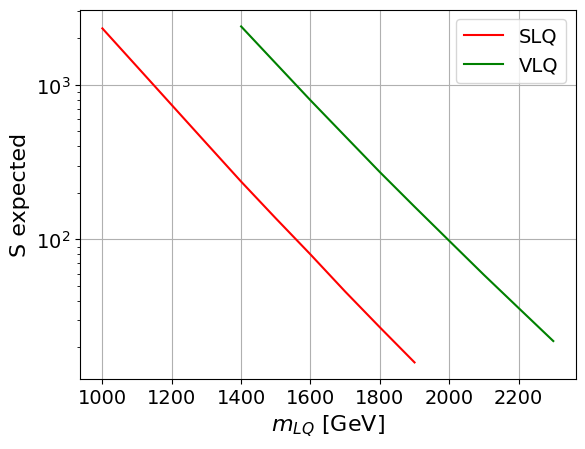

In [17]:
plt.plot(masses_SLQ, S_expected_SLQ, color='red', label='SLQ')
plt.plot(masses_VLQ, S_expected_VLQ, color='green', label='VLQ')
plt.yscale('log')
plt.xlabel("$m_{LQ}$ [GeV]", fontsize=16)
plt.ylabel("S expected", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid()
plt.legend(fontsize=14)
plt.show()

In [18]:
matched_VLQ_masses = []

for s_ev in S_expected_SLQ:
    # buscamos la VLQ que tenga la menor diferencia de eventos
    idx_match = np.argmin([abs(vlq_ev - s_ev) for vlq_ev in S_expected_VLQ])
    matched_mass = masses_VLQ[idx_match]
    matched_VLQ_masses.append(matched_mass)

# Mostrar resultados
for slq, s_ev, vlq, v_ev in zip(masses_SLQ, S_expected_SLQ, matched_VLQ_masses,
                                 [S_expected_VLQ[masses_VLQ.index(m)] for m in matched_VLQ_masses]):
    print(f"SLQ {slq} GeV ({s_ev} ev)  -> VLQ {vlq} GeV ({v_ev} ev)")

SLQ 1000 GeV (2325 ev)  -> VLQ 1400 GeV (2394 ev)
SLQ 1100 GeV (1314 ev)  -> VLQ 1500 GeV (1380 ev)
SLQ 1200 GeV (742 ev)  -> VLQ 1600 GeV (796 ev)
SLQ 1300 GeV (419 ev)  -> VLQ 1700 GeV (466 ev)
SLQ 1400 GeV (237 ev)  -> VLQ 1800 GeV (273 ev)
SLQ 1500 GeV (137 ev)  -> VLQ 1900 GeV (163 ev)
SLQ 1600 GeV (80 ev)  -> VLQ 2000 GeV (98 ev)
SLQ 1700 GeV (46 ev)  -> VLQ 2200 GeV (36 ev)
SLQ 1800 GeV (27 ev)  -> VLQ 2300 GeV (22 ev)
SLQ 1900 GeV (16 ev)  -> VLQ 2300 GeV (22 ev)


### Plot

In [19]:
def plot_variable(var_name_aux, SLQ_data, VLQ_data, SM_data,
                  masses_SLQ, masses_VLQ,
                  bins=25, range=[20,2500], logy=True):

    var_name = feats_label.index(var_name_aux)

    plt.figure(figsize=(6,5))

    # --- Señal SLQ ---
    colors_SLQ = ['red', 'pink', 'orange', 'purple']  # ajustar según # de masas
    for i, m in enumerate(masses_SLQ):
        data = SLQ_data[m][:,var_name]
        plt.hist(data[:], bins=bins, lw=3, range=range, density=True,
                 edgecolor=colors_SLQ[i], histtype='step', label=f'm($LQ_3^S$)={m} GeV')

    # --- Señal VLQ ---
    colors_VLQ = ['lime', 'dodgerblue', 'cyan', 'magenta']  # ajustar según # de masas
    for i, m in enumerate(masses_VLQ):
        data = VLQ_data[m][:,var_name]
        plt.hist(data[:], bins=bins, lw=3, range=range, density=True,
                 edgecolor=colors_VLQ[i], histtype='step', label=f'm($LQ_3^V$)={m} GeV')

    # --- Background stacked ---
    # se combinan todos los backgrounds en un solo histograma apilado
    bg_data_list = [
        SM_data['tt'][:int(len(SM_data['tt'])*fidxsec_SM['tt']/totalcrossSM),var_name],
        np.concatenate([SM_data['singletP1'][:int(len(SM_data['singletP1'])*fidxsec_SM['singletP1']/totalcrossSM),var_name], SM_data['singletP2'][:int(len(SM_data['singletP2'])*fidxsec_SM['singletP2']/totalcrossSM),var_name]]),
        SM_data['Wbbjets'][:int(len(SM_data['Wbbjets'])*fidxsec_SM['Wbbjets']/totalcrossSM),var_name],
        np.concatenate([SM_data['ttW'][:int(len(SM_data['ttW'])*fidxsec_SM['ttW']/totalcrossSM),var_name], SM_data['ttZ'][:int(len(SM_data['ttZ'])*fidxsec_SM['ttZ']/totalcrossSM),var_name], SM_data['ttH'][:int(len(SM_data['ttH'])*fidxsec_SM['ttH']/totalcrossSM),var_name]])
    ]

    bg_colors = ['blue','green','magenta','black']
    plt.hist([d[:] for d in bg_data_list], bins=bins, lw=2, range=range, density=True,
             stacked=True, color=bg_colors, label=[r'$t\bar{t}$',r'single $t$',r'W+j',r'fake $t\bar{t}$, $t\bar{t}V$, $t\bar{t}H$'])

    # --- Configuración del plot ---
    plt.grid()
    plt.xlabel(f"{feats_label[var_name]} [GeV]", fontsize=14)
    # plt.xlabel(r"$E_T^{miss}$ [GeV]", fontsize=14)
    # plt.xlabel(r"$s_T$ [GeV]", fontsize=14)
    # plt.xlabel(r"$H_T$ [GeV]", fontsize=14)
    # plt.xlabel(r"$m_T(E_T^{miss},\tau_h)$ [GeV]", fontsize=14)
    # plt.xlabel(r"$m(\tau_h, b_1)$ [GeV]", fontsize=14)
    # plt.xlabel(r"$\Delta R(b_1, b_2)$", fontsize=14)
    plt.xlabel(r"$N_{b\mathrm{-jets}}$", fontsize=14)

    plt.ylabel("Fraction of Events/bin", fontsize=14)
    plt.xlim(range)

    if logy:
        plt.yscale('log')
        plt.ylim(1e-7,1e-2)
        plt.ylim(1e-2,1e-0) # dR-b1b2 and num-bjets

    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=10, loc='upper right')
    # plt.legend(fontsize=10, loc='lower center')  # dR-b1b2
    # plt.savefig(mainfolder + "saved-results/MET.pdf", bbox_inches='tight')
    # plt.savefig(mainfolder + "saved-results/sT.pdf", bbox_inches='tight')
    # plt.savefig(mainfolder + "saved-results/HT.pdf", bbox_inches='tight')
    # plt.savefig(mainfolder + "saved-results/mT-METtau.pdf", bbox_inches='tight')
    # plt.savefig(mainfolder + "saved-results/m-taub1.pdf", bbox_inches='tight')
    # plt.savefig(mainfolder + "saved-results/m-taub1.pdf", bbox_inches='tight')
    # plt.savefig(mainfolder + "saved-results/dR-b1b2.pdf", bbox_inches='tight')
    plt.savefig(mainfolder + "saved-results/num-bjets.pdf", bbox_inches='tight')
    plt.show()

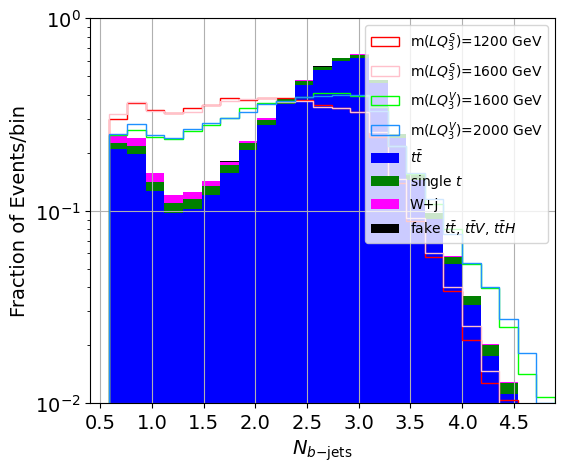

In [20]:
# Ejemplo: plot pT del tau
plot_variable('dR-b1b2', X_SLQ_all, X_VLQ_all, X_B_all,
              masses_SLQ=[1200,1600],
              masses_VLQ=[1600,2000],
              bins=25,
            #   range=[20,2500] # MET-pt
            #   range=[0,5000] # sT and HT and mT-METtau and m-b1b2 and m-taub1
              range=[0.4,4.9] # dR-b1b2
              )

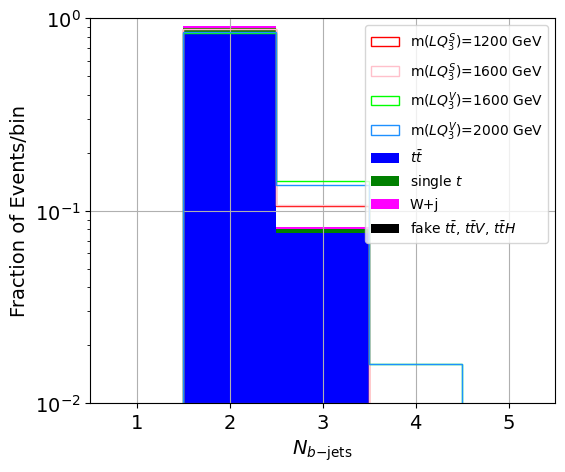

In [21]:
# Ejemplo: plot pT del tau
plot_variable('num-bjets', X_SLQ_all, X_VLQ_all, X_B_all,
              masses_SLQ=[1200,1600],
              masses_VLQ=[1600,2000],
              bins=5,
            #   range=[20,2500] # MET
            #   range=[0,5000] # sT and HT and mT-METtau and m-b1b2
            #   range=[0.4,4.9] # dR-b1b2
              range=[0.5,5.5]
              )

In [22]:
df_SLQ_all[1200].keys()

Index(['b1-pt', 'b1-eta', 'b1-phi', 'b2-pt', 'b2-eta', 'b2-phi', 'tau-pt',
       'tau-eta', 'tau-phi', 'jet1-pt', 'jet1-eta', 'jet1-phi', 'jet2-pt',
       'jet2-eta', 'jet2-phi', 'MET-pt', 'MET-phi', 'HT-pt', 'num-jets',
       'num-bjets', 'dR-taub1', 'dR-taub2', 'dR-b1b2', 'dR-j1b1', 'dR-j1b2',
       'dR-j1tau', 'dR-j2b1', 'dR-j2b2', 'dR-j2tau', 'dR-j1j2', 'dphi-METb1',
       'dphi-METb2', 'dphi-METtau', 'dphi-METj1', 'dphi-METj2', 'm-taub1',
       'm-taub2', 'm-b1b2', 'm-j1b1', 'm-j1b2', 'm-j1tau', 'm-j2b1', 'm-j2b2',
       'm-j2tau', 'm-j1j2', 'mT-METb1', 'mT-METb2', 'mT-METtau', 'mT-METj1',
       'mT-METj2', 'mTb1b2', 'mTj1j2', 'sT'],
      dtype='object')

# 1. DATA FORMAT for CLASSIFIERS

In [23]:
# to save memory
del X_SLQ_all
del X_VLQ_all
del X_B_all

In [24]:
# ---------------------------
# Concatenate all for normalization
# ---------------------------
df_SM = pd.concat(df_B_all.values(), ignore_index=True)
del df_B_all

df_all = pd.concat([df_SM] + list(df_SLQ_all.values()) + list(df_VLQ_all.values()), ignore_index=True)

# ---------------------------
# Normalization
# ---------------------------
scaler = MinMaxScaler()
scaler.fit(df_all)

# Save the scaler
joblib.dump(scaler, mainfolder + 'saved-models/scaler_features.pkl')

# Apply normalization
df_SM_norm = pd.DataFrame(scaler.transform(df_SM), columns=df_SM.columns)
df_SLQ_norm = {mass: pd.DataFrame(scaler.transform(df_SLQ_all[mass]), columns=df_SLQ_all[mass].columns) for mass in df_SLQ_all}
df_VLQ_norm = {mass: pd.DataFrame(scaler.transform(df_VLQ_all[mass]), columns=df_VLQ_all[mass].columns) for mass in df_VLQ_all}






# ---------------------------
# Divide datasets into train/val/test/pseudo
# ---------------------------
def split_class(df, test_ratio=0.25, val_ratio=0.2, pseudo_ratio=0.00001):
    X = df.values
    aux_val_ratio = val_ratio / (1 - test_ratio)
    aux_pseudo_ratio = pseudo_ratio / (1 - test_ratio - val_ratio)

    X_aux, X_test = train_test_split(X, test_size=test_ratio, random_state=42, shuffle=True)
    X_aux2, X_val = train_test_split(X_aux, test_size=aux_val_ratio, random_state=42, shuffle=True)
    X_train, X_pseudo = train_test_split(X_aux2, test_size=aux_pseudo_ratio, random_state=42, shuffle=True)

    return X_train, X_val, X_test, X_pseudo



# ---------------------------
# Divide the datasets
# ---------------------------
split_SM = split_class(df_SM_norm)
split_SLQ = {mass: split_class(df_SLQ_norm[mass]) for mass in df_SLQ_norm}
split_VLQ = {mass: split_class(df_VLQ_norm[mass]) for mass in df_VLQ_norm}



# Example of how to use them
X_train_SM, X_val_SM, X_test_SM, X_pseudo_SM = split_SM
X_train_SLQ1200, X_val_SLQ1200, X_test_SLQ1200, X_pseudo_SLQ1200 = split_SLQ[1200]
X_train_VLQ1600, X_val_VLQ1600, X_test_VLQ1600, X_pseudo_VLQ1600 = split_VLQ[1600]

print('')
print('X_train_SM : ', X_train_SM.shape)
print('X_val_SM : ', X_val_SM.shape)
print('X_test_SM : ', X_test_SM.shape)
print('X_pseudo_SM : ', X_pseudo_SM.shape)

print('')
print('X_train_SLQ1200 : ', X_train_SLQ1200.shape)
print('X_val_SLQ1200 : ', X_val_SLQ1200.shape)
print('X_test_SLQ1200 : ', X_test_SLQ1200.shape)
print('X_pseudo_SLQ1200 : ', X_pseudo_SLQ1200.shape)

print('')
print('X_train_VLQ1600 : ', X_train_VLQ1600.shape)
print('X_val_VLQ1600 : ', X_val_VLQ1600.shape)
print('X_test_VLQ1600 : ', X_test_VLQ1600.shape)
print('X_pseudo_VLQ1600 : ', X_pseudo_VLQ1600.shape)


X_train_SM :  (549990, 53)
X_val_SM :  (200000, 53)
X_test_SM :  (250000, 53)
X_pseudo_SM :  (10, 53)

X_train_SLQ1200 :  (27499, 53)
X_val_SLQ1200 :  (10000, 53)
X_test_SLQ1200 :  (12500, 53)
X_pseudo_SLQ1200 :  (1, 53)

X_train_VLQ1600 :  (27499, 53)
X_val_VLQ1600 :  (10000, 53)
X_test_VLQ1600 :  (12500, 53)
X_pseudo_VLQ1600 :  (1, 53)


In [30]:
# to save memory
del df_SM
del df_SLQ_all
del df_VLQ_all

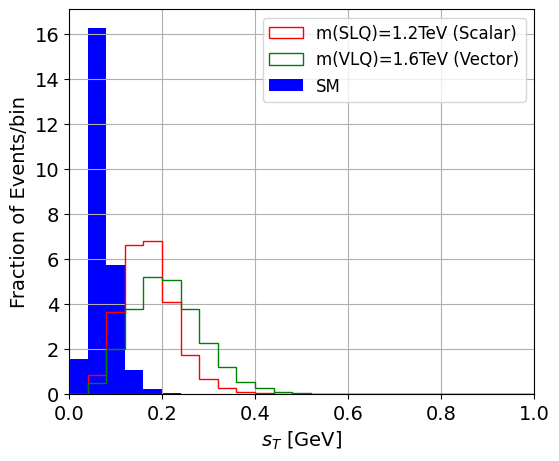

In [31]:
def plot_feat(slq_mass, vlq_mass, feat_SLQ, feat_VLQ, feat_SM, slq_label=None, vlq_label=None):
    plt.figure(figsize=(6,5))

    plt.hist(feat_SLQ, bins=25, lw=2, range=[0,1], density=True,
             edgecolor='red', histtype='step', label=slq_label)

    plt.hist(feat_VLQ, bins=25, lw=2, range=[0,1], density=True,
             edgecolor='green', histtype='step', label=vlq_label)

    plt.hist(feat_SM, bins=25, lw=2, range=[0,1], density=True, stacked=True, color=["blue"], label='SM')

    plt.grid()
#     plt.xlabel(r"$s_T$ [GeV]", fontsize=14)
    plt.ylabel("Fraction of Events/bin", fontsize=14)
    plt.xlim(0,1)
#     plt.ylim(1e-5,5e-3)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
#     plt.yscale('log')
    plt.legend(fontsize=12)
#     plt.show()


feat = 'sT'

plot_feat(
    1200, 1600,
    df_SLQ_norm[1200][feat],
    df_VLQ_norm[1600][feat],
    df_SM_norm[feat],
    slq_label=r'm(SLQ)=1.2TeV (Scalar)',
    vlq_label=r'm(VLQ)=1.6TeV (Vector)'
)
plt.xlabel(r"$s_T$ [GeV]", fontsize=14)
plt.show()

# SM vs LQ

In [32]:
# Combine all LQ in a single DataFrame
df_LQ_list = list(df_SLQ_norm.values()) + list(df_VLQ_norm.values())
df_LQ_norm = pd.concat(df_LQ_list, ignore_index=True)


# Check, same number of events
n_SM = len(df_SM_norm)
n_LQ = len(df_LQ_norm)
n_events = min(n_SM, n_LQ)

print(n_SM, n_LQ, n_events)

df_SM_sample = df_SM_norm.sample(n=n_events, random_state=42)
df_LQ_sample = df_LQ_norm.sample(n=n_events, random_state=42)


# Create X, y
X = pd.concat([df_SM_sample, df_LQ_sample], ignore_index=True)
y = np.hstack([np.zeros(n_events), np.ones(n_events)])  # 0=SM, 1=LQ


def split_class(X, Y, test_ratio=0.25, val_ratio=0.2):

    aux_val_ratio = val_ratio / (1 - test_ratio)

    X_aux, X_test, Y_aux, Y_test = train_test_split(X, Y, test_size=test_ratio, random_state=42, shuffle=True)
    X_train, X_val, Y_train, Y_val = train_test_split(X_aux, Y_aux, test_size=aux_val_ratio, random_state=42, shuffle=True)

    return X_train, X_val, X_test, Y_train, Y_val, Y_test


# Divide into train, validation and test
X_train, X_val, X_test, y_train, y_val, y_test = split_class(X, y)


print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

1000000 1000000 1000000
(1100000, 53)
(400000, 53)
(500000, 53)


In [37]:
# Train
xgb_clf = XGBClassifier(
    n_estimators=1500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    early_stopping_rounds=50,
    tree_method='hist'
)

xgb_clf.fit(X_train, y_train,
            eval_set=[(X_train, y_train),
                      (X_val, y_val)],
            verbose=True)


# SAVE
xgb_clf.save_model(mainfolder + "saved-models/modelA_SMLQ_14TeV_full.json")

/usr/local/lib/python3.13/dist-packages/xgboost/callback.py:385: UserWarning: [18:30:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[0]	validation_0-logloss:0.65167	validation_1-logloss:0.65169
[1]	validation_0-logloss:0.61260	validation_1-logloss:0.61262
[2]	validation_0-logloss:0.57833	validation_1-logloss:0.57837
[3]	validation_0-logloss:0.54731	validation_1-logloss:0.54733
[4]	validation_0-logloss:0.51724	validation_1-logloss:0.51728
[5]	validation_0-logloss:0.48955	validation_1-logloss:0.48958
[6]	validation_0-logloss:0.46409	validation_1-logloss:0.46413
[7]	validation_0-logloss:0.44053	validation_1-logloss:0.44058
[8]	validation_0-logloss:0.41971	validation_1-logloss:0.41977
[9]	validation_0-logloss:0.39948	validation_1-logloss:0.39956
[10]	validation_0-logloss:0.38059	validation_1-logloss:0.38069
[11]	validation_0-logloss:0.36316	validation_1-logloss:0.36327
[12]	validation_0-logloss:0.34687	validation_1-logloss:0.34699
[13]	validation_0-logloss:0.33239	validation_1-logloss:0.33251
[14]	validation_0-logloss:0.31810	validation_1-logloss:0.31825
[15]	validation_0-logloss:0.30475	validation_1-logloss:0.30491
[1

Accuracy: 0.974, ROC-AUC: 0.99660


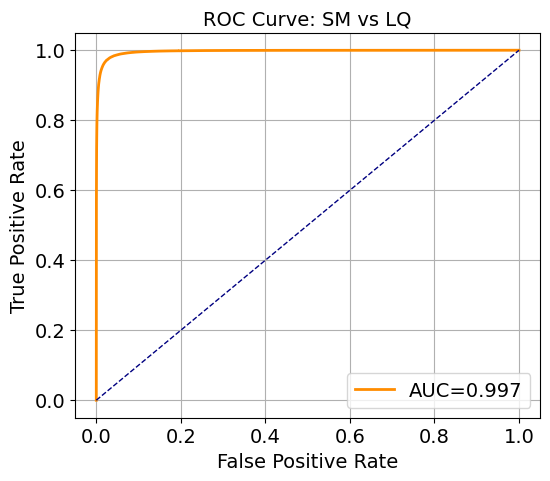

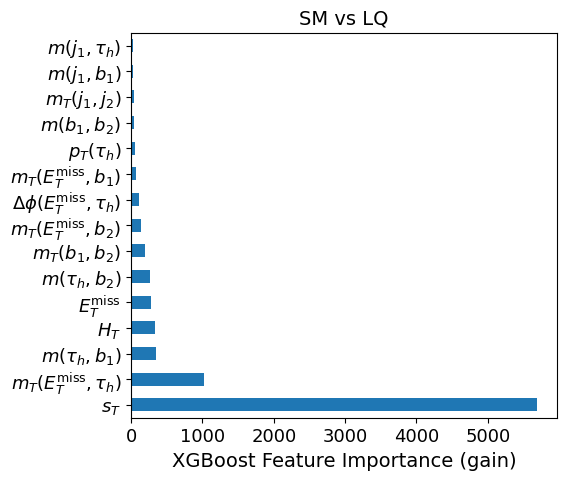

[52, 47, 35, 17, 15, 36, 50, 46, 32, 45, 6, 37, 51, 38, 40]


In [38]:
# LOAD
xgb_clf = XGBClassifier()
xgb_clf.load_model(mainfolder + "saved-models/modelA_SMLQ_14TeV_full.json")


# Evaluate
y_pred = xgb_clf.predict(X_test)
y_pred_proba = xgb_clf.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)
print(f"Accuracy: {acc:.3f}, ROC-AUC: {auc:.5f}")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC={auc:.3f}')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.title("ROC Curve: SM vs LQ", fontsize=14)
plt.grid(True)
plt.legend(fontsize=14)
plt.savefig(mainfolder + "saved-results/ROC_classA.pdf", bbox_inches='tight')
plt.show()


# Feature importance
keys = np.array([r'$p_T(b_1)$',r'$\eta(b_1)$',r'$\phi(b_1)$',
                 r'$p_T(b_2)$',r'$\eta(b_2)$',r'$\phi(b_2)$',
                 r'$p_T(\tau_h)$',r'$\eta(\tau_h)$',r'$\phi(\tau_h)$',
                 r'$p_T(jet_1)$',r'$\eta(jet_1)$',r'$\phi(jet_1)$',
                 r'$p_T(jet_2)$',r'$\eta(jet_2)$',r'$\phi(jet_2)$',
                 r'$E_T^{\mathrm{miss}}$',r'$\phi(E_T^{\mathrm{miss}})$',
                 r'$H_T$',r'$N_{\mathrm{jets}}$',r'$N_{b-\mathrm{jets}}$',
                 r'$\Delta R(\tau_h, b_1)$',r'$\Delta R(\tau_h, b_2)$',r'$\Delta R(b_1, b_2)$',
                 r'$\Delta R(j_1, b_1)$',r'$\Delta R(j_1, b_2)$',r'$\Delta R(j_1, \tau_h)$',
                 r'$\Delta R(j_2, b_1)$',r'$\Delta R(j_2, b_2)$',r'$\Delta R(j_2, \tau_h)$',
                 r'$\Delta R(j_1, j_2)$',
#                  r'$\Delta \phi(\tau_h, b_1)$',r'$\Delta \phi(\tau_h, b_2)$',r'$\Delta \phi(b_1, b_2)$',
                 r'$\Delta \phi(E_T^{\mathrm{miss}}, b_1)$',r'$\Delta \phi(E_T^{\mathrm{miss}}, b_2)$',r'$\Delta \phi(E_T^{\mathrm{miss}}, \tau_h)$',
                 r'$\Delta \phi(E_T^{\mathrm{miss}}, j_1)$',r'$\Delta \phi(E_T^{\mathrm{miss}}, j_2)$',
                 r'$m(\tau_h, b_1)$',r'$m(\tau_h, b_2)$',r'$m(b_1, b_2)$',
                 r'$m(j_1, b_1)$',r'$m(j_1, b_2)$',r'$m(j_1, \tau_h)$',
                 r'$m(j_2, b_1)$',r'$m(j_2, b_2)$',r'$m(j_2, \tau_h)$',
                 r'$m(j_1, j_2)$',
                 r'$m_T(E_T^{\mathrm{miss}}, b_1)$',r'$m_T(E_T^{\mathrm{miss}}, b_2)$',r'$m_T(E_T^{\mathrm{miss}}, \tau_h)$',
                 r'$m_T(E_T^{\mathrm{miss}}, j_1)$',r'$m_T(E_T^{\mathrm{miss}}, j_2)$',
                 r'$m_T(b_1, b_2)$',r'$m_T(j_1, j_2)$',r'$s_T$'])

feature_important = xgb_clf.get_booster().get_score(importance_type='gain')
values = list(feature_important.values())

data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=False)
data.nlargest(15, columns="score").plot(kind='barh',figsize=(5.5,5)) ## plot top 15 features
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlabel("XGBoost Feature Importance (gain)", fontsize=14)
plt.legend( fontsize=14).remove()
plt.title(r'SM vs LQ', fontsize=14)
plt.savefig(mainfolder + "saved-results/XG_feature_importance_classA.pdf", bbox_inches='tight')
plt.show()


# SELECT THE TOP INDICES
num_feats = 15

keys_list = list(keys)  # convert to list
top_names = data.nlargest(num_feats, columns="score").index.tolist()
feat_indices_LQSM = [keys_list.index(name) for name in top_names]

print(feat_indices_LQSM)

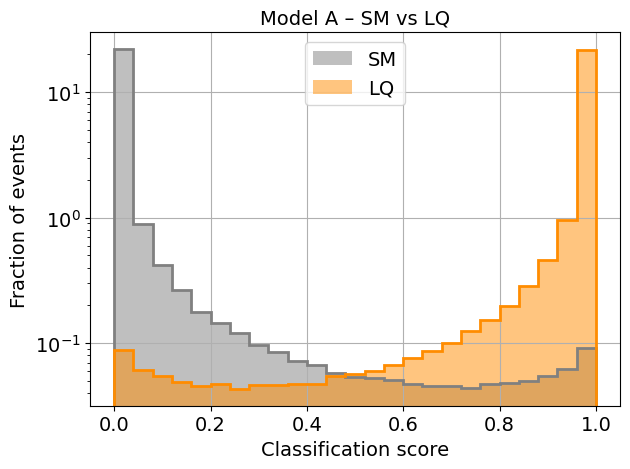

In [39]:

plt.hist(y_pred_proba[y_test < 0.5], bins=25, range=(0,1), density=True, histtype='step', color='gray', linewidth=2)
plt.hist(y_pred_proba[y_test > 0.5], bins=25, range=(0,1), density=True, histtype='step', color='darkorange', linewidth=2)

plt.hist(y_pred_proba[y_test < 0.5], bins=25, range=(0,1), density=True, color='gray', alpha=0.5, label=f'SM')#\nmean: {np.mean(pred_B):.2f}')
plt.hist(y_pred_proba[y_test > 0.5], bins=25, range=(0,1), density=True, color='darkorange', alpha=0.5, label=f'LQ')#\nmean: {np.mean(pred_s):.2f}')

plt.yscale('log')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title(f'Model A – SM vs LQ', fontsize=14)
plt.xlabel("Classification score", fontsize=14)
plt.ylabel("Fraction of events", fontsize=14)
plt.grid(True)
plt.legend(fontsize=14)

plt.tight_layout()
plt.savefig(mainfolder + 'saved-results/output_classA_multi.pdf', bbox_inches='tight')
plt.show()

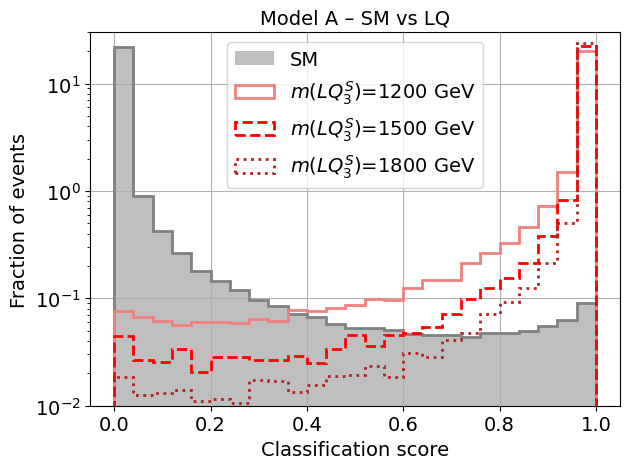

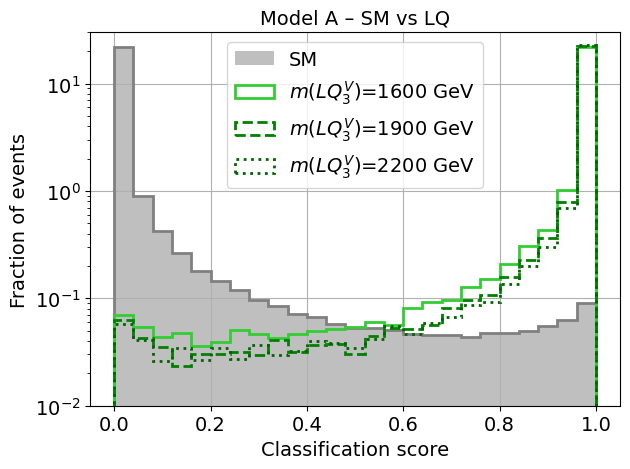

In [40]:



mSLQ_plot = [1200, 1500, 1800]
mVLQ_plot = [1600, 1900, 2200]

linestyles = ['-', '--', ':']
colors_SLQ = ['lightcoral', 'red', 'firebrick']
colors_VLQ = ['limegreen', 'green', 'darkgreen']


plt.hist(y_pred_proba[y_test < 0.5], bins=25, range=(0,1), density=True, histtype='step', color='gray', linewidth=2)
plt.hist(y_pred_proba[y_test < 0.5], bins=25, range=(0,1), density=True, color='gray', alpha=0.5, label=f'SM')#\nmean: {np.mean(pred_B):.2f}')

for idx, m_it in enumerate(mSLQ_plot):
    y_pred_SLQ_plot = xgb_clf.predict_proba(np.array(df_SLQ_norm[m_it][:100000]))[:,1]
    plt.hist(y_pred_SLQ_plot, bins=25, range=(0,1), density=True, histtype='step', linestyle=linestyles[idx], color=colors_SLQ[idx], linewidth=2, label=f'$m(LQ_{{3}}^{{S}})$={m_it} GeV')

# for idx, m_it in enumerate(mVLQ_plot):
#     y_pred_VLQ_plot = xgb_clf.predict_proba(np.array(df_VLQ_norm[m_it][:100000]))[:,1]
#     plt.hist(y_pred_VLQ_plot, bins=25, range=(0,1), density=True, histtype='step', linestyle=linestyles[idx], color=colors_VLQ[idx], linewidth=2, label=f'$m(LQ_{{3}}^{{V}})$={m_it} GeV')


plt.yscale('log')
plt.ylim(1e-2,3e1)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title(f'Model A – SM vs LQ', fontsize=14)
plt.xlabel("Classification score", fontsize=14)
plt.ylabel("Fraction of events", fontsize=14)
plt.grid(True)
plt.legend(fontsize=14)

plt.tight_layout()
plt.savefig(mainfolder + 'saved-results/output_classA_multi_SLQ.pdf', bbox_inches='tight')
plt.show()




plt.hist(y_pred_proba[y_test < 0.5], bins=25, range=(0,1), density=True, histtype='step', color='gray', linewidth=2)
plt.hist(y_pred_proba[y_test < 0.5], bins=25, range=(0,1), density=True, color='gray', alpha=0.5, label=f'SM')#\nmean: {np.mean(pred_B):.2f}')

# for idx, m_it in enumerate(mSLQ_plot):
#     y_pred_SLQ_plot = xgb_clf.predict_proba(np.array(df_SLQ_norm[m_it][:100000]))[:,1]
#     plt.hist(y_pred_SLQ_plot, bins=25, range=(0,1), density=True, histtype='step', linestyle=linestyles[idx], color=colors_SLQ[idx], linewidth=2, label=f'$m_(LQ_{{3}}^{{S}})$={m_it} GeV')

for idx, m_it in enumerate(mVLQ_plot):
    y_pred_VLQ_plot = xgb_clf.predict_proba(np.array(df_VLQ_norm[m_it][:100000]))[:,1]
    plt.hist(y_pred_VLQ_plot, bins=25, range=(0,1), density=True, histtype='step', linestyle=linestyles[idx], color=colors_VLQ[idx], linewidth=2, label=f'$m(LQ_{{3}}^{{V}})$={m_it} GeV')


plt.yscale('log')
plt.ylim(1e-2,3e1)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title(f'Model A – SM vs LQ', fontsize=14)
plt.xlabel("Classification score", fontsize=14)
plt.ylabel("Fraction of events", fontsize=14)
plt.grid(True)
plt.legend(fontsize=14)

plt.tight_layout()
plt.savefig(mainfolder + 'saved-results/output_classA_multi_VLQ.pdf', bbox_inches='tight')
plt.show()

### Some plots

In [ ]:

y_pred_proba_train = xgb_clf.predict_proba(X_train)[:,1]
y_pred_proba_val = xgb_clf.predict_proba(X_val)[:,1]

# threshold mask
threshold = 0.95
mask_x_test = y_pred_proba > threshold
mask_x_train = y_pred_proba_train > threshold
mask_x_val = y_pred_proba_val > threshold

# mask X and y
X_test_mask_norm = X_test[mask_x_test]
X_train_mask_norm = X_train[mask_x_train]
X_val_mask_norm = X_val[mask_x_val]

y_test_mask = y_test[mask_x_test]
y_train_mask = y_train[mask_x_train]
y_val_mask = y_val[mask_x_val]

X_mask_norm = pd.concat( [ X_test_mask_norm, X_train_mask_norm, X_val_mask_norm ], ignore_index=True)
y_mask = np.concatenate( [y_test_mask, y_train_mask, y_val_mask] )

In [ ]:
# De-normalize
X_mask_raw = pd.DataFrame( scaler.inverse_transform(X_mask_norm), columns=X_test.columns )

# SM vs LQ
mask_2 = y_mask > 0.5
X_mask_raw_LQ = X_mask_raw[mask_2]
mask_3 = y_mask < 0.5
X_mask_raw_SM = X_mask_raw[mask_3]

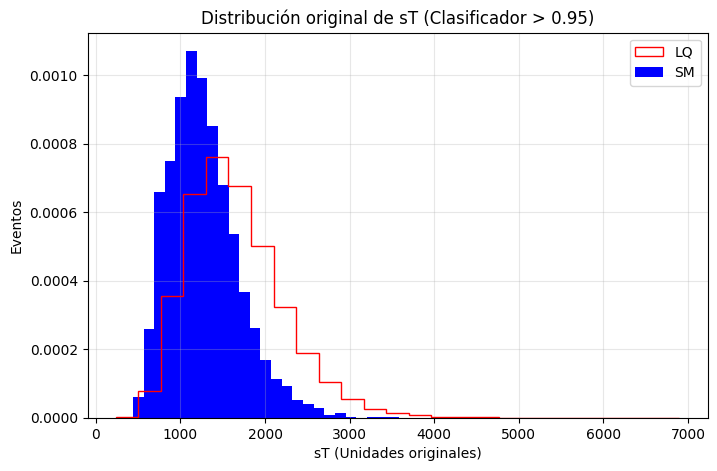

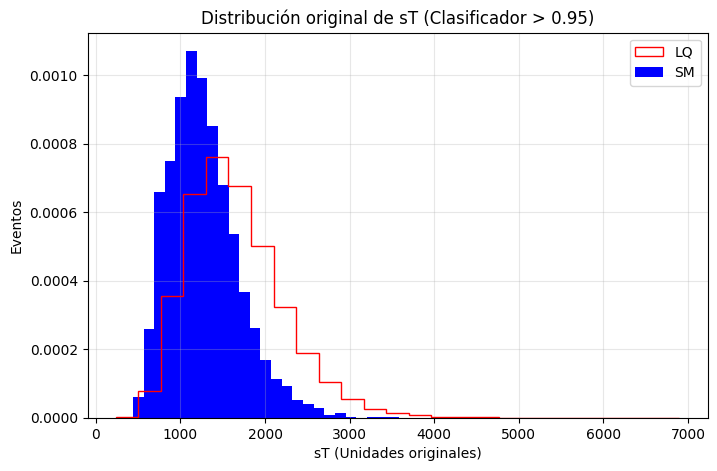

In [ ]:
variables_a_graficar = ['sT', 'sT']

for var in variables_a_graficar:
    if var in X_mask_raw.columns:
        plt.figure(figsize=(8, 5))

        # plt.hist(data=X_mask_raw_LQ, x=var, color='teal', label=f'Prob > {threshold}')
        # plt.hist(data=X_mask_raw_SM, x=var, color='blue', label=f'Prob > {threshold}')
        plt.hist(X_mask_raw_LQ[var].tolist(), bins=25, lw=2, density=True, edgecolor='red', histtype='step', label='LQ')
        plt.hist(X_mask_raw_SM[var].tolist(), bins=25, lw=2, density=True, stacked=True, color="blue", label='SM')

        plt.title(f'Distribución original de {var} (Clasificador > {threshold})')
        plt.xlabel(f'{var} (Unidades originales)')
        plt.ylabel('Eventos')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()



In [ ]:
# threshold mask
threshold = 0.95

# SM
y_pred_SM = xgb_clf.predict_proba(df_SM_norm)[:,1]

mask_SM = y_pred_SM > threshold

X_SM_mask_norm = df_SM_norm[mask_SM]

# De-normalize
X_SM_raw = pd.DataFrame( scaler.inverse_transform(X_SM_mask_norm), columns=X_SM_mask_norm.columns )

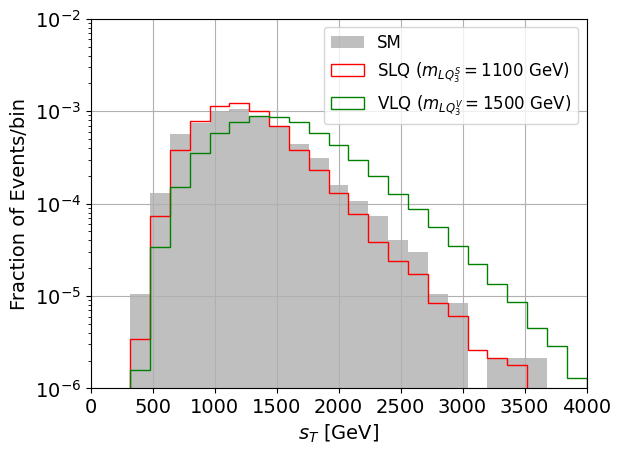

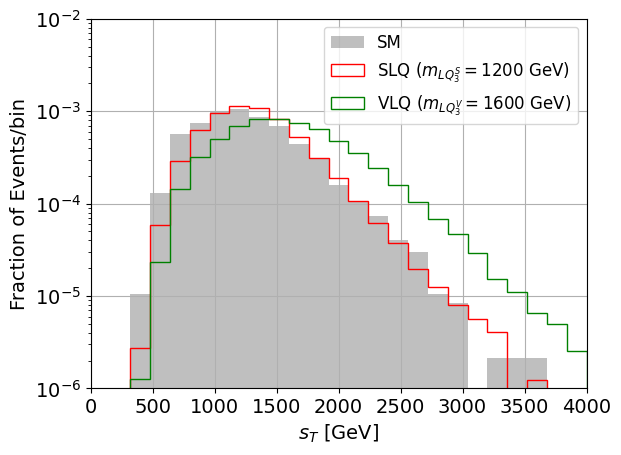

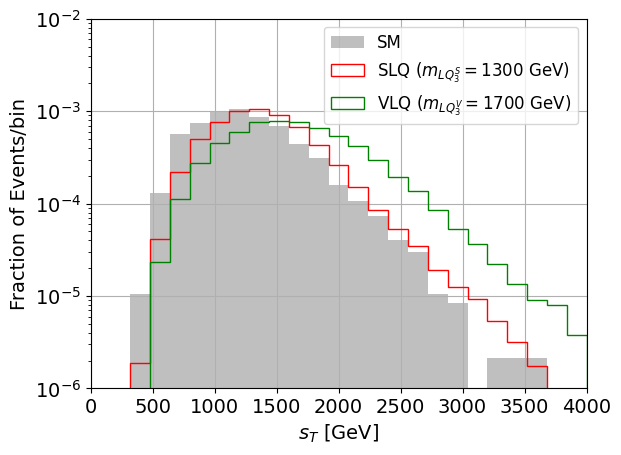

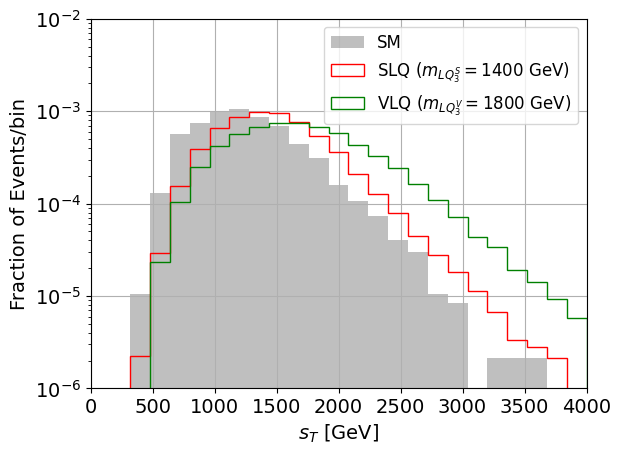

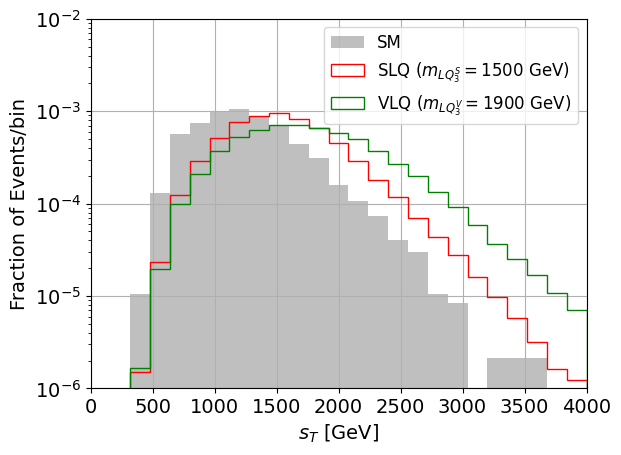

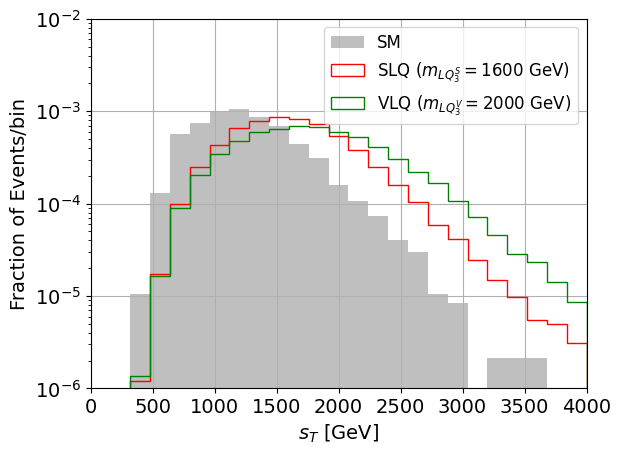

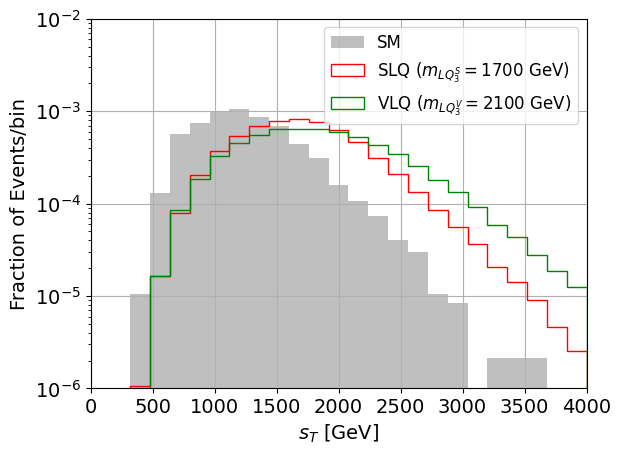

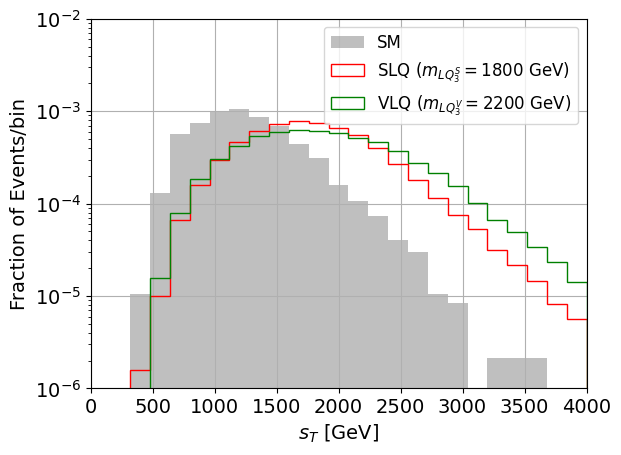

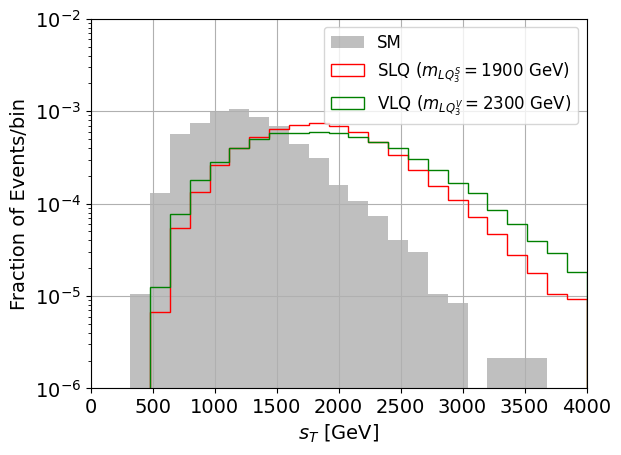

In [ ]:


for i in range(1,len(masses_SLQ)):

    y_pred_SLQ = xgb_clf.predict_proba(df_SLQ_norm[masses_SLQ[i]])[:,1]
    y_pred_VLQ = xgb_clf.predict_proba(df_VLQ_norm[masses_VLQ[i]])[:,1]

    mask_SLQ = y_pred_SLQ > threshold
    mask_VLQ = y_pred_VLQ > threshold

    X_SLQ_mask_norm = df_SLQ_norm[masses_SLQ[i]][mask_SLQ]
    X_VLQ_mask_norm = df_VLQ_norm[masses_VLQ[i]][mask_VLQ]

    X_SLQ_raw = pd.DataFrame( scaler.inverse_transform(X_SLQ_mask_norm), columns=X_SLQ_mask_norm.columns )
    X_VLQ_raw = pd.DataFrame( scaler.inverse_transform(X_VLQ_mask_norm), columns=X_VLQ_mask_norm.columns )


    var = 'sT'
    # plt.hist(X_SM_raw[var].tolist(), bins=25, range=[0, 4000], lw=3, density=True, edgecolor='blue', histtype='step', label='SM')
    plt.hist(X_SM_raw[var].tolist(), bins=25, range=[0, 4000], lw=3, density=True, color='gray', alpha=0.5, label='SM')
    plt.hist(X_SLQ_raw[var].tolist(), bins=25, range=[0, 4000], lw=3, density=True, edgecolor='red', histtype='step', label=f'SLQ ($m_{{LQ_3^S}}=${masses_SLQ[i]} GeV)')
    plt.hist(X_VLQ_raw[var].tolist(), bins=25, range=[0, 4000], lw=3, density=True, edgecolor='green', histtype='step', label=f'VLQ ($m_{{LQ_3^V}}=${masses_VLQ[i]} GeV)')

    plt.xlabel(r"$s_T$ [GeV]", fontsize=14)
    plt.ylabel("Fraction of Events/bin", fontsize=14)

    plt.yscale('log')
    plt.ylim(1e-6,1e-2)
    plt.xlim(0,4000)

    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=12, loc='upper right')
    plt.grid()
    plt.savefig(mainfolder + f"saved-results/sT-sector{i-1}.pdf", bbox_inches='tight')
    plt.show()

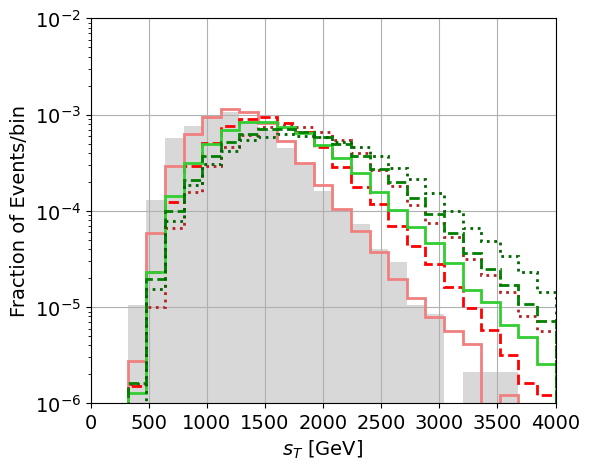

In [ ]:
plt.figure(figsize=(6, 5))
var = 'sT'
threshold = 0.95

linestyles = ['-', '--', ':']
colors_SLQ = ['lightcoral', 'red', 'firebrick']
colors_VLQ = ['limegreen', 'green', 'darkgreen']
list_mass = [2,5,8]


# SM
plt.hist(X_SM_raw[var].tolist(), bins=25, range=[0, 4000], lw=2, density=True, color='gray', alpha=0.3, label='SM Background', zorder=1)


# loop
for idx, i in enumerate(list_mass):

    # data
    y_pred_SLQ = xgb_clf.predict_proba(df_SLQ_norm[masses_SLQ[i]])[:,1]
    y_pred_VLQ = xgb_clf.predict_proba(df_VLQ_norm[masses_VLQ[i]])[:,1]

    mask_SLQ = y_pred_SLQ > threshold
    mask_VLQ = y_pred_VLQ > threshold

    X_SLQ_mask_norm = df_SLQ_norm[masses_SLQ[i]][mask_SLQ]
    X_VLQ_mask_norm = df_VLQ_norm[masses_VLQ[i]][mask_VLQ]

    X_SLQ_raw = pd.DataFrame(scaler.inverse_transform(X_SLQ_mask_norm), columns=X_SLQ_mask_norm.columns)
    X_VLQ_raw = pd.DataFrame(scaler.inverse_transform(X_VLQ_mask_norm), columns=X_VLQ_mask_norm.columns)

    # SLQ
    plt.hist(X_SLQ_raw[var].tolist(), bins=25, range=[0, 4000], linewidth=2, density=True, color=colors_SLQ[idx], histtype='step', linestyle = linestyles[idx],
             label=f'SLQ ($m_{{LQ}}$={masses_SLQ[i]} GeV)', zorder=2)

    # VLQ
    plt.hist(X_VLQ_raw[var].tolist(), bins=25, range=[0, 4000], linewidth=2, density=True, color=colors_VLQ[idx], histtype='step', linestyle = linestyles[idx],
             label=f'VLQ ($m_{{LQ}}$={masses_VLQ[i]} GeV)', zorder=3)


plt.xlabel(r"$s_T$ [GeV]", fontsize=14)
plt.ylabel("Fraction of Events/bin", fontsize=14)

plt.yscale('log')
plt.ylim(1e-6, 1e-2)
plt.xlim(0, 4000)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.legend(fontsize=11, loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0.)
plt.grid()
plt.savefig(mainfolder + "saved-results/sT-all_sectors.pdf", bbox_inches='tight')
plt.show()

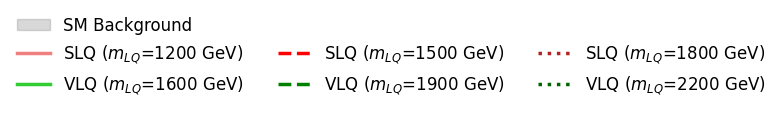

In [ ]:

list_mass = [2, 5, 8]
linestyles = ['-', '--', ':']
colors_SLQ = ['lightcoral', 'red', 'firebrick']
colors_VLQ = ['limegreen', 'green', 'darkgreen']


fig_leg, ax_leg = plt.subplots(figsize=(8, 1.2))

ax_leg.axis('off')

# SM, full block
ax_leg.fill_between([], [], color='gray', alpha=0.3, label='SM Background')

# ax_leg.fill_between([], [], color='white', alpha=0.3, label=' ')

# SLQ y VLQ lines
for idx, i in enumerate(list_mass):
    if idx > 0:
        ax_leg.fill_between([], [], color='white', alpha=0.3, label=' ')
    # SLQ
    ax_leg.plot([], [], color=colors_SLQ[idx], linestyle=linestyles[idx], lw=2.5, label=f'SLQ ($m_{{LQ}}$={masses_SLQ[i]} GeV)')
# for idx, i in enumerate(list_mass):
    # VLQ
    ax_leg.plot([], [], color=colors_VLQ[idx], linestyle=linestyles[idx], lw=2.5, label=f'VLQ ($m_{{LQ}}$={masses_VLQ[i]} GeV)')



ax_leg.legend(loc='center', ncol=3, fontsize=12, frameon=True,
              facecolor='white', edgecolor='none')

plt.tight_layout()
plt.savefig(mainfolder + "saved-results/legend_horizontal.pdf", bbox_inches='tight')
plt.show()

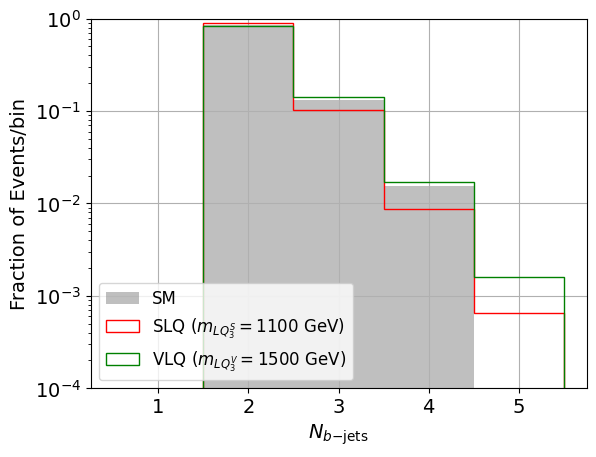

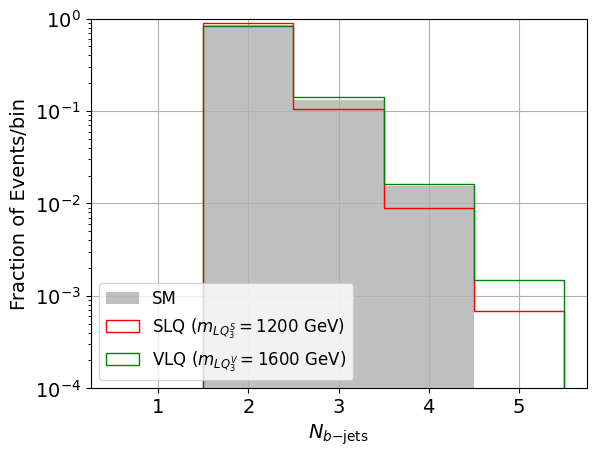

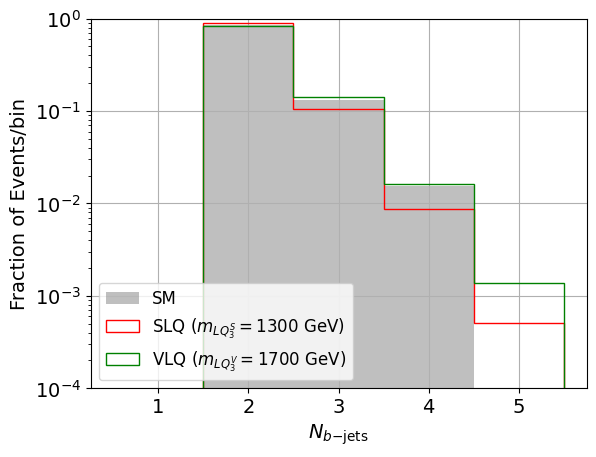

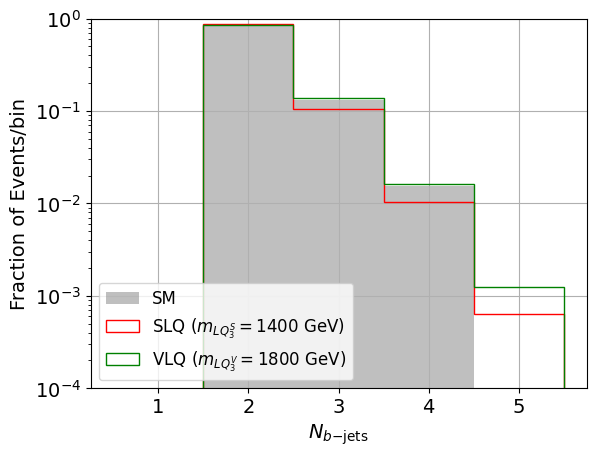

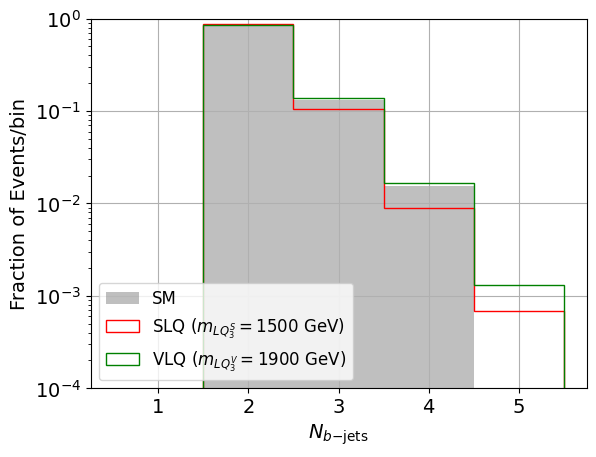

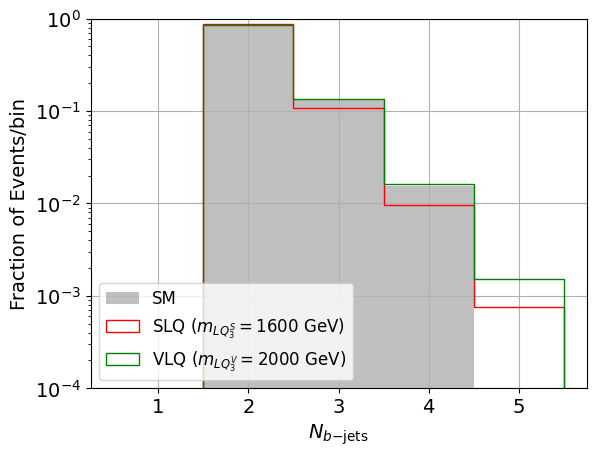

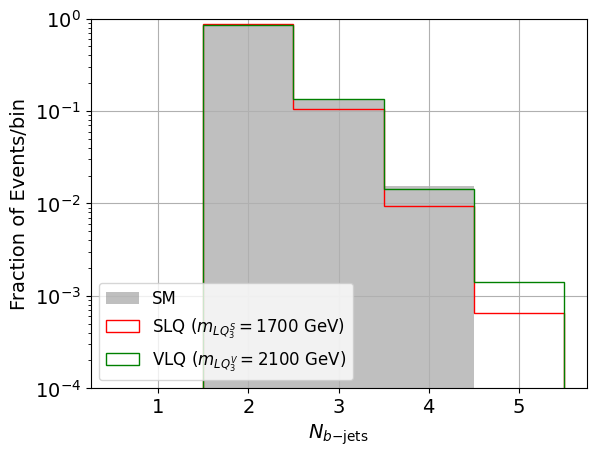

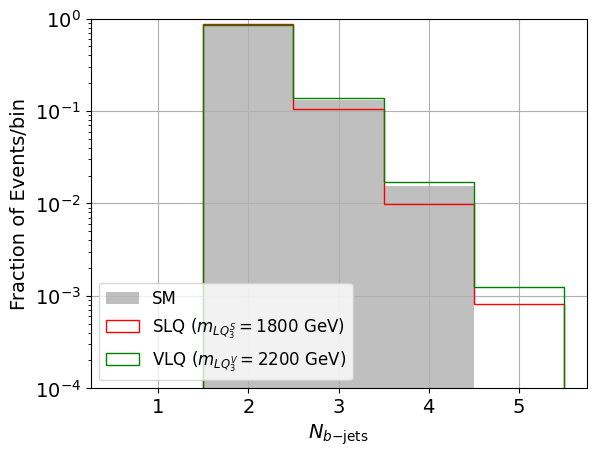

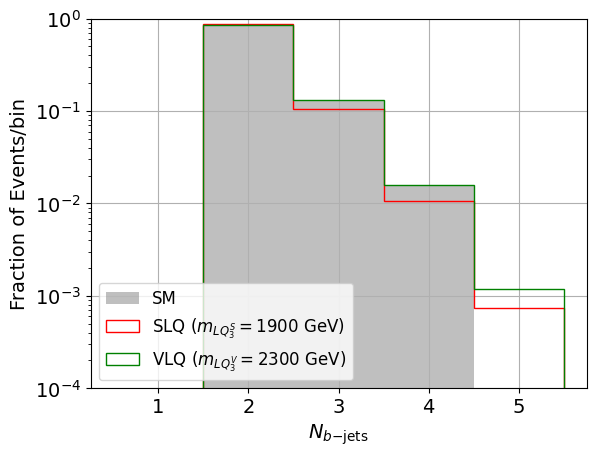

In [ ]:
for i in range(1,len(masses_SLQ)):

    y_pred_SLQ = xgb_clf.predict_proba(df_SLQ_norm[masses_SLQ[i]])[:,1]
    y_pred_VLQ = xgb_clf.predict_proba(df_VLQ_norm[masses_VLQ[i]])[:,1]

    mask_SLQ = y_pred_SLQ > threshold
    mask_VLQ = y_pred_VLQ > threshold

    X_SLQ_mask_norm = df_SLQ_norm[masses_SLQ[i]][mask_SLQ]
    X_VLQ_mask_norm = df_VLQ_norm[masses_VLQ[i]][mask_VLQ]

    X_SLQ_raw = pd.DataFrame( scaler.inverse_transform(X_SLQ_mask_norm), columns=X_SLQ_mask_norm.columns )
    X_VLQ_raw = pd.DataFrame( scaler.inverse_transform(X_VLQ_mask_norm), columns=X_VLQ_mask_norm.columns )


    var = 'num-bjets'
    # plt.hist(X_SM_raw[var].tolist(), bins=5, range=[0.5, 5.5], lw=3, density=True, edgecolor='blue', histtype='step', label='SM')
    plt.hist(X_SM_raw[var].tolist(), bins=5, range=[0.5, 5.5], lw=3, density=True, color='gray', alpha=0.5, label='SM')
    plt.hist(X_SLQ_raw[var].tolist(), bins=5, range=[0.5, 5.5], lw=3, density=True, edgecolor='red', histtype='step', label=f'SLQ ($m_{{LQ_3^S}}=${masses_SLQ[i]} GeV)')
    plt.hist(X_VLQ_raw[var].tolist(), bins=5, range=[0.5, 5.5], lw=3, density=True, edgecolor='green', histtype='step', label=f'VLQ ($m_{{LQ_3^V}}=${masses_VLQ[i]} GeV)')

    plt.xlabel(r"$N_{b\mathrm{-jets}}$", fontsize=14)
    plt.ylabel("Fraction of Events/bin", fontsize=14)

    plt.yscale('log')
    plt.ylim(1e-4,1e-0)
    # plt.xlim(0,4000)

    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=12, loc='lower left')
    plt.grid()
    plt.savefig(mainfolder + f"saved-results/num-bjets-sector{i-1}.pdf", bbox_inches='tight')
    plt.show()

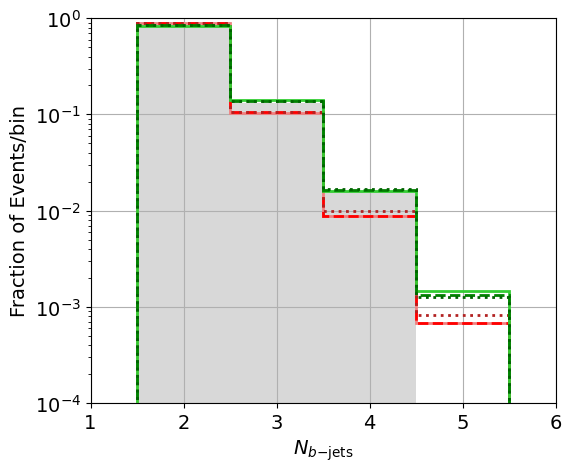

In [ ]:
plt.figure(figsize=(6, 5))
var = 'num-bjets'
threshold = 0.95

linestyles = ['-', '--', ':']
colors_SLQ = ['lightcoral', 'red', 'firebrick']
colors_VLQ = ['limegreen', 'green', 'darkgreen']
list_mass = [2,5,8]


# SM
plt.hist(X_SM_raw[var].tolist(), bins=5, range=[0.5, 5.5], lw=2, density=True, color='gray', alpha=0.3, label='SM Background', zorder=1)


# loop
for idx, i in enumerate(list_mass):

    # data
    y_pred_SLQ = xgb_clf.predict_proba(df_SLQ_norm[masses_SLQ[i]])[:,1]
    y_pred_VLQ = xgb_clf.predict_proba(df_VLQ_norm[masses_VLQ[i]])[:,1]

    mask_SLQ = y_pred_SLQ > threshold
    mask_VLQ = y_pred_VLQ > threshold

    X_SLQ_mask_norm = df_SLQ_norm[masses_SLQ[i]][mask_SLQ]
    X_VLQ_mask_norm = df_VLQ_norm[masses_VLQ[i]][mask_VLQ]

    X_SLQ_raw = pd.DataFrame(scaler.inverse_transform(X_SLQ_mask_norm), columns=X_SLQ_mask_norm.columns)
    X_VLQ_raw = pd.DataFrame(scaler.inverse_transform(X_VLQ_mask_norm), columns=X_VLQ_mask_norm.columns)

    # SLQ
    plt.hist(X_SLQ_raw[var].tolist(), bins=5, range=[0.5, 5.5], linewidth=2, density=True, color=colors_SLQ[idx], histtype='step', linestyle = linestyles[idx],
             label=f'SLQ ($m_{{LQ}}$={masses_SLQ[i]} GeV)', zorder=2)

    # VLQ
    plt.hist(X_VLQ_raw[var].tolist(), bins=5, range=[0.5, 5.5], linewidth=2, density=True, color=colors_VLQ[idx], histtype='step', linestyle = linestyles[idx],
             label=f'VLQ ($m_{{LQ}}$={masses_VLQ[i]} GeV)', zorder=3)


plt.xlabel(r"$N_{b\mathrm{-jets}}$", fontsize=14)
plt.ylabel("Fraction of Events/bin", fontsize=14)

plt.yscale('log')
plt.ylim(1e-4,1e-0)
plt.xlim(1, 6)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.legend(fontsize=11, loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0.)
plt.grid()
plt.savefig(mainfolder + "saved-results/num-bjets-all_sectors.pdf", bbox_inches='tight')
plt.show()

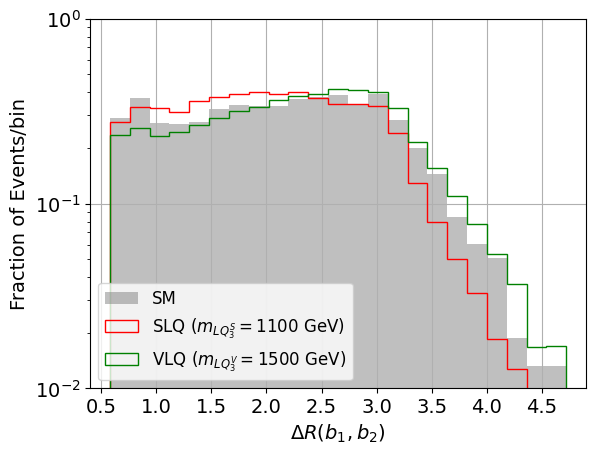

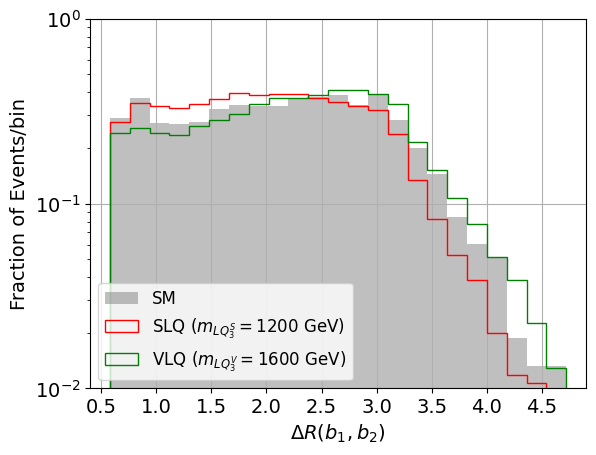

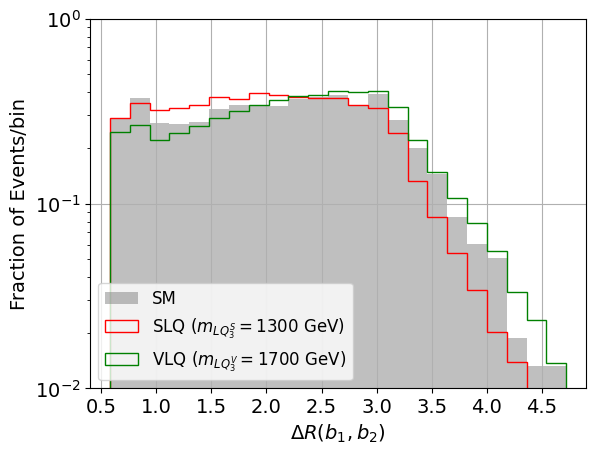

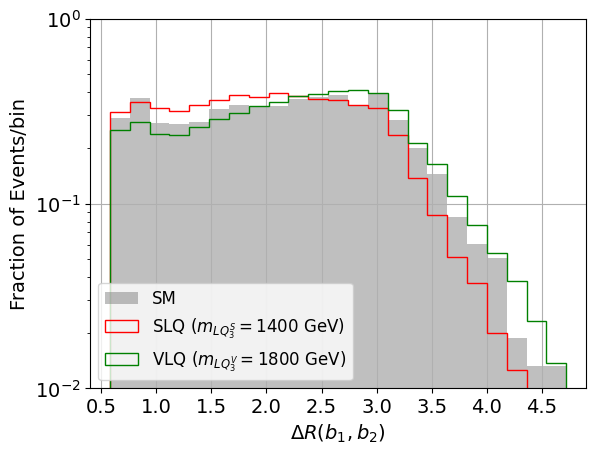

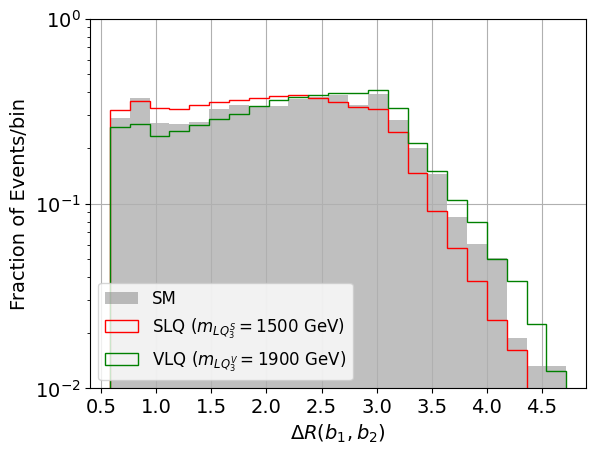

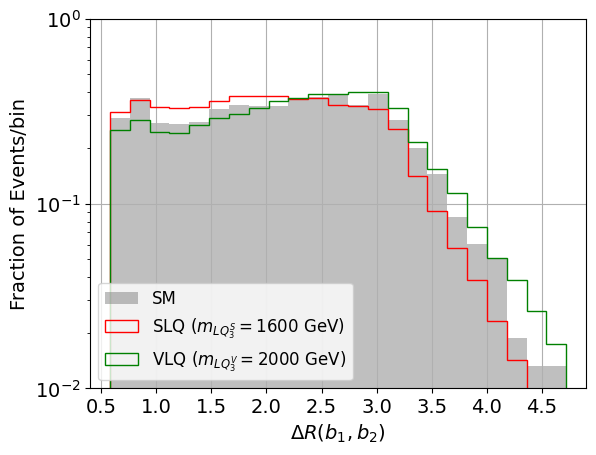

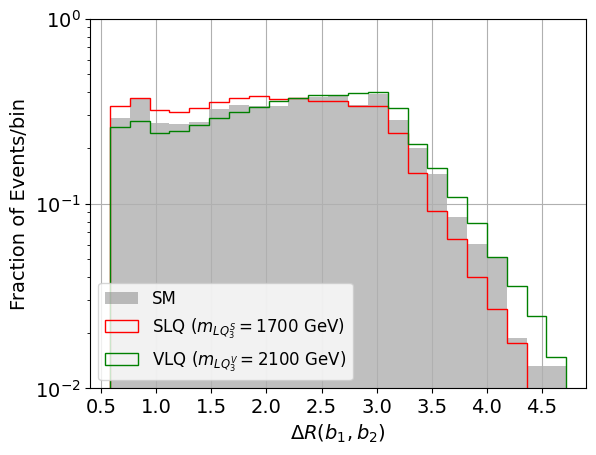

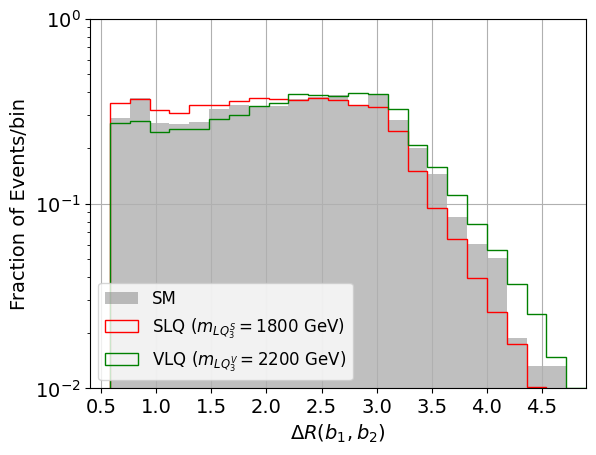

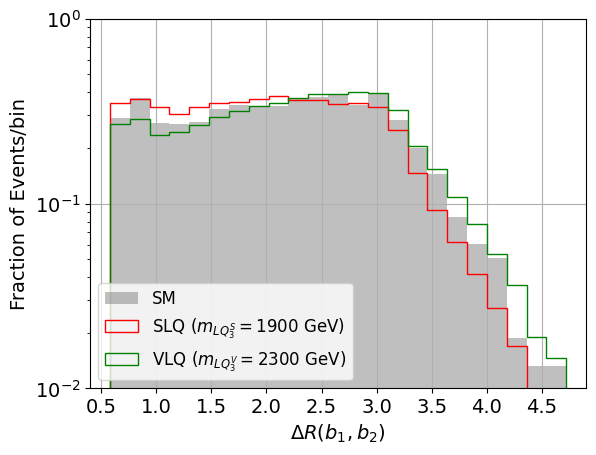

In [ ]:
for i in range(1,len(masses_SLQ)):

    y_pred_SLQ = xgb_clf.predict_proba(df_SLQ_norm[masses_SLQ[i]])[:,1]
    y_pred_VLQ = xgb_clf.predict_proba(df_VLQ_norm[masses_VLQ[i]])[:,1]

    mask_SLQ = y_pred_SLQ > threshold
    mask_VLQ = y_pred_VLQ > threshold

    X_SLQ_mask_norm = df_SLQ_norm[masses_SLQ[i]][mask_SLQ]
    X_VLQ_mask_norm = df_VLQ_norm[masses_VLQ[i]][mask_VLQ]

    X_SLQ_raw = pd.DataFrame( scaler.inverse_transform(X_SLQ_mask_norm), columns=X_SLQ_mask_norm.columns )
    X_VLQ_raw = pd.DataFrame( scaler.inverse_transform(X_VLQ_mask_norm), columns=X_VLQ_mask_norm.columns )


    var = 'dR-b1b2'
    # plt.hist(X_SM_raw[var].tolist(), bins=25, range=[0.4, 4.9], lw=3, density=True, edgecolor='blue', histtype='step', label='SM')
    plt.hist(X_SM_raw[var].tolist(), bins=25, range=[0.4, 4.9], lw=3, density=True, color='gray', alpha=0.5, label='SM')
    plt.hist(X_SLQ_raw[var].tolist(), bins=25, range=[0.4, 4.9], lw=3, density=True, edgecolor='red', histtype='step', label=f'SLQ ($m_{{LQ_3^S}}=${masses_SLQ[i]} GeV)')
    plt.hist(X_VLQ_raw[var].tolist(), bins=25, range=[0.4, 4.9], lw=3, density=True, edgecolor='green', histtype='step', label=f'VLQ ($m_{{LQ_3^V}}=${masses_VLQ[i]} GeV)')

    plt.xlabel(r"$\Delta R(b_1, b_2)$", fontsize=14)
    plt.ylabel("Fraction of Events/bin", fontsize=14)

    plt.yscale('log')
    plt.ylim(1e-2,1e-0)
    plt.xlim(0.4,4.9)

    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=12, loc='lower left')
    plt.grid()
    plt.savefig(mainfolder + f"saved-results/dR-b1b2-sector{i-1}.pdf", bbox_inches='tight')
    plt.show()

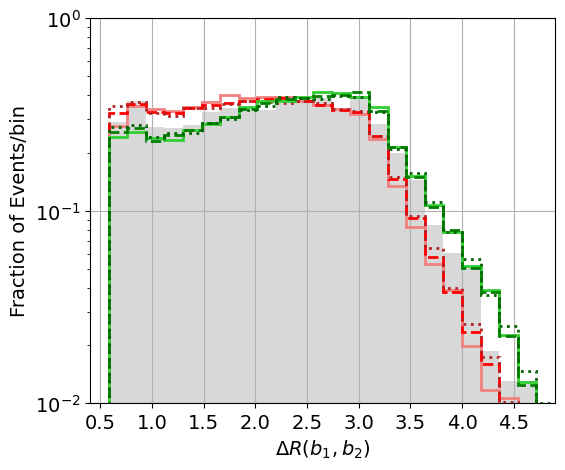

In [ ]:
plt.figure(figsize=(6, 5))
var = 'dR-b1b2'
threshold = 0.95

linestyles = ['-', '--', ':']
colors_SLQ = ['lightcoral', 'red', 'firebrick']
colors_VLQ = ['limegreen', 'green', 'darkgreen']
list_mass = [2,5,8]


# SM
plt.hist(X_SM_raw[var].tolist(), bins=25, range=[0.4, 4.9], lw=2, density=True, color='gray', alpha=0.3, label='SM Background', zorder=1)


# loop
for idx, i in enumerate(list_mass):

    # data
    y_pred_SLQ = xgb_clf.predict_proba(df_SLQ_norm[masses_SLQ[i]])[:,1]
    y_pred_VLQ = xgb_clf.predict_proba(df_VLQ_norm[masses_VLQ[i]])[:,1]

    mask_SLQ = y_pred_SLQ > threshold
    mask_VLQ = y_pred_VLQ > threshold

    X_SLQ_mask_norm = df_SLQ_norm[masses_SLQ[i]][mask_SLQ]
    X_VLQ_mask_norm = df_VLQ_norm[masses_VLQ[i]][mask_VLQ]

    X_SLQ_raw = pd.DataFrame(scaler.inverse_transform(X_SLQ_mask_norm), columns=X_SLQ_mask_norm.columns)
    X_VLQ_raw = pd.DataFrame(scaler.inverse_transform(X_VLQ_mask_norm), columns=X_VLQ_mask_norm.columns)

    # SLQ
    plt.hist(X_SLQ_raw[var].tolist(), bins=25, range=[0.4, 4.9], linewidth=2, density=True, color=colors_SLQ[idx], histtype='step', linestyle = linestyles[idx],
             label=f'SLQ ($m_{{LQ}}$={masses_SLQ[i]} GeV)', zorder=2)

    # VLQ
    plt.hist(X_VLQ_raw[var].tolist(), bins=25, range=[0.4, 4.9], linewidth=2, density=True, color=colors_VLQ[idx], histtype='step', linestyle = linestyles[idx],
             label=f'VLQ ($m_{{LQ}}$={masses_VLQ[i]} GeV)', zorder=3)


plt.xlabel(r"$\Delta R(b_1, b_2)$", fontsize=14)
plt.ylabel("Fraction of Events/bin", fontsize=14)

plt.yscale('log')
plt.ylim(1e-2,1e-0)
plt.xlim(0.4,4.9)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.legend(fontsize=11, loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0.)
plt.grid()
plt.savefig(mainfolder + "saved-results/dR-b1b2-all_sectors.pdf", bbox_inches='tight')
plt.show()

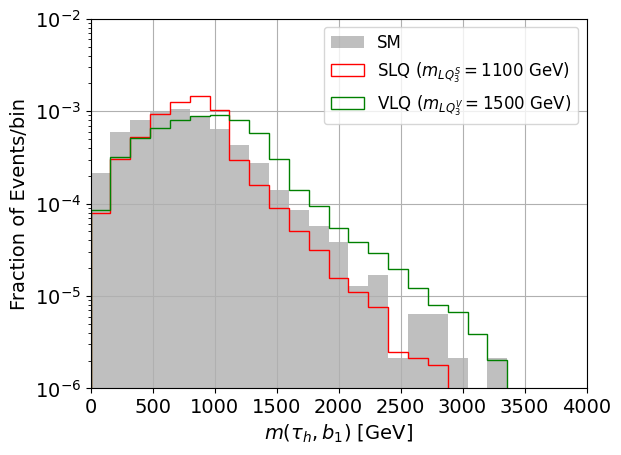

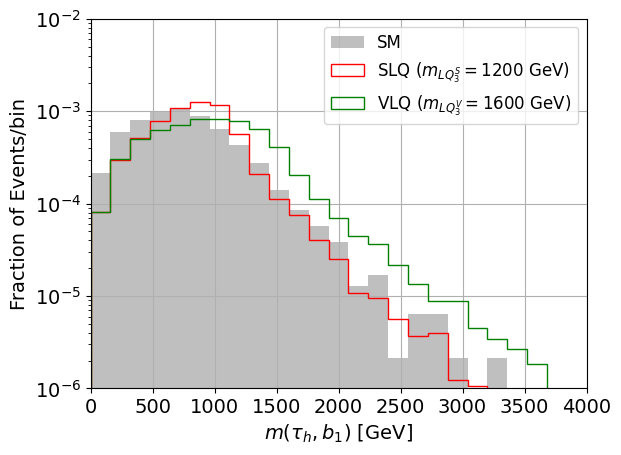

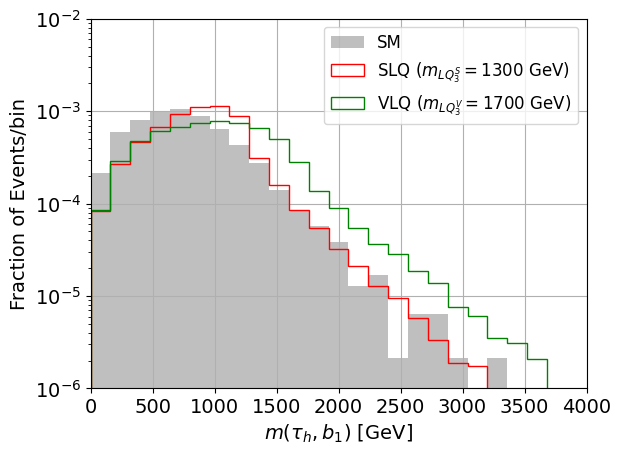

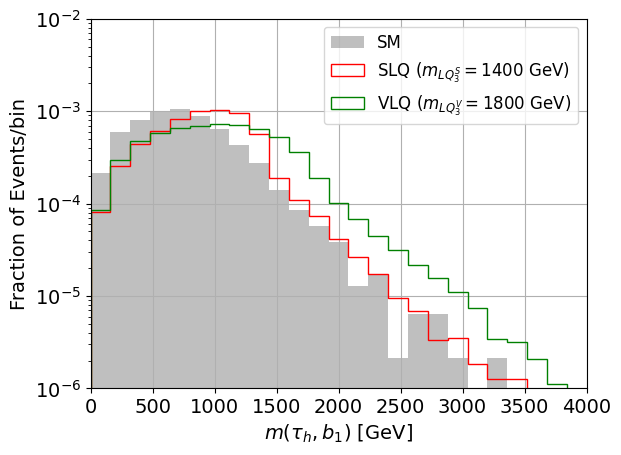

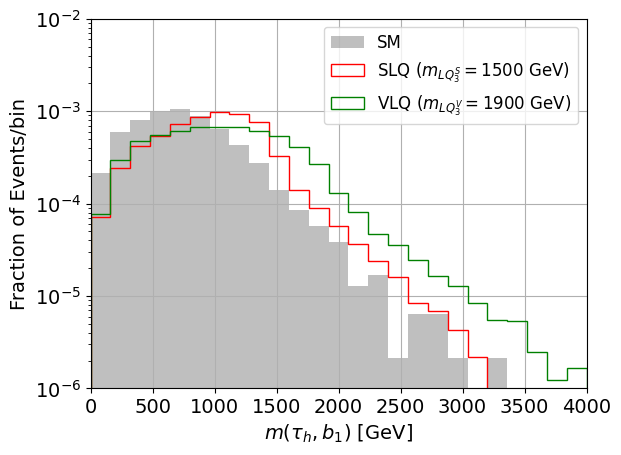

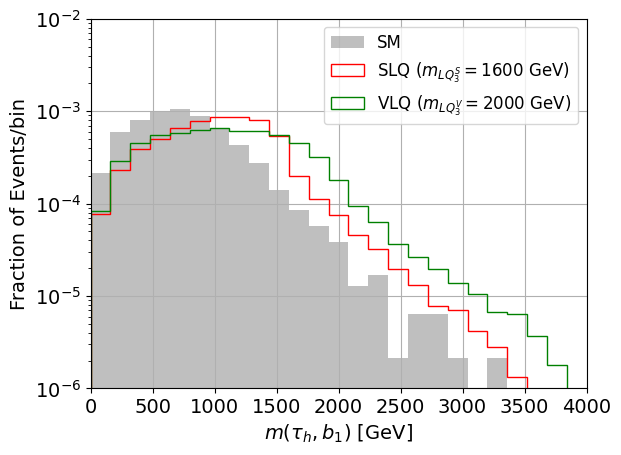

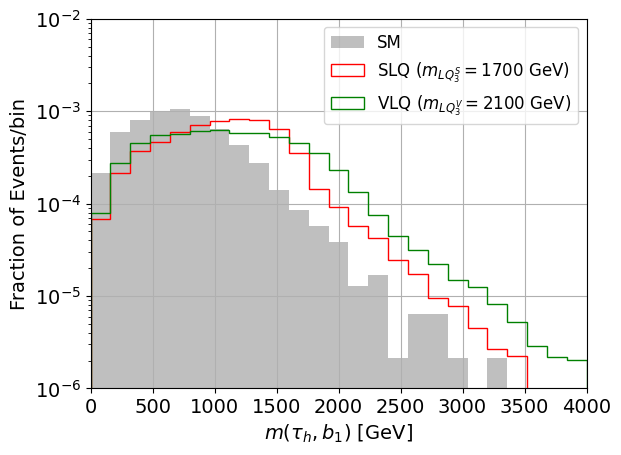

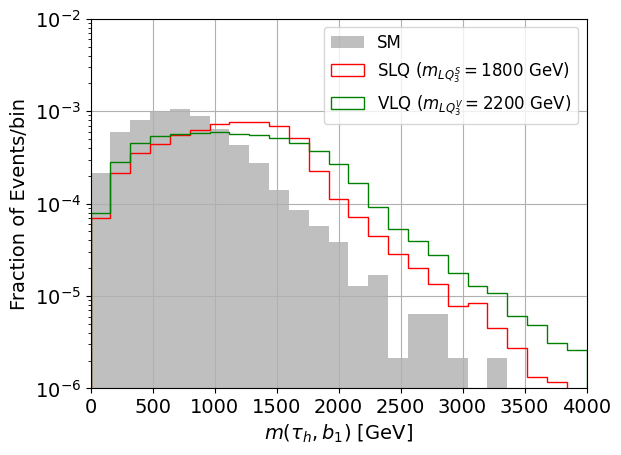

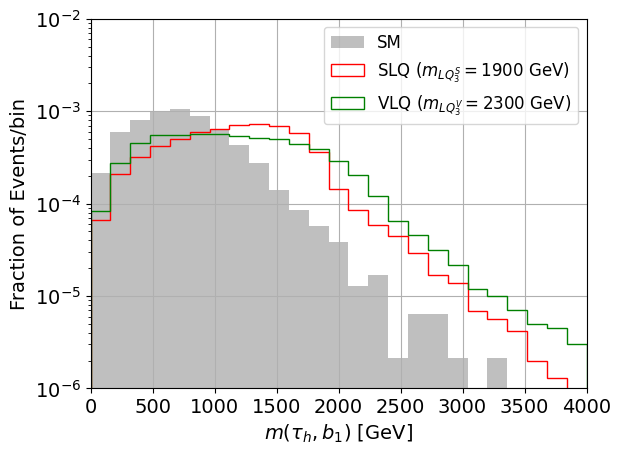

In [ ]:
for i in range(1,len(masses_SLQ)):

    y_pred_SLQ = xgb_clf.predict_proba(df_SLQ_norm[masses_SLQ[i]])[:,1]
    y_pred_VLQ = xgb_clf.predict_proba(df_VLQ_norm[masses_VLQ[i]])[:,1]

    mask_SLQ = y_pred_SLQ > threshold
    mask_VLQ = y_pred_VLQ > threshold

    X_SLQ_mask_norm = df_SLQ_norm[masses_SLQ[i]][mask_SLQ]
    X_VLQ_mask_norm = df_VLQ_norm[masses_VLQ[i]][mask_VLQ]

    X_SLQ_raw = pd.DataFrame( scaler.inverse_transform(X_SLQ_mask_norm), columns=X_SLQ_mask_norm.columns )
    X_VLQ_raw = pd.DataFrame( scaler.inverse_transform(X_VLQ_mask_norm), columns=X_VLQ_mask_norm.columns )


    var = 'm-taub1'
    # plt.hist(X_SM_raw[var].tolist(), bins=25, range=[0, 4000], lw=3, density=True, edgecolor='blue', histtype='step', label='SM')
    plt.hist(X_SM_raw[var].tolist(), bins=25, range=[0, 4000], lw=3, density=True, color='gray', alpha=0.5, label='SM')
    plt.hist(X_SLQ_raw[var].tolist(), bins=25, range=[0, 4000], lw=3, density=True, edgecolor='red', histtype='step', label=f'SLQ ($m_{{LQ_3^S}}=${masses_SLQ[i]} GeV)')
    plt.hist(X_VLQ_raw[var].tolist(), bins=25, range=[0, 4000], lw=3, density=True, edgecolor='green', histtype='step', label=f'VLQ ($m_{{LQ_3^V}}=${masses_VLQ[i]} GeV)')

    plt.xlabel(r"$m(\tau_h, b_1)$ [GeV]", fontsize=14)
    plt.ylabel("Fraction of Events/bin", fontsize=14)

    plt.yscale('log')
    plt.ylim(1e-6,1e-2)
    plt.xlim(0,4000)

    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=12, loc='upper right')
    plt.grid()
    plt.savefig(mainfolder + f"saved-results/m-taub1-sector{i-1}.pdf", bbox_inches='tight')
    plt.show()

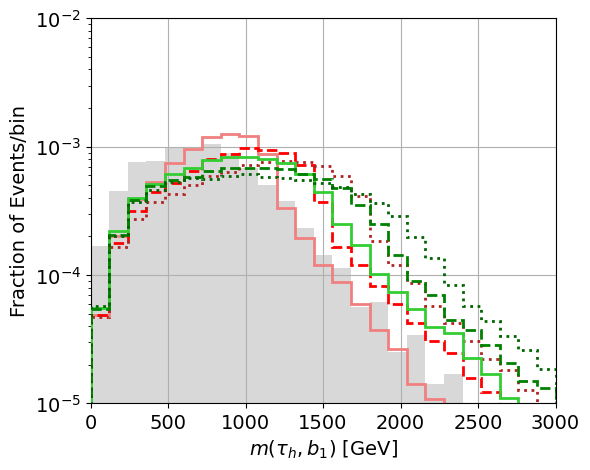

In [ ]:
plt.figure(figsize=(6, 5))
var = 'm-taub1'
threshold = 0.95

linestyles = ['-', '--', ':']
colors_SLQ = ['lightcoral', 'red', 'firebrick']
colors_VLQ = ['limegreen', 'green', 'darkgreen']
list_mass = [2,5,8]


# SM
plt.hist(X_SM_raw[var].tolist(), bins=25, range=[0, 3000], lw=2, density=True, color='gray', alpha=0.3, label='SM Background', zorder=1)


# loop
for idx, i in enumerate(list_mass):

    # data
    y_pred_SLQ = xgb_clf.predict_proba(df_SLQ_norm[masses_SLQ[i]])[:,1]
    y_pred_VLQ = xgb_clf.predict_proba(df_VLQ_norm[masses_VLQ[i]])[:,1]

    mask_SLQ = y_pred_SLQ > threshold
    mask_VLQ = y_pred_VLQ > threshold

    X_SLQ_mask_norm = df_SLQ_norm[masses_SLQ[i]][mask_SLQ]
    X_VLQ_mask_norm = df_VLQ_norm[masses_VLQ[i]][mask_VLQ]

    X_SLQ_raw = pd.DataFrame(scaler.inverse_transform(X_SLQ_mask_norm), columns=X_SLQ_mask_norm.columns)
    X_VLQ_raw = pd.DataFrame(scaler.inverse_transform(X_VLQ_mask_norm), columns=X_VLQ_mask_norm.columns)

    # SLQ
    plt.hist(X_SLQ_raw[var].tolist(), bins=25, range=[0, 3000], linewidth=2, density=True, color=colors_SLQ[idx], histtype='step', linestyle = linestyles[idx],
             label=f'SLQ ($m_{{LQ}}$={masses_SLQ[i]} GeV)', zorder=2)

    # VLQ
    plt.hist(X_VLQ_raw[var].tolist(), bins=25, range=[0, 3000], linewidth=2, density=True, color=colors_VLQ[idx], histtype='step', linestyle = linestyles[idx],
             label=f'VLQ ($m_{{LQ}}$={masses_VLQ[i]} GeV)', zorder=3)


plt.xlabel(r"$m(\tau_h, b_1)$ [GeV]", fontsize=14)
plt.ylabel("Fraction of Events/bin", fontsize=14)

plt.yscale('log')
plt.ylim(1e-5,1e-2)
plt.xlim(0,3000)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.legend(fontsize=11, loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0.)
plt.grid()
plt.savefig(mainfolder + "saved-results/m-taub1-all_sectors.pdf", bbox_inches='tight')
plt.show()

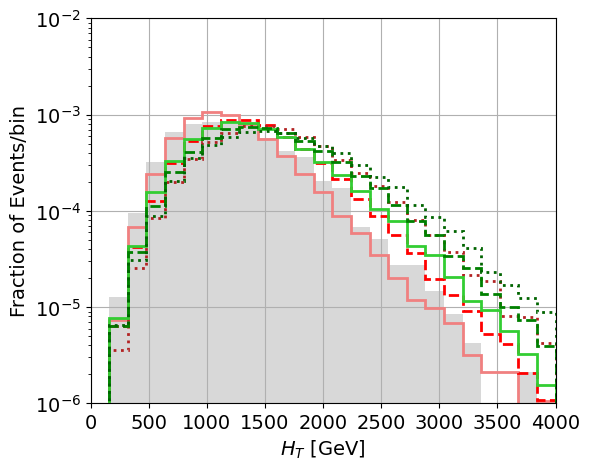

In [ ]:
plt.figure(figsize=(6, 5))
var = 'HT-pt'
threshold = 0.95

linestyles = ['-', '--', ':']
colors_SLQ = ['lightcoral', 'red', 'firebrick']
colors_VLQ = ['limegreen', 'green', 'darkgreen']
list_mass = [2,5,8]


# SM
plt.hist(X_SM_raw[var].tolist(), bins=25, range=[0, 4000], lw=2, density=True, color='gray', alpha=0.3, label='SM Background', zorder=1)


# loop
for idx, i in enumerate(list_mass):

    # data
    y_pred_SLQ = xgb_clf.predict_proba(df_SLQ_norm[masses_SLQ[i]])[:,1]
    y_pred_VLQ = xgb_clf.predict_proba(df_VLQ_norm[masses_VLQ[i]])[:,1]

    mask_SLQ = y_pred_SLQ > threshold
    mask_VLQ = y_pred_VLQ > threshold

    X_SLQ_mask_norm = df_SLQ_norm[masses_SLQ[i]][mask_SLQ]
    X_VLQ_mask_norm = df_VLQ_norm[masses_VLQ[i]][mask_VLQ]

    X_SLQ_raw = pd.DataFrame(scaler.inverse_transform(X_SLQ_mask_norm), columns=X_SLQ_mask_norm.columns)
    X_VLQ_raw = pd.DataFrame(scaler.inverse_transform(X_VLQ_mask_norm), columns=X_VLQ_mask_norm.columns)

    # SLQ
    plt.hist(X_SLQ_raw[var].tolist(), bins=25, range=[0, 4000], linewidth=2, density=True, color=colors_SLQ[idx], histtype='step', linestyle = linestyles[idx],
             label=f'SLQ ($m_{{LQ}}$={masses_SLQ[i]} GeV)', zorder=2)

    # VLQ
    plt.hist(X_VLQ_raw[var].tolist(), bins=25, range=[0, 4000], linewidth=2, density=True, color=colors_VLQ[idx], histtype='step', linestyle = linestyles[idx],
             label=f'VLQ ($m_{{LQ}}$={masses_VLQ[i]} GeV)', zorder=3)


plt.xlabel(r"$H_T$ [GeV]", fontsize=14)
plt.ylabel("Fraction of Events/bin", fontsize=14)

plt.yscale('log')
plt.ylim(1e-6,1e-2)
plt.xlim(0,4000)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.legend(fontsize=11, loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0.)
plt.grid()
plt.savefig(mainfolder + "saved-results/HT-all_sectors.pdf", bbox_inches='tight')
plt.show()

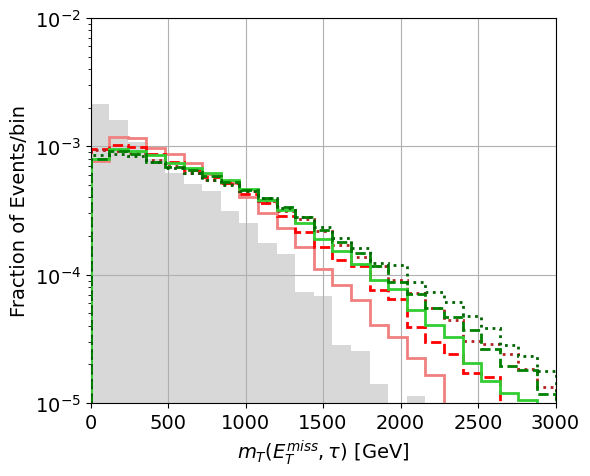

In [ ]:

plt.figure(figsize=(6, 5))
var = 'mT-METtau'
threshold = 0.95

linestyles = ['-', '--', ':']
colors_SLQ = ['lightcoral', 'red', 'firebrick']
colors_VLQ = ['limegreen', 'green', 'darkgreen']
list_mass = [2,5,8]


# SM
plt.hist(X_SM_raw[var].tolist(), bins=25, range=[0, 3000], lw=2, density=True, color='gray', alpha=0.3, label='SM Background', zorder=1)


# loop
for idx, i in enumerate(list_mass):

    # data
    y_pred_SLQ = xgb_clf.predict_proba(df_SLQ_norm[masses_SLQ[i]])[:,1]
    y_pred_VLQ = xgb_clf.predict_proba(df_VLQ_norm[masses_VLQ[i]])[:,1]

    mask_SLQ = y_pred_SLQ > threshold
    mask_VLQ = y_pred_VLQ > threshold

    X_SLQ_mask_norm = df_SLQ_norm[masses_SLQ[i]][mask_SLQ]
    X_VLQ_mask_norm = df_VLQ_norm[masses_VLQ[i]][mask_VLQ]

    X_SLQ_raw = pd.DataFrame(scaler.inverse_transform(X_SLQ_mask_norm), columns=X_SLQ_mask_norm.columns)
    X_VLQ_raw = pd.DataFrame(scaler.inverse_transform(X_VLQ_mask_norm), columns=X_VLQ_mask_norm.columns)

    # SLQ
    plt.hist(X_SLQ_raw[var].tolist(), bins=25, range=[0, 3000], linewidth=2, density=True, color=colors_SLQ[idx], histtype='step', linestyle = linestyles[idx],
             label=f'SLQ ($m_{{LQ}}$={masses_SLQ[i]} GeV)', zorder=2)

    # VLQ
    plt.hist(X_VLQ_raw[var].tolist(), bins=25, range=[0, 3000], linewidth=2, density=True, color=colors_VLQ[idx], histtype='step', linestyle = linestyles[idx],
             label=f'VLQ ($m_{{LQ}}$={masses_VLQ[i]} GeV)', zorder=3)


plt.xlabel(r"$m_T(E_T^{miss},\tau)$ [GeV]", fontsize=14)
plt.ylabel("Fraction of Events/bin", fontsize=14)

plt.yscale('log')
plt.ylim(1e-5,1e-2)
plt.xlim(0,3000)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.legend(fontsize=11, loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0.)
plt.grid()
plt.savefig(mainfolder + "saved-results/mT-METtau-all_sectors.pdf", bbox_inches='tight')
plt.show()

## Compute S_pred for pseudo-experiments

In [41]:
# output of all the background events
scores_B = xgb_clf.predict_proba( df_SM_norm )[:, 1]

# output of all the signal events (for the pdf of the general LQ case)
scores_S = xgb_clf.predict_proba( df_LQ_norm )[:, 1]

In [42]:
# output of all the signal events per class (to build the pseudo-experiments)
scores_S_SLQ = {mass: xgb_clf.predict_proba(df_SLQ_norm[mass])[:, 1] for mass in df_SLQ_norm}
scores_S_VLQ = {mass: xgb_clf.predict_proba(df_VLQ_norm[mass])[:, 1] for mass in df_VLQ_norm}

In [43]:
def Z_asimov(S, B):
    if S <= 0 or B <= 0:
        return 0
    return np.sqrt(2 * ((S+B) * np.log(1 + S/B) - S))

###### cut based

In [44]:
S_expected = S_expected_SLQ


n_pseudo = 1000

threshold = [0.5,0.6,0.7,0.8,0.9,0.95,0.99,0.995]


# to save
B_mean_cut = {}
B_std_cut  = {}
S_mean_cut = {}
S_std_cut  = {}
Z_cut = {}



for ii_S, S_it in enumerate(S_expected):
    print('\n----------------')
    print('S_expected = ', S_it)

    B_mean_cut[S_it] = []
    B_std_cut[S_it]  = []
    S_mean_cut[S_it] = []
    S_std_cut[S_it]  = []
    Z_cut[S_it] = []

    for th_it in threshold:

        print('threshold = ', th_it)

        B_estimates = []

        for n_it in range(n_pseudo):

            # Poisson
            N_B = np.random.poisson(B_expected)

            # Sample with replacements
            sample_scores = np.random.choice(scores_B, size=N_B, replace=True)

            # Cut-based (weight = 1)
            B_pass = np.sum(sample_scores > th_it)
            B_estimates.append(B_pass)


        mean_B = np.mean(B_estimates)
        std_B  = np.std(B_estimates)
        B_mean_cut[S_it].append(mean_B)
        B_std_cut[S_it].append(std_B)

        print("B =", mean_B, "+-", std_B)



        # just in case, lets not use the same pseudo experiments

        S_estimates = []

        for n_it in range(n_pseudo):

            # Poisson
            N_B = np.random.poisson(B_expected)
            N_S = np.random.poisson(S_it)

            # Sample with replacements
            sample_B = np.random.choice(scores_B, size=N_B, replace=True)
            sample_S = np.random.choice(scores_S_SLQ[masses_SLQ[ii_S]], size=N_S, replace=True)

            sample_all = np.concatenate([sample_B, sample_S])

            # Cut-based (weight = 1)
            S_pass = np.sum(sample_all > th_it)

            S_pseudo = S_pass - mean_B
            S_estimates.append(S_pseudo)


        mean_S = np.mean(S_estimates)
        std_S  = np.std(S_estimates)
        S_mean_cut[S_it].append(mean_S)
        S_std_cut[S_it].append(std_S)

        print("S =", mean_S, "+-", std_S)


        Z_val = Z_asimov(mean_S, mean_B)
        Z_cut[S_it].append(Z_val)

        print('Z = ', Z_val)

        print(' ')


----------------
S_expected =  2325
threshold =  0.5
B = 1109.861 +- 32.47684835386587
S = 2149.4209999999994 +- 56.66535516521539
Z =  52.18644855315448
 
threshold =  0.6
B = 863.255 +- 29.0801646315835
S = 2097.7229999999995 +- 57.077609585545886
Z =  55.71129449316284
 
threshold =  0.7
B = 649.574 +- 25.528308287076133
S = 2043.2359999999999 +- 51.58327151315628
Z =  59.766275404155806
 
threshold =  0.8
B = 452.209 +- 21.673701091414912
S = 1948.2670000000003 +- 50.095083830651504
Z =  64.16844175526532
 
threshold =  0.9
B = 248.396 +- 15.569302617651184
S = 1781.8929999999996 +- 44.88729752390981
Z =  70.4777950459524
 
threshold =  0.95
B = 134.726 +- 11.367186283333268
S = 1589.8840000000002 +- 41.63258219231663
Z =  74.92705573038934
 
threshold =  0.99
B = 30.961 +- 5.578842084160476
S = 1045.9580000000003 +- 32.37580020632694
Z =  74.5140085339368
 
threshold =  0.995
B = 15.747 +- 4.000873779563659
S = 787.9160000000003 +- 26.981798142451513
Z =  68.88414887150265
 

---

###### weighted

In [45]:
S_expected = S_expected_SLQ


n_pseudo = 1000


# to save
B_mean_weight = {}
B_std_weight  = {}
S_mean_weight = {}
S_std_weight  = {}
Z_weight = {}


for ii_S, S_it in enumerate(S_expected):
    print('\n----------------')
    print('S_expected = ', S_it)

    B_mean_weight[S_it] = []
    B_std_weight[S_it]  = []
    S_mean_weight[S_it] = []
    S_std_weight[S_it]  = []
    Z_weight[S_it] = []


    B_estimates = []

    for n_it in range(n_pseudo):

        # Poisson
        N_B = np.random.poisson(B_expected)

        # Sample with replacements
        sample_scores = np.random.choice(scores_B, size=N_B, replace=True)

        # Weighted (weight = score)
        B_pass = np.sum(sample_scores)
        B_estimates.append(B_pass)


    mean_B = np.mean(B_estimates)
    std_B  = np.std(B_estimates)
    B_mean_weight[S_it].append(mean_B)
    B_std_weight[S_it].append(std_B)

    print("B =", mean_B, "+-", std_B)



    # just in case, lets not use the same pseudo experiments

    S_estimates = []

    for n_it in range(n_pseudo):

        # Poisson
        N_B = np.random.poisson(B_expected)
        N_S = np.random.poisson(S_it)

        # Sample with replacements
        sample_B = np.random.choice(scores_B, size=N_B, replace=True)
        sample_S = np.random.choice(scores_S_SLQ[masses_SLQ[ii_S]], size=N_S, replace=True)

        sample_all = np.concatenate([sample_B, sample_S])

        # Weighted (weight = score)
        S_pass = np.sum(sample_all)

        S_pseudo = S_pass - mean_B
        S_estimates.append(S_pseudo)


    mean_S = np.mean(S_estimates)
    std_S  = np.std(S_estimates)
    S_mean_weight[S_it].append(mean_S)
    S_std_weight[S_it].append(std_S)

    print("S =", mean_S, "+-", std_S)


    Z_val = Z_asimov(mean_S, mean_B)
    Z_weight[S_it].append(Z_val)

    print('Z = ', Z_val)

    print(' ')


----------------
S_expected =  2325
B = 1710.814 +- 29.273087
S = 2072.4004 +- 52.619102
Z =  43.127167
 

----------------
S_expected =  1314
B = 1712.4952 +- 28.436075
S = 1214.867 +- 44.57516
Z =  26.632275
 

----------------
S_expected =  742
B = 1712.565 +- 28.19944
S = 700.252 +- 38.229584
Z =  15.929095
 

----------------
S_expected =  419
B = 1711.5828 +- 27.586582
S = 401.17932 +- 35.114834
Z =  9.351057
 

----------------
S_expected =  237
B = 1711.7184 +- 28.2244
S = 227.75061 +- 32.29746
Z =  5.3890567
 

----------------
S_expected =  137
B = 1712.919 +- 28.2545
S = 132.22185 +- 30.82807
Z =  3.154925
 

----------------
S_expected =  80
B = 1712.5957 +- 29.37303
S = 78.05528 +- 30.11438
Z =  1.8720721
 

----------------
S_expected =  46
B = 1712.4305 +- 28.464142
S = 43.50732 +- 30.526316
Z =  1.046886
 

----------------
S_expected =  27
B = 1712.2343 +- 27.982422
S = 26.483196 +- 30.105602
Z =  0.63839406
 

----------------
S_expected =  16
B = 1712.2307 +- 28.467

###### binned likelihood fit

fit de mezcla:

f(x)=μS pS(x)+μB pB(x)


donde:

pS(x) = pdf del score para señal

pB(x) = pdf del score para background

μS, μB = yields a ajustar



maximizamos:

L(μS,μB)= Prod_i=1^N ( μS pS(xi) + μB pB (xi )) e^−(μS+μB)

In [46]:
bins = np.linspace(0, 1, 30)

# normalized histograms of pure signal and pure background
hist_B, _ = np.histogram(scores_B, bins=bins, density=True)
hist_S, _ = np.histogram(scores_S, bins=bins, density=True) # the signal pdf is a generic (mixture of all) to be general


bin_width = bins[1] - bins[0]

pS = hist_S * bin_width
pB = hist_B * bin_width

eventos esperados en el bin i:

λi = μS pS,i + μB pB,i



Likelihood binned:

log L = Sum_i ( ni log(λi) − λi )

q0 = −2 ln ( L(μS=0) / L(μS_hat) )

Z = np.sqrt{q0}

In [47]:
# FOR A LQ MIXTURE #

S_expected = S_expected_SLQ


n_pseudo = 1000


# to save
S_mean_fit = {}
S_std_fit  = {}
Z_fit = {}



for S_it in S_expected:
    print('\n----------------')
    print('S_expected = ', S_it)

    S_mean_fit[S_it] = []
    S_std_fit[S_it]  = []
    Z_fit[S_it] = []


    muS_fits = []
    muB_fits = []

    for n_it in range(n_pseudo):

        # 1) pseudo experiment
        N_B = np.random.poisson(B_expected)
        N_S = np.random.poisson(S_it)

        sample_B = np.random.choice(scores_B, N_B, replace=True)
        sample_S = np.random.choice(scores_S, N_S, replace=True)

        data_scores = np.concatenate([sample_B, sample_S])

        hist_data, _ = np.histogram(data_scores, bins=bins)

        # 2) Define likelihood for this pseudo (gotta do it for the minimizer)
        def neg_logL(params):
            mu_S, mu_B = params

            lambda_i = mu_S * pS + mu_B * pB
            lambda_i = np.clip(lambda_i, 1e-10, None)

            return -np.sum(hist_data * np.log(lambda_i) - lambda_i)

        # 3) Minimizar
        result = minimize(
            neg_logL,
            x0=[S_it, B_expected],
            bounds=[(0, None), (0, None)]
        )

        muS_fit, muB_fit = result.x

        muS_fits.append(muS_fit)
        muB_fits.append(muB_fit)


    mean_muB = np.mean(muB_fits)

    mean_muS = np.mean(muS_fits)
    std_muS  = np.std(muS_fits)

    S_mean_fit[S_it].append(mean_muS)
    S_std_fit[S_it].append(std_muS)


    # significance
    logL_hat = -neg_logL([mean_muS, mean_muB])
    logL_null = -neg_logL([0, mean_muB])

    q0 = -2 * (logL_null - logL_hat)

    Z = np.sqrt(q0)

    Z_fit[S_it].append(Z)

    print("S =", mean_muS, "+-", std_muS)
    print("Z =", Z)
    print('')



----------------
S_expected =  2325
S = 2329.285725561269 +- 35.71573816426899
Z = 94.93021209135813


----------------
S_expected =  1314
S = 1315.660055286312 +- 33.610189411225804
Z = 65.12540872148713


----------------
S_expected =  742
S = 741.7349638590465 +- 29.123617321692763
Z = 39.16656981278752


----------------
S_expected =  419
S = 419.34576096032885 +- 24.676626034728482
Z = 25.704847108937734


----------------
S_expected =  237
S = 237.98020498966932 +- 19.37933598688409
Z = 16.62799429150019


----------------
S_expected =  137
S = 136.85391438525625 +- 16.620528159259063
Z = 10.751164635566576


----------------
S_expected =  80
S = 80.43372222260042 +- 14.828381200740203
Z = 7.159945832439836


----------------
S_expected =  46
S = 46.54003129437883 +- 13.376714698251085
Z = 3.851582759239042


----------------
S_expected =  27
S = 27.617493624878954 +- 12.532841602894374
Z = 3.442273459337799


----------------
S_expected =  16
S = 16.60211740165326 +- 11.6746123

/tmp/ipykernel_2784/1823815906.py:78: RuntimeWarning: invalid value encountered in sqrt
  Z = np.sqrt(q0)


In [48]:
# FOR SLQ #

S_expected = S_expected_SLQ


n_pseudo = 1000


# to save
S_mean_fit_N = {}
S_std_fit_N  = {}
Z_fit_N = {}



for ii_S, S_it in enumerate(S_expected):
    print('\n----------------')
    print('S_expected = ', S_it)

    S_mean_fit_N[S_it] = []
    S_std_fit_N[S_it]  = []
    Z_fit_N[S_it] = []


    muS_fits = []
    muB_fits = []

    for n_it in range(n_pseudo):

        # 1) pseudo experiment
        N_B = np.random.poisson(B_expected)
        N_S = np.random.poisson(S_it)

        sample_B = np.random.choice(scores_B, N_B, replace=True)
        sample_S = np.random.choice(scores_S_SLQ[masses_SLQ[ii_S]], N_S, replace=True)

        data_scores = np.concatenate([sample_B, sample_S])

        hist_data, _ = np.histogram(data_scores, bins=bins)

        # 2) Define likelihood for this pseudo (gotta do it for the minimizer)
        def neg_logL(params):
            mu_S, mu_B = params

            lambda_i = mu_S * pS + mu_B * pB
            lambda_i = np.clip(lambda_i, 1e-10, None)

            return -np.sum(hist_data * np.log(lambda_i) - lambda_i)

        # 3) Minimizar
        result = minimize(
            neg_logL,
            x0=[S_it, B_expected],
            bounds=[(0, None), (0, None)]
        )

        muS_fit, muB_fit = result.x

        muS_fits.append(muS_fit)
        muB_fits.append(muB_fit)


    mean_muB = np.mean(muB_fits)

    mean_muS = np.mean(muS_fits)
    std_muS  = np.std(muS_fits)

    S_mean_fit_N[S_it].append(mean_muS)
    S_std_fit_N[S_it].append(std_muS)


    # significance
    logL_hat = -neg_logL([mean_muS, mean_muB])
    logL_null = -neg_logL([0, mean_muB])

    q0 = -2 * (logL_null - logL_hat)

    Z = np.sqrt(q0)

    Z_fit_N[S_it].append(Z)

    print("S =", mean_muS, "+-", std_muS)
    print("Z =", Z)
    print('')



----------------
S_expected =  2325
S = 1863.1722971617326 +- 51.37584018816039
Z = 78.515305879842


----------------
S_expected =  1314
S = 1144.7158602015306 +- 38.65936382907816
Z = 56.74864557127481


----------------
S_expected =  742
S = 686.6029574793384 +- 34.277647623017934
Z = 39.33848724463067


----------------
S_expected =  419
S = 408.05879214104357 +- 23.625913735719855
Z = 23.060538838210586


----------------
S_expected =  237
S = 239.62148302214754 +- 19.914321400158165
Z = 14.759839857200639


----------------
S_expected =  137
S = 141.17299262182513 +- 16.270355730267276
Z = 6.350018378021001


----------------
S_expected =  80
S = 84.6066713941136 +- 14.391184765398902
Z = 5.8888416444625005


----------------
S_expected =  46
S = 49.768207331424215 +- 13.725958398917479
Z = 4.75498414126286


----------------
S_expected =  27
S = 29.60912803470449 +- 12.924817517652581
Z = 1.7384587923875718


----------------
S_expected =  16
S = 17.704033580173043 +- 11.277776

In [49]:
# FOR VLQ #

S_expected = S_expected_SLQ # same number of events


n_pseudo = 1000


# to save
S_mean_fit_V = {}
S_std_fit_V  = {}
Z_fit_V = {}



for ii_S, S_it in enumerate(S_expected):
    print('\n----------------')
    print('S_expected = ', S_it)

    S_mean_fit_V[S_it] = []
    S_std_fit_V[S_it]  = []
    Z_fit_V[S_it] = []


    muS_fits = []
    muB_fits = []

    for n_it in range(n_pseudo):

        # 1) pseudo experiment
        N_B = np.random.poisson(B_expected)
        N_S = np.random.poisson(S_it)

        sample_B = np.random.choice(scores_B, N_B, replace=True)
        sample_S = np.random.choice(scores_S_VLQ[masses_VLQ[ii_S]], N_S, replace=True)

        data_scores = np.concatenate([sample_B, sample_S])

        hist_data, _ = np.histogram(data_scores, bins=bins)

        # 2) Define likelihood for this pseudo (gotta do it for the minimizer)
        def neg_logL(params):
            mu_S, mu_B = params

            lambda_i = mu_S * pS + mu_B * pB
            lambda_i = np.clip(lambda_i, 1e-10, None)

            return -np.sum(hist_data * np.log(lambda_i) - lambda_i)

        # 3) Minimizar
        result = minimize(
            neg_logL,
            x0=[S_it, B_expected],
            bounds=[(0, None), (0, None)]
        )

        muS_fit, muB_fit = result.x

        muS_fits.append(muS_fit)
        muB_fits.append(muB_fit)


    mean_muB = np.mean(muB_fits)

    mean_muS = np.mean(muS_fits)
    std_muS  = np.std(muS_fits)

    S_mean_fit_V[S_it].append(mean_muS)
    S_std_fit_V[S_it].append(std_muS)


    # significance
    logL_hat = -neg_logL([mean_muS, mean_muB])
    logL_null = -neg_logL([0, mean_muB])

    q0 = -2 * (logL_null - logL_hat)

    Z = np.sqrt(q0)

    Z_fit_V[S_it].append(Z)

    print("S =", mean_muS, "+-", std_muS)
    print("Z =", Z)
    print('')



----------------
S_expected =  2325
S = 2272.7060622496047 +- 67.11327150885307
Z = 90.87660804591715


----------------
S_expected =  1314
S = 1296.2610623818089 +- 36.698396649049336
Z = 60.37579266848905


----------------
S_expected =  742
S = 741.2798061784113 +- 27.326800316220893
Z = 40.70217651138383


----------------
S_expected =  419
S = 424.5258920299184 +- 25.36554031705962
Z = 27.292194594497886


----------------
S_expected =  237
S = 243.71650511813183 +- 19.563048917182304
Z = 14.119049607630766


----------------
S_expected =  137
S = 142.24799450338864 +- 16.993710434061406
Z = 8.358597531961767


----------------
S_expected =  80
S = 83.03358337148538 +- 15.027546372338328
Z = 7.196573196114882


----------------
S_expected =  46
S = 47.4717104373836 +- 13.577163257334433
Z = 4.410000956682068


----------------
S_expected =  27
S = 27.802465691320084 +- 12.863744022286348
Z = 1.0862265393440627


----------------
S_expected =  16
S = 16.85930932972662 +- 11.354597

/tmp/ipykernel_2784/2772170123.py:78: RuntimeWarning: invalid value encountered in sqrt
  Z = np.sqrt(q0)


In [50]:
# mean between scalar and vector
S_mean_fit_both = []
S_std_fit_both = []

for i in S_mean_fit_N:

    S_mean_fit_both.append( np.mean([S_mean_fit_N[i][0], S_mean_fit_V[i][0]]) )
    S_std_fit_both.append( np.mean([S_std_fit_N[i][0], S_std_fit_V[i][0]]) )


In [51]:
# data
x_old = masses_SLQ
y_old = np.array(S_mean_fit_both)
err_old = np.array(S_std_fit_both)

# functions, interpolate
f_mean = interp1d(x_old, y_old, kind='cubic')
f_std = interp1d(x_old, err_old, kind='cubic')

# final set
x_final = []
y_final = []
err_final = []

# to fill
for i in range(len(x_old) - 1): # go by step
    x_start, x_end = x_old[i], x_old[i+1]
    y_start, y_end = y_old[i], y_old[i+1]

    # save the original point of the step
    if i == 0:
        x_final.append(x_start)
        y_final.append(y_start)
        err_final.append(err_old[i])

    # average error for this step
    avg_err = (err_old[i] + err_old[i+1]) / 2.0

    # distance between y values
    delta_y_total = abs(y_end - y_start)

    # ideally we need extra steps
    ideal_step_y = 2.0 * avg_err

    # how many ideal extra steps we need
    if ideal_step_y > 0:
        num_pasos = int(np.round(delta_y_total / ideal_step_y))
    else:
        num_pasos = 1

    # if less than 1, then we dont need to add more
    num_pasos = max(1, num_pasos)

    # generate intermediate steps, homogeneously
    # use [1:] to exclude the 1st one, that we already have
    x_intermedios = np.linspace(x_start, x_end, num_pasos + 1)[1:]

    # evaluate
    for x_val in x_intermedios:
        x_final.append(x_val)
        y_final.append(float(f_mean(x_val)))
        err_final.append(float(f_std(x_val)))


# final results
S_mean_fit_both_NEW = list(y_final)
S_std_fit_both_NEW = list(err_final)
masses_NEW = list(x_final)

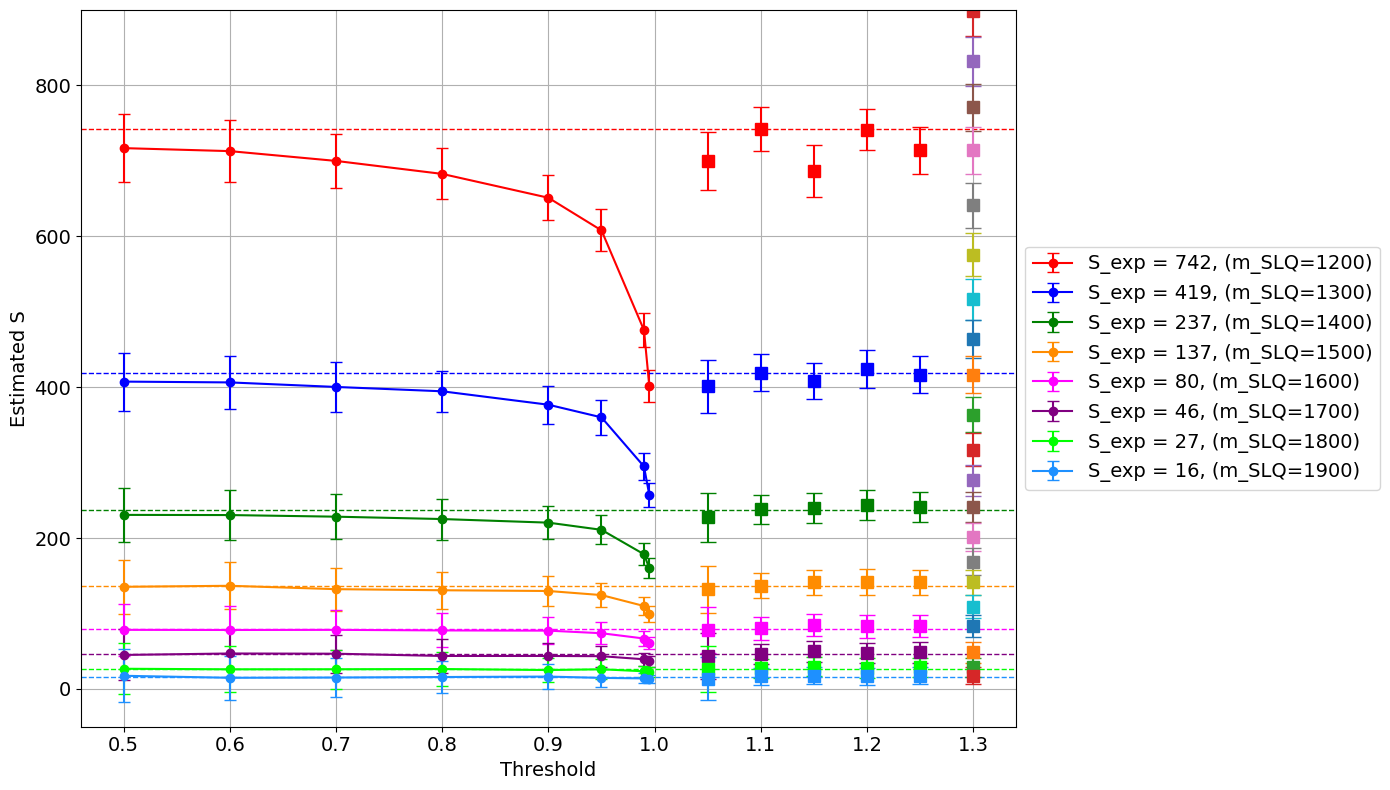

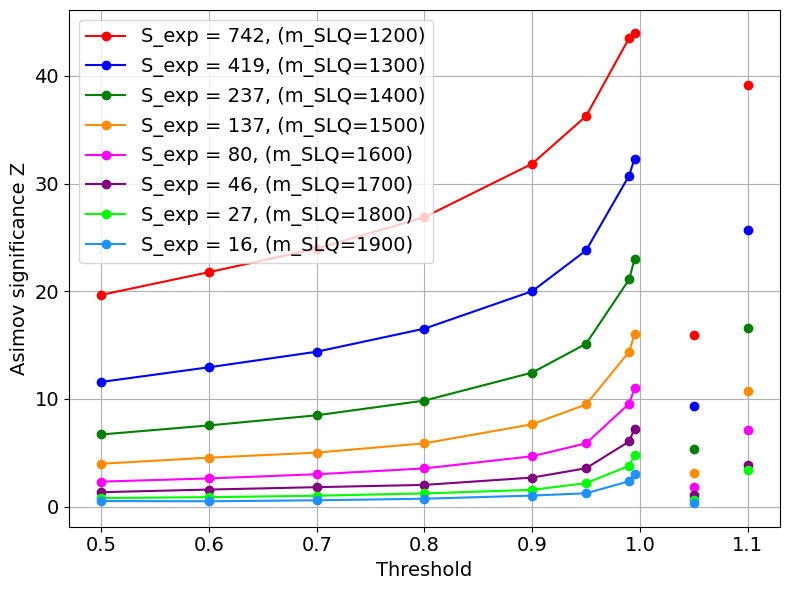

In [52]:
cols = ['red', 'blue', 'green', 'darkorange', 'magenta', 'purple', 'lime', 'dodgerblue']

plt.figure(figsize=(14,8))

S_expected = S_expected_SLQ
for ii, S_it in enumerate(S_expected[2:10]):

    # ---- CUT-BASED ----
    plt.errorbar(threshold, S_mean_cut[S_it], yerr=S_std_cut[S_it], color=cols[ii], fmt='o-', capsize=4, label=f"S_exp = {S_it}, (m_SLQ={masses_SLQ[ii+2]})")

    plt.axhline(y=S_it, color=cols[ii], linestyle='--', lw=1)

    # ---- WEIGHTED ----
    plt.errorbar([1.05], [S_mean_weight[S_it]], yerr=[S_std_weight[S_it]], color=cols[ii], fmt='s', markersize=8, capsize=6, linestyle='None')

    # ---- FIT ----
    plt.errorbar([1.1], [S_mean_fit[S_it]], yerr=[S_std_fit[S_it]], color=cols[ii], fmt='s', markersize=8, capsize=6, linestyle='None')
    plt.errorbar([1.15], [S_mean_fit_N[S_it]], yerr=[S_std_fit_N[S_it]], color=cols[ii], fmt='s', markersize=8, capsize=6, linestyle='None')
    plt.errorbar([1.2], [S_mean_fit_V[S_it]], yerr=[S_std_fit_V[S_it]], color=cols[ii], fmt='s', markersize=8, capsize=6, linestyle='None')
    plt.errorbar([1.25], [S_mean_fit_both[ii+2]], yerr=[S_std_fit_both[ii+2]], color=cols[ii], fmt='s', markersize=8, capsize=6, linestyle='None')



for ii, S_it in enumerate(S_std_fit_both_NEW):
    # ---- FIT THE INTERPOLATION ----
    plt.errorbar([1.3], [S_mean_fit_both_NEW[ii]], yerr=[S_std_fit_both_NEW[ii]], fmt='s', markersize=8, capsize=6, linestyle='None')

plt.ylim(-50,900)
plt.xlabel("Threshold", fontsize=14)
plt.ylabel("Estimated S", fontsize=14)
# plt.title("Cut-based (weight = 1)", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=14)
plt.tight_layout()
plt.show()





cols = ['red', 'blue', 'green', 'darkorange', 'magenta', 'purple', 'lime', 'dodgerblue']

plt.figure(figsize=(8,6))

S_expected = S_expected_SLQ
for ii, S_it in enumerate(S_expected[2:10]):

    plt.plot(threshold, Z_cut[S_it], 'o-', color=cols[ii], label=f"S_exp = {S_it}, (m_SLQ={masses_SLQ[ii+2]})")

    plt.plot([1.05], [Z_weight[S_it]], 'o-', color=cols[ii])

    plt.plot([1.1], [Z_fit[S_it]], 'o-', color=cols[ii])

plt.xlabel("Threshold", fontsize=14)
plt.ylabel("Asimov significance Z", fontsize=14)
# plt.title("Cut-based (weight = 1)", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

/tmp/ipykernel_6678/1963397024.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=14)


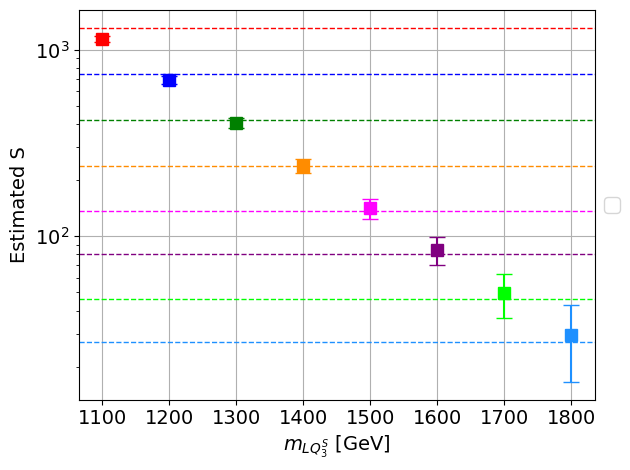

In [ ]:
S_expected = S_expected_SLQ
for ii, S_it in enumerate(S_expected[1:9]):
    plt.errorbar(masses_SLQ[ii+1], [S_mean_fit_N[S_it]], yerr=[S_std_fit_N[S_it]], color=cols[ii], fmt='s', markersize=8, capsize=6, linestyle='None')
    plt.axhline(y=S_it, color=cols[ii], linestyle='--', lw=1)

# S_expected = S_expected_VLQ
# for ii, S_it in enumerate(S_expected[1:9]):
#     plt.errorbar(masses_VLQ[ii+1], [S_mean_fit_V[S_it]], yerr=[S_std_fit_V[S_it]], color=cols[ii], fmt='s', markersize=8, capsize=6, linestyle='None')
#     plt.axhline(y=S_it, color=cols[ii], linestyle=':', lw=1)

plt.yscale('log')
plt.xlabel(r"$m_{LQ^S_3}$ [GeV]", fontsize=14)
plt.ylabel("Estimated S", fontsize=14)
# plt.title("Cut-based (weight = 1)", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=14)
plt.tight_layout()
plt.show()

### beta plot

In [ ]:
S_expected_SLQ_beta0 = [296, 98, 55, 31, 18, 11, 6, 4, 2]
S_expected_SLQ_beta01 = [1353, 448, 253, 143, 83, 48, 28, 16, 10]
S_expected_SLQ_beta03 = [1999, 662, 374, 211, 123, 71, 41, 24, 14]
S_expected_SLQ_beta05 = [2241, 742, 419, 237, 137, 80, 46, 27, 16]
S_expected_SLQ_beta07 = [2274, 753, 426, 241, 140, 81, 47, 27, 16]
S_expected_SLQ_beta09 = [1951, 646, 365, 206, 120, 69, 40, 23, 14]
S_expected_SLQ_beta1 = [809, 268, 151, 85, 50, 29, 17, 10, 6]

S_expected_SLQ_betas = {}
S_expected_SLQ_betas['beta0'] = S_expected_SLQ_beta0
S_expected_SLQ_betas['beta01'] = S_expected_SLQ_beta01
S_expected_SLQ_betas['beta03'] = S_expected_SLQ_beta03
S_expected_SLQ_betas['beta05'] = S_expected_SLQ_beta05
S_expected_SLQ_betas['beta07'] = S_expected_SLQ_beta07
S_expected_SLQ_betas['beta09'] = S_expected_SLQ_beta09
S_expected_SLQ_betas['beta1'] = S_expected_SLQ_beta1



S_expected_VLQ_beta0 = [316, 105, 62, 36, 22, 13, 8, 5, 3]
S_expected_VLQ_beta01 = [1446, 480, 281, 165, 99, 59, 36, 22, 13]
S_expected_VLQ_beta03 = [2135, 709, 416, 243, 146, 87, 53, 32, 20]
S_expected_VLQ_beta05 = [2394, 796, 466, 273, 163, 98, 59, 36, 22]
S_expected_VLQ_beta07 = [2430, 808, 473, 277, 166, 99, 60, 37, 22]
S_expected_VLQ_beta09 = [2084, 692, 406, 238, 142, 85, 52, 32, 19]
S_expected_VLQ_beta1 = [863, 287, 168, 98, 59, 35, 21, 13, 8]

S_expected_VLQ_betas = {}
S_expected_VLQ_betas['beta0'] = S_expected_VLQ_beta0
S_expected_VLQ_betas['beta01'] = S_expected_VLQ_beta01
S_expected_VLQ_betas['beta03'] = S_expected_VLQ_beta03
S_expected_VLQ_betas['beta05'] = S_expected_VLQ_beta05
S_expected_VLQ_betas['beta07'] = S_expected_VLQ_beta07
S_expected_VLQ_betas['beta09'] = S_expected_VLQ_beta09
S_expected_VLQ_betas['beta1'] = S_expected_VLQ_beta1

In [ ]:
beta_label = ["beta0", "beta01", "beta03", "beta05", "beta07", "beta09", "beta1"]


n_pseudo =500


# to save
S_mean_SLQ_fit = {}
S_std_SLQ_fit  = {}


for beta_it in beta_label:
    print('\n----------------')
    print('beta = ', beta_it)

    S_expected = S_expected_SLQ_betas[beta_it]

    S_mean_SLQ_fit[beta_it] = []
    S_std_SLQ_fit[beta_it]  = []


    for ii_S, S_it in enumerate(S_expected):

        muS_fits = []
        muB_fits = []

        for n_it in range(n_pseudo):

            # 1) pseudo experiment
            N_B = np.random.poisson(B_expected)
            N_S = np.random.poisson(S_it)

            sample_B = np.random.choice(scores_B, N_B, replace=True)
            sample_S = np.random.choice(scores_S_SLQ[masses_SLQ[ii_S]], N_S, replace=True)

            data_scores = np.concatenate([sample_B, sample_S])

            hist_data, _ = np.histogram(data_scores, bins=bins)

            # 2) Define likelihood for this pseudo (gotta do it for the minimizer)
            def neg_logL(params):
                mu_S, mu_B = params

                lambda_i = mu_S * pS + mu_B * pB
                lambda_i = np.clip(lambda_i, 1e-10, None)

                return -np.sum(hist_data * np.log(lambda_i) - lambda_i)

            # 3) Minimizar
            result = minimize(
                neg_logL,
                x0=[S_it, B_expected],
                bounds=[(0, None), (0, None)]
            )

            muS_fit, muB_fit = result.x

            muS_fits.append(muS_fit)
            muB_fits.append(muB_fit)


        mean_muB = np.mean(muB_fits)

        mean_muS = np.mean(muS_fits)
        std_muS  = np.std(muS_fits)

        S_mean_SLQ_fit[beta_it].append(mean_muS)
        S_std_SLQ_fit[beta_it].append(std_muS)




----------------
beta =  beta0

----------------
beta =  beta01

----------------
beta =  beta03

----------------
beta =  beta05

----------------
beta =  beta07

----------------
beta =  beta09

----------------
beta =  beta1


In [ ]:
beta_label = ["beta0", "beta01", "beta03", "beta05", "beta07", "beta09", "beta1"]


n_pseudo = 500


# to save
S_mean_VLQ_fit = {}
S_std_VLQ_fit  = {}


for beta_it in beta_label:
    print('\n----------------')
    print('beta = ', beta_it)

    S_expected = S_expected_VLQ_betas[beta_it]

    S_mean_VLQ_fit[beta_it] = []
    S_std_VLQ_fit[beta_it]  = []


    for ii_S, S_it in enumerate(S_expected):

        muS_fits = []
        muB_fits = []

        for n_it in range(n_pseudo):

            # 1) pseudo experiment
            N_B = np.random.poisson(B_expected)
            N_S = np.random.poisson(S_it)

            sample_B = np.random.choice(scores_B, N_B, replace=True)
            sample_S = np.random.choice(scores_S_VLQ[masses_VLQ[ii_S]], N_S, replace=True)

            data_scores = np.concatenate([sample_B, sample_S])

            hist_data, _ = np.histogram(data_scores, bins=bins)

            # 2) Define likelihood for this pseudo (gotta do it for the minimizer)
            def neg_logL(params):
                mu_S, mu_B = params

                lambda_i = mu_S * pS + mu_B * pB
                lambda_i = np.clip(lambda_i, 1e-10, None)

                return -np.sum(hist_data * np.log(lambda_i) - lambda_i)

            # 3) Minimizar
            result = minimize(
                neg_logL,
                x0=[S_it, B_expected],
                bounds=[(0, None), (0, None)]
            )

            muS_fit, muB_fit = result.x

            muS_fits.append(muS_fit)
            muB_fits.append(muB_fit)


        mean_muB = np.mean(muB_fits)

        mean_muS = np.mean(muS_fits)
        std_muS  = np.std(muS_fits)

        S_mean_VLQ_fit[beta_it].append(mean_muS)
        S_std_VLQ_fit[beta_it].append(std_muS)



----------------
beta =  beta0

----------------
beta =  beta01

----------------
beta =  beta03

----------------
beta =  beta05

----------------
beta =  beta07

----------------
beta =  beta09

----------------
beta =  beta1


In [ ]:
masses_SLQ

[1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900]

In [ ]:
for i in S_expected_SLQ_betas:
    S_expected_SLQ_betas[i][0] = S_expected_SLQ_betas[i][0]/1.1

In [ ]:
for i in S_expected_VLQ_betas:
    S_expected_VLQ_betas[i][0] = S_expected_VLQ_betas[i][0]/1.2

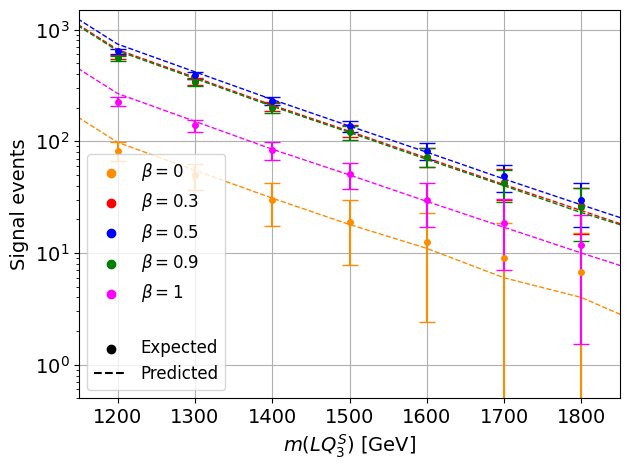

In [ ]:
S_expected = S_expected_SLQ_betas['beta05']
for ii, S_it in enumerate(S_expected):

    # ---- FIT ----
    plt.errorbar(masses_SLQ[ii+1], [S_mean_SLQ_fit['beta0'][ii]], yerr=[S_std_SLQ_fit['beta0'][ii]], color=cols[3], fmt='.', markersize=8, capsize=6, linestyle='None')
    # plt.errorbar(masses_SLQ[ii+1], [S_mean_SLQ_fit['beta01'][ii]], yerr=[S_std_SLQ_fit['beta01'][ii]], color=cols[1], fmt='.', markersize=8, capsize=6, linestyle='None')
    plt.errorbar(masses_SLQ[ii+1], [S_mean_SLQ_fit['beta03'][ii]], yerr=[S_std_SLQ_fit['beta03'][ii]], color=cols[0], fmt='.', markersize=8, capsize=6, linestyle='None')
    plt.errorbar(masses_SLQ[ii+1], [S_mean_SLQ_fit['beta05'][ii]], yerr=[S_std_SLQ_fit['beta05'][ii]], color=cols[1], fmt='.', markersize=8, capsize=6, linestyle='None')
    # plt.errorbar(masses_SLQ[ii+1], [S_mean_SLQ_fit['beta07'][ii]], yerr=[S_std_SLQ_fit['beta07'][ii]], color=cols[2], fmt='.', markersize=8, capsize=6, linestyle='None')
    plt.errorbar(masses_SLQ[ii+1], [S_mean_SLQ_fit['beta09'][ii]], yerr=[S_std_SLQ_fit['beta09'][ii]], color=cols[2], fmt='.', markersize=8, capsize=6, linestyle='None')
    plt.errorbar(masses_SLQ[ii+1], [S_mean_SLQ_fit['beta1'][ii]], yerr=[S_std_SLQ_fit['beta1'][ii]], color=cols[4], fmt='.', markersize=8, capsize=6, linestyle='None')

# dummy
plt.scatter([1],[1], color=cols[3], label=r'$\beta=0$')
# plt.scatter([1],[1], color=cols[1], label=r'$\beta=0.1$')
plt.scatter([1],[1], color=cols[0], label=r'$\beta=0.3$')
plt.scatter([1],[1], color=cols[1], label=r'$\beta=0.5$')
# plt.scatter([1],[1], color=cols[2], label=r'$\beta=0.7$')
plt.scatter([1],[1], color=cols[2], label=r'$\beta=0.9$')
plt.scatter([1],[1], color=cols[4], label=r'$\beta=1$')
plt.scatter([1],[1], color='white', label=r' ')
plt.scatter([1],[1], color='black', label=r'Expected')
plt.plot([1,2],[1,2], color='black', linestyle='--', label=r'Predicted')

plt.plot(masses_SLQ[1:], S_expected_SLQ_betas['beta0'], color=cols[3], linestyle='--', lw=1 )
# plt.plot(masses_SLQ[1:], S_expected_SLQ_betas['beta01'], color=cols[1], linestyle='--', lw=1 )
plt.plot(masses_SLQ[1:], S_expected_SLQ_betas['beta03'], color=cols[0], linestyle='--', lw=1 )
plt.plot(masses_SLQ[1:], S_expected_SLQ_betas['beta05'], color=cols[1], linestyle='--', lw=1 )
# plt.plot(masses_SLQ[1:], S_expected_SLQ_betas['beta07'], color=cols[2], linestyle='--', lw=1 )
plt.plot(masses_SLQ[1:], S_expected_SLQ_betas['beta09'], color=cols[2], linestyle='--', lw=1 )
plt.plot(masses_SLQ[1:], S_expected_SLQ_betas['beta1'], color=cols[4], linestyle='--', lw=1 )

plt.yscale('log')
plt.xlim(1150,1850)
plt.ylim(0.5e0,1.5e3)
plt.xlabel(r"$m(LQ^S_3)$ [GeV]", fontsize=14)
plt.ylabel("Signal events", fontsize=14)
# plt.title("Cut-based (weight = 1)", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True)
plt.legend(loc='lower left', fontsize=12)

# line1 = plt.scatter([1],[1], color='black', label=r'S predicted')
# plt.plot([1,2],[1,2], color='black', linestyle='--', label=r'S expected')

# plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(mainfolder + "saved-results/S_predicted_SLQ.pdf", bbox_inches='tight')
plt.show()

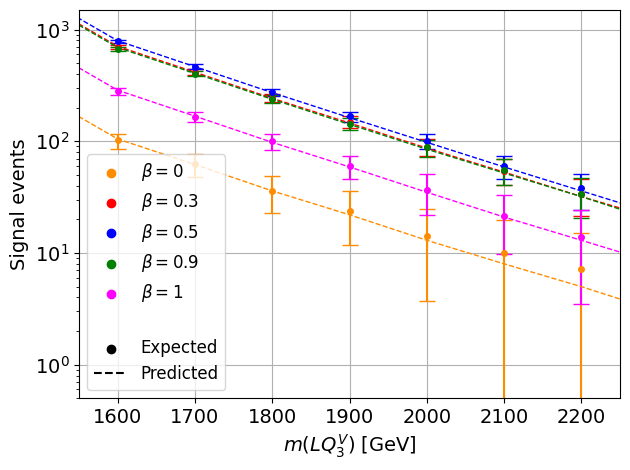

In [ ]:
for ii, S_it in enumerate(S_expected):

    # ---- FIT ----
    plt.errorbar(masses_VLQ[ii+1], [S_mean_VLQ_fit['beta0'][ii]], yerr=[S_std_VLQ_fit['beta0'][ii]], color=cols[3], fmt='.', markersize=8, capsize=6, linestyle='None')
    # plt.errorbar(masses_VLQ[ii+1], [S_mean_VLQ_fit['beta01'][ii]], yerr=[S_std_VLQ_fit['beta01'][ii]], color=cols[1], fmt='.', markersize=8, capsize=6, linestyle='None')
    plt.errorbar(masses_VLQ[ii+1], [S_mean_VLQ_fit['beta03'][ii]], yerr=[S_std_VLQ_fit['beta03'][ii]], color=cols[0], fmt='.', markersize=8, capsize=6, linestyle='None')
    plt.errorbar(masses_VLQ[ii+1], [S_mean_VLQ_fit['beta05'][ii]], yerr=[S_std_VLQ_fit['beta05'][ii]], color=cols[1], fmt='.', markersize=8, capsize=6, linestyle='None')
    # plt.errorbar(masses_VLQ[ii+1], [S_mean_VLQ_fit['beta07'][ii]], yerr=[S_std_VLQ_fit['beta07'][ii]], color=cols[2], fmt='.', markersize=8, capsize=6, linestyle='None')
    plt.errorbar(masses_VLQ[ii+1], [S_mean_VLQ_fit['beta09'][ii]], yerr=[S_std_VLQ_fit['beta09'][ii]], color=cols[2], fmt='.', markersize=8, capsize=6, linestyle='None')
    plt.errorbar(masses_VLQ[ii+1], [S_mean_VLQ_fit['beta1'][ii]], yerr=[S_std_VLQ_fit['beta1'][ii]], color=cols[4], fmt='.', markersize=8, capsize=6, linestyle='None')

# dummy
plt.scatter([1],[1], color=cols[3], label=r'$\beta=0$')
# plt.scatter([1],[1], color=cols[1], label=r'$\beta=0.1$')
plt.scatter([1],[1], color=cols[0], label=r'$\beta=0.3$')
plt.scatter([1],[1], color=cols[1], label=r'$\beta=0.5$')
# plt.scatter([1],[1], color=cols[2], label=r'$\beta=0.7$')
plt.scatter([1],[1], color=cols[2], label=r'$\beta=0.9$')
plt.scatter([1],[1], color=cols[4], label=r'$\beta=1$')
plt.scatter([1],[1], color='white', label=r' ')
plt.scatter([1],[1], color='black', label=r'Expected')
plt.plot([1,2],[1,2], color='black', linestyle='--', label=r'Predicted')

plt.plot(masses_VLQ[1:], S_expected_VLQ_betas['beta0'], color=cols[3], linestyle='--', lw=1 )
# plt.plot(masses_VLQ[1:], S_expected_VLQ_betas['beta01'], color=cols[1], linestyle='--', lw=1 )
plt.plot(masses_VLQ[1:], S_expected_VLQ_betas['beta03'], color=cols[0], linestyle='--', lw=1 )
plt.plot(masses_VLQ[1:], S_expected_VLQ_betas['beta05'], color=cols[1], linestyle='--', lw=1 )
# plt.plot(masses_VLQ[1:], S_expected_VLQ_betas['beta07'], color=cols[2], linestyle='--', lw=1 )
plt.plot(masses_VLQ[1:], S_expected_VLQ_betas['beta09'], color=cols[2], linestyle='--', lw=1 )
plt.plot(masses_VLQ[1:], S_expected_VLQ_betas['beta1'], color=cols[4], linestyle='--', lw=1 )

plt.yscale('log')
plt.xlim(1550,2250)
plt.ylim(0.5e0,1.5e3)
plt.xlabel(r"$m(LQ^V_3)$ [GeV]", fontsize=14)
plt.ylabel("Signal events", fontsize=14)
# plt.title("Cut-based (weight = 1)", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True)
plt.legend(loc='lower left', fontsize=12)

# line1 = plt.scatter([1],[1], color='black', label=r'S predicted')
# plt.plot([1,2],[1,2], color='black', linestyle='--', label=r'S expected')

# plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(mainfolder + "saved-results/S_predicted_VLQ.pdf", bbox_inches='tight')
plt.show()

# SLQ vs VLQ (include Poisson S_expected)

In [53]:
X_train_list, y_train_list, S_poiss_train_list = [], [], []
X_val_list,   y_val_list,   S_poiss_val_list   = [], [], []
X_test_list,  y_test_list,  S_poiss_test_list  = [], [], []

for iit, m_s in enumerate(masses_SLQ):

        # -------- SLQ --------
        X_train_s, X_val_s, X_test_s, _ = split_SLQ[masses_SLQ[iit]]

        X_train_list.append(X_train_s)
        y_train_list.append(np.zeros(len(X_train_s)))
        poisson_samples = np.random.poisson(lam=S_mean_fit_both[iit], size=len(X_train_s))
        S_poiss_train_list.append(poisson_samples)

        X_val_list.append(X_val_s)
        y_val_list.append(np.zeros(len(X_val_s)))
        poisson_samples = np.random.poisson(lam=S_mean_fit_both[iit], size=len(X_val_s))
        S_poiss_val_list.append(poisson_samples)

        X_test_list.append(X_test_s)
        y_test_list.append(np.zeros(len(X_test_s)))
        poisson_samples = np.random.poisson(lam=S_mean_fit_both[iit], size=len(X_test_s))
        S_poiss_test_list.append(poisson_samples)


# for iit, m_v in enumerate(masses_VLQ):

        # -------- VLQ --------
        X_train_v, X_val_v, X_test_v, _ = split_VLQ[masses_VLQ[iit]]

        X_train_list.append(X_train_v)
        y_train_list.append(np.ones(len(X_train_v)))
        poisson_samples = np.random.poisson(lam=S_mean_fit_both[iit], size=len(X_train_v))
        S_poiss_train_list.append(poisson_samples)

        X_val_list.append(X_val_v)
        y_val_list.append(np.ones(len(X_val_v)))
        poisson_samples = np.random.poisson(lam=S_mean_fit_both[iit], size=len(X_val_v))
        S_poiss_val_list.append(poisson_samples)

        X_test_list.append(X_test_v)
        y_test_list.append(np.ones(len(X_test_v)))
        poisson_samples = np.random.poisson(lam=S_mean_fit_both[iit], size=len(X_test_v))
        S_poiss_test_list.append(poisson_samples)


# Concatenate
# TRAIN
X_train_spin = np.vstack(X_train_list)
y_train_spin = np.concatenate(y_train_list)
S_poiss_train = np.concatenate(S_poiss_train_list)

# add S_poiss as extra feature
X_train_spin = np.column_stack([X_train_spin, S_poiss_train])


# VAL
X_val_spin = np.vstack(X_val_list)
y_val_spin = np.concatenate(y_val_list)
S_poiss_val = np.concatenate(S_poiss_val_list)

X_val_spin = np.column_stack([X_val_spin, S_poiss_val])


# TEST
X_test_spin = np.vstack(X_test_list)
y_test_spin = np.concatenate(y_test_list)
S_poiss_test = np.concatenate(S_poiss_test_list)

X_test_spin = np.column_stack([X_test_spin, S_poiss_test])


print(X_train_spin.shape)
print(X_val_spin.shape)
print(X_test_spin.shape)

(549980, 54)
(200000, 54)
(250000, 54)


In [54]:
classifier_spin = XGBClassifier(
    n_estimators=1500,
    learning_rate=0.1,
    max_depth=5,
    reg_lambda=1.0,
    reg_alpha=0.0,
    gamma=0.0,
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    random_state=42,
    early_stopping_rounds=50
)

classifier_spin.fit(
    X_train_spin, y_train_spin,
    eval_set=[(X_train_spin, y_train_spin),
              (X_val_spin, y_val_spin)],
    verbose=True
)

classifier_spin.save_model(mainfolder + "saved-models/modelB_spin_S_poiss.json")

[0]	validation_0-logloss:0.68601	validation_1-logloss:0.68604
[1]	validation_0-logloss:0.68029	validation_1-logloss:0.68032
[2]	validation_0-logloss:0.67494	validation_1-logloss:0.67505
[3]	validation_0-logloss:0.67039	validation_1-logloss:0.67052
[4]	validation_0-logloss:0.66631	validation_1-logloss:0.66643
[5]	validation_0-logloss:0.66270	validation_1-logloss:0.66284
[6]	validation_0-logloss:0.65980	validation_1-logloss:0.65996
[7]	validation_0-logloss:0.65705	validation_1-logloss:0.65730
[8]	validation_0-logloss:0.65476	validation_1-logloss:0.65511
[9]	validation_0-logloss:0.65238	validation_1-logloss:0.65278
[10]	validation_0-logloss:0.65025	validation_1-logloss:0.65076
[11]	validation_0-logloss:0.64835	validation_1-logloss:0.64887
[12]	validation_0-logloss:0.64603	validation_1-logloss:0.64655
[13]	validation_0-logloss:0.64416	validation_1-logloss:0.64472
[14]	validation_0-logloss:0.64226	validation_1-logloss:0.64289
[15]	validation_0-logloss:0.64074	validation_1-logloss:0.64142
[1

Global AUC = 0.7462278258239999


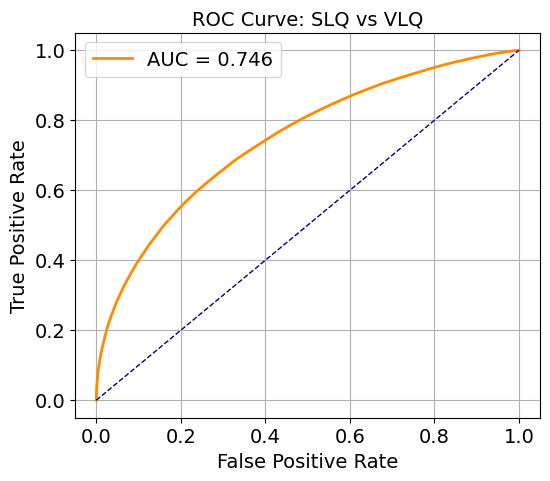

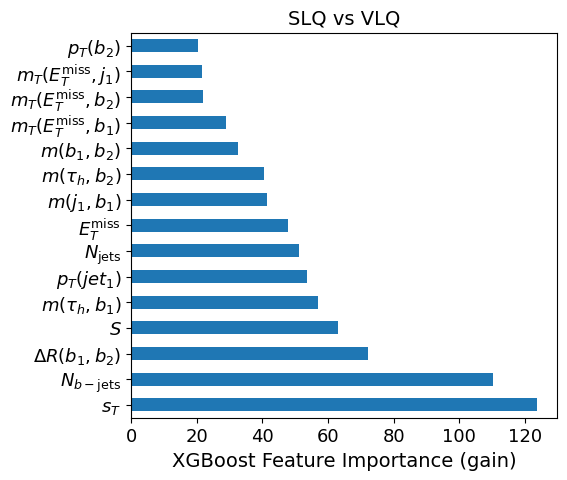

[52, 19, 22, 53, 35, 9, 18, 15, 38, 36, 37, 45, 46, 48, 3]


In [55]:
# LOAD
classifier_spin = XGBClassifier()
classifier_spin.load_model(mainfolder + "saved-models/modelB_spin_S_poiss.json")


y_score = classifier_spin.predict_proba(X_test_spin)[:, 1]


fpr, tpr, thresholds = roc_curve(y_test_spin, y_score)
roc_auc = roc_auc_score(y_test_spin, y_score)

print("Global AUC =", roc_auc)


plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.title("ROC Curve: SLQ vs VLQ", fontsize=14)
plt.grid(True)
plt.legend(fontsize=14)
plt.savefig(mainfolder + 'saved-results/ROC_classB.pdf', bbox_inches='tight')
plt.show()




keys = np.array([r'$p_T(b_1)$',r'$\eta(b_1)$',r'$\phi(b_1)$',
                 r'$p_T(b_2)$',r'$\eta(b_2)$',r'$\phi(b_2)$',
                 r'$p_T(\tau_h)$',r'$\eta(\tau_h)$',r'$\phi(\tau_h)$',
                 r'$p_T(jet_1)$',r'$\eta(jet_1)$',r'$\phi(jet_1)$',
                 r'$p_T(jet_2)$',r'$\eta(jet_2)$',r'$\phi(jet_2)$',
                 r'$E_T^{\mathrm{miss}}$',r'$\phi(E_T^{\mathrm{miss}})$',
                 r'$H_T$',r'$N_{\mathrm{jets}}$',r'$N_{b-\mathrm{jets}}$',
                 r'$\Delta R(\tau_h, b_1)$',r'$\Delta R(\tau_h, b_2)$',r'$\Delta R(b_1, b_2)$',
                 r'$\Delta R(j_1, b_1)$',r'$\Delta R(j_1, b_2)$',r'$\Delta R(j_1, \tau_h)$',
                 r'$\Delta R(j_2, b_1)$',r'$\Delta R(j_2, b_2)$',r'$\Delta R(j_2, \tau_h)$',
                 r'$\Delta R(j_1, j_2)$',
#                  r'$\Delta \phi(\tau_h, b_1)$',r'$\Delta \phi(\tau_h, b_2)$',r'$\Delta \phi(b_1, b_2)$',
                 r'$\Delta \phi(E_T^{\mathrm{miss}}, b_1)$',r'$\Delta \phi(E_T^{\mathrm{miss}}, b_2)$',r'$\Delta \phi(E_T^{\mathrm{miss}}, \tau_h)$',
                 r'$\Delta \phi(E_T^{\mathrm{miss}}, j_1)$',r'$\Delta \phi(E_T^{\mathrm{miss}}, j_2)$',
                 r'$m(\tau_h, b_1)$',r'$m(\tau_h, b_2)$',r'$m(b_1, b_2)$',
                 r'$m(j_1, b_1)$',r'$m(j_1, b_2)$',r'$m(j_1, \tau_h)$',
                 r'$m(j_2, b_1)$',r'$m(j_2, b_2)$',r'$m(j_2, \tau_h)$',
                 r'$m(j_1, j_2)$',
                 r'$m_T(E_T^{\mathrm{miss}}, b_1)$',r'$m_T(E_T^{\mathrm{miss}}, b_2)$',r'$m_T(E_T^{\mathrm{miss}}, \tau_h)$',
                 r'$m_T(E_T^{\mathrm{miss}}, j_1)$',r'$m_T(E_T^{\mathrm{miss}}, j_2)$',
                 r'$m_T(b_1, b_2)$',r'$m_T(j_1, j_2)$',r'$s_T$',
                #  r'$m_{\mathrm{LQ}}^{\mathrm{reg}}$',
                 r'$S$'])

feature_important = classifier_spin.get_booster().get_score(importance_type='gain')
values = list(feature_important.values())


data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=False)
data.nlargest(15, columns="score").plot(kind='barh',figsize=(5.5,5)) ## plot top 15 features
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlabel("XGBoost Feature Importance (gain)", fontsize=14)
plt.legend( fontsize=12).remove()
plt.title(r'SLQ vs VLQ', fontsize=14)
plt.savefig(mainfolder + 'saved-results/XG_feature_importance_classB.pdf', bbox_inches='tight')
plt.show()


# SELECT THE TOP INDICES
num_feats = 15

keys_list = list(keys)  # convert to list
top_names = data.nlargest(num_feats, columns="score").index.tolist()
feat_indices_LQSM = [keys_list.index(name) for name in top_names]

print(feat_indices_LQSM)

$m_{LQ_3^S}=$1200 GeV,   AUC = 0.77404
$m_{LQ_3^S}=$1500 GeV,   AUC = 0.73580
$m_{LQ_3^S}=$1800 GeV,   AUC = 0.70190


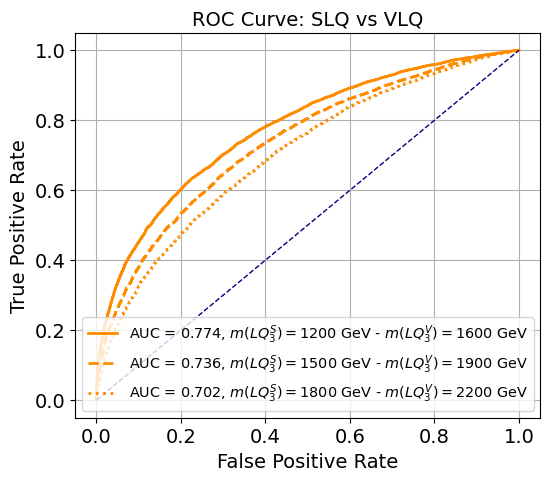

In [58]:
S_column = X_test_spin[:, -1]

# mSLQ_plot = [1200, 1500, 1800]
# mVLQ_plot = [1600, 1900, 2200]

linestyles = ['-','-','-', '--','--','--', ':', ':', ':']
# colors_SLQ = ['lightcoral', 'red', 'firebrick']
# colors_VLQ = ['limegreen', 'green', 'darkgreen']

plt.figure(figsize=(6,5))

# evaluate per sector
for iit, S_id in enumerate(S_expected_SLQ):
    # if iit == 0 or iit == 1 or iit == 9:
    #     continue
    # else:
    if iit == 2 or iit == 5 or iit == 8:

        mask = (S_column < S_id * 1.1) & (0.9 * S_id < S_column)

        y_true_Spoiss = y_test_spin[mask]
        y_score_Spoiss = y_score[mask]

        fpr, tpr, _ = roc_curve(y_true_Spoiss, y_score_Spoiss)
        auc_sector = roc_auc_score(y_true_Spoiss, y_score_Spoiss)

        print(f"$m_{{LQ_3^S}}=${masses_SLQ[iit]} GeV,   AUC = {auc_sector:.5f}")


        plt.plot(fpr, tpr, color='darkorange', linestyle=linestyles[iit], lw=2, label=f"AUC = {auc_sector:.3f}, $m(LQ_3^S)=${masses_SLQ[iit]} GeV - $m(LQ_3^V)=${masses_VLQ[iit]} GeV")



plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.title("ROC Curve: SLQ vs VLQ", fontsize=14)
plt.grid(True)
plt.legend(fontsize=10.4)
plt.savefig(mainfolder + 'saved-results/ROC_classB_multi.pdf', bbox_inches='tight')
plt.show()

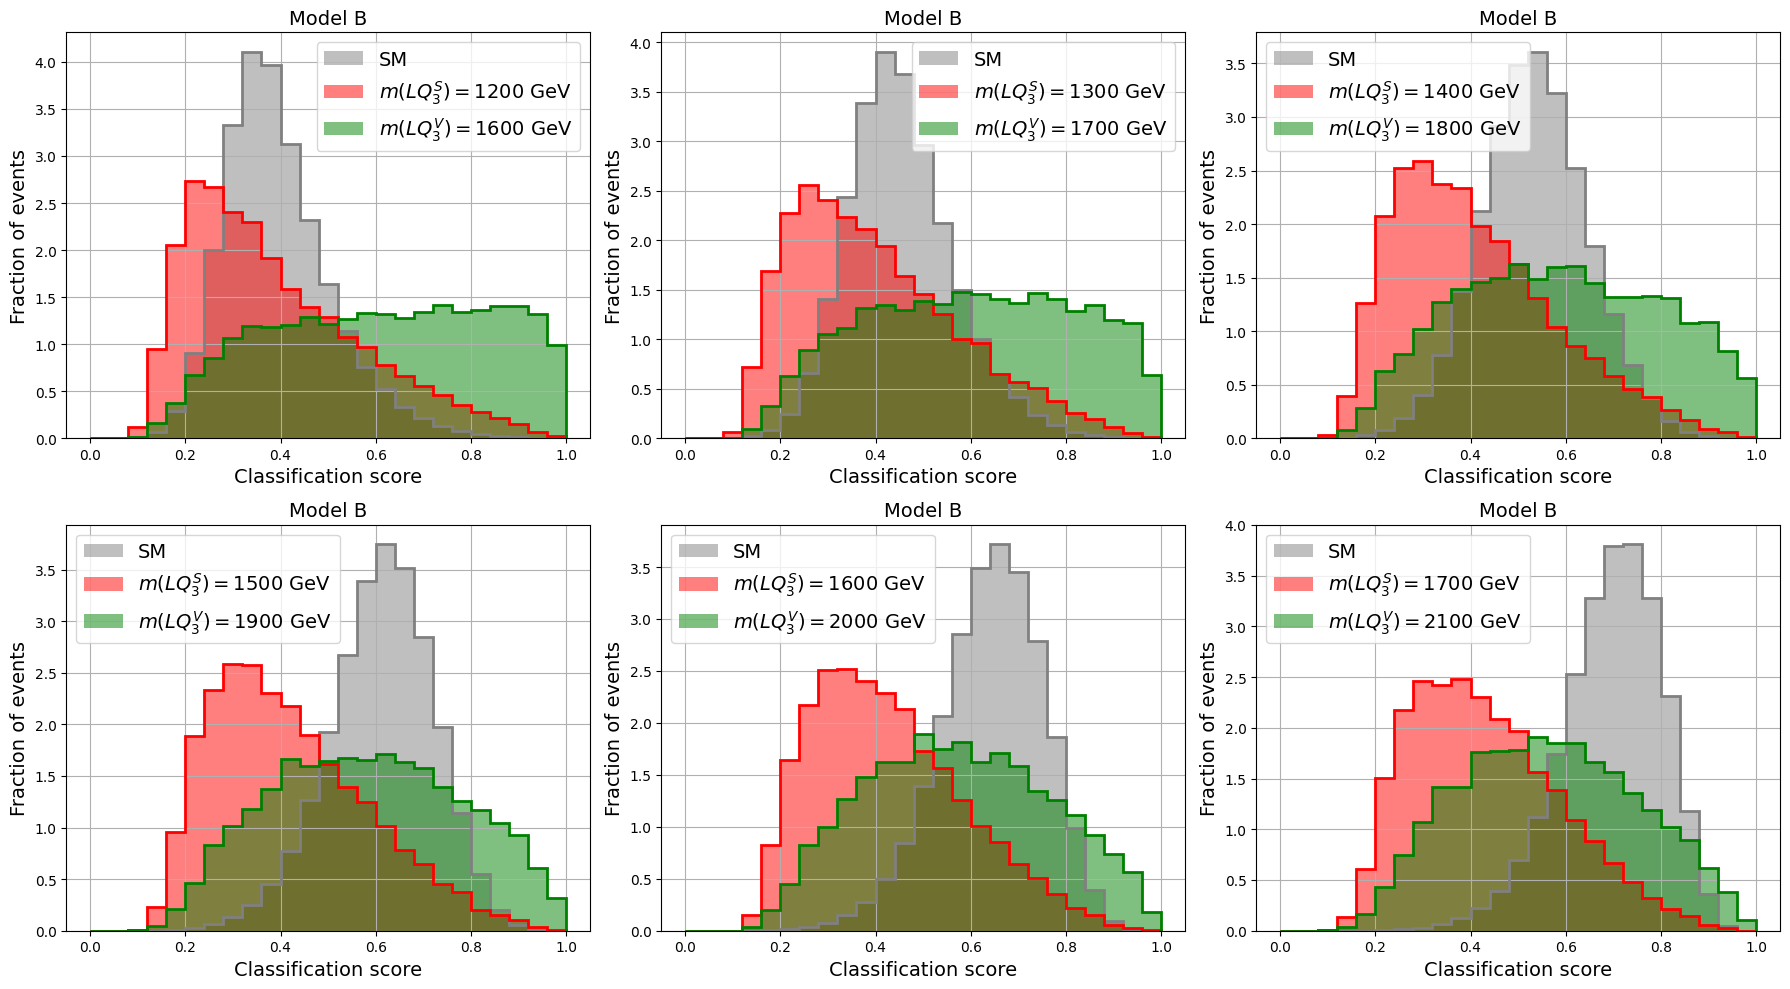

In [59]:

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
# axes = axes.flatten()

for iit, S_id in enumerate(S_expected_SLQ):
    if iit == 0 or iit == 1 or iit == 8 or iit == 9:
        continue
    else:

        # mask = (S_column < S_id * 1.1) & (0.9 * S_id < S_column)
        if iit < 5:
            ax = axes[0,iit-2]
        else:
            ax = axes[1,iit-5]

        # SM
        _, _, X_test_B, _ = split_SM

        poisson_samples = np.random.poisson(lam=S_expected_SLQ[iit], size=len(X_test_B))
        X_B_spin = np.column_stack([X_test_B, poisson_samples])
        pred_B = classifier_spin.predict_proba(X_B_spin)[:,1]


        # -------- SLQ --------
        # X_SLQ_sector = []
        _, _, X_test_s, _ = split_SLQ[masses_SLQ[iit]]
        # X_SLQ_sector.append(X_test_s)

        poisson_samples = np.random.poisson(lam=S_expected_SLQ[iit], size=len(X_test_s))
        X_s_spin = np.column_stack([X_test_s, poisson_samples])
        pred_s = classifier_spin.predict_proba(X_s_spin)[:,1]


        # -------- VLQ --------
        # X_VLQ_sector = []
        _, _, X_test_v, _ = split_VLQ[masses_VLQ[iit]]
        # X_VLQ_sector.append(X_test_v)

        poisson_samples = np.random.poisson(lam=S_expected_SLQ[iit], size=len(X_test_v))
        X_v_spin = np.column_stack([X_test_v, poisson_samples])
        pred_v = classifier_spin.predict_proba(X_v_spin)[:,1]



        # Histogramas
        ax.hist(pred_B, bins=25, range=(0,1), density=True, histtype='step', color='gray', linewidth=2)
        ax.hist(pred_s, bins=25, range=(0,1), density=True, histtype='step', color='red', linewidth=2)
        ax.hist(pred_v, bins=25, range=(0,1), density=True, histtype='step', color='green', linewidth=2)

        ax.hist(pred_B, bins=25, range=(0,1), density=True, color='gray', alpha=0.5, label=f'SM')#\nmean: {np.mean(pred_B):.2f}')
        ax.hist(pred_s, bins=25, range=(0,1), density=True, color='red', alpha=0.5, label=f'$m(LQ_3^S)=${masses_SLQ[iit]} GeV')#\nmean: {np.mean(pred_s):.2f}')
        ax.hist(pred_v, bins=25, range=(0,1), density=True, color='green', alpha=0.5, label=f'$m(LQ_3^V)=${masses_VLQ[iit]} GeV')#\nmean: {np.mean(pred_v):.2f}')

        ax.set_title(f"Model B", fontsize=14)
        ax.set_xlabel("Classification score", fontsize=14)
        ax.set_ylabel("Fraction of events", fontsize=14)
        ax.grid(True)
        ax.legend(fontsize=14)

plt.tight_layout()
plt.savefig(mainfolder + 'saved-results/output_classB_multi.pdf', bbox_inches='tight')
plt.show()

# JOIN BOTH ML

In [60]:
# --- Clasificador A: SM vs LQ ---

scoresA_SM = xgb_clf.predict_proba( df_SM_norm )[:,1]

scoresA_SLQ = {}
scoresA_VLQ = {}

m_SLQ = [1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900]
m_VLQ = [1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]

S_exp_SLQ = S_expected_SLQ[2:]
S_exp_both = S_mean_fit_both[2:]

for m in m_SLQ:
    scoresA_SLQ[m] = xgb_clf.predict_proba( df_SLQ_norm[m] )[:,1]

for m in m_VLQ:
    scoresA_VLQ[m] = xgb_clf.predict_proba( df_VLQ_norm[m] )[:,1]

In [61]:
# --- Clasificador B: SLQ vs VLQ ---

X_sm = df_SM_norm

rand_samples_B =np.random.randint(1, S_exp_both[0] + S_std_fit_both[0], size=len(X_sm))

X_sm = np.column_stack([X_sm, rand_samples_B])

scoresB_SM = classifier_spin.predict_proba(X_sm)[:,1]


scoresB_SLQ = {}
scoresB_VLQ = {}

for iit, S_id in enumerate(m_SLQ):

    X_s = df_SLQ_norm[m_SLQ[iit]].values
    X_v = df_VLQ_norm[m_VLQ[iit]].values

    poisson_samples_SLQ = np.random.poisson(lam=S_exp_both[iit], size=len(X_s))
    poisson_samples_VLQ = np.random.poisson(lam=S_exp_both[iit], size=len(X_v))

    X_s = np.column_stack([X_s, poisson_samples_SLQ])
    X_v = np.column_stack([X_v, poisson_samples_VLQ])

    scoresB_SLQ[m_SLQ[iit]] = classifier_spin.predict_proba(X_s)[:,1]
    scoresB_VLQ[m_VLQ[iit]] = classifier_spin.predict_proba(X_v)[:,1]

In [62]:
# --- Juntar los scores del clasificador A y B

events_SM = np.column_stack([scoresA_SM, scoresB_SM])

events_SLQ = {}
for m in scoresA_SLQ:
    events_SLQ[m] = np.column_stack([scoresA_SLQ[m], scoresB_SLQ[m]])

events_VLQ = {}
for m in scoresA_VLQ:
    events_VLQ[m] = np.column_stack([scoresA_VLQ[m], scoresB_VLQ[m]])

#### Define the test statistic

In [63]:
def compute_test_statistic(scoresA, scoresB, threshold):
    """
    Sum of Log-Likelihood Ratios (LLR)

    T = Sum log (P(VLQ) / P(SLQ))

    P(VLQ) = score SLQ vs VLQ classifier
    P(SLQ) = 1 - score SLQ vs VLQ classifier
    """

    mask = scoresA > threshold

    scoresB_sel = scoresB[mask]

    if len(scoresB_sel) == 0:
        return 0

    eps = 1e-6
    s = np.clip(scoresB_sel, eps, 1-eps)

    T = np.sum(np.log(s/(1-s)))

    return T

#### An example

In [64]:
B_expected = 45962
S_expected = 137   # this is m_SLQ = 1500 GeV


threshold_A = 0.95

n_pseudo = 5000

##### Assuming SLQ is true

In [65]:
mass = 1500

T_SLQ = []

for i in range(n_pseudo):

    N_B = np.random.poisson(B_expected)
    N_S = np.random.poisson(S_expected)

    # sample background
    sample_B = events_SM[np.random.randint(len(events_SM), size=N_B)]

    # sample signal
    sample_S = events_SLQ[mass][np.random.randint(len(events_SLQ[mass]), size=N_S)]


    sample_all = np.vstack([sample_B, sample_S])

    scoresA = sample_all[:,0]
    scoresB = sample_all[:,1]

    T = compute_test_statistic(scoresA, scoresB, threshold_A)

    T_SLQ.append(T)

##### Assuming VLQ is true

In [66]:
mass = 1900

T_VLQ = []

for i in range(n_pseudo):

    N_B = np.random.poisson(B_expected)
    N_S = np.random.poisson(S_expected)

    # sample background
    sample_B = events_SM[np.random.randint(len(events_SM), size=N_B)]

    # sample signal
    sample_S = events_VLQ[mass][np.random.randint(len(events_VLQ[mass]), size=N_S)]


    sample_all = np.vstack([sample_B, sample_S])

    scoresA = sample_all[:,0]
    scoresB = sample_all[:,1]

    T = compute_test_statistic(scoresA, scoresB, threshold_A)

    T_VLQ.append(T)

##### Z

Z distributions (gaussians) = 5.1357927
mean(T_SLQ) = -70.15816
mean(T_VLQ) = 41.426514


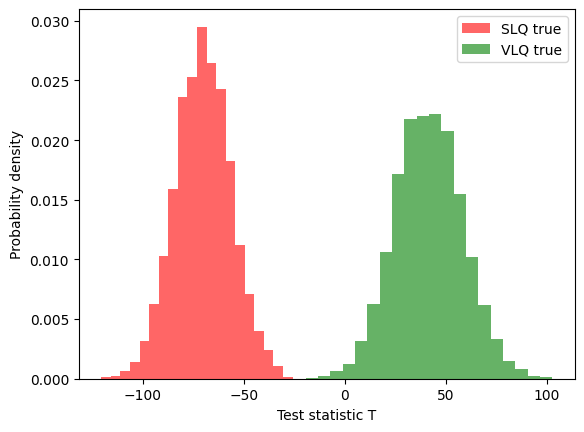

In [67]:
mu_S = np.mean(T_SLQ)
mu_V = np.mean(T_VLQ)

sigma_S = np.std(T_SLQ)
sigma_V = np.std(T_VLQ)

Z = abs(mu_V - mu_S) / np.sqrt(sigma_S**2 + sigma_V**2)

print("Z distributions (gaussians) =", Z)

print('mean(T_SLQ) =', mu_S)
print('mean(T_VLQ) =', mu_V)

plt.hist(T_SLQ, bins=20, density=True, color='red', alpha=0.6, label="SLQ true")
plt.hist(T_VLQ, bins=20, density=True, color='green', alpha=0.6, label="VLQ true")

plt.xlabel("Test statistic T")
plt.ylabel("Probability density")
plt.legend()
plt.show()

T observed = 51.111965
mean(T_SLQ) = -70.15816
mean(T_VLQ) = 41.426514

Pseudo experimento compatible con VLQ
Z wrt SLQ = 8.7589035
Z wrt VLQ = 0.5784418


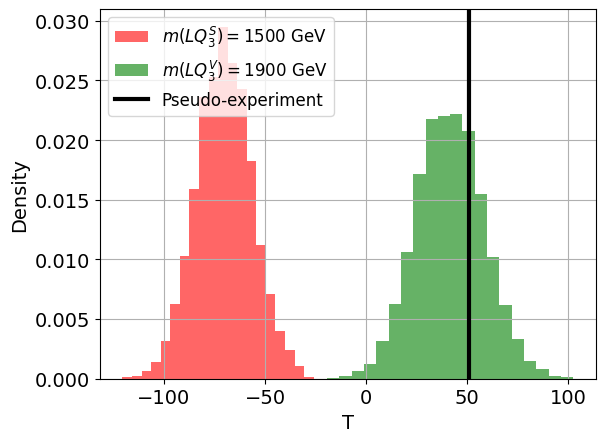

In [68]:
N_B = np.random.poisson(B_expected)
N_S = np.random.poisson(S_expected)

mass = 1900
sample_B = events_SM[np.random.randint(len(events_SM), size=N_B)]
sample_S = events_VLQ[mass][np.random.randint(len(events_VLQ[mass]), size=N_S)]

sample_all = np.vstack([sample_B, sample_S])

scoresA = sample_all[:,0]
scoresB = sample_all[:,1]

T_obs = compute_test_statistic(scoresA, scoresB, threshold_A)

print("T observed =", T_obs)
print('mean(T_SLQ) =', mu_S)
print('mean(T_VLQ) =', mu_V)

print('')
if abs(T_obs - mu_S) < abs(T_obs - mu_V):
    print("Pseudo experimento compatible con SLQ")
else:
    print("Pseudo experimento compatible con VLQ")


Z_SLQ = (T_obs - mu_S) / sigma_S
Z_VLQ = (T_obs - mu_V) / sigma_V

print("Z wrt SLQ =", Z_SLQ)
print("Z wrt VLQ =", Z_VLQ)


plt.hist(T_SLQ, bins=20, density=True, color='red', alpha=0.6, label=r"$m(LQ_3^S)=1500$ GeV")
plt.hist(T_VLQ, bins=20, density=True, color='green', alpha=0.6, label=r"$m(LQ_3^V)=1900$ GeV")

plt.axvline(T_obs, color='black', lw=3, label="Pseudo-experiment")

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("T", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.legend(loc='upper left', fontsize=12)
plt.grid(True)
plt.savefig(mainfolder + 'saved-results/example-stat-T.pdf', bbox_inches='tight')
plt.show()

In [69]:
p_SLQ = np.mean(np.array(T_SLQ) >= T_obs)
p_VLQ = np.mean(np.array(T_VLQ) <= T_obs)

print("p-value SLQ =", p_SLQ)
print("p-value VLQ =", p_VLQ)

p-value SLQ = 0.0
p-value VLQ = 0.7206


In [70]:
print('Two-tailed') # Probability of a result more extreme in either direction.
print( "p-value SLQ =", 2 * stats.norm.sf(abs(Z_SLQ)) )
print( "p-value VLQ =", 2 * stats.norm.sf(abs(Z_VLQ)) )

print('\nRight-tailed') # Probability of a result greater than tobs
print( "p-value SLQ =", stats.norm.sf(Z_SLQ) )
print( "p-value VLQ =", stats.norm.sf(Z_VLQ) )

print('\nLeft-tailed') # Probability of a result less than tobs
print( "p-value SLQ =", stats.norm.cdf(Z_SLQ) )
print( "p-value VLQ =", stats.norm.cdf(Z_VLQ) )

Two-tailed
p-value SLQ = 1.9715880648370907e-18
p-value VLQ = 0.5629658808056626

Right-tailed
p-value SLQ = 9.857940324185453e-19
p-value VLQ = 0.2814829404028313

Left-tailed
p-value SLQ = 1.0
p-value VLQ = 0.7185170595971687


In [71]:
print('We will use the two-tailed')
print('\n Two-tailed    p=0.05 (0.025 per side)     -> 95% C.L.   -> Z=1.96')
print('\n One-tailed    p=0.05 (0.05 just one side) -> 95% C.L.   -> Z=1.645')

We will use the two-tailed

 Two-tailed    p=0.05 (0.025 per side)     -> 95% C.L.   -> Z=1.96

 One-tailed    p=0.05 (0.05 just one side) -> 95% C.L.   -> Z=1.645


### For all the masses

In [72]:
# funcion para generar pseudo experimentos (da los scores de ambos clasificadores para ese pseudo)

def generate_pseudo(events_B, events_S, N_B, N_S):

    sample_B = events_B[np.random.randint(len(events_B), size=N_B)]
    sample_S = events_S[np.random.randint(len(events_S), size=N_S)]

    sample_all = np.vstack([sample_B, sample_S])

    scoresA = sample_all[:,0]
    scoresB = sample_all[:,1]

    return scoresA, scoresB

In [73]:
B_expected = 45962

S_exp_SLQ = [round(fid_xsec_SLQ_14TeV(mmm, beta) * Lum) for mmm in m_SLQ]
S_exp_VLQ = [round(fid_xsec_VLQ_14TeV(mmm, beta) * Lum) for mmm in m_VLQ]

print('beta = ', beta)
print('\nB_expected: ', B_expected)
print('\nS_exp_SLQ: ', S_exp_SLQ, '   m =', m_SLQ)
print('S_exp_VLQ: ', S_exp_VLQ, '   m =', m_VLQ)
print('S_exp_both: ', S_exp_both)

beta =  0.5

B_expected:  45962

S_exp_SLQ:  [742, 419, 237, 137, 80, 46, 27, 16]    m = [1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900]
S_exp_VLQ:  [796, 466, 273, 163, 98, 59, 36, 22]    m = [1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]
S_exp_both:  [np.float64(713.9413818288749), np.float64(416.292342085481), np.float64(241.6689940701397), np.float64(141.71049356260687), np.float64(83.82012738279948), np.float64(48.61995888440391), np.float64(28.70579686301229), np.float64(17.28167145494983)]


#### Distribution of the statistic with only SLQ and only VLQ

In [74]:
n_pseudo_TRUE = 1000
threshold_A = 0.95

In [75]:
mu_S = []
mu_V = []

sigma_S = []
sigma_V = []

for S_it in range(len(S_exp_SLQ)):

    print("\n==========================")
    print("S_expected SLQ =", S_exp_SLQ[S_it])
    # print("S_expected VLQ =", S_exp_VLQ[S_it]) # same number of events

    # dado un S, le asigna la masa (del SLQ o VLQ) correspondiente
    mass_SLQ = m_SLQ[S_it]
    mass_VLQ = m_VLQ[S_it]
    print("mass_SLQ =", mass_SLQ, " GeV")
    print("mass_VLQ =", mass_VLQ, " GeV")


    # computamos el T statistic para todos los pseudo
    T_SLQ = []
    T_VLQ = []

    for i in range(n_pseudo_TRUE):

        N_B = np.random.poisson(B_expected)
        N_S = np.random.poisson(S_exp_SLQ[S_it])

        scoresA, scoresB = generate_pseudo( events_SM, events_SLQ[mass_SLQ], N_B, N_S )

        T = compute_test_statistic(scoresA, scoresB, threshold_A)

        T_SLQ.append(T)


        N_S = np.random.poisson(S_exp_SLQ[S_it]) # same number of events

        scoresA, scoresB = generate_pseudo( events_SM, events_VLQ[mass_VLQ], N_B, N_S )

        T = compute_test_statistic(scoresA, scoresB, threshold_A)

        T_VLQ.append(T)

        # Compute the Z of the distributions
    mu_S.append( np.mean(T_SLQ) )
    mu_V.append( np.mean(T_VLQ) )

    sigma_S.append( np.std(T_SLQ) )
    sigma_V.append( np.std(T_VLQ) )

print(mu_S)
print(mu_V)

print(sigma_S)
print(sigma_V)


S_expected SLQ = 742
mass_SLQ = 1200  GeV
mass_VLQ = 1600  GeV

S_expected SLQ = 419
mass_SLQ = 1300  GeV
mass_VLQ = 1700  GeV

S_expected SLQ = 237
mass_SLQ = 1400  GeV
mass_VLQ = 1800  GeV

S_expected SLQ = 137
mass_SLQ = 1500  GeV
mass_VLQ = 1900  GeV

S_expected SLQ = 80
mass_SLQ = 1600  GeV
mass_VLQ = 2000  GeV

S_expected SLQ = 46
mass_SLQ = 1700  GeV
mass_VLQ = 2100  GeV

S_expected SLQ = 27
mass_SLQ = 1800  GeV
mass_VLQ = 2200  GeV

S_expected SLQ = 16
mass_SLQ = 1900  GeV
mass_VLQ = 2300  GeV
[np.float32(-323.34488), np.float32(-183.72989), np.float32(-109.89692), np.float32(-70.11999), np.float32(-48.588013), np.float32(-35.76368), np.float32(-29.450481), np.float32(-25.642906)]
[np.float32(485.059), np.float32(234.3435), np.float32(104.05683), np.float32(41.21949), np.float32(11.819819), np.float32(-3.6752062), np.float32(-11.439001), np.float32(-15.130524)]
[np.float32(25.15361), np.float32(20.368057), np.float32(16.694685), np.float32(14.224222), np.float32(12.57896), np.

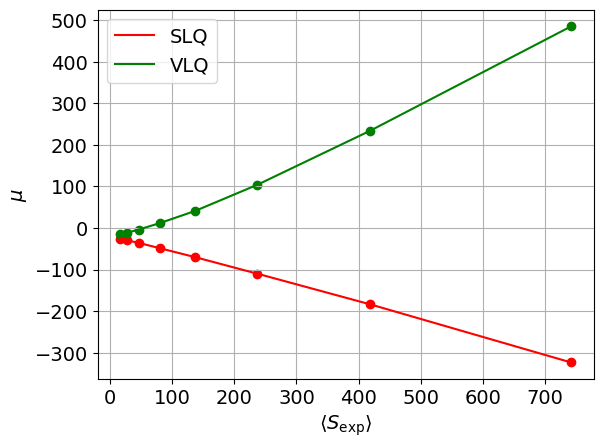

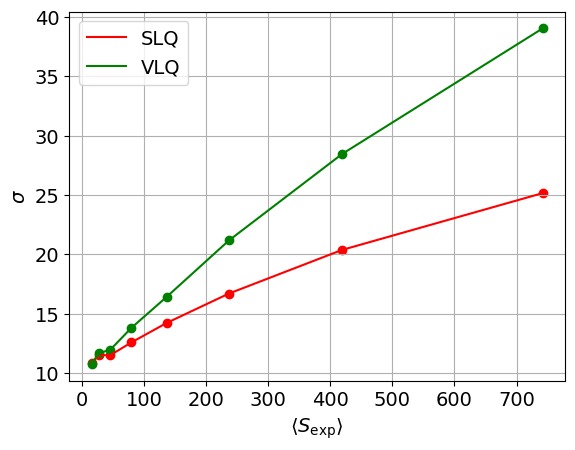

In [76]:
f_mu_S = interp1d(S_exp_SLQ, mu_S, kind='linear', fill_value="extrapolate")
f_mu_V = interp1d(S_exp_SLQ, mu_V, kind='linear', fill_value="extrapolate")

f_sigma_S = interp1d(S_exp_SLQ, sigma_S, kind='linear', fill_value="extrapolate")
f_sigma_V = interp1d(S_exp_SLQ, sigma_V, kind='linear', fill_value="extrapolate")



S_plot = np.linspace(min(S_exp_SLQ), max(S_exp_SLQ), 100)



plt.scatter(S_exp_SLQ, mu_S, marker='o', color='red')
plt.plot(S_plot, f_mu_S(S_plot), color='red', label="SLQ")
plt.scatter(S_exp_SLQ, mu_V, marker='o', color='green')
plt.plot(S_plot, f_mu_V(S_plot), color='green', label="VLQ")

plt.xlabel(r"$\langle S_{\mathrm{exp}} \rangle$", fontsize=14)
plt.ylabel(r"$\mu$", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plt.grid()
plt.savefig(mainfolder + 'saved-results/PDFs_mu.pdf', bbox_inches='tight')
plt.show()


plt.scatter(S_exp_SLQ, sigma_S, marker='o', color='red')
plt.plot(S_plot, f_sigma_S(S_plot), color='red', label="SLQ")
plt.scatter(S_exp_SLQ, sigma_V, marker='o', color='green')
plt.plot(S_plot, f_sigma_V(S_plot), color='green', label="VLQ")

plt.xlabel(r"$\langle S_{\mathrm{exp}} \rangle$", fontsize=14)
plt.ylabel(r"$\sigma$", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plt.grid()
plt.savefig(mainfolder + 'saved-results/PDFs_sigma.pdf', bbox_inches='tight')
plt.show()

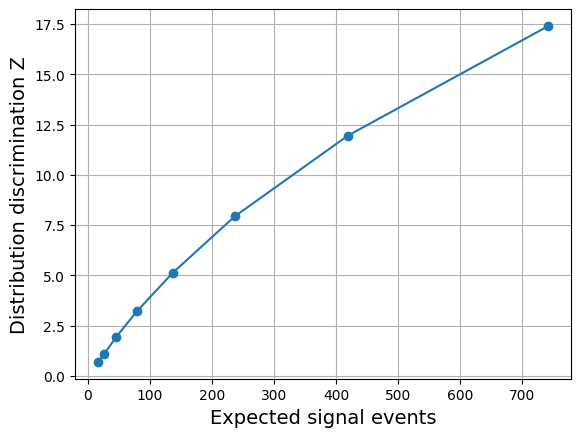

 Z:        5
 S:        133.26337783348268
 m_SLQ:    1506.555477485118  [GeV]
 m_VLQ:    1906.555477485118  [GeV]



/tmp/ipykernel_2784/699503059.py:28: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  mSLQ_threshold = fsolve(lambda x: f_results_Z_mSLQ(x) - Z_threshold,1500)[0]
/tmp/ipykernel_2784/699503059.py:29: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  mVLQ_threshold = fsolve(lambda x: f_results_Z_mVLQ(x) - Z_threshold,1900)[0]


In [77]:
Z_threshold = 5

results_Z_gauss = []

for pair_it in range(len(mu_S)):
    Z = abs(mu_V[pair_it] - mu_S[pair_it]) / np.sqrt(sigma_S[pair_it]**2 + sigma_V[pair_it]**2)

    results_Z_gauss.append(Z)


plt.plot(S_exp_SLQ, results_Z_gauss, marker='o')

plt.xlabel("Expected signal events", fontsize=14)
plt.ylabel("Distribution discrimination Z", fontsize=14)

plt.grid()
plt.show()


#  interpolate
f_results_Z = interp1d(S_exp_SLQ, results_Z_gauss, kind='linear', fill_value="extrapolate")
f_results_Z_mSLQ = interp1d(m_SLQ, results_Z_gauss, kind='linear', fill_value="extrapolate")
f_results_Z_mVLQ = interp1d(m_VLQ, results_Z_gauss, kind='linear', fill_value="extrapolate")


# find the S or the mass such that we get Z_threshold
S_threshold = fsolve(lambda x: f_results_Z(x) - Z_threshold,150)[0]
mSLQ_threshold = fsolve(lambda x: f_results_Z_mSLQ(x) - Z_threshold,1500)[0]
mVLQ_threshold = fsolve(lambda x: f_results_Z_mVLQ(x) - Z_threshold,1900)[0]

print(' Z:       ', Z_threshold)
print(' S:       ', S_threshold)
print(' m_SLQ:   ', mSLQ_threshold, ' [GeV]')
print(' m_VLQ:   ', mVLQ_threshold, ' [GeV]\n')

#### Prepare the data

##### To compute S_expected for each pseudo using the 1st classifier we need the PDFs

In [78]:
# --- Clasificador A: SM vs LQ ---

# output of all the signal events
scoresA_S = xgb_clf.predict_proba( df_LQ_norm )[:, 1]



bins = np.linspace(0, 1, 30)

# normalized histograms of pure signal and pure background
hist_B, _ = np.histogram(scoresA_SM, bins=bins, density=True)
hist_S, _ = np.histogram(scoresA_S, bins=bins, density=True)


bin_width = bins[1] - bins[0]

pS = hist_S * bin_width
pB = hist_B * bin_width

##### to compute the closest mass/index/bechmark

In [79]:
def search_bench(S_pseudo, S_list_means, S_list_std, masses_list=None):
    """ finds the index of the closest benchmark

    Inputs:
    -----------
    S_pseudo : float -> S computed or fitted (e.g. muS_fits_SLQ[i]).
    S_list_means : list/array -> S_mean_fit_both_NEW.
    S_list_std : list/array -> S_std_fit_both_NEW.
    masses_list : list/array (optional) -> masses_NEW.

    Outputs:
    --------
    if masses_list es None -> returns only the index
    if masses_list se incluye -> returns (index, closest mass).
    """
    # convert to array
    means = np.array(S_list_means)
    stds = np.array(S_list_std)

    # do not divide by 0
    stds = np.where(stds == 0, 1e-10, stds)

    # compute the distance to the means, weighted by the std
    z_scores = np.abs(S_pseudo - means) / stds

    # seach the closest index
    idx_min = np.argmin(z_scores)

    # if you also want the mass
    if masses_list is not None:
        best_mass = masses_list[idx_min]
        return idx_min, best_mass

    return idx_min

In [80]:
S_TEST = 453

index_TEST = search_bench(S_TEST, S_mean_fit_both_NEW, S_std_fit_both_NEW )

print('S_TEST: ', S_TEST)
print('index: ', index_TEST)
print('S_fit: ', S_mean_fit_both_NEW[index_TEST])
print('S_fit_std: ', S_std_fit_both_NEW[index_TEST])
print('mass: ', masses_NEW[index_TEST])

S_TEST:  453
index:  20
S_fit:  463.85944662598297
S_fit_std:  25.733633697903343
mass:  1280.0


In [81]:
S_TEST = 453

index_TEST = search_bench(S_TEST, S_mean_fit_both, S_std_fit_both )

print('S_TEST: ', S_TEST)
print('index: ', index_TEST)
print('S_fit: ', S_mean_fit_both[index_TEST])
print('S_fit_std: ', S_std_fit_both[index_TEST])
print('mass: ', masses_SLQ[index_TEST])

S_TEST:  453
index:  3
S_fit:  416.292342085481
S_fit_std:  24.495727026389737
mass:  1300


### Super loop


S_expected_SLQ = 742
mass_SLQ = 1200  GeV
mass_VLQ = 1600  GeV


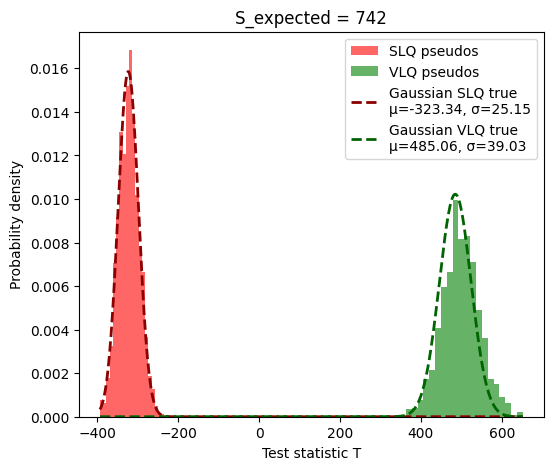

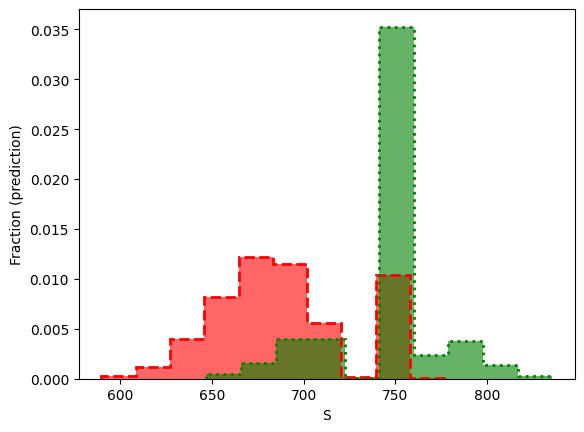

S mean SLQ:  688.2223715552767
S std SLQ:  34.26461767655938
S mean VLQ:  740.0643730227463
S std VLQ:  27.32583233838439

 COMPARING WITH DISCRETE MASS EXAMPLES (minimizing Z) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.95
1 = VLQ only : 0.0
2 = both     : 0.0
3 = neither  : 0.05

Prefered SLQ mass:  [0.999 0.001 0.    0.    0.    0.    0.    0.   ]
Prefered VLQ mass:  [0.    0.968 0.032 0.    0.    0.    0.    0.   ]

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.884
2 = both     : 0.0
3 = neither  : 0.116

Prefered SLQ mass:  [0.972 0.028 0.    0.    0.    0.    0.    0.   ]
Prefered VLQ mass:  [1. 0. 0. 0. 0. 0. 0. 0.]

------
 COMPARING WITH DISCRETE MASS EXAMPLES (following S) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.924
1 = VLQ only : 0.0
2 = both     : 0.0
3 = neither  : 0.076

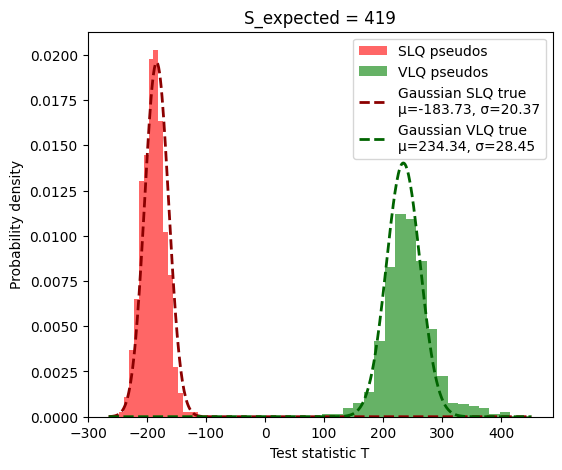

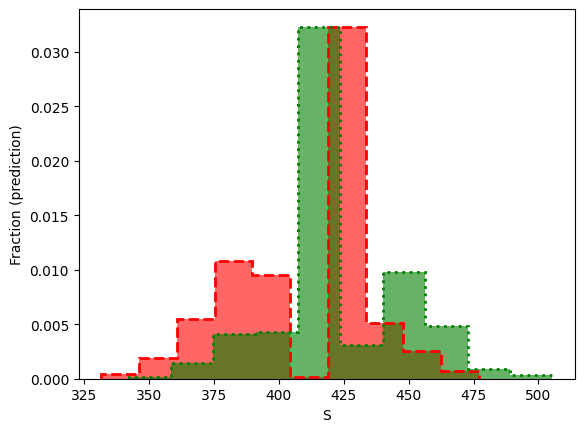

S mean SLQ:  407.4990515240143
S std SLQ:  24.501034204758916
S mean VLQ:  424.11849633896105
S std VLQ:  23.525143661264817

 COMPARING WITH DISCRETE MASS EXAMPLES (minimizing Z) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.961
1 = VLQ only : 0.0
2 = both     : 0.0
3 = neither  : 0.039

Prefered SLQ mass:  [0.003 0.984 0.013 0.    0.    0.    0.    0.   ]
Prefered VLQ mass:  [0.    0.    0.744 0.243 0.007 0.    0.006 0.   ]

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.877
2 = both     : 0.0
3 = neither  : 0.123

Prefered SLQ mass:  [0.002 0.679 0.298 0.008 0.    0.    0.013 0.   ]
Prefered VLQ mass:  [0.035 0.944 0.021 0.    0.    0.    0.    0.   ]

------
 COMPARING WITH DISCRETE MASS EXAMPLES (following S) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.943
1 = VLQ only : 0.0
2 = both  

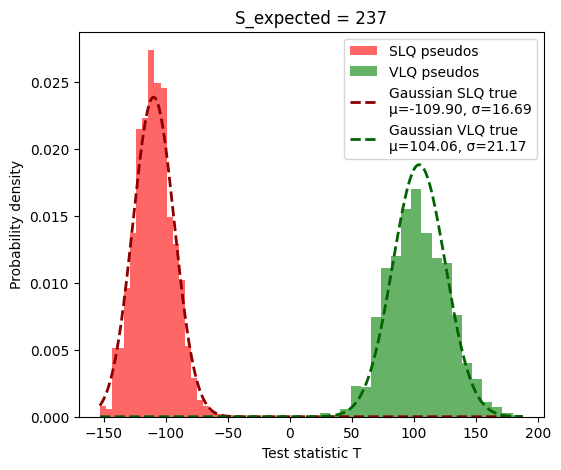

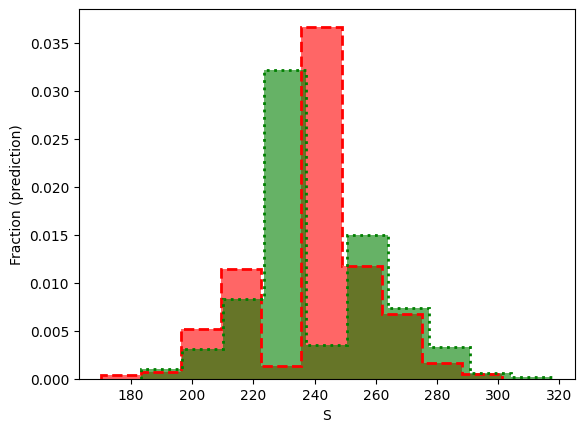

S mean SLQ:  237.74302106966528
S std SLQ:  19.448111420865583
S mean VLQ:  243.41788479780607
S std VLQ:  20.465318213753797

 COMPARING WITH DISCRETE MASS EXAMPLES (minimizing Z) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.996
1 = VLQ only : 0.0
2 = both     : 0.0
3 = neither  : 0.004

Prefered SLQ mass:  [0.    0.008 0.902 0.089 0.001 0.    0.    0.   ]
Prefered VLQ mass:  [0.    0.    0.    0.008 0.026 0.    0.965 0.001]

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.956
2 = both     : 0.0
3 = neither  : 0.044

Prefered SLQ mass:  [0.    0.    0.014 0.038 0.    0.    0.945 0.003]
Prefered VLQ mass:  [0.    0.013 0.923 0.063 0.001 0.    0.    0.   ]

------
 COMPARING WITH DISCRETE MASS EXAMPLES (following S) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.967
1 = VLQ only : 0.0
2 = both 

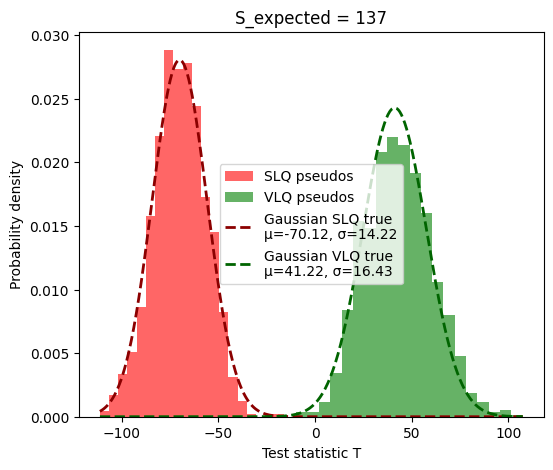

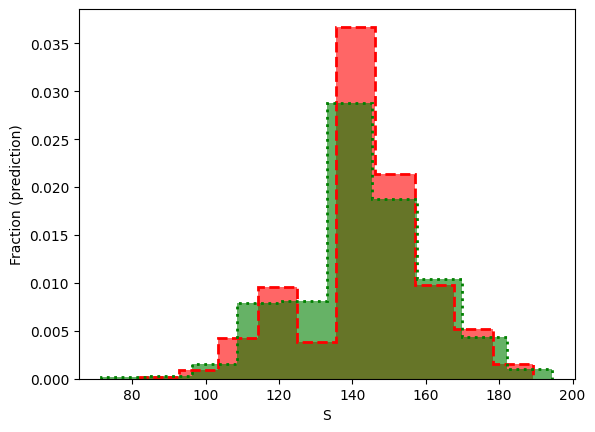

S mean SLQ:  142.21844312239602
S std SLQ:  17.036295343461283
S mean VLQ:  142.11382877485738
S std VLQ:  18.02760774614255

 COMPARING WITH DISCRETE MASS EXAMPLES (minimizing Z) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.995
1 = VLQ only : 0.0
2 = both     : 0.005
3 = neither  : 0.0

Prefered SLQ mass:  [0.    0.    0.078 0.715 0.195 0.01  0.    0.002]
Prefered VLQ mass:  [0.    0.    0.    0.    0.    0.    0.822 0.178]

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.998
2 = both     : 0.002
3 = neither  : 0.0

Prefered SLQ mass:  [0.    0.    0.    0.    0.    0.    0.699 0.301]
Prefered VLQ mass:  [0.    0.    0.077 0.754 0.163 0.005 0.001 0.   ]

------
 COMPARING WITH DISCRETE MASS EXAMPLES (following S) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.964
1 = VLQ only : 0.0
2 = both  

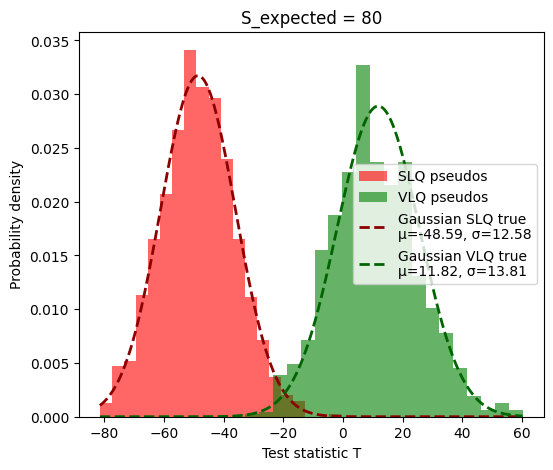

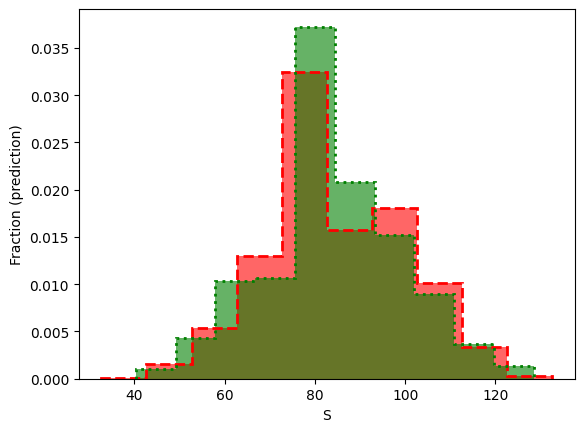

S mean SLQ:  85.20745760839901
S std SLQ:  15.197752698551504
S mean VLQ:  83.87950031495912
S std VLQ:  15.155404580041166

 COMPARING WITH DISCRETE MASS EXAMPLES (minimizing Z) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.849
1 = VLQ only : 0.001
2 = both     : 0.15
3 = neither  : 0.0

Prefered SLQ mass:  [0.    0.    0.    0.207 0.497 0.194 0.056 0.046]
Prefered VLQ mass:  [0.    0.    0.    0.    0.    0.001 0.243 0.756]

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.845
2 = both     : 0.155
3 = neither  : 0.0

Prefered SLQ mass:  [0.    0.    0.    0.    0.    0.001 0.066 0.933]
Prefered VLQ mass:  [0.    0.    0.    0.153 0.531 0.214 0.054 0.048]

------
 COMPARING WITH DISCRETE MASS EXAMPLES (following S) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.921
1 = VLQ only : 0.003
2 = both

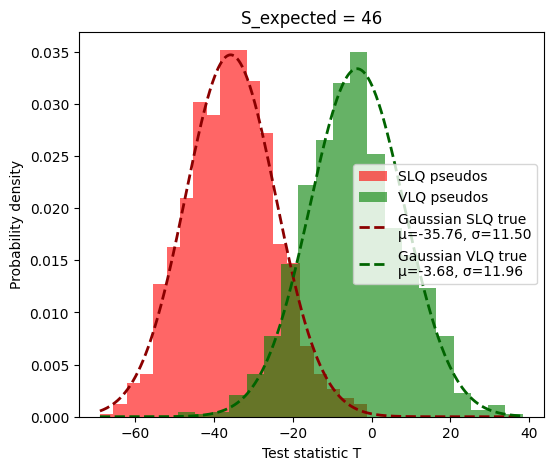

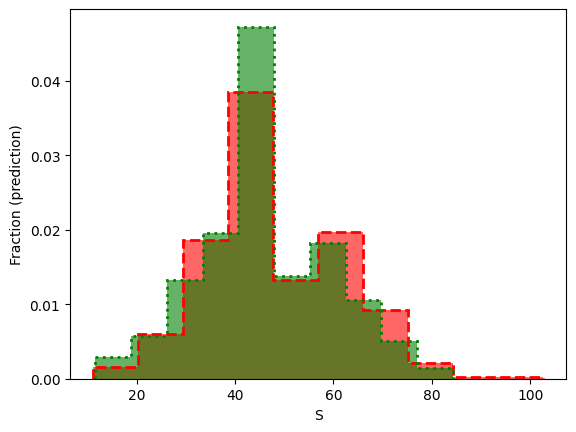

S mean SLQ:  48.64810452201052
S std SLQ:  13.710310007180645
S mean VLQ:  46.829020777661356
S std VLQ:  13.1157846868498

 COMPARING WITH DISCRETE MASS EXAMPLES (minimizing Z) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.486
1 = VLQ only : 0.004
2 = both     : 0.51
3 = neither  : 0.0

Prefered SLQ mass:  [0.    0.    0.    0.016 0.28  0.313 0.158 0.233]
Prefered VLQ mass:  [0.   0.   0.   0.   0.   0.01 0.04 0.95]

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.005
1 = VLQ only : 0.484
2 = both     : 0.511
3 = neither  : 0.0

Prefered SLQ mass:  [0.    0.    0.    0.    0.003 0.009 0.02  0.968]
Prefered VLQ mass:  [0.    0.    0.    0.009 0.243 0.347 0.152 0.249]

------
 COMPARING WITH DISCRETE MASS EXAMPLES (following S) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.726
1 = VLQ only : 0.028
2 = both     : 

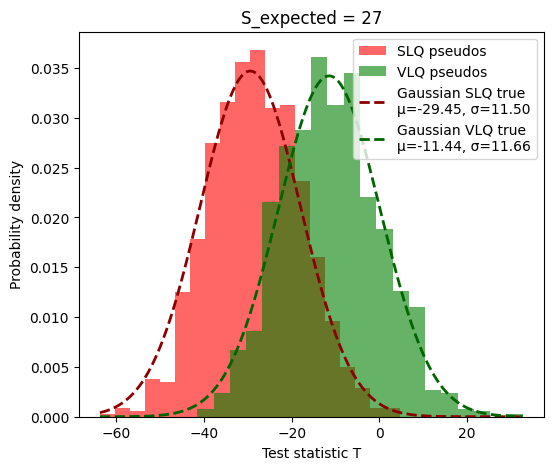

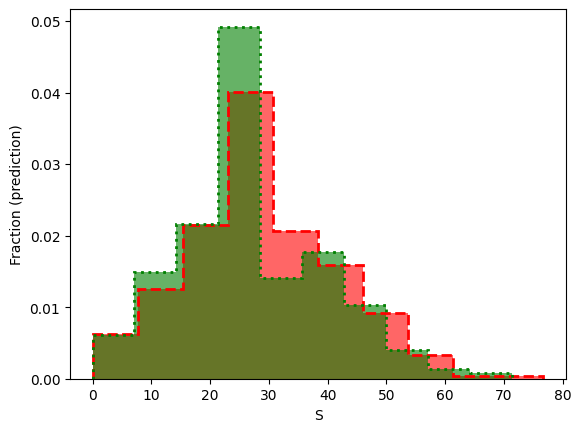

S mean SLQ:  28.83929583373269
S std SLQ:  12.773804858447537
S mean VLQ:  27.63647145194001
S std VLQ:  12.480403193976821

 COMPARING WITH DISCRETE MASS EXAMPLES (minimizing Z) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.236
1 = VLQ only : 0.015
2 = both     : 0.749
3 = neither  : 0.0

Prefered SLQ mass:  [0.    0.    0.    0.001 0.094 0.259 0.171 0.475]
Prefered VLQ mass:  [0.    0.    0.    0.    0.002 0.025 0.055 0.918]

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.009
1 = VLQ only : 0.269
2 = both     : 0.722
3 = neither  : 0.0

Prefered SLQ mass:  [0.    0.    0.    0.    0.    0.022 0.038 0.94 ]
Prefered VLQ mass:  [0.    0.    0.    0.001 0.106 0.27  0.194 0.429]

------
 COMPARING WITH DISCRETE MASS EXAMPLES (following S) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.351
1 = VLQ only : 0.032
2 = b

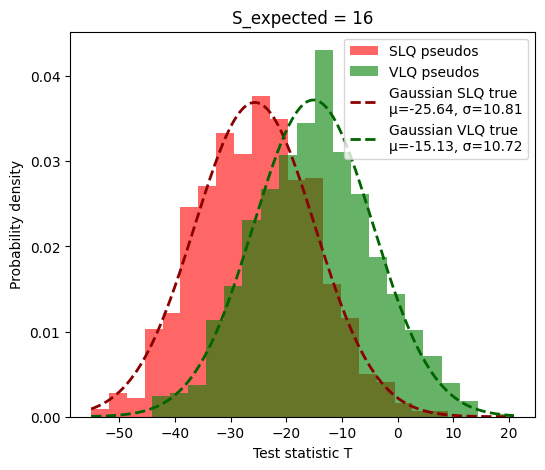

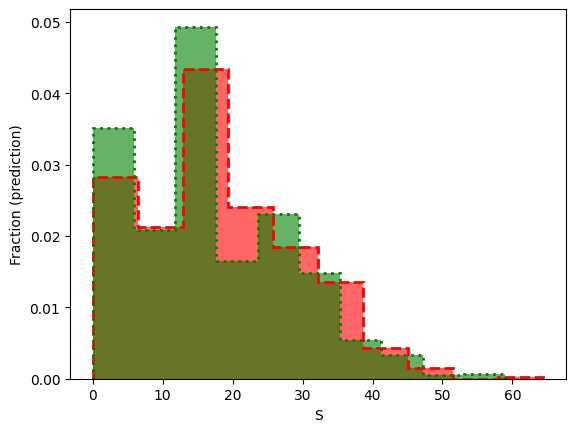

S mean SLQ:  17.870440401781053
S std SLQ:  11.562078205478098
S mean VLQ:  17.09681196766057
S std VLQ:  11.483477478283072

 COMPARING WITH DISCRETE MASS EXAMPLES (minimizing Z) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.159
1 = VLQ only : 0.027
2 = both     : 0.814
3 = neither  : 0.0

Prefered SLQ mass:  [0.    0.    0.    0.    0.056 0.199 0.164 0.581]
Prefered VLQ mass:  [0.    0.    0.    0.    0.003 0.044 0.078 0.875]

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.022
1 = VLQ only : 0.17
2 = both     : 0.808
3 = neither  : 0.0

Prefered SLQ mass:  [0.    0.    0.    0.    0.004 0.043 0.078 0.875]
Prefered VLQ mass:  [0.    0.    0.    0.    0.048 0.203 0.191 0.558]

------
 COMPARING WITH DISCRETE MASS EXAMPLES (following S) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.184
1 = VLQ only : 0.045
2 = b

In [82]:
Z_threshold = 1.96

n_pseudo = 1000

# benchmarks
classification_SLQ = []
classification_VLQ = []

classification_SLQ_BPOK = []
classification_VLQ_BPOK = []

# interpolate
classification_SLQ_inter = []
classification_VLQ_inter = []

# previously known PDFs
classification_SLQ_prev = []
classification_VLQ_prev = []

# mean then interpolate just 1
classification_SLQ_inter1 = []
classification_VLQ_inter1 = []

# interpolate but with lots of benchmarks
classification_SLQ_interB = []
classification_VLQ_interB = []


Z_SLQ = []
Z_VLQ = []

Z_SLQ_BPOK = []
Z_VLQ_BPOK = []

Z_SLQ_inter = []
Z_VLQ_inter = []

Z_SLQ_prev = []
Z_VLQ_prev = []

Z_SLQ_inter1 = []
Z_VLQ_inter1 = []

Z_SLQ_interB = []
Z_VLQ_interB = []


mu_TSLQ = []
std_TSLQ = []
mu_TVLQ = []
std_TVLQ = []



for ii_S, S_exp in enumerate(S_exp_SLQ):

    print("\n==========================")

    print("S_expected_SLQ =", S_exp_SLQ[ii_S])
    # print("S_expected_VLQ =", S_exp_VLQ[ii_S]) # same number of events


    # dado un S, le asigna la masa (del SLQ o VLQ) correspondiente
    mass_SLQ = m_SLQ[ii_S]
    mass_VLQ = m_VLQ[ii_S]
    print("mass_SLQ =", mass_SLQ, " GeV")
    print("mass_VLQ =", mass_VLQ, " GeV")


    # computamos el T statistic para todos los pseudo
    T_SLQ = []
    T_VLQ = []

    # compute the number of events
    muS_fits_SLQ = []
    muS_fits_VLQ = []


    for i in range(n_pseudo):

        N_B = np.random.poisson(B_expected)

        # indices of the events
        idx_B = np.random.choice(len(events_SM[:,0]), N_B)

        scoresA_B = events_SM[:,0][idx_B]
        scoresB_B = events_SM[:,1][idx_B]



        ###########
        # FOR SLQ #
        ###########

        N_S = np.random.poisson(S_exp_SLQ[ii_S])

        # indices of the events
        idx_S = np.random.choice(len(events_SLQ[mass_SLQ][:,0]), N_S)

        scoresA_S = events_SLQ[mass_SLQ][:,0][idx_S]


        data_scores = np.concatenate([scoresA_B, scoresA_S])

        hist_data, _ = np.histogram(data_scores, bins=bins)

        # 2) Define likelihood for this pseudo (gotta do it for the minimizer)
        def neg_logL(params):
            mu_S, mu_B = params

            lambda_i = mu_S * pS + mu_B * pB
            lambda_i = np.clip(lambda_i, 1e-10, None)

            return -np.sum(hist_data * np.log(lambda_i) - lambda_i)

        # 3) Minimizar
        result = minimize(
            neg_logL,
            x0=[S_exp, B_expected],
            bounds=[(0, None), (0, None)]
        )

        muS_fit, muB_fit = result.x

        muS_fits_SLQ.append(muS_fit)


        # the pseudo exp
        X_pseudo_S = df_SLQ_norm[mass_SLQ].loc[idx_S].values
        # add the S fitted
        X_pseudo_S = np.column_stack([X_pseudo_S, np.full(len(X_pseudo_S), muS_fit)])

        scoresB_S = classifier_spin.predict_proba(X_pseudo_S)[:,1]


        scoresA = np.concatenate([scoresA_B, scoresA_S])
        scoresB = np.concatenate([scoresB_B, scoresB_S])

        T = compute_test_statistic(scoresA, scoresB, threshold_A)

        T_SLQ.append(T)




        ###########
        # FOR VLQ #
        ###########

        N_S = np.random.poisson(S_exp_SLQ[ii_S]) # same number of events

        # indices of the events
        idx_S = np.random.choice(len(events_VLQ[mass_VLQ][:,0]), N_S)

        scoresA_S = events_VLQ[mass_VLQ][:,0][idx_S]


        data_scores = np.concatenate([scoresA_B, scoresA_S])

        hist_data, _ = np.histogram(data_scores, bins=bins)

        # 2) Define likelihood for this pseudo (gotta do it for the minimizer)
        def neg_logL(params):
            mu_S, mu_B = params

            lambda_i = mu_S * pS + mu_B * pB
            lambda_i = np.clip(lambda_i, 1e-10, None)

            return -np.sum(hist_data * np.log(lambda_i) - lambda_i)

        # 3) Minimizar
        result = minimize(
            neg_logL,
            x0=[S_exp, B_expected],
            bounds=[(0, None), (0, None)]
        )

        muS_fit, muB_fit = result.x

        muS_fits_VLQ.append(muS_fit)


        # the pseudo exp
        X_pseudo_V = df_VLQ_norm[mass_VLQ].loc[idx_S].values
        # add the S fitted
        X_pseudo_V = np.column_stack([X_pseudo_V, np.full(len(X_pseudo_V), muS_fit)])

        scoresB_S = classifier_spin.predict_proba(X_pseudo_V)[:,1]


        scoresA = np.concatenate([scoresA_B, scoresA_S])
        scoresB = np.concatenate([scoresB_B, scoresB_S])

        T = compute_test_statistic(scoresA, scoresB, threshold_A)

        T_VLQ.append(T)

    # Compute the characteristics of the psedo-experiment T distributions
    mu_TSLQ.append( np.mean(T_SLQ) )
    mu_TVLQ.append( np.mean(T_VLQ) )

    std_TSLQ.append( np.std(T_SLQ) )
    std_TVLQ.append( np.std(T_VLQ) )




    # rango común para plotear
    xmin = min(np.min(T_SLQ), np.min(T_VLQ))
    xmax = max(np.max(T_SLQ), np.max(T_VLQ))
    x = np.linspace(xmin, xmax, 500)

    # gaussianas
    gauss_S = (1/(sigma_S[ii_S]*np.sqrt(2*np.pi))) * np.exp(-(x - mu_S[ii_S])**2 / (2*sigma_S[ii_S]**2))
    gauss_V = (1/(sigma_V[ii_S]*np.sqrt(2*np.pi))) * np.exp(-(x - mu_V[ii_S])**2 / (2*sigma_V[ii_S]**2))


    # plot gaussian PDFs + pseudo-experiments (of the same sector) distributions
    plt.figure(figsize=(6,5))

    plt.hist(T_SLQ, bins=20, density=True, color='red', alpha=0.6, label="SLQ pseudos")
    plt.hist(T_VLQ, bins=20, density=True, color='green', alpha=0.6, label="VLQ pseudos")

    # gaussianas
    plt.plot(x, gauss_S, color='darkred', linewidth=2, linestyle='--', label=f"Gaussian SLQ true\nμ={mu_S[ii_S]:.2f}, σ={sigma_S[ii_S]:.2f}")
    plt.plot(x, gauss_V, color='darkgreen', linewidth=2, linestyle='--', label=f"Gaussian VLQ true\nμ={mu_V[ii_S]:.2f}, σ={sigma_V[ii_S]:.2f}")

    plt.xlabel("Test statistic T")
    plt.ylabel("Probability density")
    plt.title(f"S_expected = {S_exp}")
    plt.legend()

    plt.show()


    plt.hist(muS_fits_SLQ, bins=10, histtype='step', linestyle='--', edgecolor='red', linewidth=2, density=True)
    plt.hist(muS_fits_SLQ, bins=10, color='red', alpha=0.6, density=True)
    plt.hist(muS_fits_VLQ, bins=10, histtype='step', linestyle=':', edgecolor='green', linewidth=2, density=True)
    plt.hist(muS_fits_VLQ, bins=10, color='green', alpha=0.6, density=True)
    plt.xlabel("S")
    plt.ylabel("Fraction (prediction)")
    plt.show()

    print('S mean SLQ: ', np.mean(muS_fits_SLQ))
    print('S std SLQ: ', np.std(muS_fits_SLQ))
    print('S mean VLQ: ', np.mean(muS_fits_VLQ))
    print('S std VLQ: ', np.std(muS_fits_VLQ))
    print('')


    # COMPARING WITH DISCRETE MASS EXAMPLES (minimizing Z)

    # Vamos a clasificar cada pseudo
    # 0: SLQ
    # 1: VLQ
    # 2: compatible con ambos
    # 3: incompatible con ambos
    pred_counts_SLQ = [0,0,0,0]
    pred_counts_VLQ = [0,0,0,0]

    BP_true_SLQ_theo_SLQ = np.zeros(len(mu_S), dtype=int)
    BP_true_SLQ_theo_VLQ = np.zeros(len(mu_S), dtype=int)

    BP_true_VLQ_theo_SLQ = np.zeros(len(mu_S), dtype=int)
    BP_true_VLQ_theo_VLQ = np.zeros(len(mu_S), dtype=int)


    Z_SLQ_step = []
    Z_VLQ_step = []

    for i in range(n_pseudo):

        # TRUE: SLQ
        T_obs = T_SLQ[i]

        Z_SLQ_BPs = []
        Z_VLQ_BPs = []

        for i_BP in range(len(mu_S)):

            Z_SLQ_BPs.append( abs(T_obs - mu_S[i_BP]) / sigma_S[i_BP] )
            Z_VLQ_BPs.append( abs(T_obs - mu_V[i_BP]) / sigma_V[i_BP] )

        Z_SLQ_best = min(Z_SLQ_BPs)
        Z_VLQ_best = min(Z_VLQ_BPs)

        Z_SLQ_step.append([Z_SLQ_best, Z_VLQ_best])

        BP_min_SLQ = Z_SLQ_BPs.index(Z_SLQ_best)
        BP_min_VLQ = Z_VLQ_BPs.index(Z_VLQ_best)

        BP_true_SLQ_theo_SLQ[BP_min_SLQ] += 1
        BP_true_SLQ_theo_VLQ[BP_min_VLQ] += 1

        SLQ_ok = Z_SLQ_best < Z_threshold
        VLQ_ok = Z_VLQ_best < Z_threshold


        if SLQ_ok and not VLQ_ok:
            pred = 0
        elif VLQ_ok and not SLQ_ok:
            pred = 1
        elif SLQ_ok and VLQ_ok:
            pred = 2
        else:
            pred = 3

        pred_counts_SLQ[pred] += 1


        # TRUE: VLQ
        T_obs = T_VLQ[i]

        Z_SLQ_BPs = []
        Z_VLQ_BPs = []

        for i_BP in range(len(mu_S)):

            Z_SLQ_BPs.append( abs(T_obs - mu_S[i_BP]) / sigma_S[i_BP] )
            Z_VLQ_BPs.append( abs(T_obs - mu_V[i_BP]) / sigma_V[i_BP] )

        Z_SLQ_best = min(Z_SLQ_BPs)
        Z_VLQ_best = min(Z_VLQ_BPs)

        Z_VLQ_step.append([Z_SLQ_best, Z_VLQ_best])

        BP_min_SLQ = Z_SLQ_BPs.index(Z_SLQ_best)
        BP_min_VLQ = Z_VLQ_BPs.index(Z_VLQ_best)

        BP_true_VLQ_theo_SLQ[BP_min_SLQ] += 1
        BP_true_VLQ_theo_VLQ[BP_min_VLQ] += 1

        SLQ_ok = Z_SLQ_best < Z_threshold
        VLQ_ok = Z_VLQ_best < Z_threshold


        if SLQ_ok and not VLQ_ok:
            pred = 0
        elif VLQ_ok and not SLQ_ok:
            pred = 1
        elif SLQ_ok and VLQ_ok:
            pred = 2
        else:
            pred = 3

        pred_counts_VLQ[pred] += 1


    Z_SLQ.append(np.array(Z_SLQ_step))
    Z_VLQ.append(np.array(Z_VLQ_step))


    # SLQ
    pred_counts_SLQ = np.array(pred_counts_SLQ) / n_pseudo

    BP_true_SLQ_theo_SLQ_ratio = BP_true_SLQ_theo_SLQ / n_pseudo
    BP_true_SLQ_theo_VLQ_ratio = BP_true_SLQ_theo_VLQ / n_pseudo

    print(" COMPARING WITH DISCRETE MASS EXAMPLES (minimizing Z) ")

    print("TESTING SLQ")
    print("Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)")
    print("0 = SLQ only :", pred_counts_SLQ[0])
    print("1 = VLQ only :", pred_counts_SLQ[1])
    print("2 = both     :", pred_counts_SLQ[2])
    print("3 = neither  :", pred_counts_SLQ[3])

    print('\nPrefered SLQ mass: ', BP_true_SLQ_theo_SLQ_ratio)
    print('Prefered VLQ mass: ', BP_true_SLQ_theo_VLQ_ratio)

    classification_SLQ.append(pred_counts_SLQ)


    print('')

    # VLQ
    pred_counts_VLQ = np.array(pred_counts_VLQ) / n_pseudo

    BP_true_VLQ_theo_SLQ_ratio = BP_true_VLQ_theo_SLQ / n_pseudo
    BP_true_VLQ_theo_VLQ_ratio = BP_true_VLQ_theo_VLQ / n_pseudo

    print("TESTING VLQ")
    print("Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)")
    print("0 = SLQ only :", pred_counts_VLQ[0])
    print("1 = VLQ only :", pred_counts_VLQ[1])
    print("2 = both     :", pred_counts_VLQ[2])
    print("3 = neither  :", pred_counts_VLQ[3])

    print('\nPrefered SLQ mass: ', BP_true_VLQ_theo_SLQ_ratio)
    print('Prefered VLQ mass: ', BP_true_VLQ_theo_VLQ_ratio)

    classification_VLQ.append(pred_counts_VLQ)





    # COMPARING WITH DISCRETE MASS EXAMPLES (following S)

    # Vamos a clasificar cada pseudo
    # 0: SLQ
    # 1: VLQ
    # 2: compatible con ambos
    # 3: incompatible con ambos
    pred_counts_SLQ = [0,0,0,0]
    pred_counts_VLQ = [0,0,0,0]

    Z_SLQ_BPOK_step = []
    Z_VLQ_BPOK_step = []

    for i in range(n_pseudo):

        # TRUE: SLQ
        index_pseudo = search_bench(muS_fits_SLQ[i], S_mean_fit_both, S_std_fit_both )

        T_obs = T_SLQ[i]

        Z_SLQ_val = abs(T_obs - f_mu_S(S_mean_fit_both[index_pseudo])) / f_sigma_S(S_mean_fit_both[index_pseudo])
        Z_VLQ_val = abs(T_obs - f_mu_V(S_mean_fit_both[index_pseudo])) / f_sigma_V(S_mean_fit_both[index_pseudo])

        Z_SLQ_BPOK_step.append([Z_SLQ_val, Z_VLQ_val])

        SLQ_ok = Z_SLQ_val < Z_threshold
        VLQ_ok = Z_VLQ_val < Z_threshold


        if SLQ_ok and not VLQ_ok:
            pred = 0
        elif VLQ_ok and not SLQ_ok:
            pred = 1
        elif SLQ_ok and VLQ_ok:
            pred = 2
        else:
            pred = 3

        pred_counts_SLQ[pred] += 1


        # TRUE: VLQ
        index_pseudo = search_bench(muS_fits_VLQ[i], S_mean_fit_both, S_std_fit_both )

        T_obs = T_VLQ[i]

        Z_SLQ_val = abs(T_obs - f_mu_S(S_mean_fit_both[index_pseudo])) / f_sigma_S(S_mean_fit_both[index_pseudo])
        Z_VLQ_val = abs(T_obs - f_mu_V(S_mean_fit_both[index_pseudo])) / f_sigma_V(S_mean_fit_both[index_pseudo])

        Z_VLQ_BPOK_step.append([Z_SLQ_val, Z_VLQ_val])

        SLQ_ok = Z_SLQ_val < Z_threshold
        VLQ_ok = Z_VLQ_val < Z_threshold


        if SLQ_ok and not VLQ_ok:
            pred = 0
        elif VLQ_ok and not SLQ_ok:
            pred = 1
        elif SLQ_ok and VLQ_ok:
            pred = 2
        else:
            pred = 3

        pred_counts_VLQ[pred] += 1


    Z_SLQ_BPOK.append(np.array(Z_SLQ_BPOK_step))
    Z_VLQ_BPOK.append(np.array(Z_VLQ_BPOK_step))


    # SLQ
    pred_counts_SLQ = np.array(pred_counts_SLQ) / n_pseudo

    print("\n------")
    print(" COMPARING WITH DISCRETE MASS EXAMPLES (following S) ")

    print("TESTING SLQ")
    print("Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)")
    print("0 = SLQ only :", pred_counts_SLQ[0])
    print("1 = VLQ only :", pred_counts_SLQ[1])
    print("2 = both     :", pred_counts_SLQ[2])
    print("3 = neither  :", pred_counts_SLQ[3])

    classification_SLQ_BPOK.append(pred_counts_SLQ)


    print('')

    # VLQ
    pred_counts_VLQ = np.array(pred_counts_VLQ) / n_pseudo

    print("TESTING VLQ")
    print("Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)")
    print("0 = SLQ only :", pred_counts_VLQ[0])
    print("1 = VLQ only :", pred_counts_VLQ[1])
    print("2 = both     :", pred_counts_VLQ[2])
    print("3 = neither  :", pred_counts_VLQ[3])

    classification_VLQ_BPOK.append(pred_counts_VLQ)





    # COMPARING WITH CONTINUOUS MASSES (interpolation)

    # Vamos a clasificar cada pseudo
    # 0: SLQ
    # 1: VLQ
    # 2: compatible con ambos
    # 3: incompatible con ambos
    pred_counts_SLQ = [0,0,0,0]
    pred_counts_VLQ = [0,0,0,0]

    Z_SLQ_inter_step = []
    Z_VLQ_inter_step = []

    for i in range(n_pseudo):

        # TRUE: SLQ
        T_obs = T_SLQ[i]

        Z_SLQ_val = abs(T_obs - f_mu_S(muS_fits_SLQ[i])) / f_sigma_S(muS_fits_SLQ[i])
        Z_VLQ_val = abs(T_obs - f_mu_V(muS_fits_SLQ[i])) / f_sigma_V(muS_fits_SLQ[i])

        Z_SLQ_inter_step.append([Z_SLQ_val, Z_VLQ_val])

        SLQ_ok = Z_SLQ_val < Z_threshold
        VLQ_ok = Z_VLQ_val < Z_threshold


        if SLQ_ok and not VLQ_ok:
            pred = 0
        elif VLQ_ok and not SLQ_ok:
            pred = 1
        elif SLQ_ok and VLQ_ok:
            pred = 2
        else:
            pred = 3

        pred_counts_SLQ[pred] += 1


        # TRUE: VLQ
        T_obs = T_VLQ[i]

        Z_SLQ_val = abs(T_obs - f_mu_S(muS_fits_VLQ[i])) / f_sigma_S(muS_fits_VLQ[i])
        Z_VLQ_val = abs(T_obs - f_mu_V(muS_fits_VLQ[i])) / f_sigma_V(muS_fits_VLQ[i])

        Z_VLQ_inter_step.append([Z_SLQ_val, Z_VLQ_val])

        SLQ_ok = Z_SLQ_val < Z_threshold
        VLQ_ok = Z_VLQ_val < Z_threshold


        if SLQ_ok and not VLQ_ok:
            pred = 0
        elif VLQ_ok and not SLQ_ok:
            pred = 1
        elif SLQ_ok and VLQ_ok:
            pred = 2
        else:
            pred = 3

        pred_counts_VLQ[pred] += 1


    Z_SLQ_inter.append(np.array(Z_SLQ_inter_step))
    Z_VLQ_inter.append(np.array(Z_VLQ_inter_step))


    # SLQ
    pred_counts_SLQ = np.array(pred_counts_SLQ) / n_pseudo

    print("\n------")
    print(" COMPARING WITH CONTINUOUS MASSES (interpolation) ")

    print("TESTING SLQ")
    print("Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)")
    print("0 = SLQ only :", pred_counts_SLQ[0])
    print("1 = VLQ only :", pred_counts_SLQ[1])
    print("2 = both     :", pred_counts_SLQ[2])
    print("3 = neither  :", pred_counts_SLQ[3])

    classification_SLQ_inter.append(pred_counts_SLQ)


    print('')

    # VLQ
    pred_counts_VLQ = np.array(pred_counts_VLQ) / n_pseudo

    print("TESTING VLQ")
    print("Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)")
    print("0 = SLQ only :", pred_counts_VLQ[0])
    print("1 = VLQ only :", pred_counts_VLQ[1])
    print("2 = both     :", pred_counts_VLQ[2])
    print("3 = neither  :", pred_counts_VLQ[3])

    classification_VLQ_inter.append(pred_counts_VLQ)





    # COMPARING WITH THE PREVIOUSLY KNOWN PDF

    # Vamos a clasificar cada pseudo
    # 0: SLQ
    # 1: VLQ
    # 2: compatible con ambos
    # 3: incompatible con ambos
    pred_counts_SLQ = [0,0,0,0]
    pred_counts_VLQ = [0,0,0,0]

    Z_SLQ_prev_step = []
    Z_VLQ_prev_step = []

    for i in range(n_pseudo):

        # TRUE: SLQ
        T_obs = T_SLQ[i]

        Z_SLQ_val = abs(T_obs - mu_S[ii_S]) / sigma_S[ii_S]
        Z_VLQ_val = abs(T_obs - mu_V[ii_S]) / sigma_V[ii_S]

        Z_SLQ_prev_step.append([Z_SLQ_val, Z_VLQ_val])

        SLQ_ok = Z_SLQ_val < Z_threshold
        VLQ_ok = Z_VLQ_val < Z_threshold


        if SLQ_ok and not VLQ_ok:
            pred = 0
        elif VLQ_ok and not SLQ_ok:
            pred = 1
        elif SLQ_ok and VLQ_ok:
            pred = 2
        else:
            pred = 3

        pred_counts_SLQ[pred] += 1


        # TRUE: VLQ
        T_obs = T_VLQ[i]

        Z_SLQ_val = abs(T_obs - mu_S[ii_S]) / sigma_S[ii_S]
        Z_VLQ_val = abs(T_obs - mu_V[ii_S]) / sigma_V[ii_S]

        Z_VLQ_prev_step.append([Z_SLQ_val, Z_VLQ_val])

        SLQ_ok = Z_SLQ_val < Z_threshold
        VLQ_ok = Z_VLQ_val < Z_threshold


        if SLQ_ok and not VLQ_ok:
            pred = 0
        elif VLQ_ok and not SLQ_ok:
            pred = 1
        elif SLQ_ok and VLQ_ok:
            pred = 2
        else:
            pred = 3

        pred_counts_VLQ[pred] += 1


    Z_SLQ_prev.append(np.array(Z_SLQ_prev_step))
    Z_VLQ_prev.append(np.array(Z_VLQ_prev_step))


    # SLQ
    pred_counts_SLQ = np.array(pred_counts_SLQ) / n_pseudo

    print("\n------")
    print(" COMPARING WITH THE PREVIOUSLY KNOWN PDF ")

    print("TESTING SLQ")
    print("Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)")
    print("0 = SLQ only :", pred_counts_SLQ[0])
    print("1 = VLQ only :", pred_counts_SLQ[1])
    print("2 = both     :", pred_counts_SLQ[2])
    print("3 = neither  :", pred_counts_SLQ[3])

    classification_SLQ_prev.append(pred_counts_SLQ)


    print('')

    # VLQ
    pred_counts_VLQ = np.array(pred_counts_VLQ) / n_pseudo

    print("TESTING VLQ")
    print("Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)")
    print("0 = SLQ only :", pred_counts_VLQ[0])
    print("1 = VLQ only :", pred_counts_VLQ[1])
    print("2 = both     :", pred_counts_VLQ[2])
    print("3 = neither  :", pred_counts_VLQ[3])

    classification_VLQ_prev.append(pred_counts_VLQ)





    # COMPARING WITH CONTINUOUS MASSES (interpolate just once, the mean of S)
    muS_fits_SLQ_mean = np.mean(muS_fits_SLQ)
    muS_fits_VLQ_mean = np.mean(muS_fits_VLQ)

    # Vamos a clasificar cada pseudo
    # 0: SLQ
    # 1: VLQ
    # 2: compatible con ambos
    # 3: incompatible con ambos
    pred_counts_SLQ = [0,0,0,0]
    pred_counts_VLQ = [0,0,0,0]

    Z_SLQ_inter1_step = []
    Z_VLQ_inter1_step = []

    for i in range(n_pseudo):

        # TRUE: SLQ
        T_obs = T_SLQ[i]

        Z_SLQ_val = abs(T_obs - f_mu_S(muS_fits_SLQ_mean)) / f_sigma_S(muS_fits_SLQ_mean)
        Z_VLQ_val = abs(T_obs - f_mu_V(muS_fits_SLQ_mean)) / f_sigma_V(muS_fits_SLQ_mean)

        Z_SLQ_inter1_step.append([Z_SLQ_val, Z_VLQ_val])

        SLQ_ok = Z_SLQ_val < Z_threshold
        VLQ_ok = Z_VLQ_val < Z_threshold


        if SLQ_ok and not VLQ_ok:
            pred = 0
        elif VLQ_ok and not SLQ_ok:
            pred = 1
        elif SLQ_ok and VLQ_ok:
            pred = 2
        else:
            pred = 3

        pred_counts_SLQ[pred] += 1


        # TRUE: VLQ
        T_obs = T_VLQ[i]

        Z_SLQ_val = abs(T_obs - f_mu_S(muS_fits_VLQ_mean)) / f_sigma_S(muS_fits_VLQ_mean)
        Z_VLQ_val = abs(T_obs - f_mu_V(muS_fits_VLQ_mean)) / f_sigma_V(muS_fits_VLQ_mean)

        Z_VLQ_inter1_step.append([Z_SLQ_val, Z_VLQ_val])

        SLQ_ok = Z_SLQ_val < Z_threshold
        VLQ_ok = Z_VLQ_val < Z_threshold


        if SLQ_ok and not VLQ_ok:
            pred = 0
        elif VLQ_ok and not SLQ_ok:
            pred = 1
        elif SLQ_ok and VLQ_ok:
            pred = 2
        else:
            pred = 3

        pred_counts_VLQ[pred] += 1


    Z_SLQ_inter1.append(np.array(Z_SLQ_inter1_step))
    Z_VLQ_inter1.append(np.array(Z_VLQ_inter1_step))


    # SLQ
    pred_counts_SLQ = np.array(pred_counts_SLQ) / n_pseudo

    print("\n------")
    print(" COMPARING WITH CONTINUOUS MASSES (interpolate just once, the mean of S) ")

    print("TESTING SLQ")
    print("Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)")
    print("0 = SLQ only :", pred_counts_SLQ[0])
    print("1 = VLQ only :", pred_counts_SLQ[1])
    print("2 = both     :", pred_counts_SLQ[2])
    print("3 = neither  :", pred_counts_SLQ[3])

    classification_SLQ_inter1.append(pred_counts_SLQ)


    print('')

    # VLQ
    pred_counts_VLQ = np.array(pred_counts_VLQ) / n_pseudo

    print("TESTING VLQ")
    print("Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)")
    print("0 = SLQ only :", pred_counts_VLQ[0])
    print("1 = VLQ only :", pred_counts_VLQ[1])
    print("2 = both     :", pred_counts_VLQ[2])
    print("3 = neither  :", pred_counts_VLQ[3])

    classification_VLQ_inter1.append(pred_counts_VLQ)





    # COMPARING WITH LOTS OF BENCHMARKS (interpolated)

    # Vamos a clasificar cada pseudo
    # 0: SLQ
    # 1: VLQ
    # 2: compatible con ambos
    # 3: incompatible con ambos
    pred_counts_SLQ = [0,0,0,0]
    pred_counts_VLQ = [0,0,0,0]

    Z_SLQ_interB_step = []
    Z_VLQ_interB_step = []

    for i in range(n_pseudo):

        # TRUE: SLQ
        index_pseudo = search_bench(muS_fits_SLQ[i], S_mean_fit_both_NEW, S_std_fit_both_NEW )

        T_obs = T_SLQ[i]

        Z_SLQ_val = abs(T_obs - f_mu_S(S_mean_fit_both_NEW[index_pseudo])) / f_sigma_S(S_mean_fit_both_NEW[index_pseudo])
        Z_VLQ_val = abs(T_obs - f_mu_V(S_mean_fit_both_NEW[index_pseudo])) / f_sigma_V(S_mean_fit_both_NEW[index_pseudo])

        Z_SLQ_interB_step.append([Z_SLQ_val, Z_VLQ_val])

        SLQ_ok = Z_SLQ_val < Z_threshold
        VLQ_ok = Z_VLQ_val < Z_threshold


        if SLQ_ok and not VLQ_ok:
            pred = 0
        elif VLQ_ok and not SLQ_ok:
            pred = 1
        elif SLQ_ok and VLQ_ok:
            pred = 2
        else:
            pred = 3

        pred_counts_SLQ[pred] += 1


        # TRUE: VLQ
        index_pseudo = search_bench(muS_fits_VLQ[i], S_mean_fit_both_NEW, S_std_fit_both_NEW )

        T_obs = T_VLQ[i]

        Z_SLQ_val = abs(T_obs - f_mu_S(S_mean_fit_both_NEW[index_pseudo])) / f_sigma_S(S_mean_fit_both_NEW[index_pseudo])
        Z_VLQ_val = abs(T_obs - f_mu_V(S_mean_fit_both_NEW[index_pseudo])) / f_sigma_V(S_mean_fit_both_NEW[index_pseudo])

        Z_VLQ_interB_step.append([Z_SLQ_val, Z_VLQ_val])

        SLQ_ok = Z_SLQ_val < Z_threshold
        VLQ_ok = Z_VLQ_val < Z_threshold


        if SLQ_ok and not VLQ_ok:
            pred = 0
        elif VLQ_ok and not SLQ_ok:
            pred = 1
        elif SLQ_ok and VLQ_ok:
            pred = 2
        else:
            pred = 3

        pred_counts_VLQ[pred] += 1


    Z_SLQ_interB.append(np.array(Z_SLQ_interB_step))
    Z_VLQ_interB.append(np.array(Z_VLQ_interB_step))


    # SLQ
    pred_counts_SLQ = np.array(pred_counts_SLQ) / n_pseudo

    print("\n------")
    print(" COMPARING WITH LOTS OF BENCHMARKS (interpolated) ")

    print("TESTING SLQ")
    print("Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)")
    print("0 = SLQ only :", pred_counts_SLQ[0])
    print("1 = VLQ only :", pred_counts_SLQ[1])
    print("2 = both     :", pred_counts_SLQ[2])
    print("3 = neither  :", pred_counts_SLQ[3])

    classification_SLQ_interB.append(pred_counts_SLQ)


    print('')

    # VLQ
    pred_counts_VLQ = np.array(pred_counts_VLQ) / n_pseudo

    print("TESTING VLQ")
    print("Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)")
    print("0 = SLQ only :", pred_counts_VLQ[0])
    print("1 = VLQ only :", pred_counts_VLQ[1])
    print("2 = both     :", pred_counts_VLQ[2])
    print("3 = neither  :", pred_counts_VLQ[3])

    classification_VLQ_interB.append(pred_counts_VLQ)


In [83]:
# takes all Z (1 per pseudo) and computes the median and percentiles
def Z_processor(lista_Z, select):
    """computes the median and error (percentiles 16 y 84)
    select = 1 ---> SLQ (true) vs VLQ
    select = 0 ---> VLQ (true) vs SLQ
    """
    medians = []
    err_inf = []
    err_sup = []

    for z_matriz in lista_Z:
        z_valores = z_matriz[:, select]
        med = np.median(z_valores)
        p16 = np.percentile(z_valores, 16)
        p84 = np.percentile(z_valores, 84)

        medians.append(med)
        err_inf.append(med - p16)  # percentile
        err_sup.append(p84 - med)  # percentile

    return np.array(medians), [np.array(err_inf), np.array(err_sup)]



# Interpolate to find Z=5
def find_mass(mass_array, z_med, err_list, z_target=5.0):
    """Interpolate the mass and find the error, 1-sigma"""
    if np.max(z_med) < z_target and np.min(z_med) < z_target:
        return None, None, None # Z is not in this range

    # mass grid
    grid_masas = np.linspace(mass_array.min(), mass_array.max(), 1000)

    # curves
    z_sup_valores = z_med + err_list[1] # Median + err_sup (percentil 84)
    z_inf_valores = z_med - err_list[0] # Median - err_inf (percentil 16)

    f_med = interp1d(mass_array, z_med, kind='linear', bounds_error=False, fill_value="extrapolate")
    f_sup = interp1d(mass_array, z_sup_valores, kind='linear', bounds_error=False, fill_value="extrapolate")
    f_inf = interp1d(mass_array, z_inf_valores, kind='linear', bounds_error=False, fill_value="extrapolate")

    # search for Z = z_target
    m5_central = grid_masas[np.argmin(np.abs(f_med(grid_masas) - z_target))]
    m5_inf     = grid_masas[np.argmin(np.abs(f_inf(grid_masas) - z_target))]
    m5_sup     = grid_masas[np.argmin(np.abs(f_sup(grid_masas) - z_target))]

    return m5_central, m5_inf, m5_sup

5 sigmas:
Interpolated (vs the other model)
SLQ mass:  1579.7797797797798 [GeV]      ( 1539.1391391391392 - 1624.6246246246246 )
VLQ mass:  1991.6916916916916 [GeV]      ( 1952.4524524524525 - 2048.4484484484483 )
(
 vs the same model)
SLQ mass:  None [GeV]      ( None - None )
VLQ mass:  None [GeV]      ( None - None )

2 sigmas:
Interpolated (vs the other model)
SLQ mass:  1762.6626626626626 [GeV]      ( 1686.986986986987 - 1900.0 )
VLQ mass:  2164.064064064064 [GeV]      ( 2075.775775775776 - 2300.0 )
(
 vs the same model)
SLQ mass:  None [GeV]      ( None - None )
VLQ mass:  None [GeV]      ( None - None )


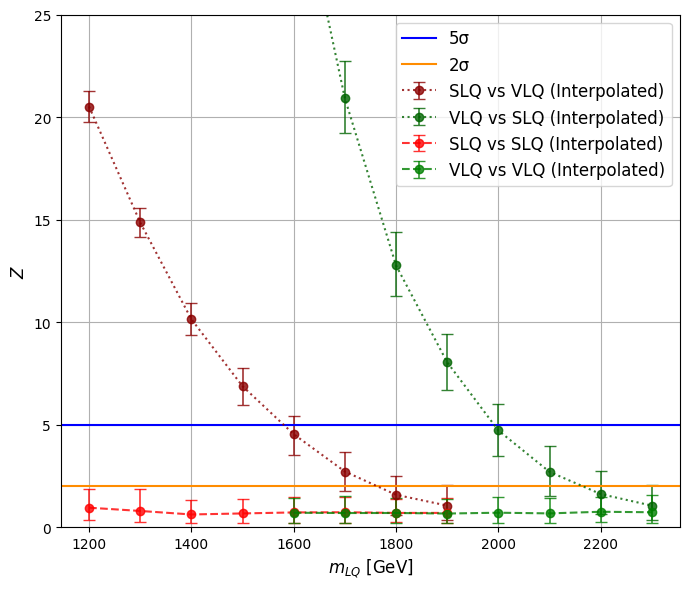

In [84]:


# Compute
z_inter_SLQ, err_inter_SLQ = Z_processor(Z_SLQ_inter, select=1)
z_inter_VLQ, err_inter_VLQ = Z_processor(Z_VLQ_inter, select=0)

z_inter_SLQ_C, err_inter_SLQ_C = Z_processor(Z_SLQ_inter, select=0)
z_inter_VLQ_C, err_inter_VLQ_C = Z_processor(Z_VLQ_inter, select=1)


# Interpolate to find Z=5
def find_mass(mass_array, z_med, err_list, z_target=5.0):
    """Interpolate the mass and find the error, 1-sigma"""
    if np.max(z_med) < z_target and np.min(z_med) < z_target:
        return None, None, None # Z is not in this range

    # mass grid
    grid_masas = np.linspace(mass_array.min(), mass_array.max(), 1000)

    # curves
    z_sup_valores = z_med + err_list[1] # Median + err_sup (percentil 84)
    z_inf_valores = z_med - err_list[0] # Median - err_inf (percentil 16)

    f_med = interp1d(mass_array, z_med, kind='linear', bounds_error=False, fill_value="extrapolate")
    f_sup = interp1d(mass_array, z_sup_valores, kind='linear', bounds_error=False, fill_value="extrapolate")
    f_inf = interp1d(mass_array, z_inf_valores, kind='linear', bounds_error=False, fill_value="extrapolate")

    # search for Z = z_target
    m5_central = grid_masas[np.argmin(np.abs(f_med(grid_masas) - z_target))]
    m5_inf     = grid_masas[np.argmin(np.abs(f_inf(grid_masas) - z_target))]
    m5_sup     = grid_masas[np.argmin(np.abs(f_sup(grid_masas) - z_target))]

    return m5_central, m5_inf, m5_sup

# Compute
m5_inter_SLQ, m5_inter_SLQ_inf, m5_inter_SLQ_sup = find_mass(np.array(m_SLQ), z_inter_SLQ, err_inter_SLQ)
m5_inter_VLQ, m5_inter_VLQ_inf, m5_inter_VLQ_sup = find_mass(np.array(m_VLQ), z_inter_VLQ, err_inter_VLQ)

m2_inter_SLQ, m2_inter_SLQ_inf, m2_inter_SLQ_sup = find_mass(np.array(m_SLQ), z_inter_SLQ, err_inter_SLQ, z_target=2.0)
m2_inter_VLQ, m2_inter_VLQ_inf, m2_inter_VLQ_sup = find_mass(np.array(m_VLQ), z_inter_VLQ, err_inter_VLQ, z_target=2.0)

m5_inter_SLQ_C, m5_inter_SLQ_C_inf, m5_inter_SLQ_C_sup = find_mass(np.array(m_SLQ), z_inter_SLQ_C, err_inter_SLQ_C)
m5_inter_VLQ_C, m5_inter_VLQ_C_inf, m5_inter_VLQ_C_sup = find_mass(np.array(m_VLQ), z_inter_VLQ_C, err_inter_VLQ_C)

m2_inter_SLQ_C, m2_inter_SLQ_C_inf, m2_inter_SLQ_C_sup = find_mass(np.array(m_SLQ), z_inter_SLQ_C, err_inter_SLQ_C, z_target=2.0)
m2_inter_VLQ_C, m2_inter_VLQ_C_inf, m2_inter_VLQ_C_sup = find_mass(np.array(m_VLQ), z_inter_VLQ_C, err_inter_VLQ_C, z_target=2.0)

# Print
print('5 sigmas:')
print('Interpolated (vs the other model)')
print('SLQ mass: ', m5_inter_SLQ, '[GeV]      (', m5_inter_SLQ_inf, '-', m5_inter_SLQ_sup, ')')
print('VLQ mass: ', m5_inter_VLQ, '[GeV]      (', m5_inter_VLQ_inf, '-', m5_inter_VLQ_sup, ')')
print('(\n vs the same model)')
print('SLQ mass: ', m5_inter_SLQ_C, '[GeV]      (', m5_inter_SLQ_C_inf, '-', m5_inter_SLQ_C_sup, ')')
print('VLQ mass: ', m5_inter_VLQ_C, '[GeV]      (', m5_inter_VLQ_C_inf, '-', m5_inter_VLQ_C_sup, ')')

print('\n2 sigmas:')
print('Interpolated (vs the other model)')
print('SLQ mass: ', m2_inter_SLQ, '[GeV]      (', m2_inter_SLQ_inf, '-', m2_inter_SLQ_sup, ')')
print('VLQ mass: ', m2_inter_VLQ, '[GeV]      (', m2_inter_VLQ_inf, '-', m2_inter_VLQ_sup, ')')
print('(\n vs the same model)')
print('SLQ mass: ', m2_inter_SLQ_C, '[GeV]      (', m2_inter_SLQ_C_inf, '-', m2_inter_SLQ_C_sup, ')')
print('VLQ mass: ', m2_inter_VLQ_C, '[GeV]      (', m2_inter_VLQ_C_inf, '-', m2_inter_VLQ_C_sup, ')')

# PLOT
plt.figure(figsize=(7, 6))

plt.errorbar(m_SLQ, z_inter_SLQ, yerr=err_inter_SLQ, color='darkred', linestyle=':', marker='o', capsize=4, elinewidth=1.2, alpha=0.8, label='SLQ vs VLQ (Interpolated)')
plt.errorbar(m_VLQ, z_inter_VLQ, yerr=err_inter_VLQ, color='darkgreen', linestyle=':', marker='o', capsize=4, elinewidth=1.2, alpha=0.8, label='VLQ vs SLQ (Interpolated)')
plt.errorbar(m_SLQ, z_inter_SLQ_C, yerr=err_inter_SLQ_C, color='red', linestyle='--', marker='o', capsize=4, elinewidth=1.2, alpha=0.8, label='SLQ vs SLQ (Interpolated)')
plt.errorbar(m_VLQ, z_inter_VLQ_C, yerr=err_inter_VLQ_C, color='green', linestyle='--', marker='o', capsize=4, elinewidth=1.2, alpha=0.8, label='VLQ vs VLQ (Interpolated)')
plt.axhline(y=5.0, color='blue', linestyle='-', linewidth=1.5, label='5σ')
plt.axhline(y=2.0, color='darkorange', linestyle='-', linewidth=1.5, label='2σ')

plt.ylim(0, 25)
plt.xlabel(r"$m_{LQ}$ [GeV]", fontsize=12)
plt.ylabel(r"$Z$", fontsize=12)
plt.grid(True)
plt.legend(fontsize=12, loc='upper right')
plt.tight_layout()
plt.show()


In [ ]:
print(m_SLQ)
print(m_VLQ)

print(z_inter_SLQ)
print(err_inter_SLQ)

print(z_inter_VLQ)
print(err_inter_VLQ)

print(z_inter_SLQ_C)
print(err_inter_SLQ_C)

print(z_inter_VLQ_C)
print(err_inter_VLQ_C)

[1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900]
[1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]
[21.13337392 14.62577751  9.81459811  6.88776073  4.41273533  2.62831859
  1.57810527  1.03757619]
[array([0.6771324 , 0.76308046, 0.80539288, 0.87694767, 0.97889885,
       1.02727573, 0.95401546, 0.71474986]), array([0.67508038, 0.84195016, 0.71116522, 0.88162236, 0.99324342,
       0.97473667, 1.07771359, 0.87463817])]
[31.49582791 21.06688875 13.07203142  8.1909616   4.90997736  2.78065159
  1.65010846  1.07891438]
[array([1.61724856, 1.70886457, 1.47505598, 1.47194611, 1.32716112,
       1.25926136, 0.99404995, 0.75139421]), array([1.8695309 , 1.85940132, 1.85383966, 1.37213117, 1.3083961 ,
       1.1792723 , 1.13507421, 0.95776095])]
[1.25315119 0.79187558 0.69398988 0.72522494 0.6501247  0.73822618
 0.69590075 0.64950718]
[array([0.85119318, 0.5540947 , 0.47459249, 0.50853396, 0.44323119,
       0.50658956, 0.48646288, 0.46769137]), array([1.09500996, 0.79858624, 0.74492849, 0.78204

In [86]:
m_SLQ = [1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900]
m_VLQ = [1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]

z_inter_SLQ = [20.08822633, 14.04090489, 10.1530296,   6.74555182,  4.38018123,  2.72702032,
  1.69342817,  1.00947241]
err_inter_SLQ = [np.array([0.65422228, 0.62618151, 0.80562596, 0.83417056, 1.03150921,
       1.06297245, 1.05031346, 0.69810253]), np.array([0.66684834, 0.68321716, 0.77542908, 0.83168089, 0.95032791,
       0.88810442, 1.01748783, 1.03142677])]

z_inter_VLQ = [31.97778839, 20.43630334, 12.85036732,  8.18632716,  4.95012402,  2.81968669,
  1.62668594,  1.10724024]
err_inter_VLQ = [np.array([1.80517991, 1.70560031, 1.52269903, 1.43096659, 1.27623228,
       1.13199473, 0.95217876, 0.70794716]), np.array([2.132213  , 1.85899443, 1.6527426 , 1.36977485, 1.3734371 ,
       1.2878017 , 1.05853568, 1.03755145])]

z_inter_SLQ_C = [1.46410284, 0.70085618, 0.63456271, 0.68044448, 0.68673702, 0.71445691,
 0.65513992, 0.7275518 ]
err_inter_SLQ_C = [np.array([1.05044936, 0.52101321, 0.43652903, 0.48700116, 0.48865918,
       0.51106036, 0.46349437, 0.50642486]), np.array([1.25425287, 0.79667561, 0.7397702 , 0.7755345 , 0.78393649,
       0.76664176, 0.77086435, 0.84440457])]

z_inter_VLQ_C = [0.73326526, 0.66249629, 0.67126077, 0.64036041, 0.69836105, 0.68710339,
 0.7483759,  0.72304808]
err_inter_VLQ_C = [np.array([0.52383452, 0.44928728, 0.46398441, 0.44612576, 0.51248949,
       0.47887061, 0.52451375, 0.48855642]), np.array([0.87041586, 0.77633672, 0.73790804, 0.72327211, 0.73936294,
       0.76287457, 0.75785665, 0.75870208])]

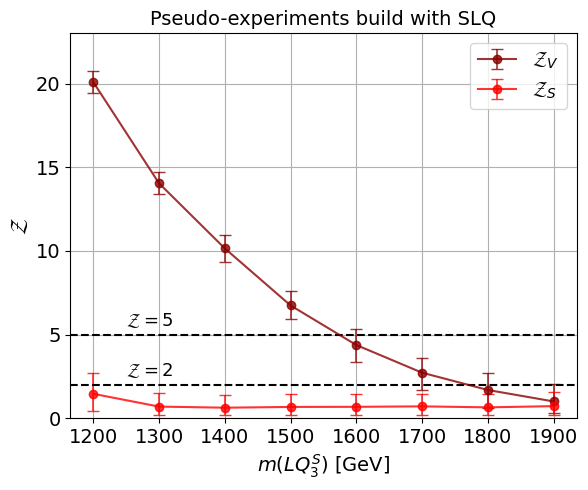

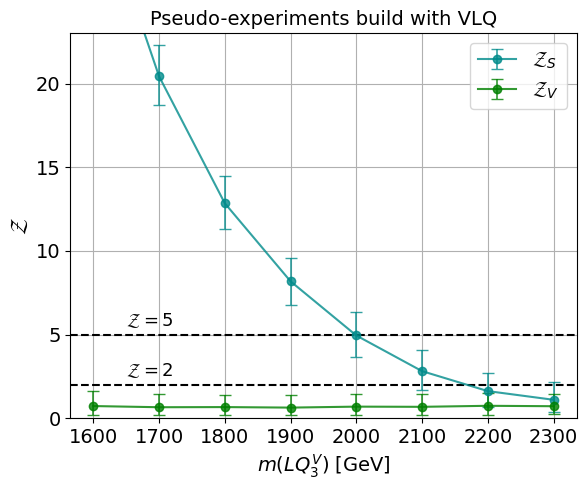

In [87]:
# PLOT
plt.figure(figsize=(6,5))

plt.errorbar(m_SLQ, z_inter_SLQ, yerr=err_inter_SLQ, color='darkred', linestyle='-', marker='o', capsize=4, elinewidth=1.2, alpha=0.8, label=r'$\mathcal{Z}_V$')
# plt.errorbar(m_VLQ, z_inter_VLQ, yerr=err_inter_VLQ, color='darkcyan', linestyle='-', marker='o', capsize=4, elinewidth=1.2, alpha=0.8, label=r'$\mathcal{Z}_S$')
plt.errorbar(m_SLQ, z_inter_SLQ_C, yerr=err_inter_SLQ_C, color='red', linestyle='-', marker='o', capsize=4, elinewidth=1.2, alpha=0.8, label=r'$\mathcal{Z}_S$')
# plt.errorbar(m_VLQ, z_inter_VLQ_C, yerr=err_inter_VLQ_C, color='green', linestyle='-', marker='o', capsize=4, elinewidth=1.2, alpha=0.8, label=r'$\mathcal{Z}_V$')
plt.axhline(y=5.0, color='black', linestyle='--', linewidth=1.5)
plt.axhline(y=2.0, color='black', linestyle='--', linewidth=1.5)
plt.text(1250, 5.5, r'$\mathcal{Z}=5$', fontsize=13)
plt.text(1250, 2.5, r'$\mathcal{Z}=2$', fontsize=13)

plt.ylim(0, 23)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m(LQ_3^S)$ [GeV]", fontsize=14)
plt.ylabel(r"$\mathcal{Z}$", fontsize=16)
plt.title(r"Pseudo-experiments build with SLQ", fontsize=14)
plt.grid(True)
plt.legend(fontsize=14, loc='upper right')
plt.tight_layout()
plt.savefig(mainfolder + 'saved-results/signif_SLQ.pdf', bbox_inches='tight')
plt.show()


# PLOT
plt.figure(figsize=(6,5))

# plt.errorbar(m_SLQ, z_inter_SLQ, yerr=err_inter_SLQ, color='darkred', linestyle='-', marker='o', capsize=4, elinewidth=1.2, alpha=0.8, label=r'$\mathcal{Z}_V$')
plt.errorbar(m_VLQ, z_inter_VLQ, yerr=err_inter_VLQ, color='darkcyan', linestyle='-', marker='o', capsize=4, elinewidth=1.2, alpha=0.8, label=r'$\mathcal{Z}_S$')
# plt.errorbar(m_SLQ, z_inter_SLQ_C, yerr=err_inter_SLQ_C, color='red', linestyle='-', marker='o', capsize=4, elinewidth=1.2, alpha=0.8, label=r'$\mathcal{Z}_S$')
plt.errorbar(m_VLQ, z_inter_VLQ_C, yerr=err_inter_VLQ_C, color='green', linestyle='-', marker='o', capsize=4, elinewidth=1.2, alpha=0.8, label=r'$\mathcal{Z}_V$')
plt.axhline(y=5.0, color='black', linestyle='--', linewidth=1.5)
plt.axhline(y=2.0, color='black', linestyle='--', linewidth=1.5)
plt.text(1650, 5.5, r'$\mathcal{Z}=5$', fontsize=13)
plt.text(1650, 2.5, r'$\mathcal{Z}=2$', fontsize=13)

plt.ylim(0, 23)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m(LQ_3^V)$ [GeV]", fontsize=14)
plt.ylabel(r"$\mathcal{Z}$", fontsize=16)
plt.title(r"Pseudo-experiments build with VLQ", fontsize=14)
plt.grid(True)
plt.legend(fontsize=14, loc='upper right')
plt.tight_layout()
plt.savefig(mainfolder + 'saved-results/signif_VLQ.pdf', bbox_inches='tight')
plt.show()

5 sigmas:
Benchmarks
SLQ mass:  None [GeV]      ( None - None )
VLQ mass:  None [GeV]      ( None - None )

Benchmarks (following S)
SLQ mass:  None [GeV]      ( None - None )
VLQ mass:  None [GeV]      ( None - None )

Interpolated
SLQ mass:  None [GeV]      ( None - None )
VLQ mass:  None [GeV]      ( None - None )

Known PDF
SLQ mass:  None [GeV]      ( None - None )
VLQ mass:  None [GeV]      ( None - None )

Interpolated just once
SLQ mass:  None [GeV]      ( None - None )
VLQ mass:  None [GeV]      ( None - None )

Lots of interpolated benchmarks
SLQ mass:  None [GeV]      ( None - None )
VLQ mass:  None [GeV]      ( None - None )


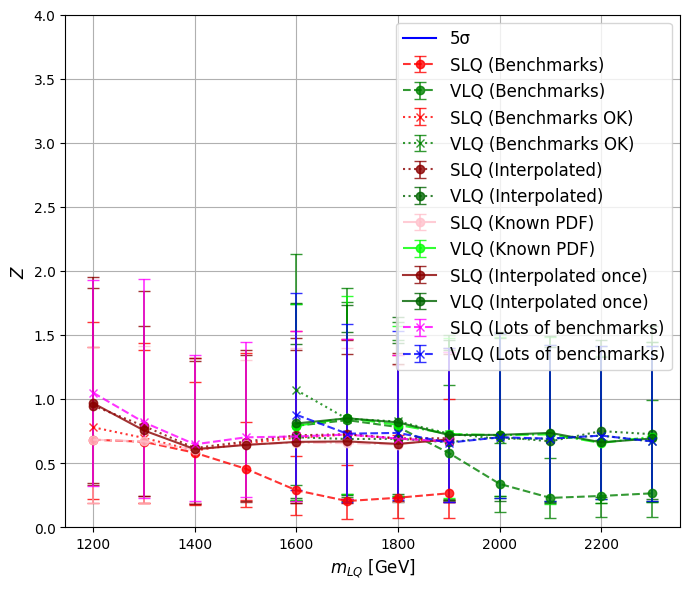

In [88]:

def Z_processor(lista_Z, select):
    """computes the median and error (percentiles 16 y 84)
    select = 1 ---> SLQ (true) vs VLQ
    select = 0 ---> VLQ (true) vs SLQ
    """
    medians = []
    err_inf = []
    err_sup = []

    for z_matriz in lista_Z:
        z_valores = z_matriz[:, select]
        med = np.median(z_valores)
        p16 = np.percentile(z_valores, 16)
        p84 = np.percentile(z_valores, 84)

        medians.append(med)
        err_inf.append(med - p16)  # percentile
        err_sup.append(p84 - med)  # percentile

    return np.array(medians), [np.array(err_inf), np.array(err_sup)]

# Compute
z_BP_SLQ,  err_BP_SLQ  = Z_processor(Z_SLQ, select=0)
z_BP_VLQ,  err_BP_VLQ  = Z_processor(Z_VLQ, select=1)
z_inter_SLQ, err_inter_SLQ = Z_processor(Z_SLQ_inter, select=0)
z_inter_VLQ, err_inter_VLQ = Z_processor(Z_VLQ_inter, select=1)
z_prev_SLQ, err_prev_SLQ = Z_processor(Z_SLQ_prev, select=0)
z_prev_VLQ, err_prev_VLQ = Z_processor(Z_VLQ_prev, select=1)
z_inter1_SLQ, err_inter1_SLQ = Z_processor(Z_SLQ_inter1, select=0)
z_inter1_VLQ, err_inter1_VLQ = Z_processor(Z_VLQ_inter1, select=1)
z_interB_SLQ, err_interB_SLQ = Z_processor(Z_SLQ_interB, select=0)
z_interB_VLQ, err_interB_VLQ = Z_processor(Z_VLQ_interB, select=1)
z_BPOK_SLQ, err_BPOK_SLQ = Z_processor(Z_SLQ_BPOK, select=0)
z_BPOK_VLQ, err_BPOK_VLQ = Z_processor(Z_VLQ_BPOK, select=1)


# Interpolate to find Z=5
def find_mass(mass_array, z_med, err_list, z_target=5.0):
    """Interpolate the mass and find the error, 1-sigma"""
    if np.max(z_med) < z_target and np.min(z_med) < z_target:
        return None, None, None # Z is not in this range

    # mass grid
    grid_masas = np.linspace(mass_array.min(), mass_array.max(), 1000)

    # curves
    z_sup_valores = z_med + err_list[1] # Median + err_sup (percentil 84)
    z_inf_valores = z_med - err_list[0] # Median - err_inf (percentil 16)

    f_med = interp1d(mass_array, z_med, kind='linear', bounds_error=False, fill_value="extrapolate")
    f_sup = interp1d(mass_array, z_sup_valores, kind='linear', bounds_error=False, fill_value="extrapolate")
    f_inf = interp1d(mass_array, z_inf_valores, kind='linear', bounds_error=False, fill_value="extrapolate")

    # search for Z = z_target
    m5_central = grid_masas[np.argmin(np.abs(f_med(grid_masas) - z_target))]
    m5_inf     = grid_masas[np.argmin(np.abs(f_inf(grid_masas) - z_target))]
    m5_sup     = grid_masas[np.argmin(np.abs(f_sup(grid_masas) - z_target))]

    return m5_central, m5_inf, m5_sup

# Compute
m5_BP_SLQ, m5_BP_SLQ_inf, m5_BP_SLQ_sup = find_mass(np.array(m_SLQ), z_BP_SLQ, err_BP_SLQ)
m5_BP_VLQ, m5_BP_VLQ_inf, m5_BP_VLQ_sup = find_mass(np.array(m_VLQ), z_BP_VLQ, err_BP_VLQ)
m5_inter_SLQ, m5_inter_SLQ_inf, m5_inter_SLQ_sup = find_mass(np.array(m_SLQ), z_inter_SLQ, err_inter_SLQ)
m5_inter_VLQ, m5_inter_VLQ_inf, m5_inter_VLQ_sup = find_mass(np.array(m_VLQ), z_inter_VLQ, err_inter_VLQ)
m5_prev_SLQ, m5_prev_SLQ_inf, m5_prev_SLQ_sup = find_mass(np.array(m_SLQ), z_prev_SLQ, err_prev_SLQ)
m5_prev_VLQ, m5_prev_VLQ_inf, m5_prev_VLQ_sup = find_mass(np.array(m_VLQ), z_prev_VLQ, err_prev_VLQ)
m5_inter1_SLQ, m5_inter1_SLQ_inf, m5_inter1_SLQ_sup = find_mass(np.array(m_SLQ), z_inter1_SLQ, err_inter1_SLQ)
m5_inter1_VLQ, m5_inter1_VLQ_inf, m5_inter1_VLQ_sup = find_mass(np.array(m_VLQ), z_inter1_VLQ, err_inter1_VLQ)
m5_interB_SLQ, m5_interB_SLQ_inf, m5_interB_SLQ_sup = find_mass(np.array(m_SLQ), z_interB_SLQ, err_interB_SLQ)
m5_interB_VLQ, m5_interB_VLQ_inf, m5_interB_VLQ_sup = find_mass(np.array(m_VLQ), z_interB_VLQ, err_interB_VLQ)
m5_BPOK_SLQ, m5_BPOK_SLQ_inf, m5_BPOK_SLQ_sup = find_mass(np.array(m_SLQ), z_BPOK_SLQ, err_BPOK_SLQ)
m5_BPOK_VLQ, m5_BPOK_VLQ_inf, m5_BPOK_VLQ_sup = find_mass(np.array(m_VLQ), z_BPOK_VLQ, err_BPOK_VLQ)

# Print
print('5 sigmas:')
print('Benchmarks')
print('SLQ mass: ', m5_BP_SLQ, '[GeV]      (', m5_BP_SLQ_inf, '-', m5_BP_SLQ_sup, ')')
print('VLQ mass: ', m5_BP_VLQ, '[GeV]      (', m5_BP_VLQ_inf, '-', m5_BP_VLQ_sup, ')')
print('\nBenchmarks (following S)')
print('SLQ mass: ', m5_BPOK_SLQ, '[GeV]      (', m5_BPOK_SLQ_inf, '-', m5_BPOK_SLQ_sup, ')')
print('VLQ mass: ', m5_BPOK_VLQ, '[GeV]      (', m5_BPOK_VLQ_inf, '-', m5_BPOK_VLQ_sup, ')')
print('\nInterpolated')
print('SLQ mass: ', m5_inter_SLQ, '[GeV]      (', m5_inter_SLQ_inf, '-', m5_inter_SLQ_sup, ')')
print('VLQ mass: ', m5_inter_VLQ, '[GeV]      (', m5_inter_VLQ_inf, '-', m5_inter_VLQ_sup, ')')
print('\nKnown PDF')
print('SLQ mass: ', m5_prev_SLQ, '[GeV]      (', m5_prev_SLQ_inf, '-', m5_prev_SLQ_sup, ')')
print('VLQ mass: ', m5_prev_VLQ, '[GeV]      (', m5_prev_VLQ_inf, '-', m5_prev_VLQ_sup, ')')
print('\nInterpolated just once')
print('SLQ mass: ', m5_inter1_SLQ, '[GeV]      (', m5_inter1_SLQ_inf, '-', m5_inter1_SLQ_sup, ')')
print('VLQ mass: ', m5_inter1_VLQ, '[GeV]      (', m5_inter1_VLQ_inf, '-', m5_inter1_VLQ_sup, ')')
print('\nLots of interpolated benchmarks')
print('SLQ mass: ', m5_interB_SLQ, '[GeV]      (', m5_interB_SLQ_inf, '-', m5_interB_SLQ_sup, ')')
print('VLQ mass: ', m5_interB_VLQ, '[GeV]      (', m5_interB_VLQ_inf, '-', m5_interB_VLQ_sup, ')')


# PLOT
plt.figure(figsize=(7, 6))

plt.errorbar(m_SLQ, z_BP_SLQ, yerr=err_BP_SLQ,  color='red', linestyle='--', marker='o', capsize=4, elinewidth=1.2, alpha=0.8, label='SLQ (Benchmarks)')
plt.errorbar(m_VLQ, z_BP_VLQ, yerr=err_BP_VLQ,  color='green', linestyle='--', marker='o', capsize=4, elinewidth=1.2, alpha=0.8, label='VLQ (Benchmarks)')
plt.errorbar(m_SLQ, z_BPOK_SLQ, yerr=err_BPOK_SLQ, color='red', linestyle=':', marker='x', capsize=4, elinewidth=1.2, alpha=0.8, label='SLQ (Benchmarks OK)')
plt.errorbar(m_VLQ, z_BPOK_VLQ, yerr=err_BPOK_VLQ, color='green', linestyle=':', marker='x', capsize=4, elinewidth=1.2, alpha=0.8, label='VLQ (Benchmarks OK)')
plt.errorbar(m_SLQ, z_inter_SLQ, yerr=err_inter_SLQ, color='darkred', linestyle=':', marker='o', capsize=4, elinewidth=1.2, alpha=0.8, label='SLQ (Interpolated)')
plt.errorbar(m_VLQ, z_inter_VLQ, yerr=err_inter_VLQ, color='darkgreen', linestyle=':', marker='o', capsize=4, elinewidth=1.2, alpha=0.8, label='VLQ (Interpolated)')
plt.errorbar(m_SLQ, z_prev_SLQ, yerr=err_prev_SLQ, color='pink', linestyle='-.', marker='o', capsize=4, elinewidth=1.2, alpha=0.8, label='SLQ (Known PDF)')
plt.errorbar(m_VLQ, z_prev_VLQ, yerr=err_prev_VLQ, color='lime', linestyle='-.', marker='o', capsize=4, elinewidth=1.2, alpha=0.8, label='VLQ (Known PDF)')
plt.errorbar(m_SLQ, z_inter1_SLQ, yerr=err_inter1_SLQ, color='darkred', linestyle='-', marker='o', capsize=4, elinewidth=1.2, alpha=0.8, label='SLQ (Interpolated once)')
plt.errorbar(m_VLQ, z_inter1_VLQ, yerr=err_inter1_VLQ, color='darkgreen', linestyle='-', marker='o', capsize=4, elinewidth=1.2, alpha=0.8, label='VLQ (Interpolated once)')
plt.errorbar(m_SLQ, z_interB_SLQ, yerr=err_interB_SLQ, color='magenta', linestyle='--', marker='x', capsize=4, elinewidth=1.2, alpha=0.8, label='SLQ (Lots of benchmarks)')
plt.errorbar(m_VLQ, z_interB_VLQ, yerr=err_interB_VLQ, color='blue', linestyle='--', marker='x', capsize=4, elinewidth=1.2, alpha=0.8, label='VLQ (Lots of benchmarks)')

plt.axhline(y=5.0, color='blue', linestyle='-', linewidth=1.5, label='5σ')

plt.ylim(0, 4)
plt.xlabel(r"$m_{LQ}$ [GeV]", fontsize=12)
plt.ylabel(r"$Z$", fontsize=12)
plt.grid(True)
plt.legend(fontsize=12, loc='upper right')
plt.tight_layout()
plt.show()

5 sigmas:
Benchmarks
SLQ mass:  1502.002002002002 [GeV]      ( 1463.4634634634635 - 1560.8608608608608 )
VLQ mass:  1941.9419419419419 [GeV]      ( 1892.8928928928929 - 1989.5895895895897 )

Benchmarks (following S)
SLQ mass:  1577.6776776776776 [GeV]      ( 1539.1391391391392 - 1623.923923923924 )
VLQ mass:  1990.2902902902902 [GeV]      ( 1953.1531531531532 - 2046.3463463463463 )

Interpolated
SLQ mass:  1579.7797797797798 [GeV]      ( 1539.1391391391392 - 1624.6246246246246 )
VLQ mass:  1991.6916916916916 [GeV]      ( 1952.4524524524525 - 2048.4484484484483 )

Known PDF
SLQ mass:  1573.4734734734734 [GeV]      ( 1538.4384384384384 - 1616.9169169169168 )
VLQ mass:  1988.1881881881882 [GeV]      ( 1953.8538538538537 - 2042.1421421421421 )

Interpolated just once
SLQ mass:  1578.3783783783783 [GeV]      ( 1543.3433433433433 - 1621.8218218218217 )
VLQ mass:  1990.990990990991 [GeV]      ( 1955.955955955956 - 2044.2442442442443 )

Lots of interpolated benchmarks
SLQ mass:  1580.480480480

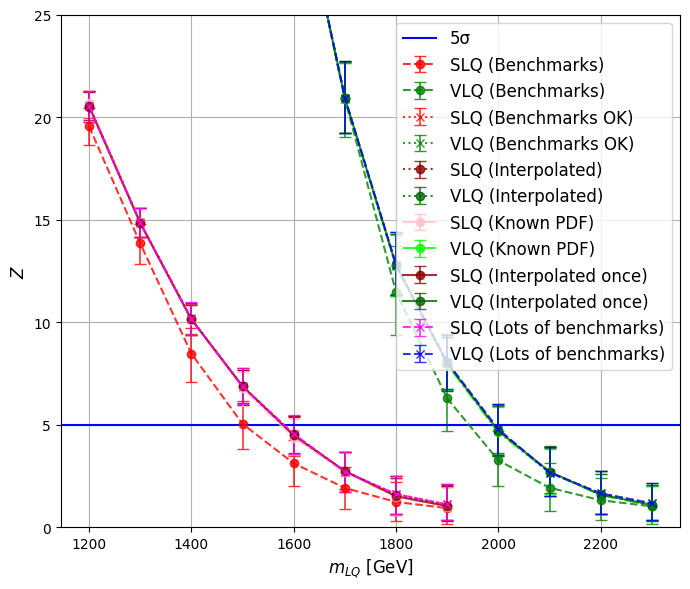

In [89]:

def Z_processor(lista_Z, select):
    """computes the median and error (percentiles 16 y 84)
    select = 1 ---> SLQ (true) vs VLQ
    select = 0 ---> VLQ (true) vs SLQ
    """
    medians = []
    err_inf = []
    err_sup = []

    for z_matriz in lista_Z:
        z_valores = z_matriz[:, select]
        med = np.median(z_valores)
        p16 = np.percentile(z_valores, 16)
        p84 = np.percentile(z_valores, 84)

        medians.append(med)
        err_inf.append(med - p16)  # percentile
        err_sup.append(p84 - med)  # percentile

    return np.array(medians), [np.array(err_inf), np.array(err_sup)]

# Compute
z_BP_SLQ,  err_BP_SLQ  = Z_processor(Z_SLQ, select=1)
z_BP_VLQ,  err_BP_VLQ  = Z_processor(Z_VLQ, select=0)
z_inter_SLQ, err_inter_SLQ = Z_processor(Z_SLQ_inter, select=1)
z_inter_VLQ, err_inter_VLQ = Z_processor(Z_VLQ_inter, select=0)
z_prev_SLQ, err_prev_SLQ = Z_processor(Z_SLQ_prev, select=1)
z_prev_VLQ, err_prev_VLQ = Z_processor(Z_VLQ_prev, select=0)
z_inter1_SLQ, err_inter1_SLQ = Z_processor(Z_SLQ_inter1, select=1)
z_inter1_VLQ, err_inter1_VLQ = Z_processor(Z_VLQ_inter1, select=0)
z_interB_SLQ, err_interB_SLQ = Z_processor(Z_SLQ_interB, select=1)
z_interB_VLQ, err_interB_VLQ = Z_processor(Z_VLQ_interB, select=0)
z_BPOK_SLQ, err_BPOK_SLQ = Z_processor(Z_SLQ_BPOK, select=1)
z_BPOK_VLQ, err_BPOK_VLQ = Z_processor(Z_VLQ_BPOK, select=0)


# Interpolate to find Z=5
def find_mass(mass_array, z_med, err_list, z_target=5.0):
    """Interpolate the mass and find the error, 1-sigma"""
    if np.max(z_med) < z_target and np.min(z_med) < z_target:
        return None, None, None # Z is not in this range

    # mass grid
    grid_masas = np.linspace(mass_array.min(), mass_array.max(), 1000)

    # curves
    z_sup_valores = z_med + err_list[1] # Median + err_sup (percentil 84)
    z_inf_valores = z_med - err_list[0] # Median - err_inf (percentil 16)

    f_med = interp1d(mass_array, z_med, kind='linear', bounds_error=False, fill_value="extrapolate")
    f_sup = interp1d(mass_array, z_sup_valores, kind='linear', bounds_error=False, fill_value="extrapolate")
    f_inf = interp1d(mass_array, z_inf_valores, kind='linear', bounds_error=False, fill_value="extrapolate")

    # search for Z = z_target
    m5_central = grid_masas[np.argmin(np.abs(f_med(grid_masas) - z_target))]
    m5_inf     = grid_masas[np.argmin(np.abs(f_inf(grid_masas) - z_target))]
    m5_sup     = grid_masas[np.argmin(np.abs(f_sup(grid_masas) - z_target))]

    return m5_central, m5_inf, m5_sup

# Compute
m5_BP_SLQ, m5_BP_SLQ_inf, m5_BP_SLQ_sup = find_mass(np.array(m_SLQ), z_BP_SLQ, err_BP_SLQ)
m5_BP_VLQ, m5_BP_VLQ_inf, m5_BP_VLQ_sup = find_mass(np.array(m_VLQ), z_BP_VLQ, err_BP_VLQ)
m5_inter_SLQ, m5_inter_SLQ_inf, m5_inter_SLQ_sup = find_mass(np.array(m_SLQ), z_inter_SLQ, err_inter_SLQ)
m5_inter_VLQ, m5_inter_VLQ_inf, m5_inter_VLQ_sup = find_mass(np.array(m_VLQ), z_inter_VLQ, err_inter_VLQ)
m5_prev_SLQ, m5_prev_SLQ_inf, m5_prev_SLQ_sup = find_mass(np.array(m_SLQ), z_prev_SLQ, err_prev_SLQ)
m5_prev_VLQ, m5_prev_VLQ_inf, m5_prev_VLQ_sup = find_mass(np.array(m_VLQ), z_prev_VLQ, err_prev_VLQ)
m5_inter1_SLQ, m5_inter1_SLQ_inf, m5_inter1_SLQ_sup = find_mass(np.array(m_SLQ), z_inter1_SLQ, err_inter1_SLQ)
m5_inter1_VLQ, m5_inter1_VLQ_inf, m5_inter1_VLQ_sup = find_mass(np.array(m_VLQ), z_inter1_VLQ, err_inter1_VLQ)
m5_interB_SLQ, m5_interB_SLQ_inf, m5_interB_SLQ_sup = find_mass(np.array(m_SLQ), z_interB_SLQ, err_interB_SLQ)
m5_interB_VLQ, m5_interB_VLQ_inf, m5_interB_VLQ_sup = find_mass(np.array(m_VLQ), z_interB_VLQ, err_interB_VLQ)
m5_BPOK_SLQ, m5_BPOK_SLQ_inf, m5_BPOK_SLQ_sup = find_mass(np.array(m_SLQ), z_BPOK_SLQ, err_BPOK_SLQ)
m5_BPOK_VLQ, m5_BPOK_VLQ_inf, m5_BPOK_VLQ_sup = find_mass(np.array(m_VLQ), z_BPOK_VLQ, err_BPOK_VLQ)

# Print
print('5 sigmas:')
print('Benchmarks')
print('SLQ mass: ', m5_BP_SLQ, '[GeV]      (', m5_BP_SLQ_inf, '-', m5_BP_SLQ_sup, ')')
print('VLQ mass: ', m5_BP_VLQ, '[GeV]      (', m5_BP_VLQ_inf, '-', m5_BP_VLQ_sup, ')')
print('\nBenchmarks (following S)')
print('SLQ mass: ', m5_BPOK_SLQ, '[GeV]      (', m5_BPOK_SLQ_inf, '-', m5_BPOK_SLQ_sup, ')')
print('VLQ mass: ', m5_BPOK_VLQ, '[GeV]      (', m5_BPOK_VLQ_inf, '-', m5_BPOK_VLQ_sup, ')')
print('\nInterpolated')
print('SLQ mass: ', m5_inter_SLQ, '[GeV]      (', m5_inter_SLQ_inf, '-', m5_inter_SLQ_sup, ')')
print('VLQ mass: ', m5_inter_VLQ, '[GeV]      (', m5_inter_VLQ_inf, '-', m5_inter_VLQ_sup, ')')
print('\nKnown PDF')
print('SLQ mass: ', m5_prev_SLQ, '[GeV]      (', m5_prev_SLQ_inf, '-', m5_prev_SLQ_sup, ')')
print('VLQ mass: ', m5_prev_VLQ, '[GeV]      (', m5_prev_VLQ_inf, '-', m5_prev_VLQ_sup, ')')
print('\nInterpolated just once')
print('SLQ mass: ', m5_inter1_SLQ, '[GeV]      (', m5_inter1_SLQ_inf, '-', m5_inter1_SLQ_sup, ')')
print('VLQ mass: ', m5_inter1_VLQ, '[GeV]      (', m5_inter1_VLQ_inf, '-', m5_inter1_VLQ_sup, ')')
print('\nLots of interpolated benchmarks')
print('SLQ mass: ', m5_interB_SLQ, '[GeV]      (', m5_interB_SLQ_inf, '-', m5_interB_SLQ_sup, ')')
print('VLQ mass: ', m5_interB_VLQ, '[GeV]      (', m5_interB_VLQ_inf, '-', m5_interB_VLQ_sup, ')')


# PLOT
plt.figure(figsize=(7, 6))

plt.errorbar(m_SLQ, z_BP_SLQ, yerr=err_BP_SLQ,  color='red', linestyle='--', marker='o', capsize=4, elinewidth=1.2, alpha=0.8, label='SLQ (Benchmarks)')
plt.errorbar(m_VLQ, z_BP_VLQ, yerr=err_BP_VLQ,  color='green', linestyle='--', marker='o', capsize=4, elinewidth=1.2, alpha=0.8, label='VLQ (Benchmarks)')
plt.errorbar(m_SLQ, z_BPOK_SLQ, yerr=err_BPOK_SLQ, color='red', linestyle=':', marker='x', capsize=4, elinewidth=1.2, alpha=0.8, label='SLQ (Benchmarks OK)')
plt.errorbar(m_VLQ, z_BPOK_VLQ, yerr=err_BPOK_VLQ, color='green', linestyle=':', marker='x', capsize=4, elinewidth=1.2, alpha=0.8, label='VLQ (Benchmarks OK)')
plt.errorbar(m_SLQ, z_inter_SLQ, yerr=err_inter_SLQ, color='darkred', linestyle=':', marker='o', capsize=4, elinewidth=1.2, alpha=0.8, label='SLQ (Interpolated)')
plt.errorbar(m_VLQ, z_inter_VLQ, yerr=err_inter_VLQ, color='darkgreen', linestyle=':', marker='o', capsize=4, elinewidth=1.2, alpha=0.8, label='VLQ (Interpolated)')
plt.errorbar(m_SLQ, z_prev_SLQ, yerr=err_prev_SLQ, color='pink', linestyle='-.', marker='o', capsize=4, elinewidth=1.2, alpha=0.8, label='SLQ (Known PDF)')
plt.errorbar(m_VLQ, z_prev_VLQ, yerr=err_prev_VLQ, color='lime', linestyle='-.', marker='o', capsize=4, elinewidth=1.2, alpha=0.8, label='VLQ (Known PDF)')
plt.errorbar(m_SLQ, z_inter1_SLQ, yerr=err_inter1_SLQ, color='darkred', linestyle='-', marker='o', capsize=4, elinewidth=1.2, alpha=0.8, label='SLQ (Interpolated once)')
plt.errorbar(m_VLQ, z_inter1_VLQ, yerr=err_inter1_VLQ, color='darkgreen', linestyle='-', marker='o', capsize=4, elinewidth=1.2, alpha=0.8, label='VLQ (Interpolated once)')
plt.errorbar(m_SLQ, z_interB_SLQ, yerr=err_interB_SLQ, color='magenta', linestyle='--', marker='x', capsize=4, elinewidth=1.2, alpha=0.8, label='SLQ (Lots of benchmarks)')
plt.errorbar(m_VLQ, z_interB_VLQ, yerr=err_interB_VLQ, color='blue', linestyle='--', marker='x', capsize=4, elinewidth=1.2, alpha=0.8, label='VLQ (Lots of benchmarks)')

plt.axhline(y=5.0, color='blue', linestyle='-', linewidth=1.5, label='5σ')

plt.ylim(0, 25)
plt.xlabel(r"$m_{LQ}$ [GeV]", fontsize=12)
plt.ylabel(r"$Z$", fontsize=12)
plt.grid(True)
plt.legend(fontsize=12, loc='upper right')
plt.tight_layout()
plt.show()

In [ ]:
class_SLQ_array = np.array(classification_SLQ) # Forma (N, 4)
class_VLQ_array = np.array(classification_VLQ) # Forma (N, 4)

class_SLQ_inter_array = np.array(classification_SLQ_inter) # Forma (N, 4)
class_VLQ_inter_array = np.array(classification_VLQ_inter) # Forma (N, 4)

class_SLQ_inter1_array = np.array(classification_SLQ_inter1) # Forma (N, 4)
class_VLQ_inter1_array = np.array(classification_VLQ_inter1) # Forma (N, 4)

class_SLQ_interB_array = np.array(classification_SLQ_interB) # Forma (N, 4)
class_VLQ_interB_array = np.array(classification_VLQ_interB) # Forma (N, 4)

class_SLQ_BPOK_array = np.array(classification_SLQ_BPOK) # Forma (N, 4)
class_VLQ_BPOK_array = np.array(classification_VLQ_BPOK) # Forma (N, 4)

# SAVE

file_path = mainfolder + 'saved-results/vs14TeV_err_Sfeat.txt'

# Combine all data into a single array
data_to_save = np.column_stack([
    S_expected_SLQ[2:],
    m_SLQ,
    m_VLQ,
    mu_S,
    sigma_S,
    mu_V,
    sigma_V,
    mu_TSLQ,
    std_TSLQ,
    mu_TVLQ,
    std_TVLQ,
    class_SLQ_array,
    class_VLQ_array,
    class_SLQ_inter_array,
    class_VLQ_inter_array,
    z_BP_SLQ,
    err_BP_SLQ[0],
    err_BP_SLQ[1],
    z_BP_VLQ,
    err_BP_VLQ[0],
    err_BP_VLQ[1],
    z_inter_SLQ,
    err_inter_SLQ[0],
    err_inter_SLQ[1],
    z_inter_VLQ,
    err_inter_VLQ[0],
    err_inter_VLQ[1],
    z_prev_SLQ,
    err_prev_SLQ[0],
    err_prev_SLQ[1],
    z_prev_VLQ,
    err_prev_VLQ[0],
    err_prev_VLQ[1],
    z_inter1_SLQ,
    err_inter1_SLQ[0],
    err_inter1_SLQ[1],
    z_inter1_VLQ,
    err_inter1_VLQ[0],
    err_inter1_VLQ[1],
    z_interB_SLQ,
    err_interB_SLQ[0],
    err_interB_SLQ[1],
    z_interB_VLQ,
    err_interB_VLQ[0],
    err_interB_VLQ[1],
    z_BPOK_SLQ,
    err_BPOK_SLQ[0],
    err_BPOK_SLQ[1],
    z_BPOK_VLQ,
    err_BPOK_VLQ[0],
    err_BPOK_VLQ[1],
    # n_pseudo_TRUE,
    # threshold_A
])

# Save data to a text file
np.savetxt(file_path, data_to_save, fmt='%.6f',
           header='# S_expected mass_list_SLQ mass_list_SLQ mu_S sigma_S mu_V sigma_V mu_TSLQ std_TSLQ mu_TVLQ std_TVLQ classification_SLQ classification_VLQ classification_SLQ_inter classification_VLQ_inter',
           comments='')

print(f"Data saved to: {file_path}")

Data saved to: /content/drive/MyDrive/Trabajos/leptoquarks/scalar-vs-vector/03-pythons2026-junio/saved-results/vs14TeV_err_Sfeat.txt


In [ ]:
# LOAD

file_path = mainfolder + 'saved-results/vs14TeV_err_Sfeat.txt'

loaded_data = np.loadtxt(file_path)

S_expected = loaded_data[:, 0]
mass_list_SLQ = loaded_data[:, 1]
mass_list_VLQ = loaded_data[:, 2]
mu_S = loaded_data[:, 3]
sigma_S = loaded_data[:, 4]
mu_V = loaded_data[:, 5]
sigma_V = loaded_data[:, 6]
mu_TSLQ = loaded_data[:, 7]
std_TSLQ = loaded_data[:, 8]
mu_TVLQ = loaded_data[:, 9]
std_TVLQ = loaded_data[:, 10]
classification_SLQ = loaded_data[:, 11:15]
classification_VLQ = loaded_data[:, 15:19]
classification_SLQ_inter = loaded_data[:, 19:23]
classification_VLQ_inter = loaded_data[:, 23:27]
z_BP_SLQ = loaded_data[:, 27]
err_BP_SLQ = np.concatenate([loaded_data[:, 28], loaded_data[:, 29]])
z_BP_VLQ = loaded_data[:, 30]
err_BP_VLQ = np.concatenate([loaded_data[:, 31], loaded_data[:, 32]])
z_inter_SLQ = loaded_data[:, 33]
err_inter_SLQ = np.concatenate([loaded_data[:, 34], loaded_data[:, 35]])
z_inter_VLQ = loaded_data[:, 36]
err_inter_VLQ = np.concatenate([loaded_data[:, 37], loaded_data[:, 38]])
z_prev_SLQ = loaded_data[:, 39]
err_prev_SLQ = np.concatenate([loaded_data[:, 40], loaded_data[:, 41]])
z_prev_VLQ = loaded_data[:, 42]
err_prev_VLQ = np.concatenate([loaded_data[:, 43], loaded_data[:, 44]])
z_inter1_SLQ = loaded_data[:, 45]
err_inter1_SLQ = np.concatenate([loaded_data[:, 46], loaded_data[:, 47]])
z_inter1_VLQ = loaded_data[:, 48]
err_inter1_VLQ = np.concatenate([loaded_data[:, 49], loaded_data[:, 50]])
z_interB_SLQ = loaded_data[:, 51]
err_interB_SLQ = np.concatenate([loaded_data[:, 52], loaded_data[:, 53]])
z_interB_VLQ = loaded_data[:, 54]
err_interB_VLQ = np.concatenate([loaded_data[:, 55], loaded_data[:, 56]])
z_BPOK_SLQ = loaded_data[:, 57]
err_BPOK_SLQ = np.concatenate([loaded_data[:, 58], loaded_data[:, 59]])
z_BPOK_VLQ = loaded_data[:, 60]
err_BPOK_VLQ = np.concatenate([loaded_data[:, 61], loaded_data[:, 62]])




n_pseudo_TRUE = 1000
threshold_A = 0.95

print('n_pseudo_TRUE: ', n_pseudo_TRUE)
print('threshold_A: ', threshold_A)

n_pseudo_TRUE:  1000
threshold_A:  0.95


In [ ]:
# The statistical significance was calculated using the difference in means normalized by
# the combined standard deviation in quadrature,
# weighted/corrected through pseudo-experiments to account for classification bias. It is a Gaussian separation power.

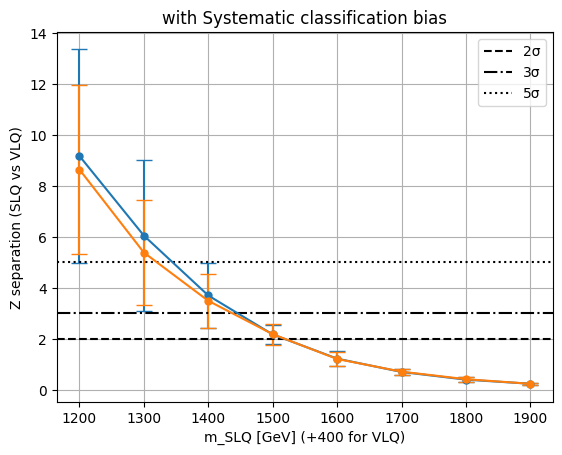

 Z:        5

  with theoretical distributions 
 S:        337.3135265899652   ( 746.7204489883985 - 238.33376626129257 )
 m_SLQ:    1344.8826776978212   ( 1198.5385606847062 - 1399.2671613948942 )  [GeV]
 m_VLQ:    1744.8826776978212   ( 1598.5385606847065 - 1799.2671613948942 )  [GeV]

  with pseudo-exp distributions 
 S:        381.50143402530244   ( 687.3779954239378 - 264.94946538028574 )
 m_SLQ:    1320.6036076784053   ( 1216.9108373300503 - 1384.643150889953 )  [GeV]
 m_VLQ:    1720.6036076784053   ( 1616.9108373300503 - 1784.643150889953 )  [GeV]

 Z:        2

  with theoretical distributions 
 S:        126.68092344020779   ( 169.97717400309733 - 106.25791307401381 )
 m_SLQ:    1518.1036430873548   ( 1467.0228259969026 - 1553.9334858350635 )  [GeV]
 m_VLQ:    1918.1036430873548   ( 1867.0228259969026 - 1953.9334858350635 )  [GeV]

  with pseudo-exp distributions 
 S:        126.29274289632801   ( 171.9768160177339 - 106.57118313953133 )
 m_SLQ:    1518.7846615853894   ( 1465.

In [ ]:

Z_gauss = []
Z_gauss_std = []

for ii_S, S_exp in enumerate(S_expected):

    # 1. Calculo de Z
    num = abs(mu_S[ii_S] - mu_V[ii_S])
    den = np.sqrt(sigma_S[ii_S]**2 + sigma_V[ii_S]**2)

    Z = num / den


    # 2. Errores
    # Numero de pseudo experimentos
    N_S = n_pseudo_TRUE
    N_V = n_pseudo_TRUE

    # Means
    # gaussianas
    delta_mu_S_gauss = sigma_S[ii_S] / np.sqrt(N_S)
    delta_mu_V_gauss = sigma_V[ii_S] / np.sqrt(N_V)
    # pseudo
    delta_mu_S_pseudo = abs(mu_S[ii_S] - mu_TSLQ[ii_S])
    delta_mu_V_pseudo = abs(mu_V[ii_S] - mu_TVLQ[ii_S])


    delta_mu_S = np.sqrt( delta_mu_S_gauss**2 + delta_mu_S_pseudo**2 )
    delta_mu_V = np.sqrt( delta_mu_V_gauss**2 + delta_mu_V_pseudo**2 )

    # delta_mu_S = delta_mu_S_gauss
    # delta_mu_V = delta_mu_V_gauss


    # STD
    # gaussianas
    delta_sigma_S_gauss = sigma_S[ii_S] / np.sqrt(2 * N_S)
    delta_sigma_V_gauss = sigma_V[ii_S] / np.sqrt(2 * N_V)
    # pseudo
    delta_sigma_S_pseudo = np.sqrt( abs(sigma_S[ii_S]**2 - std_TSLQ[ii_S]**2) )
    delta_sigma_V_pseudo = np.sqrt( abs(sigma_V[ii_S]**2 - std_TVLQ[ii_S]**2) )


    delta_sigma_S = np.sqrt( delta_sigma_S_gauss**2 + delta_sigma_S_pseudo**2 )
    delta_sigma_V = np.sqrt( delta_sigma_V_gauss**2 + delta_sigma_V_pseudo**2 )

    # delta_sigma_S = delta_sigma_S_gauss
    # delta_sigma_V = delta_sigma_V_gauss


    # 3. Propagación (raiz de la suma al cuadrado de cada componente)
    # Derivadas parciales de las medias ^2
    term_mu = (delta_mu_S**2 + delta_mu_V**2) / den**2

    # Derivadas parciales de las sigmas ^2
    # La derivada de Z respecto a sigma_S es: -(num * sigma_S) / den^3, entonces al cuadrado
    term_sigma = (num**2 / den**6) * (sigma_S[ii_S]**2 * delta_sigma_S**2 + sigma_V[ii_S]**2 * delta_sigma_V**2)

    delta_Z = np.sqrt(term_mu + term_sigma)

    Z_gauss.append(Z)
    Z_gauss_std.append(delta_Z)




Z_T = []
Z_T_std = []

for ii_S, S_exp in enumerate(S_expected):

    # 1. Calculo de Z
    num = abs(mu_TSLQ[ii_S] - mu_TVLQ[ii_S])
    den = np.sqrt(std_TSLQ[ii_S]**2 + std_TVLQ[ii_S]**2)

    Z =  num / den


    # 2. Errores
    # Numero de pseudo experimentos
    N_S = n_pseudo_TRUE
    N_V = n_pseudo_TRUE

    # Means
    # gaussianas
    delta_mu_S_gauss = sigma_S[ii_S] / np.sqrt(N_S)
    delta_mu_V_gauss = sigma_V[ii_S] / np.sqrt(N_V)
    # pseudo
    delta_mu_S_pseudo = abs(mu_S[ii_S] - mu_TSLQ[ii_S])
    delta_mu_V_pseudo = abs(mu_V[ii_S] - mu_TVLQ[ii_S])


    delta_mu_S = np.sqrt( delta_mu_S_gauss**2 + delta_mu_S_pseudo**2 )
    delta_mu_V = np.sqrt( delta_mu_V_gauss**2 + delta_mu_V_pseudo**2 )

    # delta_mu_S = delta_mu_S_gauss
    # delta_mu_V = delta_mu_V_gauss


    # STD
    # gaussianas
    delta_sigma_S_gauss = sigma_S[ii_S] / np.sqrt(2 * N_S)
    delta_sigma_V_gauss = sigma_V[ii_S] / np.sqrt(2 * N_V)
    # pseudo
    delta_sigma_S_pseudo = np.sqrt( abs(sigma_S[ii_S]**2 - std_TSLQ[ii_S]**2) )
    delta_sigma_V_pseudo = np.sqrt( abs(sigma_V[ii_S]**2 - std_TVLQ[ii_S]**2) )


    delta_sigma_S = np.sqrt( delta_sigma_S_gauss**2 + delta_sigma_S_pseudo**2 )
    delta_sigma_V = np.sqrt( delta_sigma_V_gauss**2 + delta_sigma_V_pseudo**2 )

    # delta_sigma_S = delta_sigma_S_gauss
    # delta_sigma_V = delta_sigma_V_gauss


    # 3. Propagación (raiz de la suma al cuadrado de cada componente)
    # Derivadas parciales de las medias ^2
    term_mu = (delta_mu_S**2 + delta_mu_V**2) / den**2

    # Derivadas parciales de las sigmas ^2
    # La derivada de Z respecto a sigma_S es: -(num * sigma_S) / den^3, entonces al cuadrado
    term_sigma = (num**2 / den**6) * (sigma_S[ii_S]**2 * delta_sigma_S**2 + sigma_V[ii_S]**2 * delta_sigma_V**2)

    delta_Z = np.sqrt(term_mu + term_sigma)

    Z_T.append(Z)
    Z_T_std.append(delta_Z)


# plt.plot(mass_list_SLQ, Z_gauss, marker='o')
plt.errorbar(mass_list_SLQ, Z_gauss, yerr=Z_gauss_std, fmt='o', markersize=5, capsize=6, linestyle='-')
plt.errorbar(mass_list_SLQ, Z_T, yerr=Z_T_std, fmt='o', markersize=5, capsize=6, linestyle='-')
plt.axhline(2, color='black', linestyle='--', label='2σ')
plt.axhline(3, color='black', linestyle='-.', label='3σ')
plt.axhline(5, color='black', linestyle=':', label='5σ')

plt.xlabel("m_SLQ [GeV] (+400 for VLQ)")
plt.ylabel("Z separation (SLQ vs VLQ)")
plt.title("with Systematic classification bias",fontsize=12)
plt.legend()
plt.grid()
plt.show()




Z_gauss_low = [i-j  for i,j in zip(Z_gauss, Z_gauss_std)]
Z_T_low = [i-j  for i,j in zip(Z_T, Z_T_std)]
Z_gauss_high = [i+j  for i,j in zip(Z_gauss, Z_gauss_std)]
Z_T_high = [i+j  for i,j in zip(Z_T, Z_T_std)]

#  interpolate
f_results_Z = interp1d(S_expected, Z_gauss, kind='linear', fill_value="extrapolate")
f_results_Z_mSLQ = interp1d(mass_list_SLQ, Z_gauss, kind='linear', fill_value="extrapolate")
f_results_Z_mVLQ = interp1d(mass_list_VLQ, Z_gauss, kind='linear', fill_value="extrapolate")

f_results_Z_low = interp1d(S_expected, Z_gauss_low, kind='linear', fill_value="extrapolate")
f_results_Z_low_mSLQ = interp1d(mass_list_SLQ, Z_gauss_low, kind='linear', fill_value="extrapolate")
f_results_Z_low_mVLQ = interp1d(mass_list_VLQ, Z_gauss_low, kind='linear', fill_value="extrapolate")

f_results_Z_high = interp1d(S_expected, Z_gauss_high, kind='linear', fill_value="extrapolate")
f_results_Z_high_mSLQ = interp1d(mass_list_SLQ, Z_gauss_high, kind='linear', fill_value="extrapolate")
f_results_Z_high_mVLQ = interp1d(mass_list_VLQ, Z_gauss_high, kind='linear', fill_value="extrapolate")

f_results_Z_T = interp1d(S_expected, Z_T, kind='linear', fill_value="extrapolate")
f_results_Z_T_mSLQ = interp1d(mass_list_SLQ, Z_T, kind='linear', fill_value="extrapolate")
f_results_Z_T_mVLQ = interp1d(mass_list_VLQ, Z_T, kind='linear', fill_value="extrapolate")

f_results_Z_T_low  = interp1d(S_expected, Z_T_low, kind='linear', fill_value="extrapolate")
f_results_Z_T_low_mSLQ = interp1d(mass_list_SLQ, Z_T_low, kind='linear', fill_value="extrapolate")
f_results_Z_T_low_mVLQ = interp1d(mass_list_VLQ, Z_T_low, kind='linear', fill_value="extrapolate")

f_results_Z_T_high  = interp1d(S_expected, Z_T_high, kind='linear', fill_value="extrapolate")
f_results_Z_T_high_mSLQ = interp1d(mass_list_SLQ, Z_T_high, kind='linear', fill_value="extrapolate")
f_results_Z_T_high_mVLQ = interp1d(mass_list_VLQ, Z_T_high, kind='linear', fill_value="extrapolate")



Z_threshold = 5

S_threshold_Z5 = fsolve(lambda x: f_results_Z(x) - Z_threshold,100, xtol=1e-4)[0]
mSLQ_threshold_Z5 = fsolve(lambda x: f_results_Z_mSLQ(x) - Z_threshold,1600, xtol=1e-4)[0]
mVLQ_threshold_Z5 = fsolve(lambda x: f_results_Z_mVLQ(x) - Z_threshold,1600, xtol=1e-4)[0]

S_threshold_low_Z5 = fsolve(lambda x: f_results_Z_low(x) - Z_threshold,100, xtol=1e-4)[0]
mSLQ_threshold_low_Z5 = fsolve(lambda x: f_results_Z_low_mSLQ(x) - Z_threshold,1600, xtol=1e-4)[0]
mVLQ_threshold_low_Z5 = fsolve(lambda x: f_results_Z_low_mVLQ(x) - Z_threshold,1600, xtol=1e-4)[0]

S_threshold_high_Z5 = fsolve(lambda x: f_results_Z_high(x) - Z_threshold,100, xtol=1e-4)[0]
mSLQ_threshold_high_Z5 = fsolve(lambda x: f_results_Z_high_mSLQ(x) - Z_threshold,1600, xtol=1e-4)[0]
mVLQ_threshold_high_Z5 = fsolve(lambda x: f_results_Z_high_mVLQ(x) - Z_threshold,1600, xtol=1e-4)[0]


S_threshold_T_Z5 = fsolve(lambda x: f_results_Z_T(x) - Z_threshold,100, xtol=1e-4)[0]
mSLQ_threshold_T_Z5 = fsolve(lambda x: f_results_Z_T_mSLQ(x) - Z_threshold,1600, xtol=1e-4)[0]
mVLQ_threshold_T_Z5 = fsolve(lambda x: f_results_Z_T_mVLQ(x) - Z_threshold,1600, xtol=1e-4)[0]

S_threshold_T_low_Z5 = fsolve(lambda x: f_results_Z_T_low(x) - Z_threshold,100, xtol=1e-4)[0]
mSLQ_threshold_T_low_Z5 = fsolve(lambda x: f_results_Z_T_low_mSLQ(x) - Z_threshold,1600, xtol=1e-4)[0]
mVLQ_threshold_T_low_Z5 = fsolve(lambda x: f_results_Z_T_low_mVLQ(x) - Z_threshold,1600, xtol=1e-4)[0]

S_threshold_T_high_Z5 = fsolve(lambda x: f_results_Z_T_high(x) - Z_threshold,100, xtol=1e-4)[0]
mSLQ_threshold_T_high_Z5 = fsolve(lambda x: f_results_Z_T_high_mSLQ(x) - Z_threshold,1600, xtol=1e-4)[0]
mVLQ_threshold_T_high_Z5 = fsolve(lambda x: f_results_Z_T_high_mVLQ(x) - Z_threshold,1600, xtol=1e-4)[0]

print(' Z:       ', Z_threshold)

print('\n  with theoretical distributions ')
print(' S:       ', S_threshold_Z5, '  (', S_threshold_low_Z5, '-', S_threshold_high_Z5, ')')
print(' m_SLQ:   ', mSLQ_threshold_Z5, '  (', mSLQ_threshold_low_Z5, '-', mSLQ_threshold_high_Z5, ')', ' [GeV]')
print(' m_VLQ:   ', mVLQ_threshold_Z5, '  (', mVLQ_threshold_low_Z5, '-', mVLQ_threshold_high_Z5, ')', ' [GeV]\n')

print('  with pseudo-exp distributions ')
print(' S:       ', S_threshold_T_Z5, '  (', S_threshold_T_low_Z5, '-', S_threshold_T_high_Z5, ')')
print(' m_SLQ:   ', mSLQ_threshold_T_Z5, '  (', mSLQ_threshold_T_low_Z5, '-', mSLQ_threshold_T_high_Z5, ')', ' [GeV]')
print(' m_VLQ:   ', mVLQ_threshold_T_Z5, '  (', mVLQ_threshold_T_low_Z5, '-', mVLQ_threshold_T_high_Z5, ')', ' [GeV]\n')



Z_threshold = 2

S_threshold_Z2 = fsolve(lambda x: f_results_Z(x) - Z_threshold,100, xtol=1e-4)[0]
mSLQ_threshold_Z2 = fsolve(lambda x: f_results_Z_mSLQ(x) - Z_threshold,1600, xtol=1e-4)[0]
mVLQ_threshold_Z2 = fsolve(lambda x: f_results_Z_mVLQ(x) - Z_threshold,1600, xtol=1e-4)[0]

S_threshold_low_Z2 = fsolve(lambda x: f_results_Z_low(x) - Z_threshold,100, xtol=1e-4)[0]
mSLQ_threshold_low_Z2 = fsolve(lambda x: f_results_Z_low_mSLQ(x) - Z_threshold,1600, xtol=1e-4)[0]
mVLQ_threshold_low_Z2 = fsolve(lambda x: f_results_Z_low_mVLQ(x) - Z_threshold,1600, xtol=1e-4)[0]

S_threshold_high_Z2 = fsolve(lambda x: f_results_Z_high(x) - Z_threshold,100, xtol=1e-4)[0]
mSLQ_threshold_high_Z2 = fsolve(lambda x: f_results_Z_high_mSLQ(x) - Z_threshold,1600, xtol=1e-4)[0]
mVLQ_threshold_high_Z2 = fsolve(lambda x: f_results_Z_high_mVLQ(x) - Z_threshold,1600, xtol=1e-4)[0]


S_threshold_T_Z2 = fsolve(lambda x: f_results_Z_T(x) - Z_threshold,100, xtol=1e-4)[0]
mSLQ_threshold_T_Z2 = fsolve(lambda x: f_results_Z_T_mSLQ(x) - Z_threshold,1600, xtol=1e-4)[0]
mVLQ_threshold_T_Z2 = fsolve(lambda x: f_results_Z_T_mVLQ(x) - Z_threshold,1600, xtol=1e-4)[0]

S_threshold_T_low_Z2 = fsolve(lambda x: f_results_Z_T_low(x) - Z_threshold,100, xtol=1e-4)[0]
mSLQ_threshold_T_low_Z2 = fsolve(lambda x: f_results_Z_T_low_mSLQ(x) - Z_threshold,1600, xtol=1e-4)[0]
mVLQ_threshold_T_low_Z2 = fsolve(lambda x: f_results_Z_T_low_mVLQ(x) - Z_threshold,1600, xtol=1e-4)[0]

S_threshold_T_high_Z2 = fsolve(lambda x: f_results_Z_T_high(x) - Z_threshold,100, xtol=1e-4)[0]
mSLQ_threshold_T_high_Z2 = fsolve(lambda x: f_results_Z_T_high_mSLQ(x) - Z_threshold,1600, xtol=1e-4)[0]
mVLQ_threshold_T_high_Z2 = fsolve(lambda x: f_results_Z_T_high_mVLQ(x) - Z_threshold,1600, xtol=1e-4)[0]

print(' Z:       ', Z_threshold)

print('\n  with theoretical distributions ')
print(' S:       ', S_threshold_Z2, '  (', S_threshold_low_Z2, '-', S_threshold_high_Z2, ')')
print(' m_SLQ:   ', mSLQ_threshold_Z2, '  (', mSLQ_threshold_low_Z2, '-', mSLQ_threshold_high_Z2, ')', ' [GeV]')
print(' m_VLQ:   ', mVLQ_threshold_Z2, '  (', mVLQ_threshold_low_Z2, '-', mVLQ_threshold_high_Z2, ')', ' [GeV]\n')

print('  with pseudo-exp distributions ')
print(' S:       ', S_threshold_T_Z2, '  (', S_threshold_T_low_Z2, '-', S_threshold_T_high_Z2, ')')
print(' m_SLQ:   ', mSLQ_threshold_T_Z2, '  (', mSLQ_threshold_T_low_Z2, '-', mSLQ_threshold_T_high_Z2, ')', ' [GeV]')
print(' m_VLQ:   ', mVLQ_threshold_T_Z2, '  (', mVLQ_threshold_T_low_Z2, '-', mVLQ_threshold_T_high_Z2, ')', ' [GeV]\n')


In [ ]:
m_SLQ = [1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900]
m_VLQ = [1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]

# Interpolate to find Z=5
def find_mass(mass_array, z_med, err_list, z_target=5.0):
    """Interpolate the mass and find the error, 1-sigma"""
    if np.max(z_med) < z_target and np.min(z_med) < z_target:
        return None, None, None # Z is not in this range

    # mass grid
    grid_masas = np.linspace(mass_array.min(), mass_array.max(), 1000)

    # curves
    z_sup_valores = z_med + err_list[1] # Median + err_sup (percentil 84)
    z_inf_valores = z_med - err_list[0] # Median - err_inf (percentil 16)

    f_med = interp1d(mass_array, z_med, kind='linear', bounds_error=False, fill_value="extrapolate")
    f_sup = interp1d(mass_array, z_sup_valores, kind='linear', bounds_error=False, fill_value="extrapolate")
    f_inf = interp1d(mass_array, z_inf_valores, kind='linear', bounds_error=False, fill_value="extrapolate")

    # search for Z = z_target
    m5_central = grid_masas[np.argmin(np.abs(f_med(grid_masas) - z_target))]
    m5_inf     = grid_masas[np.argmin(np.abs(f_inf(grid_masas) - z_target))]
    m5_sup     = grid_masas[np.argmin(np.abs(f_sup(grid_masas) - z_target))]

    return m5_central, m5_inf, m5_sup

# Compute
m5_BP_SLQ, m5_BP_SLQ_inf, m5_BP_SLQ_sup = find_mass(np.array(m_SLQ), z_BP_SLQ, err_BP_SLQ, z_target=5.0)
m5_BP_VLQ, m5_BP_VLQ_inf, m5_BP_VLQ_sup = find_mass(np.array(m_VLQ), z_BP_VLQ, err_BP_VLQ, z_target=5.0)
m5_BPOK_SLQ, m5_BPOK_SLQ_inf, m5_BPOK_SLQ_sup = find_mass(np.array(m_SLQ), z_BPOK_SLQ, err_BPOK_SLQ, z_target=5.0)
m5_BPOK_VLQ, m5_BPOK_VLQ_inf, m5_BPOK_VLQ_sup = find_mass(np.array(m_VLQ), z_BPOK_VLQ, err_BPOK_VLQ, z_target=5.0)
m5_inter_SLQ, m5_inter_SLQ_inf, m5_inter_SLQ_sup = find_mass(np.array(m_SLQ), z_inter_SLQ, err_inter_SLQ, z_target=5.0)
m5_inter_VLQ, m5_inter_VLQ_inf, m5_inter_VLQ_sup = find_mass(np.array(m_VLQ), z_inter_VLQ, err_inter_VLQ, z_target=5.0)
m5_prev_SLQ, m5_prev_SLQ_inf, m5_prev_SLQ_sup = find_mass(np.array(m_SLQ), z_prev_SLQ, err_prev_SLQ, z_target=5.0)
m5_prev_VLQ, m5_prev_VLQ_inf, m5_prev_VLQ_sup = find_mass(np.array(m_VLQ), z_prev_VLQ, err_prev_VLQ, z_target=5.0)
m5_inter1_SLQ, m5_inter1_SLQ_inf, m5_inter1_SLQ_sup = find_mass(np.array(m_SLQ), z_inter1_SLQ, err_inter1_SLQ, z_target=5.0)
m5_inter1_VLQ, m5_inter1_VLQ_inf, m5_inter1_VLQ_sup = find_mass(np.array(m_VLQ), z_inter1_VLQ, err_inter1_VLQ, z_target=5.0)
m5_interB_SLQ, m5_interB_SLQ_inf, m5_interB_SLQ_sup = find_mass(np.array(m_SLQ), z_interB_SLQ, err_interB_SLQ, z_target=5.0)
m5_interB_VLQ, m5_interB_VLQ_inf, m5_interB_VLQ_sup = find_mass(np.array(m_VLQ), z_interB_VLQ, err_interB_VLQ, z_target=5.0)

# Print
print('5 sigmas:')
print('Benchmarks')
print('SLQ mass: ', m5_BP_SLQ, '[GeV]      (', m5_BP_SLQ_inf, '-', m5_BP_SLQ_sup, ')')
print('VLQ mass: ', m5_BP_VLQ, '[GeV]      (', m5_BP_VLQ_inf, '-', m5_BP_VLQ_sup, ')')
print('\nBenchmarks following S')
print('SLQ mass: ', m5_BPOK_SLQ, '[GeV]      (', m5_BPOK_SLQ_inf, '-', m5_BPOK_SLQ_sup, ')')
print('VLQ mass: ', m5_BPOK_VLQ, '[GeV]      (', m5_BPOK_VLQ_inf, '-', m5_BPOK_VLQ_sup, ')')
print('\nInterpolated')
print('SLQ mass: ', m5_inter_SLQ, '[GeV]      (', m5_inter_SLQ_inf, '-', m5_inter_SLQ_sup, ')')
print('VLQ mass: ', m5_inter_VLQ, '[GeV]      (', m5_inter_VLQ_inf, '-', m5_inter_VLQ_sup, ')')
print('\nKnown PDF')
print('SLQ mass: ', m5_prev_SLQ, '[GeV]      (', m5_prev_SLQ_inf, '-', m5_prev_SLQ_sup, ')')
print('VLQ mass: ', m5_prev_VLQ, '[GeV]      (', m5_prev_VLQ_inf, '-', m5_prev_VLQ_sup, ')')
print('\nInterpolated once')
print('SLQ mass: ', m5_inter1_SLQ, '[GeV]      (', m5_inter1_SLQ_inf, '-', m5_inter1_SLQ_sup, ')')
print('VLQ mass: ', m5_inter1_VLQ, '[GeV]      (', m5_inter1_VLQ_inf, '-', m5_inter1_VLQ_sup, ')')
print('\nLots of Benchmarks')
print('SLQ mass: ', m5_interB_SLQ, '[GeV]      (', m5_interB_SLQ_inf, '-', m5_interB_SLQ_sup, ')')
print('VLQ mass: ', m5_interB_VLQ, '[GeV]      (', m5_interB_VLQ_inf, '-', m5_interB_VLQ_sup, ')')



print('\n')


# Compute
m2_BP_SLQ, m2_BP_SLQ_inf, m2_BP_SLQ_sup = find_mass(np.array(m_SLQ), z_BP_SLQ, err_BP_SLQ, z_target=2.0)
m2_BP_VLQ, m2_BP_VLQ_inf, m2_BP_VLQ_sup = find_mass(np.array(m_VLQ), z_BP_VLQ, err_BP_VLQ, z_target=2.0)
m2_BPOK_SLQ, m2_BPOK_SLQ_inf, m2_BPOK_SLQ_sup = find_mass(np.array(m_SLQ), z_BPOK_SLQ, err_BPOK_SLQ, z_target=2.0)
m2_BPOK_VLQ, m2_BPOK_VLQ_inf, m2_BPOK_VLQ_sup = find_mass(np.array(m_VLQ), z_BPOK_VLQ, err_BPOK_VLQ, z_target=2.0)
m2_inter_SLQ, m2_inter_SLQ_inf, m2_inter_SLQ_sup = find_mass(np.array(m_SLQ), z_inter_SLQ, err_inter_SLQ, z_target=2.0)
m2_inter_VLQ, m2_inter_VLQ_inf, m2_inter_VLQ_sup = find_mass(np.array(m_VLQ), z_inter_VLQ, err_inter_VLQ, z_target=2.0)
m2_prev_SLQ, m2_prev_SLQ_inf, m2_prev_SLQ_sup = find_mass(np.array(m_SLQ), z_prev_SLQ, err_prev_SLQ, z_target=2.0)
m2_prev_VLQ, m2_prev_VLQ_inf, m2_prev_VLQ_sup = find_mass(np.array(m_VLQ), z_prev_VLQ, err_prev_VLQ, z_target=2.0)
m2_inter1_SLQ, m2_inter1_SLQ_inf, m2_inter1_SLQ_sup = find_mass(np.array(m_SLQ), z_inter1_SLQ, err_inter1_SLQ, z_target=2.0)
m2_inter1_VLQ, m2_inter1_VLQ_inf, m2_inter1_VLQ_sup = find_mass(np.array(m_VLQ), z_inter1_VLQ, err_inter1_VLQ, z_target=2.0)
m2_interB_SLQ, m2_interB_SLQ_inf, m2_interB_SLQ_sup = find_mass(np.array(m_SLQ), z_interB_SLQ, err_interB_SLQ, z_target=2.0)
m2_interB_VLQ, m2_interB_VLQ_inf, m2_interB_VLQ_sup = find_mass(np.array(m_VLQ), z_interB_VLQ, err_interB_VLQ, z_target=2.0)

# Print
print('2 sigmas:')
print('Benchmarks')
print('SLQ mass: ', m2_BP_SLQ, '[GeV]      (', m2_BP_SLQ_inf, '-', m2_BP_SLQ_sup, ')')
print('VLQ mass: ', m2_BP_VLQ, '[GeV]      (', m2_BP_VLQ_inf, '-', m2_BP_VLQ_sup, ')')
print('\nBenchmarks following S')
print('SLQ mass: ', m2_BPOK_SLQ, '[GeV]      (', m2_BPOK_SLQ_inf, '-', m2_BPOK_SLQ_sup, ')')
print('VLQ mass: ', m2_BPOK_VLQ, '[GeV]      (', m2_BPOK_VLQ_inf, '-', m2_BPOK_VLQ_sup, ')')
print('\nInterpolated')
print('SLQ mass: ', m2_inter_SLQ, '[GeV]      (', m2_inter_SLQ_inf, '-', m2_inter_SLQ_sup, ')')
print('VLQ mass: ', m2_inter_VLQ, '[GeV]      (', m2_inter_VLQ_inf, '-', m2_inter_VLQ_sup, ')')
print('\nKnown PDF')
print('SLQ mass: ', m2_prev_SLQ, '[GeV]      (', m2_prev_SLQ_inf, '-', m2_prev_SLQ_sup, ')')
print('VLQ mass: ', m2_prev_VLQ, '[GeV]      (', m2_prev_VLQ_inf, '-', m2_prev_VLQ_sup, ')')
print('\nInterpolated once')
print('SLQ mass: ', m2_inter1_SLQ, '[GeV]      (', m2_inter1_SLQ_inf, '-', m2_inter1_SLQ_sup, ')')
print('VLQ mass: ', m2_inter1_VLQ, '[GeV]      (', m2_inter1_VLQ_inf, '-', m2_inter1_VLQ_sup, ')')
print('\nLots of Benchmarks')
print('SLQ mass: ', m2_interB_SLQ, '[GeV]      (', m2_interB_SLQ_inf, '-', m2_interB_SLQ_sup, ')')
print('VLQ mass: ', m2_interB_VLQ, '[GeV]      (', m2_interB_VLQ_inf, '-', m2_interB_VLQ_sup, ')')

5 sigmas:
Benchmarks
SLQ mass:  1500.6006006006005 [GeV]      ( 1477.4774774774774 - 1555.955955955956 )
VLQ mass:  1946.8468468468468 [GeV]      ( 1890.7907907907907 - 2009.2092092092091 )

Benchmarks following S
SLQ mass:  1572.772772772773 [GeV]      ( 1545.4454454454453 - 1598.6986986986988 )
VLQ mass:  1997.997997997998 [GeV]      ( 1940.5405405405404 - 2074.3743743743744 )

Interpolated
SLQ mass:  1573.4734734734734 [GeV]      ( 1546.146146146146 - 1600.1001001001 )
VLQ mass:  1998.6986986986988 [GeV]      ( 1942.6426426426426 - 2077.877877877878 )

Known PDF
SLQ mass:  1569.96996996997 [GeV]      ( 1544.044044044044 - 1595.8958958958958 )
VLQ mass:  1997.997997997998 [GeV]      ( 1940.5405405405404 - 2074.3743743743744 )

Interpolated once
SLQ mass:  1574.1741741741741 [GeV]      ( 1546.146146146146 - 1600.8008008008007 )
VLQ mass:  2000.8008008008007 [GeV]      ( 1942.6426426426426 - 2076.4764764764764 )

Lots of Benchmarks
SLQ mass:  1574.8748748748749 [GeV]      ( 1548.948948

In [ ]:
# LOAD

file_path = mainfolder + 'saved-results/Z13TeV_err.txt'

loaded_data = np.loadtxt(file_path)

loaded_betas = loaded_data[:, 0]
m_asimov_exc_SLQ_13TeV = loaded_data[:, 1]
m_asimov_dis_SLQ_13TeV = loaded_data[:, 2]
m_asimov_exc_VLQ_13TeV = loaded_data[:, 3]
m_asimov_dis_VLQ_13TeV = loaded_data[:, 4]
m_BL_exc_SLQ_13TeV = loaded_data[:, 5]
m_BL_dis_SLQ_13TeV = loaded_data[:, 6]
m_BL_exc_VLQ_13TeV = loaded_data[:, 7]
m_BL_dis_VLQ_13TeV = loaded_data[:, 8]
m_BL_exc_SLQ_low_13TeV = loaded_data[:, 9]
m_BL_dis_SLQ_low_13TeV = loaded_data[:, 10]
m_BL_exc_VLQ_low_13TeV = loaded_data[:, 11]
m_BL_dis_VLQ_low_13TeV = loaded_data[:, 12]
m_BL_exc_SLQ_high_13TeV = loaded_data[:, 13]
m_BL_dis_SLQ_high_13TeV = loaded_data[:, 14]
m_BL_exc_VLQ_high_13TeV = loaded_data[:, 15]
m_BL_dis_VLQ_high_13TeV = loaded_data[:, 16]


# LOAD

file_path = mainfolder + 'saved-results/Z136TeV_err.txt'

loaded_data = np.loadtxt(file_path)

loaded_betas = loaded_data[:, 0]
m_asimov_exc_SLQ_136TeV = loaded_data[:, 1]
m_asimov_dis_SLQ_136TeV = loaded_data[:, 2]
m_asimov_exc_VLQ_136TeV = loaded_data[:, 3]
m_asimov_dis_VLQ_136TeV = loaded_data[:, 4]
m_BL_exc_SLQ_136TeV = loaded_data[:, 5]
m_BL_dis_SLQ_136TeV = loaded_data[:, 6]
m_BL_exc_VLQ_136TeV = loaded_data[:, 7]
m_BL_dis_VLQ_136TeV = loaded_data[:, 8]
m_BL_exc_SLQ_low_136TeV = loaded_data[:, 9]
m_BL_dis_SLQ_low_136TeV = loaded_data[:, 10]
m_BL_exc_VLQ_low_136TeV = loaded_data[:, 11]
m_BL_dis_VLQ_low_136TeV = loaded_data[:, 12]
m_BL_exc_SLQ_high_136TeV = loaded_data[:, 13]
m_BL_dis_SLQ_high_136TeV = loaded_data[:, 14]
m_BL_exc_VLQ_high_136TeV = loaded_data[:, 15]
m_BL_dis_VLQ_high_136TeV = loaded_data[:, 16]




# LOAD

file_path = mainfolder + 'saved-results/Z14TeV_err.txt'

loaded_data = np.loadtxt(file_path)

loaded_betas = loaded_data[:, 0]
m_asimov_exc_SLQ_14TeV = loaded_data[:, 1]
m_asimov_dis_SLQ_14TeV = loaded_data[:, 2]
m_asimov_exc_VLQ_14TeV = loaded_data[:, 3]
m_asimov_dis_VLQ_14TeV = loaded_data[:, 4]
m_BL_exc_SLQ_14TeV = loaded_data[:, 5]
m_BL_dis_SLQ_14TeV = loaded_data[:, 6]
m_BL_exc_VLQ_14TeV = loaded_data[:, 7]
m_BL_dis_VLQ_14TeV = loaded_data[:, 8]
m_BL_exc_SLQ_low_14TeV = loaded_data[:, 9]
m_BL_dis_SLQ_low_14TeV = loaded_data[:, 10]
m_BL_exc_VLQ_low_14TeV = loaded_data[:, 11]
m_BL_dis_VLQ_low_14TeV = loaded_data[:, 12]
m_BL_exc_SLQ_high_14TeV = loaded_data[:, 13]
m_BL_dis_SLQ_high_14TeV = loaded_data[:, 14]
m_BL_exc_VLQ_high_14TeV = loaded_data[:, 15]
m_BL_dis_VLQ_high_14TeV = loaded_data[:, 16]

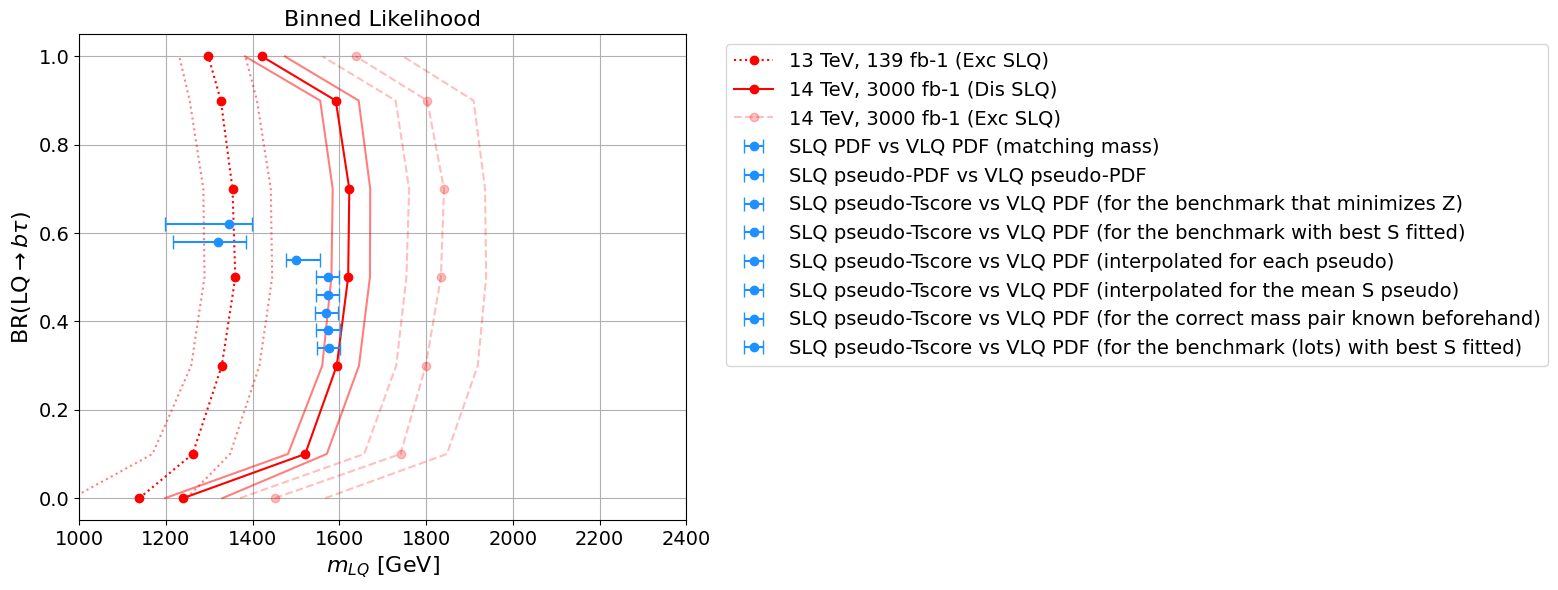

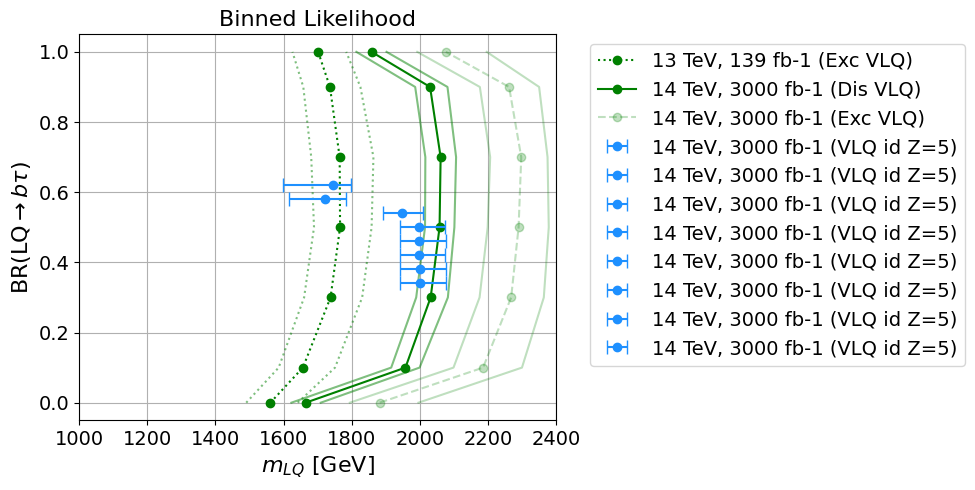

In [ ]:

# plot BINNED LIKEHOOD

plt.figure(figsize=(16, 6))

plt.plot(m_BL_exc_SLQ_13TeV, betas, 'o:', c='red', label='13 TeV, 139 fb-1 (Exc SLQ)')
plt.plot(m_BL_exc_SLQ_low_13TeV, betas, ':', c='red', alpha=0.5)
plt.plot(m_BL_exc_SLQ_high_13TeV, betas, ':', c='red', alpha=0.5)
plt.plot(m_BL_dis_SLQ_14TeV, betas, 'o-', c='red', label='14 TeV, 3000 fb-1 (Dis SLQ)')
plt.plot(m_BL_dis_SLQ_low_14TeV, betas, '-', c='red', alpha=0.5)
plt.plot(m_BL_dis_SLQ_high_14TeV, betas, '-', c='red', alpha=0.5)
plt.plot(m_BL_exc_SLQ_14TeV, betas, 'o--', c='red', alpha=0.25, label='14 TeV, 3000 fb-1 (Exc SLQ)')
plt.plot(m_BL_exc_SLQ_low_14TeV, betas, '--', c='red', alpha=0.25)
plt.plot(m_BL_exc_SLQ_high_14TeV, betas, '--', c='red', alpha=0.25)

# comparing theoretical distributions (pure) against each other
# m_SLQ_Z2 = [[mSLQ_threshold_Z2 - mSLQ_threshold_low_Z2], [mSLQ_threshold_high_Z2 - mSLQ_threshold_Z2]]
# plt.errorbar(mSLQ_threshold_Z2, 0.62, xerr=m_SLQ_Z2, fmt='o', capsize=5, color='blue', label='14 TeV, 3000 fb-1 (SLQ id Z=2)')

m_SLQ_Z5 = [[mSLQ_threshold_Z5 - mSLQ_threshold_low_Z5], [mSLQ_threshold_high_Z5 - mSLQ_threshold_Z5]]
plt.errorbar(mSLQ_threshold_Z5, 0.62, xerr=m_SLQ_Z5, fmt='o', capsize=5, color='dodgerblue', label='SLQ PDF vs VLQ PDF (matching mass)')

# comparing pseudo-distributions against each other
# m_SLQ_T_Z2 = [[mSLQ_threshold_T_Z2 - mSLQ_threshold_T_low_Z2], [mSLQ_threshold_T_high_Z2 - mSLQ_threshold_T_Z2]]
# plt.errorbar(mSLQ_threshold_T_Z2, 0.58, xerr=m_SLQ_T_Z2, fmt='o', capsize=5, color='blue', label='14 TeV, 3000 fb-1 (SLQ id Z=2)')

m_SLQ_T_Z5 = [[mSLQ_threshold_T_Z5 - mSLQ_threshold_T_low_Z5], [mSLQ_threshold_T_high_Z5 - mSLQ_threshold_T_Z5]]
plt.errorbar(mSLQ_threshold_T_Z5, 0.58, xerr=m_SLQ_T_Z5, fmt='o', capsize=5, color='dodgerblue', label='SLQ pseudo-PDF vs VLQ pseudo-PDF')

# benchmarks
# m_SLQ_T_Z2 = [[m2_BP_SLQ - m2_BP_SLQ_inf], [m2_BP_SLQ_sup - m2_BP_SLQ]]
# plt.errorbar(m2_BP_SLQ, 0.54, xerr=m_SLQ_T_Z2, fmt='o', capsize=5, color='blue', label='14 TeV, 3000 fb-1 (SLQ id Z=2)')

m_SLQ_T_Z5 = [[m5_BP_SLQ - m5_BP_SLQ_inf], [m5_BP_SLQ_sup - m5_BP_SLQ]]
plt.errorbar(m5_BP_SLQ, 0.54, xerr=m_SLQ_T_Z5, fmt='o', capsize=5, color='dodgerblue', label='SLQ pseudo-Tscore vs VLQ PDF (for the benchmark that minimizes Z)')

# benchmarks following S
# m_SLQ_T_Z2 = [[m2_BPOK_SLQ - m2_BPOK_SLQ_inf], [m2_BPOK_SLQ_sup - m2_BPOK_SLQ]]
# plt.errorbar(m2_BPOK_SLQ, 0.5, xerr=m_SLQ_T_Z2, fmt='o', capsize=5, color='blue', label='14 TeV, 3000 fb-1 (SLQ id Z=2)')

m_SLQ_T_Z5 = [[m5_BPOK_SLQ - m5_BPOK_SLQ_inf], [m5_BPOK_SLQ_sup - m5_BPOK_SLQ]]
plt.errorbar(m5_BPOK_SLQ, 0.5, xerr=m_SLQ_T_Z5, fmt='o', capsize=5, color='dodgerblue', label='SLQ pseudo-Tscore vs VLQ PDF (for the benchmark with best S fitted)')

# interpolated
# m_SLQ_T_Z2 = [[m2_inter_SLQ - m2_inter_SLQ_inf], [m2_inter_SLQ_sup - m2_inter_SLQ]]
# plt.errorbar(m2_inter_SLQ, 0.46, xerr=m_SLQ_T_Z2, fmt='o', capsize=5, color='blue', label='14 TeV, 3000 fb-1 (SLQ id Z=2)')

m_SLQ_T_Z5 = [[m5_inter_SLQ - m5_inter_SLQ_inf], [m5_inter_SLQ_sup - m5_inter_SLQ]]
plt.errorbar(m5_inter_SLQ, 0.46, xerr=m_SLQ_T_Z5, fmt='o', capsize=5, color='dodgerblue', label='SLQ pseudo-Tscore vs VLQ PDF (interpolated for each pseudo)')

# interpolated once
# m_SLQ_T_Z2 = [[m2_inter1_SLQ - m2_inter1_SLQ_inf], [m2_inter1_SLQ_sup - m2_inter1_SLQ]]
# plt.errorbar(m2_inter1_SLQ, 0.38, xerr=m_SLQ_T_Z2, fmt='o', capsize=5, color='blue', label='14 TeV, 3000 fb-1 (SLQ id Z=2)')

m_SLQ_T_Z5 = [[m5_inter1_SLQ - m5_inter1_SLQ_inf], [m5_inter1_SLQ_sup - m5_inter1_SLQ]]
plt.errorbar(m5_inter1_SLQ, 0.38, xerr=m_SLQ_T_Z5, fmt='o', capsize=5, color='dodgerblue', label='SLQ pseudo-Tscore vs VLQ PDF (interpolated for the mean S pseudo)')

# known pdf
# m_SLQ_T_Z2 = [[m2_prev_SLQ - m2_prev_SLQ_inf], [m2_prev_SLQ_sup - m2_prev_SLQ]]
# plt.errorbar(m2_prev_SLQ, 0.42, xerr=m_SLQ_T_Z2, fmt='o', capsize=5, color='blue', label='14 TeV, 3000 fb-1 (SLQ id Z=2)')

m_SLQ_T_Z5 = [[m5_prev_SLQ - m5_prev_SLQ_inf], [m5_prev_SLQ_sup - m5_prev_SLQ]]
plt.errorbar(m5_prev_SLQ, 0.42, xerr=m_SLQ_T_Z5, fmt='o', capsize=5, color='dodgerblue', label='SLQ pseudo-Tscore vs VLQ PDF (for the correct mass pair known beforehand)')

# Lots of benchmarks
# m_SLQ_T_Z2 = [[m2_interB_SLQ - m2_interB_SLQ_inf], [m2_interB_SLQ_sup - m2_interB_SLQ]]
# plt.errorbar(m2_interB_SLQ, 0.34, xerr=m_SLQ_T_Z2, fmt='o', capsize=5, color='blue', label='14 TeV, 3000 fb-1 (SLQ id Z=2)')

m_SLQ_T_Z5 = [[m5_interB_SLQ - m5_interB_SLQ_inf], [m5_interB_SLQ_sup - m5_interB_SLQ]]
plt.errorbar(m5_interB_SLQ, 0.34, xerr=m_SLQ_T_Z5, fmt='o', capsize=5, color='dodgerblue', label='SLQ pseudo-Tscore vs VLQ PDF (for the benchmark (lots) with best S fitted)')

# plt.axhline(y=5, linestyle='--', color='black')
# plt.axhline(y=2, linestyle=':', color='black')
plt.xlim(1000,2400)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()





plt.figure(figsize=(10, 5))

plt.plot(m_BL_exc_VLQ_13TeV, betas, 'o:', c='green', label='13 TeV, 139 fb-1 (Exc VLQ)')
plt.plot(m_BL_exc_VLQ_low_13TeV, betas, ':', c='green', alpha=0.5)
plt.plot(m_BL_exc_VLQ_high_13TeV, betas, ':', c='green', alpha=0.5)
plt.plot(m_BL_dis_VLQ_14TeV, betas, 'o-', c='green', label='14 TeV, 3000 fb-1 (Dis VLQ)')
plt.plot(m_BL_dis_VLQ_low_14TeV, betas, '-', c='green', alpha=0.5)
plt.plot(m_BL_dis_VLQ_high_14TeV, betas, '-', c='green', alpha=0.5)
plt.plot(m_BL_exc_VLQ_14TeV, betas, 'o--', c='green', alpha=0.25, label='14 TeV, 3000 fb-1 (Exc VLQ)')
plt.plot(m_BL_exc_VLQ_low_14TeV, betas, '-', c='green', alpha=0.25)
plt.plot(m_BL_exc_VLQ_high_14TeV, betas, '-', c='green', alpha=0.25)

# comparing theoretical distributions (pure) against each other
# m_VLQ_Z2 = [[mVLQ_threshold_Z2 - mVLQ_threshold_low_Z2], [mVLQ_threshold_high_Z2 - mVLQ_threshold_Z2]]
# plt.errorbar(mVLQ_threshold_Z2, 0.62, xerr=m_VLQ_Z2, fmt='o', capsize=5, color='blue', label='14 TeV, 3000 fb-1 (VLQ id Z=2)')

m_VLQ_Z5 = [[mVLQ_threshold_Z5 - mVLQ_threshold_low_Z5], [mVLQ_threshold_high_Z5 - mVLQ_threshold_Z5]]
plt.errorbar(mVLQ_threshold_Z5, 0.62, xerr=m_VLQ_Z5, fmt='o', capsize=5, color='dodgerblue', label='14 TeV, 3000 fb-1 (VLQ id Z=5)')

# comparing pseudo-distributions against each other
# m_VLQ_T_Z2 = [[mVLQ_threshold_T_Z2 - mVLQ_threshold_T_low_Z2], [mVLQ_threshold_T_high_Z2 - mVLQ_threshold_T_Z2]]
# plt.errorbar(mVLQ_threshold_T_Z2, 0.58, xerr=m_VLQ_T_Z2, fmt='o', capsize=5, color='blue', label='14 TeV, 3000 fb-1 (VLQ id Z=2)')

m_VLQ_T_Z5 = [[mVLQ_threshold_T_Z5 - mVLQ_threshold_T_low_Z5], [mVLQ_threshold_T_high_Z5 - mVLQ_threshold_T_Z5]]
plt.errorbar(mVLQ_threshold_T_Z5, 0.58, xerr=m_VLQ_T_Z5, fmt='o', capsize=5, color='dodgerblue', label='14 TeV, 3000 fb-1 (VLQ id Z=5)')

# benchmarks
# m_VLQ_T_Z2 = [[m2_BP_VLQ - m2_BP_VLQ_inf], [m2_BP_VLQ_sup - m2_BP_VLQ]]
# plt.errorbar(m2_BP_VLQ, 0.54, xerr=m_VLQ_T_Z2, fmt='o', capsize=5, color='blue', label='14 TeV, 3000 fb-1 (VLQ id Z=2)')

m_VLQ_T_Z5 = [[m5_BP_VLQ - m5_BP_VLQ_inf], [m5_BP_VLQ_sup - m5_BP_VLQ]]
plt.errorbar(m5_BP_VLQ, 0.54, xerr=m_VLQ_T_Z5, fmt='o', capsize=5, color='dodgerblue', label='14 TeV, 3000 fb-1 (VLQ id Z=5)')

# benchmarks following S
# m_VLQ_T_Z2 = [[m2_BPOK_VLQ - m2_BPOK_VLQ_inf], [m2_BPOK_VLQ_sup - m2_BPOK_VLQ]]
# plt.errorbar(m2_BPOK_VLQ, 0.5, xerr=m_VLQ_T_Z2, fmt='o', capsize=5, color='blue', label='14 TeV, 3000 fb-1 (VLQ id Z=2)')

m_VLQ_T_Z5 = [[m5_BPOK_VLQ - m5_BPOK_VLQ_inf], [m5_BPOK_VLQ_sup - m5_BPOK_VLQ]]
plt.errorbar(m5_BPOK_VLQ, 0.5, xerr=m_VLQ_T_Z5, fmt='o', capsize=5, color='dodgerblue', label='14 TeV, 3000 fb-1 (VLQ id Z=5)')

# interpolated
# m_VLQ_T_Z2 = [[m2_inter_VLQ - m2_inter_VLQ_inf], [m2_inter_VLQ_sup - m2_inter_VLQ]]
# plt.errorbar(m2_inter_VLQ, 0.46, xerr=m_VLQ_T_Z2, fmt='o', capsize=5, color='blue', label='14 TeV, 3000 fb-1 (VLQ id Z=2)')

m_VLQ_T_Z5 = [[m5_inter_VLQ - m5_inter_VLQ_inf], [m5_inter_VLQ_sup - m5_inter_VLQ]]
plt.errorbar(m5_inter_VLQ, 0.46, xerr=m_VLQ_T_Z5, fmt='o', capsize=5, color='dodgerblue', label='14 TeV, 3000 fb-1 (VLQ id Z=5)')

# interpolated once
# m_VLQ_T_Z2 = [[m2_inter1_VLQ - m2_inter1_VLQ_inf], [m2_inter1_VLQ_sup - m2_inter1_VLQ]]
# plt.errorbar(m2_inter1_VLQ, 0.38, xerr=m_VLQ_T_Z2, fmt='o', capsize=5, color='blue', label='14 TeV, 3000 fb-1 (VLQ id Z=2)')

m_VLQ_T_Z5 = [[m5_inter1_VLQ - m5_inter1_VLQ_inf], [m5_inter1_VLQ_sup - m5_inter1_VLQ]]
plt.errorbar(m5_inter1_VLQ, 0.38, xerr=m_VLQ_T_Z5, fmt='o', capsize=5, color='dodgerblue', label='14 TeV, 3000 fb-1 (VLQ id Z=5)')

# knwon pdf
# m_VLQ_T_Z2 = [[m2_prev_VLQ - m2_prev_VLQ_inf], [m2_prev_VLQ_sup - m2_prev_VLQ]]
# plt.errorbar(m2_prev_VLQ, 0.42, xerr=m_VLQ_T_Z2, fmt='o', capsize=5, color='blue', label='14 TeV, 3000 fb-1 (VLQ id Z=2)')

m_VLQ_T_Z5 = [[m5_prev_VLQ - m5_prev_VLQ_inf], [m5_prev_VLQ_sup - m5_prev_VLQ]]
plt.errorbar(m5_prev_VLQ, 0.42, xerr=m_VLQ_T_Z5, fmt='o', capsize=5, color='dodgerblue', label='14 TeV, 3000 fb-1 (VLQ id Z=5)')

# Lots of benchmarks
# m_VLQ_T_Z2 = [[m2_interB_VLQ - m2_interB_VLQ_inf], [m2_interB_VLQ_sup - m2_interB_VLQ]]
# plt.errorbar(m2_interB_VLQ, 0.34, xerr=m_VLQ_T_Z2, fmt='o', capsize=5, color='blue', label='14 TeV, 3000 fb-1 (VLQ id Z=2)')

m_VLQ_T_Z5 = [[m5_interB_VLQ - m5_interB_VLQ_inf], [m5_interB_VLQ_sup - m5_interB_VLQ]]
plt.errorbar(m5_interB_VLQ, 0.34, xerr=m_VLQ_T_Z5, fmt='o', capsize=5, color='dodgerblue', label='14 TeV, 3000 fb-1 (VLQ id Z=5)')


# plt.axhline(y=5, linestyle='--', color='black')
# plt.axhline(y=2, linestyle=':', color='black')
plt.xlim(1000,2400)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# OTHER MASSES

#### Load new models

In [ ]:
masses_SLQ_1365 = [1365]


df_SLQ_all_1365 = {}
X_SLQ_all_1365 = {}


output_folder = mainfolder + "../DATA/signal/data_df/"

for mass_sel in masses_SLQ_1365:
    # Read the file
    filename = mainfolder + '../DATA-wjets/signals/dats-SLQ-' + str(mass_sel) + 'GeV/df_SLQ_' + str(mass_sel) + "GeV.csv"

    df_temp = pd.read_csv(filename)

    # get the features
    feats_label = [c for c in df_temp.columns]

    # Save in the dictionary
    df_SLQ_all_1365[mass_sel] = df_temp
    X_SLQ_all_1365[mass_sel] = df_temp[feats_label].values

    # Print
    print(f"X_SLQ_{mass_sel}GeV.shape: {X_SLQ_all_1365[mass_sel].shape}")

X_SLQ_1365GeV.shape: (23327, 53)


In [ ]:
masses_SLQ_1500 = [1500]


df_SLQ_all_1500 = {}
X_SLQ_all_1500 = {}


output_folder = mainfolder + "../DATA/signal/data_df/"

for mass_sel in masses_SLQ_1500:
    # Read the file
    filename = mainfolder + '../DATA-wjets/signals/dats-SLQ-' + str(mass_sel) + 'GeV/df_SLQ_' + str(mass_sel) + "GeV.csv"

    df_temp = pd.read_csv(filename)

    # get the features
    feats_label = [c for c in df_temp.columns]

    # Save in the dictionary
    df_SLQ_all_1500[mass_sel] = df_temp
    X_SLQ_all_1500[mass_sel] = df_temp[feats_label].values

    # Print
    print(f"X_SLQ_{mass_sel}GeV.shape: {X_SLQ_all_1500[mass_sel].shape}")

X_SLQ_1500GeV.shape: (185940, 53)


In [ ]:
masses_VLQ_1850 = [1850]


df_VLQ_all_1850 = {}
X_VLQ_all_1850 = {}


output_folder = mainfolder + "../DATA/signal/data_df/"

for mass_sel in masses_VLQ_1850:
    # Read the file
    filename = mainfolder + '../DATA-wjets/signals/dats-VLQ-' + str(mass_sel) + 'GeV/df_VLQ_' + str(mass_sel) + "GeV.csv"

    df_temp = pd.read_csv(filename)

    # get the features
    feats_label = [c for c in df_temp.columns]

    # Save in the dictionary
    df_VLQ_all_1850[mass_sel] = df_temp
    X_VLQ_all_1850[mass_sel] = df_temp[feats_label].values

    # Print
    print(f"X_VLQ_{mass_sel}GeV.shape: {X_VLQ_all_1850[mass_sel].shape}")

X_VLQ_1850GeV.shape: (20436, 53)


In [ ]:
masses_VLQ_2000 = [2000]


df_VLQ_all_2000 = {}
X_VLQ_all_2000 = {}


output_folder = mainfolder + "../DATA/signal/data_df/"

for mass_sel in masses_VLQ_2000:
    # Read the file
    filename = mainfolder + '../DATA-wjets/signals/dats-VLQ-' + str(mass_sel) + 'GeV/df_VLQ_' + str(mass_sel) + "GeV.csv"

    df_temp = pd.read_csv(filename)

    # get the features
    feats_label = [c for c in df_temp.columns]

    # Save in the dictionary
    df_VLQ_all_2000[mass_sel] = df_temp
    X_VLQ_all_2000[mass_sel] = df_temp[feats_label].values

    # Print
    print(f"X_VLQ_{mass_sel}GeV.shape: {X_VLQ_all_2000[mass_sel].shape}")

X_VLQ_2000GeV.shape: (184097, 53)


In [ ]:
masses_VLQ_YM = [1800, 2000]


df_VLQ_all_YM = {}
X_VLQ_all_YM = {}


output_folder = mainfolder + "../DATA/signal/data_df/"

for mass_sel in masses_VLQ_YM:
    # Read the file
    filename = mainfolder + '../DATA-wjets/signals/dats-VLQ-YM-' + str(mass_sel) + 'GeV/df_VLQ_YM_' + str(mass_sel) + "GeV.csv"

    df_temp = pd.read_csv(filename)

    # get the features
    feats_label = [c for c in df_temp.columns]

    # Save in the dictionary
    df_VLQ_all_YM[mass_sel] = df_temp
    X_VLQ_all_YM[mass_sel] = df_temp[feats_label].values

    # Print
    print(f"X_VLQ_{mass_sel}GeV.shape: {X_VLQ_all_YM[mass_sel].shape}")

X_VLQ_1800GeV.shape: (114329, 53)
X_VLQ_2000GeV.shape: (70280, 53)


In [ ]:
# Apply normalization

df_SLQ_norm_1365 = {mass: pd.DataFrame(scaler.transform(df_SLQ_all_1365[mass]), columns=df_SLQ_all_1365[mass].columns) for mass in df_SLQ_all_1365}
df_SLQ_norm_1500 = {mass: pd.DataFrame(scaler.transform(df_SLQ_all_1500[mass]), columns=df_SLQ_all_1500[mass].columns) for mass in df_SLQ_all_1500}
df_VLQ_norm_1850 = {mass: pd.DataFrame(scaler.transform(df_VLQ_all_1850[mass]), columns=df_VLQ_all_1850[mass].columns) for mass in df_VLQ_all_1850}
df_VLQ_norm_2000 = {mass: pd.DataFrame(scaler.transform(df_VLQ_all_2000[mass]), columns=df_VLQ_all_2000[mass].columns) for mass in df_VLQ_all_2000}
df_VLQ_norm_YM = {mass: pd.DataFrame(scaler.transform(df_VLQ_all_YM[mass]), columns=df_VLQ_all_YM[mass].columns) for mass in df_VLQ_all_YM}

In [ ]:
# --- Clasificador A: SM vs LQ ---

scoresA_SLQ_1365 = {}
scoresA_SLQ_1500 = {}
scoresA_VLQ_1850 = {}
scoresA_VLQ_2000 = {}
scoresA_VLQ_YM = {}

for m in df_SLQ_norm_1365:
    scoresA_SLQ_1365[m] = xgb_clf.predict_proba( df_SLQ_norm_1365[m] )[:,1]

for m in df_SLQ_norm_1500:
    scoresA_SLQ_1500[m] = xgb_clf.predict_proba( df_SLQ_norm_1500[m] )[:,1]

for m in df_VLQ_norm_1850:
    scoresA_VLQ_1850[m] = xgb_clf.predict_proba( df_VLQ_norm_1850[m] )[:,1]

for m in df_VLQ_norm_2000:
    scoresA_VLQ_2000[m] = xgb_clf.predict_proba( df_VLQ_norm_2000[m] )[:,1]

for m in df_VLQ_norm_YM:
    scoresA_VLQ_YM[m] = xgb_clf.predict_proba( df_VLQ_norm_YM[m] )[:,1]

In [ ]:
# --- Clasificador B: SLQ vs VLQ ---

# this is done on site, depends on S fitted

In [ ]:
# -------------------------
# cross sections
# -------------------------
k_LQ = 1.8877462860822058

xsec_file_14TeV = mainfolder + '../DATA-wjets/signals/LQs-xsec-14TeV.txt'

xsec_data_14TeV = np.loadtxt(xsec_file_14TeV, comments='#')

# columns: 0=mass, 1=SLQ, 2=VLQ
masses_14TeV = xsec_data_14TeV[:,0].astype(int)
fidxsec_SLQ_14TeV = dict(zip(masses_14TeV, xsec_data_14TeV[:,1]*k_LQ))
fidxsec_VLQ_14TeV = dict(zip(masses_14TeV, xsec_data_14TeV[:,2]*k_LQ))


masses_SLQ_14TeV = [1000, 1200, 1400, 1600, 1800, 2000, 2200]
masses_VLQ_14TeV = [1200, 1400, 1600, 1800, 2000, 2200]

fidxsec_SLQ_non0_14TeV = [fidxsec_SLQ_14TeV[ii] for ii in masses_SLQ_14TeV]
fidxsec_VLQ_non0_14TeV = [fidxsec_VLQ_14TeV[ii] for ii in masses_VLQ_14TeV]


#  interpolate
f_xsec_SLQ_log_14TeV = interp1d(masses_SLQ_14TeV, np.log10(fidxsec_SLQ_non0_14TeV), kind='linear', fill_value="extrapolate")
f_xsec_VLQ_log_14TeV = interp1d(masses_VLQ_14TeV, np.log10(fidxsec_VLQ_non0_14TeV), kind='linear', fill_value="extrapolate")



# -------------------------
# cross sections
# -------------------------
xsec_file_betas_14TeV = mainfolder + '../DATA-wjets/signals/LQs-xsec-14TeV-betas.txt'

xsec_data_betas_14TeV = np.loadtxt(xsec_file_betas_14TeV, comments='#')

# columns: 0=beta, 1,...=SLQ, -1=ratio=fid_xsec(beta)/fid_xsec(beta=0.5)
betas = xsec_data_betas_14TeV[:,0]
ratio_mean_14TeV = xsec_data_betas_14TeV[:,-1]

#  interpolate
f_ratio_SLQ_log_14TeV = interp1d(betas, ratio_mean_14TeV, kind='linear', fill_value="extrapolate")
f_ratio_VLQ_log_14TeV = interp1d(betas, ratio_mean_14TeV, kind='linear', fill_value="extrapolate")



# FINAL FUNCTIONS
def fid_xsec_SLQ_14TeV(mass, beta):
    return 10**f_xsec_SLQ_log_14TeV(mass) * f_ratio_SLQ_log_14TeV(beta)

def fid_xsec_VLQ_14TeV(mass, beta):
    return 10**f_xsec_VLQ_log_14TeV(mass) * f_ratio_VLQ_log_14TeV(beta)

In [ ]:
S_expected_SLQ_1365 = [int(fid_xsec_SLQ_14TeV(1365, 0.5)*3000 )]
S_expected_SLQ_1500 = [int(fid_xsec_SLQ_14TeV(1500, 0.5)*3000 )]
S_expected_VLQ_1850 = [int(fid_xsec_VLQ_14TeV(1850, 0.5)*3000 )]
S_expected_VLQ_2000 = [int(fid_xsec_VLQ_14TeV(2000, 0.5)*3000 )]

factor13to14 = S_expected_VLQ_1850[0]  / (0.00989205574548506*3000)
S_expected_VLQ_YM = [int(factor13to14*0.048387408*3000 ), int(factor13to14*0.030764632834750744*3000 )]

m_SLQ_1365 = [1365]
m_SLQ_1500 = [1500]
m_VLQ_1850 = [1850]
m_VLQ_2000 = [2000]
m_VLQ_YM = [1800, 2000]

In [ ]:
def generate_pseudo_1output_dis(scores_B, scores_S, N_B, N_S):

    sB = np.random.choice(scores_B, N_B, replace=True)
    sS = np.random.choice(scores_S, N_S, replace=True)

    scores = np.concatenate([sB, sS])

    return scores


def generate_pseudo_1output_exc(scores_B, N_B):

    sB = np.random.choice(scores_B, N_B, replace=True)

    return sB


def Z_asimov_dis(S, B):
    return np.sqrt( 2 * np.sum( (S+B) * np.log(1 + S/B) - S ) )


def Z_asimov_exc(S, B):
    return np.sqrt( 2 * np.sum( S - B * np.log(1 + S/B) ) )


def Z_asimov_obs(N_obs, Nth):
    # Nth = B       for discovery
    # Nth = S+B     for exclusion
    return np.sqrt( 2 * np.sum( N_obs * np.log(N_obs/Nth) - (N_obs - Nth) ) )



def f_mu_hat(mu, N, S, B):

    return sum((ni*si)/(mu*si+bi) - si for ni,si,bi in zip(N,S,B))


def q0(N,S,B,mu_hat):
    """
    this is for discovery
    q0 = −2 log( L(0)/L(μ^) )
    """
    if mu_hat <= 0:
        return 0

    return -2 * sum( ni*np.log((bi)/(mu_hat*si+bi)) - bi + (mu_hat*si+bi) for ni,si,bi in zip(N,S,B)  )


def q1(N,S,B,mu_hat):
    """
    this is for exclusion
    q1 = −2 log( L(1)/L(μ^) )
    """
    if mu_hat > 1:
        return 0
    elif mu_hat > 0:
        return -2 * sum( ni*np.log((si+bi)/(mu_hat*si+bi)) - (1-mu_hat)*si  for ni,si,bi in zip(N,S,B)  )
    else:
        return -2 * sum( ni*np.log((si+bi)/(0.*si+bi)) - (1-0.)*si  for ni,si,bi in zip(N,S,B)  )


S_expected = 289
mass_XX = 1365  GeV

 Asimov datasets:
Z_asimov_dis_XX =  16.750546976584587
Z_asimov_exc_XX =  14.352782714062695

 Binned Likelihood:
Z_dis_XX =  16.734496076667178  +-  1.1635433360079028
Z_exc_XX =  14.349105900972635  +-  0.8207648874991339

 Asimov observations:
Z_asimov_dis_obs_XX =  17.17731342662887  +-  1.142941671315816
Z_asimov_exc_obs_XX =  3.946076611597165  +-  0.7105763782129835


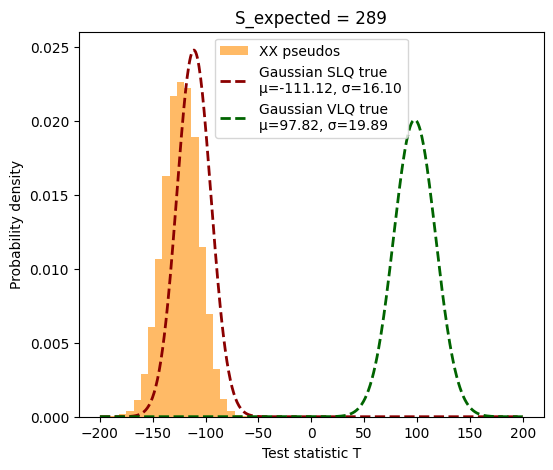

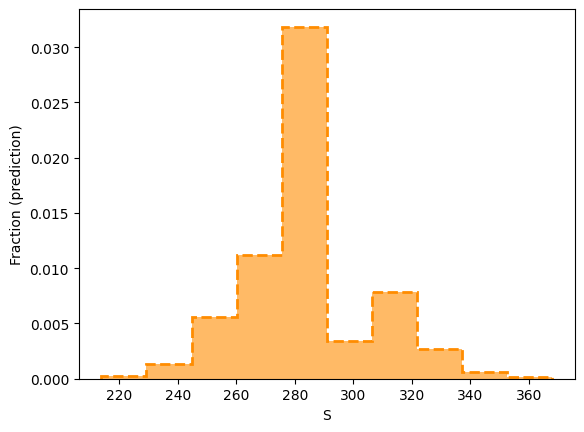

S mean SLQ:  286.8252804259158
S std SLQ:  20.84940713293563



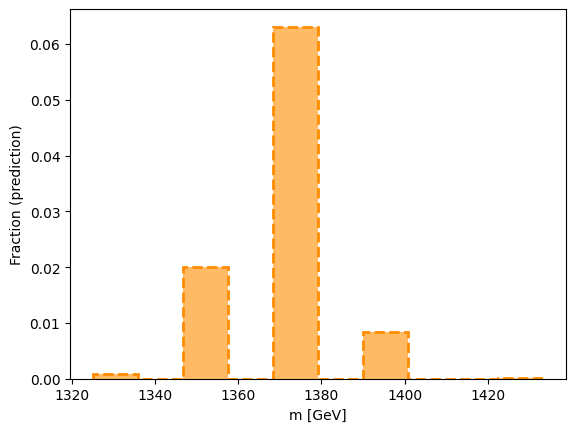

m mean SLQ:  1371.4175
m std SLQ:  14.230947277559094

 DISCRETE MASSES (BPs) 
Classification fractions:
0 = SLQ only : 0.8716
1 = VLQ only : 0.0
2 = both     : 0.0
3 = neither  : 0.1284

 ----- 
 CONTINUOUS MASSES (interpolation) 
Classification fractions:
0 = SLQ only : 0.9287
1 = VLQ only : 0.0
2 = both     : 0.0
3 = neither  : 0.0713


In [ ]:
# SET THE EXAMPLE YOU WANT TO TRY #
S_expected_XX = S_expected_SLQ_1365
m_XX = m_SLQ_1365
eventsA_XX = scoresA_SLQ_1365
df_XX_norm = df_SLQ_norm_1365



# -------------------------

Z_threshold_comp = 2
Z_threshold_incomp = 5

n_pseudo = 10000


N_bins = 16

# SM PDF
hist_SM, edges = np.histogram(scoresA_SM, bins=N_bins, range=(0,1))
B_template = hist_SM / (len(scoresA_SM) / B_expected)


Z_dis_XX = []
Z_dis_std_XX = []

Z_exc_XX = []
Z_exc_std_XX = []

Z_asimov_dis_XX = []
Z_asimov_exc_XX = []

Z_asimov_dis_obs_XX = []
Z_asimov_exc_obs_XX = []

Z_asimov_dis_obs_XX_std = []
Z_asimov_exc_obs_XX_std = []

classification_XX = []
classification_XX_inter = []

mu_TXX = []
std_TXX = []




for ii_S, S_exp in enumerate(S_expected_XX):

    print("\n==========================")
    print("S_expected =", S_exp)

    # dado un S, le asigna la masa correspondiente
    mass_XX = m_XX[ii_S]
    print("mass_XX =", mass_XX, " GeV")


    ###################
    # ASIMOV EXPECTED #
    ###################

    # XX PDF
    hist_XX, _ = np.histogram(eventsA_XX[mass_XX], bins=N_bins, range=(0,1))
    S_template_XX = hist_XX / (len(eventsA_XX[mass_XX]) / S_exp)



    Z_asimov_dis_XX_it = Z_asimov_dis(S_template_XX, B_template)
    Z_asimov_exc_XX_it = Z_asimov_exc(S_template_XX, B_template)


    Z_asimov_dis_XX.append(Z_asimov_dis_XX_it)
    Z_asimov_exc_XX.append(Z_asimov_exc_XX_it)



    print('\n Asimov datasets:')
    print('Z_asimov_dis_XX = ', Z_asimov_dis_XX_it)
    print('Z_asimov_exc_XX = ', Z_asimov_exc_XX_it)

    muS_fits = []
    muB_fits = []




    # computamos el T statistic para todos los pseudo
    T_XX = []

    # compute the number of events
    muS_fits_XX = []

    q_dis_XX = []
    q_exc_XX = []

    Z_asimov_dis_obs_XX_it = []
    Z_asimov_exc_obs_XX_it = []


    for i in range(n_pseudo):

        N_B = np.random.poisson(B_expected)

        # indices of the events
        idx_B = np.random.choice(len(events_SM[:,0]), N_B)

        scoresA_B = events_SM[:,0][idx_B]
        scoresB_B = events_SM[:,1][idx_B]



        #####################
        # FOR THE SIGNAL XX #
        #####################

        N_S = np.random.poisson(S_exp)

        # indices of the events
        idx_S = np.random.choice(len(eventsA_XX[mass_XX]), N_S)

        scoresA_S = eventsA_XX[mass_XX][idx_S]


        data_scores = np.concatenate([scoresA_B, scoresA_S])

        hist_data, _ = np.histogram(data_scores, bins=bins)

        # 2) Define likelihood for this pseudo (gotta do it for the minimizer)
        def neg_logL(params):
            mu_S, mu_B = params

            lambda_i = mu_S * pS + mu_B * pB
            lambda_i = np.clip(lambda_i, 1e-10, None)

            return -np.sum(hist_data * np.log(lambda_i) - lambda_i)

        # 3) Minimizar
        result = minimize(
            neg_logL,
            x0=[S_exp, B_expected],
            bounds=[(0, None), (0, None)]
        )

        muS_fit, muB_fit = result.x

        muS_fits_XX.append(muS_fit)


        # the pseudo exp
        X_pseudo_S = df_XX_norm[mass_XX].loc[idx_S].values
        # add the S fitted
        X_pseudo_S = np.column_stack([X_pseudo_S, np.full(len(X_pseudo_S), muS_fit)])

        scoresB_S = classifier_spin.predict_proba(X_pseudo_S)[:,1]


        scoresA = np.concatenate([scoresA_B, scoresA_S])
        scoresB = np.concatenate([scoresB_B, scoresB_S])

        T = compute_test_statistic(scoresA, scoresB, threshold_A)

        T_XX.append(T)


        #################
        # SIGNIFICANCES #
        #################

        # BIN LIKELIHOOD #
        # pseudo experiment (DISCOVERY: SM vs SM+LQ)
        scoresA_pseudo_XX = generate_pseudo_1output_dis( scoresA_SM, eventsA_XX[mass_XX], N_B, N_S )
        hist, _ = np.histogram(scoresA_pseudo_XX, bins=N_bins, range=(0,1))
        N_pseudo_XX = hist


        # pseudo experiment (EXCLUSION: SM ONLY)
        scoresA_pseudo_EXC = generate_pseudo_1output_exc( scoresA_SM, N_B )
        hist, _ = np.histogram(scoresA_pseudo_EXC, bins=N_bins, range=(0,1))
        N_pseudo_EXC = hist


        # DISCOVERY (mu_hat=1 idedally)
        mu_hat_dis_XX = fsolve(lambda x: f_mu_hat(x, N_pseudo_XX, S_template_XX, B_template),1)[0] # search around mu=1 for discovery

        q_dis_XX_it = q0(N_pseudo_XX, S_template_XX, B_template, mu_hat_dis_XX)
        q_dis_XX.append(q_dis_XX_it)



        # EXCLUSION (mu_hat=0 idedally)
        mu_hat_exc_XX = fsolve(lambda x: f_mu_hat(x, N_pseudo_EXC, S_template_XX, B_template),0)[0] # search around mu=0 for exclusion

        q_exc_XX_it = q1(N_pseudo_EXC, S_template_XX, B_template, mu_hat_exc_XX)
        q_exc_XX.append(q_exc_XX_it)


        # ASIMOV #
        Z_asimov_dis_obs_XX_it.append( Z_asimov_obs(N_pseudo_XX, B_template) )
        Z_asimov_exc_obs_XX_it.append( Z_asimov_obs(N_pseudo_XX, S_template_XX + B_template) )


    # BIN LIKELIHOOD #
    Z_dis_XX_it = np.sqrt(np.median(q_dis_XX))
    Z_dis_std_XX_it = np.std(q_dis_XX) / (2. * Z_dis_XX_it)

    Z_exc_XX_it = np.sqrt(np.median(q_exc_XX))
    Z_exc_std_XX_it = np.std(q_exc_XX) / (2. * Z_exc_XX_it)

    Z_dis_XX.append(Z_dis_XX_it)
    Z_dis_std_XX.append(Z_dis_std_XX_it)
    Z_exc_XX.append(Z_exc_XX_it)
    Z_exc_std_XX.append(Z_exc_std_XX_it)

    print('\n Binned Likelihood:')
    print('Z_dis_XX = ', Z_dis_XX_it, ' +- ', Z_dis_std_XX_it)
    print('Z_exc_XX = ', Z_exc_XX_it, ' +- ', Z_exc_std_XX_it)


    # ASIMOV #
    Z_asimov_dis_obs_XX = np.mean(Z_asimov_dis_obs_XX_it)
    Z_asimov_exc_obs_XX = np.mean(Z_asimov_exc_obs_XX_it)

    Z_asimov_dis_obs_XX_std = np.std(Z_asimov_dis_obs_XX_it)
    Z_asimov_exc_obs_XX_std = np.std(Z_asimov_exc_obs_XX_it)

    print('\n Asimov observations:')
    print('Z_asimov_dis_obs_XX = ', Z_asimov_dis_obs_XX, ' +- ', Z_asimov_dis_obs_XX_std)
    print('Z_asimov_exc_obs_XX = ', Z_asimov_exc_obs_XX, ' +- ', Z_asimov_exc_obs_XX_std)


    # Compute the characteristics of the psedo-experiment T distributions
    mu_TXX.append( np.mean(T_XX) )

    std_TXX.append( np.std(T_XX) )




    # rango común para plotear
    xmin = min(np.min(T_XX),-200)
    xmax = max(np.max(T_XX),200)
    x = np.linspace(xmin, xmax, 500)

    # gaussianas
    gauss_S = (1/(sigma_S[2]*np.sqrt(2*np.pi))) * np.exp(-(x - mu_S[2])**2 / (2*sigma_S[2]**2))
    gauss_V = (1/(sigma_V[2]*np.sqrt(2*np.pi))) * np.exp(-(x - mu_V[2])**2 / (2*sigma_V[2]**2))


    # plot
    plt.figure(figsize=(6,5))

    plt.hist(T_XX, bins=20, density=True, color='darkorange', alpha=0.6, label="XX pseudos")

    # # gaussianas
    plt.plot(x, gauss_S, color='darkred', linewidth=2, linestyle='--', label=f"Gaussian SLQ true\nμ={mu_S[2]:.2f}, σ={sigma_S[2]:.2f}")
    plt.plot(x, gauss_V, color='darkgreen', linewidth=2, linestyle='--', label=f"Gaussian VLQ true\nμ={mu_V[2]:.2f}, σ={sigma_V[2]:.2f}")

    plt.xlabel("Test statistic T")
    plt.ylabel("Probability density")
    plt.title(f"S_expected = {S_exp}")
    plt.legend()

    plt.show()


    # plot S predicted
    plt.hist(muS_fits_XX, bins=10, histtype='step', linestyle='--', edgecolor='darkorange', linewidth=2, density=True)
    plt.hist(muS_fits_XX, bins=10, color='darkorange', alpha=0.6, density=True)
    plt.xlabel("S")
    plt.ylabel("Fraction (prediction)")
    plt.show()

    print('S mean SLQ: ', np.mean(muS_fits_XX))
    print('S std SLQ: ', np.std(muS_fits_XX))
    print('')



    index_XX = [search_bench(imm, S_mean_fit_both_NEW, S_std_fit_both_NEW ) for imm in muS_fits_XX]
    masses_XX = [masses_NEW[imm] for imm in index_XX]

    # plot mass predicted
    plt.hist(masses_XX, bins=10, histtype='step', linestyle='--', edgecolor='darkorange', linewidth=2, density=True)
    plt.hist(masses_XX, bins=10, color='darkorange', alpha=0.6, density=True)
    plt.xlabel("m [GeV]")
    plt.ylabel("Fraction (prediction)")
    plt.show()

    print('m mean SLQ: ', np.mean(masses_XX))
    print('m std SLQ: ', np.std(masses_XX))
    print('')


    # Vamos a clasificar cada pseudo  1st WAY, determining the BP by S_fit
    # 0: SLQ
    # 1: VLQ
    # 2: compatible con ambos
    # 3: incompatible con ambos
    pred_counts_XX = [0,0,0,0]

    Z_XX_BP_step = []

    for i in range(n_pseudo):

        # TRUE: XX
        index_pseudo = search_bench(muS_fits_XX[i], S_mean_fit_both, S_std_fit_both )

        T_obs = T_XX[i]

        Z_SLQ_val = abs(T_obs - f_mu_S(S_mean_fit_both[index_pseudo])) / f_sigma_S(S_mean_fit_both[index_pseudo])
        Z_VLQ_val = abs(T_obs - f_mu_V(S_mean_fit_both[index_pseudo])) / f_sigma_V(S_mean_fit_both[index_pseudo])

        Z_XX_BP_step.append([Z_SLQ_val, Z_VLQ_val])


        if Z_SLQ_val<Z_threshold_comp and Z_VLQ_val>Z_threshold_incomp:
            pred = 0
        elif Z_SLQ_val>Z_threshold_incomp and  Z_VLQ_val<Z_threshold_comp:
            pred = 1
        elif Z_SLQ_val<Z_threshold_comp and Z_VLQ_val<Z_threshold_comp:
            pred = 2
        else:
            pred = 3

        pred_counts_XX[pred] += 1



    # XX
    pred_counts_XX = np.array(pred_counts_XX) / n_pseudo

    print(" DISCRETE MASSES (BPs) ")

    print("Classification fractions:")
    print("0 = SLQ only :", pred_counts_XX[0])
    print("1 = VLQ only :", pred_counts_XX[1])
    print("2 = both     :", pred_counts_XX[2])
    print("3 = neither  :", pred_counts_XX[3])

    classification_XX.append(pred_counts_XX)



    # Vamos a clasificar cada pseudo 2nd WAY, interpolation of the pdfs
    # 0: SLQ
    # 1: VLQ
    # 2: compatible con ambos
    # 3: incompatible con ambos
    pred_counts_XX = [0,0,0,0]

    Z_XX_inter_step = []

    for i in range(n_pseudo):

        # TRUE: XX
        T_obs = T_XX[i]

        Z_SLQ_val = abs(T_obs - f_mu_S(muS_fits_XX[i])) / f_sigma_S(muS_fits_XX[i])
        Z_VLQ_val = abs(T_obs - f_mu_V(muS_fits_XX[i])) / f_sigma_V(muS_fits_XX[i])

        Z_XX_inter_step.append([Z_SLQ_val, Z_VLQ_val])

        SLQ_ok = Z_SLQ_val < Z_threshold
        VLQ_ok = Z_VLQ_val < Z_threshold


        if Z_SLQ_val<Z_threshold_comp and Z_VLQ_val>Z_threshold_incomp:
            pred = 0
        elif Z_SLQ_val>Z_threshold_incomp and  Z_VLQ_val<Z_threshold_comp:
            pred = 1
        elif Z_SLQ_val<Z_threshold_comp and Z_VLQ_val<Z_threshold_comp:
            pred = 2
        else:
            pred = 3

        pred_counts_XX[pred] += 1



    # XX
    pred_counts_XX = np.array(pred_counts_XX) / n_pseudo

    print("\n ----- ")
    print(" CONTINUOUS MASSES (interpolation) ")

    print("Classification fractions:")
    print("0 = SLQ only :", pred_counts_XX[0])
    print("1 = VLQ only :", pred_counts_XX[1])
    print("2 = both     :", pred_counts_XX[2])
    print("3 = neither  :", pred_counts_XX[3])

    classification_XX_inter.append(pred_counts_XX)



S_expected = 137
mass_XX = 1500  GeV

 Asimov datasets:
Z_asimov_dis_XX =  8.84273703185537
Z_asimov_exc_XX =  8.052055073797494

 Binned Likelihood:
Z_dis_XX =  8.825502304392364  +-  1.0917653039048605
Z_exc_XX =  8.065597054449425  +-  0.8532200245575062

 Asimov observations:
Z_asimov_dis_obs_XX =  9.638671054664885  +-  1.0301063986518697
Z_asimov_exc_obs_XX =  3.923875868762724  +-  0.6959186421084708


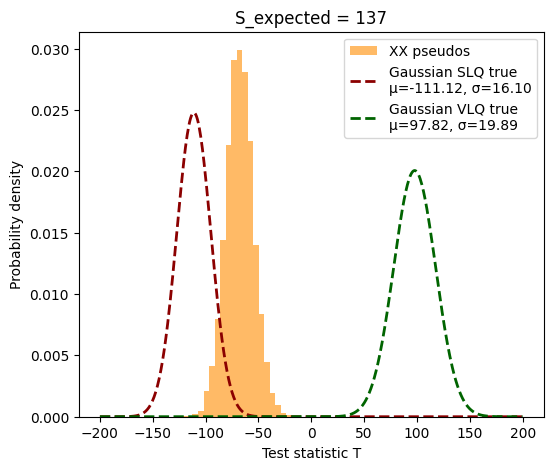

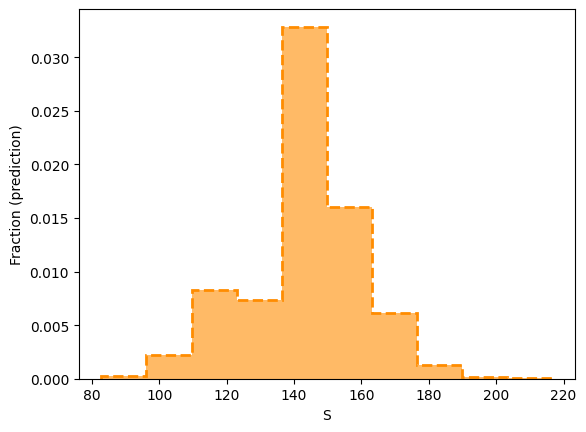

S mean SLQ:  141.08144801727806
S std SLQ:  17.101681555165115



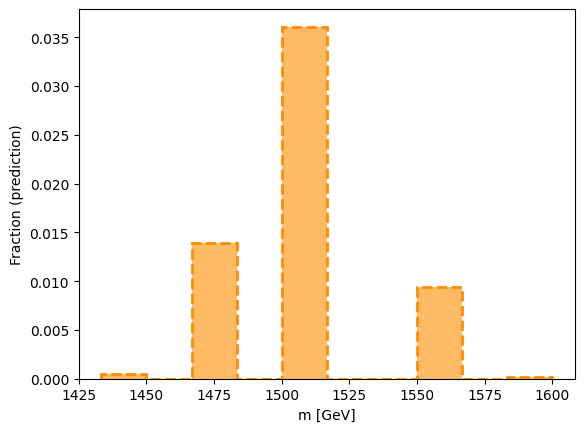

m mean SLQ:  1499.89
m std SLQ:  26.777667104427792

 DISCRETE MASSES (BPs) 
Classification fractions:
0 = SLQ only : 0.929
1 = VLQ only : 0.0
2 = both     : 0.0
3 = neither  : 0.071

 ----- 
 CONTINUOUS MASSES (interpolation) 
Classification fractions:
0 = SLQ only : 0.9075
1 = VLQ only : 0.0
2 = both     : 0.0
3 = neither  : 0.0925


In [ ]:
# SET THE EXAMPLE YOU WANT TO TRY #
S_expected_XX = S_expected_SLQ_1500
m_XX = m_SLQ_1500
eventsA_XX = scoresA_SLQ_1500
df_XX_norm = df_SLQ_norm_1500



# -------------------------

Z_threshold_comp = 2
Z_threshold_incomp = 5

n_pseudo = 10000


N_bins = 16

# SM PDF
hist_SM, edges = np.histogram(scoresA_SM, bins=N_bins, range=(0,1))
B_template = hist_SM / (len(scoresA_SM) / B_expected)


Z_dis_XX = []
Z_dis_std_XX = []

Z_exc_XX = []
Z_exc_std_XX = []

Z_asimov_dis_XX = []
Z_asimov_exc_XX = []

Z_asimov_dis_obs_XX = []
Z_asimov_exc_obs_XX = []

Z_asimov_dis_obs_XX_std = []
Z_asimov_exc_obs_XX_std = []

classification_XX = []
classification_XX_inter = []

mu_TXX = []
std_TXX = []




for ii_S, S_exp in enumerate(S_expected_XX):

    print("\n==========================")
    print("S_expected =", S_exp)

    # dado un S, le asigna la masa correspondiente
    mass_XX = m_XX[ii_S]
    print("mass_XX =", mass_XX, " GeV")


    ###################
    # ASIMOV EXPECTED #
    ###################

    # XX PDF
    hist_XX, _ = np.histogram(eventsA_XX[mass_XX], bins=N_bins, range=(0,1))
    S_template_XX = hist_XX / (len(eventsA_XX[mass_XX]) / S_exp)



    Z_asimov_dis_XX_it = Z_asimov_dis(S_template_XX, B_template)
    Z_asimov_exc_XX_it = Z_asimov_exc(S_template_XX, B_template)


    Z_asimov_dis_XX.append(Z_asimov_dis_XX_it)
    Z_asimov_exc_XX.append(Z_asimov_exc_XX_it)



    print('\n Asimov datasets:')
    print('Z_asimov_dis_XX = ', Z_asimov_dis_XX_it)
    print('Z_asimov_exc_XX = ', Z_asimov_exc_XX_it)

    muS_fits = []
    muB_fits = []




    # computamos el T statistic para todos los pseudo
    T_XX = []

    # compute the number of events
    muS_fits_XX = []

    q_dis_XX = []
    q_exc_XX = []

    Z_asimov_dis_obs_XX_it = []
    Z_asimov_exc_obs_XX_it = []


    for i in range(n_pseudo):

        N_B = np.random.poisson(B_expected)

        # indices of the events
        idx_B = np.random.choice(len(events_SM[:,0]), N_B)

        scoresA_B = events_SM[:,0][idx_B]
        scoresB_B = events_SM[:,1][idx_B]



        #####################
        # FOR THE SIGNAL XX #
        #####################

        N_S = np.random.poisson(S_exp)

        # indices of the events
        idx_S = np.random.choice(len(eventsA_XX[mass_XX]), N_S)

        scoresA_S = eventsA_XX[mass_XX][idx_S]


        data_scores = np.concatenate([scoresA_B, scoresA_S])

        hist_data, _ = np.histogram(data_scores, bins=bins)

        # 2) Define likelihood for this pseudo (gotta do it for the minimizer)
        def neg_logL(params):
            mu_S, mu_B = params

            lambda_i = mu_S * pS + mu_B * pB
            lambda_i = np.clip(lambda_i, 1e-10, None)

            return -np.sum(hist_data * np.log(lambda_i) - lambda_i)

        # 3) Minimizar
        result = minimize(
            neg_logL,
            x0=[S_exp, B_expected],
            bounds=[(0, None), (0, None)]
        )

        muS_fit, muB_fit = result.x

        muS_fits_XX.append(muS_fit)


        # the pseudo exp
        X_pseudo_S = df_XX_norm[mass_XX].loc[idx_S].values
        # add the S fitted
        X_pseudo_S = np.column_stack([X_pseudo_S, np.full(len(X_pseudo_S), muS_fit)])

        scoresB_S = classifier_spin.predict_proba(X_pseudo_S)[:,1]


        scoresA = np.concatenate([scoresA_B, scoresA_S])
        scoresB = np.concatenate([scoresB_B, scoresB_S])

        T = compute_test_statistic(scoresA, scoresB, threshold_A)

        T_XX.append(T)


        #################
        # SIGNIFICANCES #
        #################

        # BIN LIKELIHOOD #
        # pseudo experiment (DISCOVERY: SM vs SM+LQ)
        scoresA_pseudo_XX = generate_pseudo_1output_dis( scoresA_SM, eventsA_XX[mass_XX], N_B, N_S )
        hist, _ = np.histogram(scoresA_pseudo_XX, bins=N_bins, range=(0,1))
        N_pseudo_XX = hist


        # pseudo experiment (EXCLUSION: SM ONLY)
        scoresA_pseudo_EXC = generate_pseudo_1output_exc( scoresA_SM, N_B )
        hist, _ = np.histogram(scoresA_pseudo_EXC, bins=N_bins, range=(0,1))
        N_pseudo_EXC = hist


        # DISCOVERY (mu_hat=1 idedally)
        mu_hat_dis_XX = fsolve(lambda x: f_mu_hat(x, N_pseudo_XX, S_template_XX, B_template),1)[0] # search around mu=1 for discovery

        q_dis_XX_it = q0(N_pseudo_XX, S_template_XX, B_template, mu_hat_dis_XX)
        q_dis_XX.append(q_dis_XX_it)



        # EXCLUSION (mu_hat=0 idedally)
        mu_hat_exc_XX = fsolve(lambda x: f_mu_hat(x, N_pseudo_EXC, S_template_XX, B_template),0)[0] # search around mu=0 for exclusion

        q_exc_XX_it = q1(N_pseudo_EXC, S_template_XX, B_template, mu_hat_exc_XX)
        q_exc_XX.append(q_exc_XX_it)


        # ASIMOV #
        Z_asimov_dis_obs_XX_it.append( Z_asimov_obs(N_pseudo_XX, B_template) )
        Z_asimov_exc_obs_XX_it.append( Z_asimov_obs(N_pseudo_XX, S_template_XX + B_template) )


    # BIN LIKELIHOOD #
    Z_dis_XX_it = np.sqrt(np.median(q_dis_XX))
    Z_dis_std_XX_it = np.std(q_dis_XX) / (2. * Z_dis_XX_it)

    Z_exc_XX_it = np.sqrt(np.median(q_exc_XX))
    Z_exc_std_XX_it = np.std(q_exc_XX) / (2. * Z_exc_XX_it)

    Z_dis_XX.append(Z_dis_XX_it)
    Z_dis_std_XX.append(Z_dis_std_XX_it)
    Z_exc_XX.append(Z_exc_XX_it)
    Z_exc_std_XX.append(Z_exc_std_XX_it)

    print('\n Binned Likelihood:')
    print('Z_dis_XX = ', Z_dis_XX_it, ' +- ', Z_dis_std_XX_it)
    print('Z_exc_XX = ', Z_exc_XX_it, ' +- ', Z_exc_std_XX_it)


    # ASIMOV #
    Z_asimov_dis_obs_XX = np.mean(Z_asimov_dis_obs_XX_it)
    Z_asimov_exc_obs_XX = np.mean(Z_asimov_exc_obs_XX_it)

    Z_asimov_dis_obs_XX_std = np.std(Z_asimov_dis_obs_XX_it)
    Z_asimov_exc_obs_XX_std = np.std(Z_asimov_exc_obs_XX_it)

    print('\n Asimov observations:')
    print('Z_asimov_dis_obs_XX = ', Z_asimov_dis_obs_XX, ' +- ', Z_asimov_dis_obs_XX_std)
    print('Z_asimov_exc_obs_XX = ', Z_asimov_exc_obs_XX, ' +- ', Z_asimov_exc_obs_XX_std)


    # Compute the characteristics of the psedo-experiment T distributions
    mu_TXX.append( np.mean(T_XX) )

    std_TXX.append( np.std(T_XX) )




    # rango común para plotear
    xmin = min(np.min(T_XX),-200)
    xmax = max(np.max(T_XX),200)
    x = np.linspace(xmin, xmax, 500)

    # gaussianas
    gauss_S = (1/(sigma_S[2]*np.sqrt(2*np.pi))) * np.exp(-(x - mu_S[2])**2 / (2*sigma_S[2]**2))
    gauss_V = (1/(sigma_V[2]*np.sqrt(2*np.pi))) * np.exp(-(x - mu_V[2])**2 / (2*sigma_V[2]**2))


    # plot
    plt.figure(figsize=(6,5))

    plt.hist(T_XX, bins=20, density=True, color='darkorange', alpha=0.6, label="XX pseudos")

    # # gaussianas
    plt.plot(x, gauss_S, color='darkred', linewidth=2, linestyle='--', label=f"Gaussian SLQ true\nμ={mu_S[2]:.2f}, σ={sigma_S[2]:.2f}")
    plt.plot(x, gauss_V, color='darkgreen', linewidth=2, linestyle='--', label=f"Gaussian VLQ true\nμ={mu_V[2]:.2f}, σ={sigma_V[2]:.2f}")

    plt.xlabel("Test statistic T")
    plt.ylabel("Probability density")
    plt.title(f"S_expected = {S_exp}")
    plt.legend()

    plt.show()


    # plot S predicted
    plt.hist(muS_fits_XX, bins=10, histtype='step', linestyle='--', edgecolor='darkorange', linewidth=2, density=True)
    plt.hist(muS_fits_XX, bins=10, color='darkorange', alpha=0.6, density=True)
    plt.xlabel("S")
    plt.ylabel("Fraction (prediction)")
    plt.show()

    print('S mean SLQ: ', np.mean(muS_fits_XX))
    print('S std SLQ: ', np.std(muS_fits_XX))
    print('')



    index_XX = [search_bench(imm, S_mean_fit_both_NEW, S_std_fit_both_NEW ) for imm in muS_fits_XX]
    masses_XX = [masses_NEW[imm] for imm in index_XX]

    # plot mass predicted
    plt.hist(masses_XX, bins=10, histtype='step', linestyle='--', edgecolor='darkorange', linewidth=2, density=True)
    plt.hist(masses_XX, bins=10, color='darkorange', alpha=0.6, density=True)
    plt.xlabel("m [GeV]")
    plt.ylabel("Fraction (prediction)")
    plt.show()

    print('m mean SLQ: ', np.mean(masses_XX))
    print('m std SLQ: ', np.std(masses_XX))
    print('')


    # Vamos a clasificar cada pseudo  1st WAY, determining the BP by S_fit
    # 0: SLQ
    # 1: VLQ
    # 2: compatible con ambos
    # 3: incompatible con ambos
    pred_counts_XX = [0,0,0,0]

    Z_XX_BP_step = []

    for i in range(n_pseudo):

        # TRUE: XX
        index_pseudo = search_bench(muS_fits_XX[i], S_mean_fit_both, S_std_fit_both )

        T_obs = T_XX[i]

        Z_SLQ_val = abs(T_obs - f_mu_S(S_mean_fit_both[index_pseudo])) / f_sigma_S(S_mean_fit_both[index_pseudo])
        Z_VLQ_val = abs(T_obs - f_mu_V(S_mean_fit_both[index_pseudo])) / f_sigma_V(S_mean_fit_both[index_pseudo])

        Z_XX_BP_step.append([Z_SLQ_val, Z_VLQ_val])


        if Z_SLQ_val<Z_threshold_comp and Z_VLQ_val>Z_threshold_incomp:
            pred = 0
        elif Z_SLQ_val>Z_threshold_incomp and  Z_VLQ_val<Z_threshold_comp:
            pred = 1
        elif Z_SLQ_val<Z_threshold_comp and Z_VLQ_val<Z_threshold_comp:
            pred = 2
        else:
            pred = 3

        pred_counts_XX[pred] += 1



    # XX
    pred_counts_XX = np.array(pred_counts_XX) / n_pseudo

    print(" DISCRETE MASSES (BPs) ")

    print("Classification fractions:")
    print("0 = SLQ only :", pred_counts_XX[0])
    print("1 = VLQ only :", pred_counts_XX[1])
    print("2 = both     :", pred_counts_XX[2])
    print("3 = neither  :", pred_counts_XX[3])

    classification_XX.append(pred_counts_XX)



    # Vamos a clasificar cada pseudo 2nd WAY, interpolation of the pdfs
    # 0: SLQ
    # 1: VLQ
    # 2: compatible con ambos
    # 3: incompatible con ambos
    pred_counts_XX = [0,0,0,0]

    Z_XX_inter_step = []

    for i in range(n_pseudo):

        # TRUE: XX
        T_obs = T_XX[i]

        Z_SLQ_val = abs(T_obs - f_mu_S(muS_fits_XX[i])) / f_sigma_S(muS_fits_XX[i])
        Z_VLQ_val = abs(T_obs - f_mu_V(muS_fits_XX[i])) / f_sigma_V(muS_fits_XX[i])

        Z_XX_inter_step.append([Z_SLQ_val, Z_VLQ_val])

        SLQ_ok = Z_SLQ_val < Z_threshold
        VLQ_ok = Z_VLQ_val < Z_threshold


        if Z_SLQ_val<Z_threshold_comp and Z_VLQ_val>Z_threshold_incomp:
            pred = 0
        elif Z_SLQ_val>Z_threshold_incomp and  Z_VLQ_val<Z_threshold_comp:
            pred = 1
        elif Z_SLQ_val<Z_threshold_comp and Z_VLQ_val<Z_threshold_comp:
            pred = 2
        else:
            pred = 3

        pred_counts_XX[pred] += 1



    # XX
    pred_counts_XX = np.array(pred_counts_XX) / n_pseudo

    print("\n ----- ")
    print(" CONTINUOUS MASSES (interpolation) ")

    print("Classification fractions:")
    print("0 = SLQ only :", pred_counts_XX[0])
    print("1 = VLQ only :", pred_counts_XX[1])
    print("2 = both     :", pred_counts_XX[2])
    print("3 = neither  :", pred_counts_XX[3])

    classification_XX_inter.append(pred_counts_XX)



S_expected = 211
mass_XX = 1850  GeV

 Asimov datasets:
Z_asimov_dis_XX =  12.936572982384595
Z_asimov_exc_XX =  11.391200711105895

 Binned Likelihood:
Z_dis_XX =  12.91995330325098  +-  1.1326870158427855
Z_exc_XX =  11.414479812472045  +-  0.8380056347819131

 Asimov observations:
Z_asimov_dis_obs_XX =  13.492700379052575  +-  1.1044940343900942
Z_asimov_exc_obs_XX =  3.9402057574212637  +-  0.7034822658375328


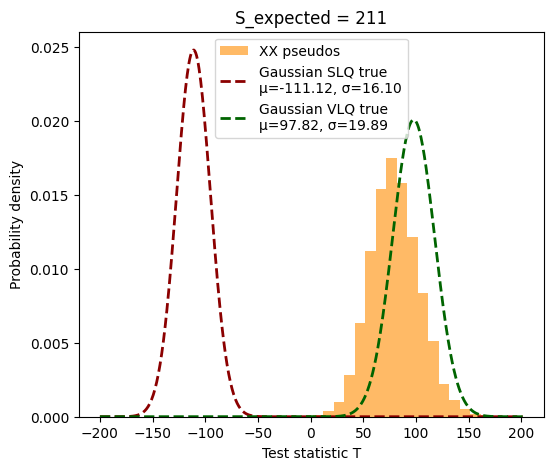

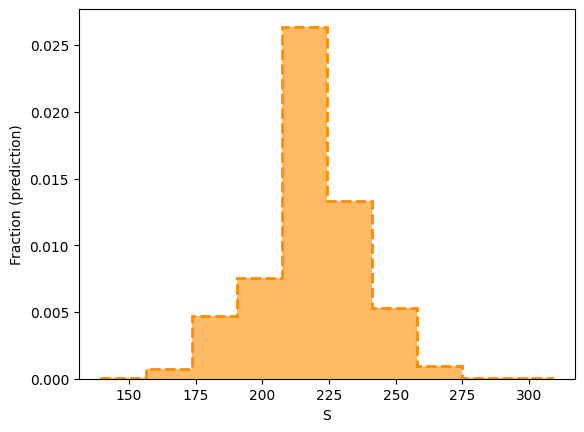

S mean SLQ:  215.65377449208867
S std SLQ:  19.466208927022112



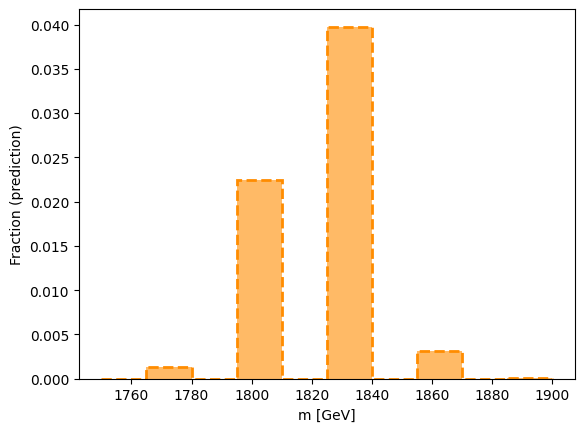

m mean SLQ:  1822.5425
m std SLQ:  19.448889553419505

 DISCRETE MASSES (BPs) 
Classification fractions:
0 = SLQ only : 0.0
1 = VLQ only : 0.8276
2 = both     : 0.0
3 = neither  : 0.1724

 ----- 
 CONTINUOUS MASSES (interpolation) 
Classification fractions:
0 = SLQ only : 0.0
1 = VLQ only : 0.9432
2 = both     : 0.0
3 = neither  : 0.0568


In [ ]:
# SET THE EXAMPLE YOU WANT TO TRY #
S_expected_XX = S_expected_VLQ_1850
m_XX = m_VLQ_1850
eventsA_XX = scoresA_VLQ_1850
df_XX_norm = df_VLQ_norm_1850



# -------------------------

Z_threshold_comp = 2
Z_threshold_incomp = 5

n_pseudo = 10000


N_bins = 16

# SM PDF
hist_SM, edges = np.histogram(scoresA_SM, bins=N_bins, range=(0,1))
B_template = hist_SM / (len(scoresA_SM) / B_expected)


Z_dis_XX = []
Z_dis_std_XX = []

Z_exc_XX = []
Z_exc_std_XX = []

Z_asimov_dis_XX = []
Z_asimov_exc_XX = []

Z_asimov_dis_obs_XX = []
Z_asimov_exc_obs_XX = []

Z_asimov_dis_obs_XX_std = []
Z_asimov_exc_obs_XX_std = []

classification_XX = []
classification_XX_inter = []

mu_TXX = []
std_TXX = []




for ii_S, S_exp in enumerate(S_expected_XX):

    print("\n==========================")
    print("S_expected =", S_exp)

    # dado un S, le asigna la masa correspondiente
    mass_XX = m_XX[ii_S]
    print("mass_XX =", mass_XX, " GeV")


    ###################
    # ASIMOV EXPECTED #
    ###################

    # XX PDF
    hist_XX, _ = np.histogram(eventsA_XX[mass_XX], bins=N_bins, range=(0,1))
    S_template_XX = hist_XX / (len(eventsA_XX[mass_XX]) / S_exp)



    Z_asimov_dis_XX_it = Z_asimov_dis(S_template_XX, B_template)
    Z_asimov_exc_XX_it = Z_asimov_exc(S_template_XX, B_template)


    Z_asimov_dis_XX.append(Z_asimov_dis_XX_it)
    Z_asimov_exc_XX.append(Z_asimov_exc_XX_it)



    print('\n Asimov datasets:')
    print('Z_asimov_dis_XX = ', Z_asimov_dis_XX_it)
    print('Z_asimov_exc_XX = ', Z_asimov_exc_XX_it)

    muS_fits = []
    muB_fits = []




    # computamos el T statistic para todos los pseudo
    T_XX = []

    # compute the number of events
    muS_fits_XX = []

    q_dis_XX = []
    q_exc_XX = []

    Z_asimov_dis_obs_XX_it = []
    Z_asimov_exc_obs_XX_it = []


    for i in range(n_pseudo):

        N_B = np.random.poisson(B_expected)

        # indices of the events
        idx_B = np.random.choice(len(events_SM[:,0]), N_B)

        scoresA_B = events_SM[:,0][idx_B]
        scoresB_B = events_SM[:,1][idx_B]



        #####################
        # FOR THE SIGNAL XX #
        #####################

        N_S = np.random.poisson(S_exp)

        # indices of the events
        idx_S = np.random.choice(len(eventsA_XX[mass_XX]), N_S)

        scoresA_S = eventsA_XX[mass_XX][idx_S]


        data_scores = np.concatenate([scoresA_B, scoresA_S])

        hist_data, _ = np.histogram(data_scores, bins=bins)

        # 2) Define likelihood for this pseudo (gotta do it for the minimizer)
        def neg_logL(params):
            mu_S, mu_B = params

            lambda_i = mu_S * pS + mu_B * pB
            lambda_i = np.clip(lambda_i, 1e-10, None)

            return -np.sum(hist_data * np.log(lambda_i) - lambda_i)

        # 3) Minimizar
        result = minimize(
            neg_logL,
            x0=[S_exp, B_expected],
            bounds=[(0, None), (0, None)]
        )

        muS_fit, muB_fit = result.x

        muS_fits_XX.append(muS_fit)


        # the pseudo exp
        X_pseudo_S = df_XX_norm[mass_XX].loc[idx_S].values
        # add the S fitted
        X_pseudo_S = np.column_stack([X_pseudo_S, np.full(len(X_pseudo_S), muS_fit)])

        scoresB_S = classifier_spin.predict_proba(X_pseudo_S)[:,1]


        scoresA = np.concatenate([scoresA_B, scoresA_S])
        scoresB = np.concatenate([scoresB_B, scoresB_S])

        T = compute_test_statistic(scoresA, scoresB, threshold_A)

        T_XX.append(T)


        #################
        # SIGNIFICANCES #
        #################

        # BIN LIKELIHOOD #
        # pseudo experiment (DISCOVERY: SM vs SM+LQ)
        scoresA_pseudo_XX = generate_pseudo_1output_dis( scoresA_SM, eventsA_XX[mass_XX], N_B, N_S )
        hist, _ = np.histogram(scoresA_pseudo_XX, bins=N_bins, range=(0,1))
        N_pseudo_XX = hist


        # pseudo experiment (EXCLUSION: SM ONLY)
        scoresA_pseudo_EXC = generate_pseudo_1output_exc( scoresA_SM, N_B )
        hist, _ = np.histogram(scoresA_pseudo_EXC, bins=N_bins, range=(0,1))
        N_pseudo_EXC = hist


        # DISCOVERY (mu_hat=1 idedally)
        mu_hat_dis_XX = fsolve(lambda x: f_mu_hat(x, N_pseudo_XX, S_template_XX, B_template),1)[0] # search around mu=1 for discovery

        q_dis_XX_it = q0(N_pseudo_XX, S_template_XX, B_template, mu_hat_dis_XX)
        q_dis_XX.append(q_dis_XX_it)



        # EXCLUSION (mu_hat=0 idedally)
        mu_hat_exc_XX = fsolve(lambda x: f_mu_hat(x, N_pseudo_EXC, S_template_XX, B_template),0)[0] # search around mu=0 for exclusion

        q_exc_XX_it = q1(N_pseudo_EXC, S_template_XX, B_template, mu_hat_exc_XX)
        q_exc_XX.append(q_exc_XX_it)


        # ASIMOV #
        Z_asimov_dis_obs_XX_it.append( Z_asimov_obs(N_pseudo_XX, B_template) )
        Z_asimov_exc_obs_XX_it.append( Z_asimov_obs(N_pseudo_XX, S_template_XX + B_template) )


    # BIN LIKELIHOOD #
    Z_dis_XX_it = np.sqrt(np.median(q_dis_XX))
    Z_dis_std_XX_it = np.std(q_dis_XX) / (2. * Z_dis_XX_it)

    Z_exc_XX_it = np.sqrt(np.median(q_exc_XX))
    Z_exc_std_XX_it = np.std(q_exc_XX) / (2. * Z_exc_XX_it)

    Z_dis_XX.append(Z_dis_XX_it)
    Z_dis_std_XX.append(Z_dis_std_XX_it)
    Z_exc_XX.append(Z_exc_XX_it)
    Z_exc_std_XX.append(Z_exc_std_XX_it)

    print('\n Binned Likelihood:')
    print('Z_dis_XX = ', Z_dis_XX_it, ' +- ', Z_dis_std_XX_it)
    print('Z_exc_XX = ', Z_exc_XX_it, ' +- ', Z_exc_std_XX_it)


    # ASIMOV #
    Z_asimov_dis_obs_XX = np.mean(Z_asimov_dis_obs_XX_it)
    Z_asimov_exc_obs_XX = np.mean(Z_asimov_exc_obs_XX_it)

    Z_asimov_dis_obs_XX_std = np.std(Z_asimov_dis_obs_XX_it)
    Z_asimov_exc_obs_XX_std = np.std(Z_asimov_exc_obs_XX_it)

    print('\n Asimov observations:')
    print('Z_asimov_dis_obs_XX = ', Z_asimov_dis_obs_XX, ' +- ', Z_asimov_dis_obs_XX_std)
    print('Z_asimov_exc_obs_XX = ', Z_asimov_exc_obs_XX, ' +- ', Z_asimov_exc_obs_XX_std)


    # Compute the characteristics of the psedo-experiment T distributions
    mu_TXX.append( np.mean(T_XX) )

    std_TXX.append( np.std(T_XX) )




    # rango común para plotear
    xmin = min(np.min(T_XX),-200)
    xmax = max(np.max(T_XX),200)
    x = np.linspace(xmin, xmax, 500)

    # gaussianas
    gauss_S = (1/(sigma_S[2]*np.sqrt(2*np.pi))) * np.exp(-(x - mu_S[2])**2 / (2*sigma_S[2]**2))
    gauss_V = (1/(sigma_V[2]*np.sqrt(2*np.pi))) * np.exp(-(x - mu_V[2])**2 / (2*sigma_V[2]**2))


    # plot
    plt.figure(figsize=(6,5))

    plt.hist(T_XX, bins=20, density=True, color='darkorange', alpha=0.6, label="XX pseudos")

    # # gaussianas
    plt.plot(x, gauss_S, color='darkred', linewidth=2, linestyle='--', label=f"Gaussian SLQ true\nμ={mu_S[2]:.2f}, σ={sigma_S[2]:.2f}")
    plt.plot(x, gauss_V, color='darkgreen', linewidth=2, linestyle='--', label=f"Gaussian VLQ true\nμ={mu_V[2]:.2f}, σ={sigma_V[2]:.2f}")

    plt.xlabel("Test statistic T")
    plt.ylabel("Probability density")
    plt.title(f"S_expected = {S_exp}")
    plt.legend()

    plt.show()


    # plot S predicted
    plt.hist(muS_fits_XX, bins=10, histtype='step', linestyle='--', edgecolor='darkorange', linewidth=2, density=True)
    plt.hist(muS_fits_XX, bins=10, color='darkorange', alpha=0.6, density=True)
    plt.xlabel("S")
    plt.ylabel("Fraction (prediction)")
    plt.show()

    print('S mean SLQ: ', np.mean(muS_fits_XX))
    print('S std SLQ: ', np.std(muS_fits_XX))
    print('')



    index_XX = [search_bench(imm, S_mean_fit_both_NEW, S_std_fit_both_NEW ) for imm in muS_fits_XX]
    masses_XX = [masses_NEW[imm]+400 for imm in index_XX]

    # plot mass predicted
    plt.hist(masses_XX, bins=10, histtype='step', linestyle='--', edgecolor='darkorange', linewidth=2, density=True)
    plt.hist(masses_XX, bins=10, color='darkorange', alpha=0.6, density=True)
    plt.xlabel("m [GeV]")
    plt.ylabel("Fraction (prediction)")
    plt.show()

    print('m mean SLQ: ', np.mean(masses_XX))
    print('m std SLQ: ', np.std(masses_XX))
    print('')


    # Vamos a clasificar cada pseudo  1st WAY, determining the BP by S_fit
    # 0: SLQ
    # 1: VLQ
    # 2: compatible con ambos
    # 3: incompatible con ambos
    pred_counts_XX = [0,0,0,0]

    Z_XX_BP_step = []

    for i in range(n_pseudo):

        # TRUE: XX
        index_pseudo = search_bench(muS_fits_XX[i], S_mean_fit_both, S_std_fit_both )

        T_obs = T_XX[i]

        Z_SLQ_val = abs(T_obs - f_mu_S(S_mean_fit_both[index_pseudo])) / f_sigma_S(S_mean_fit_both[index_pseudo])
        Z_VLQ_val = abs(T_obs - f_mu_V(S_mean_fit_both[index_pseudo])) / f_sigma_V(S_mean_fit_both[index_pseudo])

        Z_XX_BP_step.append([Z_SLQ_val, Z_VLQ_val])


        if Z_SLQ_val<Z_threshold_comp and Z_VLQ_val>Z_threshold_incomp:
            pred = 0
        elif Z_SLQ_val>Z_threshold_incomp and  Z_VLQ_val<Z_threshold_comp:
            pred = 1
        elif Z_SLQ_val<Z_threshold_comp and Z_VLQ_val<Z_threshold_comp:
            pred = 2
        else:
            pred = 3

        pred_counts_XX[pred] += 1



    # XX
    pred_counts_XX = np.array(pred_counts_XX) / n_pseudo

    print(" DISCRETE MASSES (BPs) ")

    print("Classification fractions:")
    print("0 = SLQ only :", pred_counts_XX[0])
    print("1 = VLQ only :", pred_counts_XX[1])
    print("2 = both     :", pred_counts_XX[2])
    print("3 = neither  :", pred_counts_XX[3])

    classification_XX.append(pred_counts_XX)



    # Vamos a clasificar cada pseudo 2nd WAY, interpolation of the pdfs
    # 0: SLQ
    # 1: VLQ
    # 2: compatible con ambos
    # 3: incompatible con ambos
    pred_counts_XX = [0,0,0,0]

    Z_XX_inter_step = []

    for i in range(n_pseudo):

        # TRUE: XX
        T_obs = T_XX[i]

        Z_SLQ_val = abs(T_obs - f_mu_S(muS_fits_XX[i])) / f_sigma_S(muS_fits_XX[i])
        Z_VLQ_val = abs(T_obs - f_mu_V(muS_fits_XX[i])) / f_sigma_V(muS_fits_XX[i])

        Z_XX_inter_step.append([Z_SLQ_val, Z_VLQ_val])

        SLQ_ok = Z_SLQ_val < Z_threshold
        VLQ_ok = Z_VLQ_val < Z_threshold


        if Z_SLQ_val<Z_threshold_comp and Z_VLQ_val>Z_threshold_incomp:
            pred = 0
        elif Z_SLQ_val>Z_threshold_incomp and  Z_VLQ_val<Z_threshold_comp:
            pred = 1
        elif Z_SLQ_val<Z_threshold_comp and Z_VLQ_val<Z_threshold_comp:
            pred = 2
        else:
            pred = 3

        pred_counts_XX[pred] += 1



    # XX
    pred_counts_XX = np.array(pred_counts_XX) / n_pseudo

    print("\n ----- ")
    print(" CONTINUOUS MASSES (interpolation) ")

    print("Classification fractions:")
    print("0 = SLQ only :", pred_counts_XX[0])
    print("1 = VLQ only :", pred_counts_XX[1])
    print("2 = both     :", pred_counts_XX[2])
    print("3 = neither  :", pred_counts_XX[3])

    classification_XX_inter.append(pred_counts_XX)




S_expected = 97
mass_XX = 2000  GeV

 Asimov datasets:
Z_asimov_dis_XX =  6.419248223854939
Z_asimov_exc_XX =  5.977128320383779

 Binned Likelihood:
Z_dis_XX =  6.392091587587188  +-  1.0766143127295287
Z_exc_XX =  5.988479157012514  +-  0.8621006851912865

 Asimov observations:
Z_asimov_dis_obs_XX =  7.479519316303104  +-  0.9913827325026203
Z_asimov_exc_obs_XX =  3.94293071541332  +-  0.7081927624089882


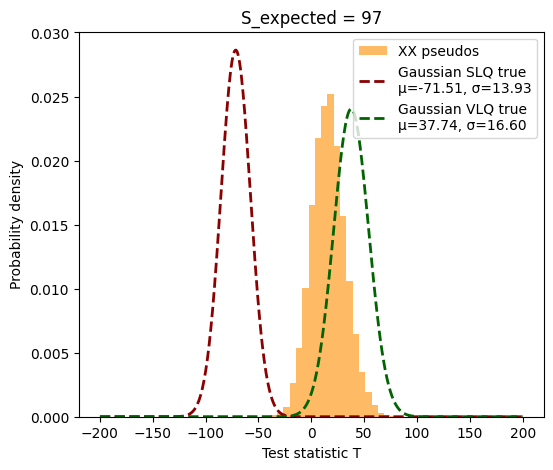

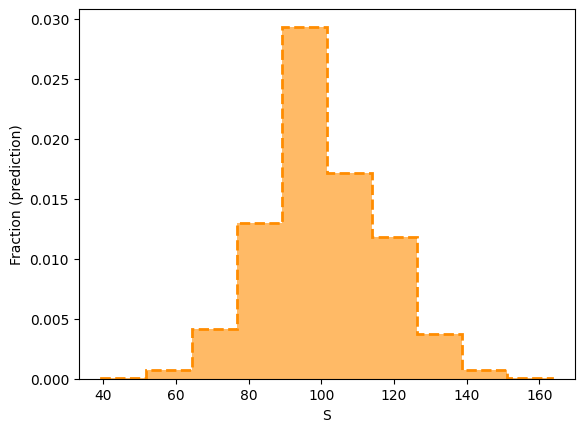

S mean SLQ:  100.82171534919644
S std SLQ:  15.628875765864858



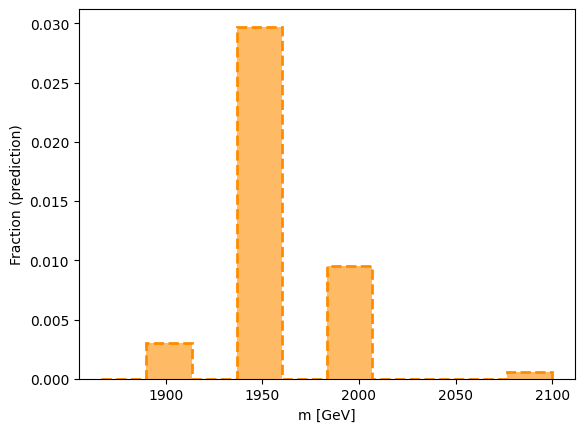

m mean SLQ:  1959.5366666666669
m std SLQ:  30.835527669664856

 DISCRETE MASSES (BPs) 
Classification fractions:
0 = SLQ only : 0.0
1 = VLQ only : 0.6484
2 = both     : 0.0017
3 = neither  : 0.3499

 ----- 
 CONTINUOUS MASSES (interpolation) 
Classification fractions:
0 = SLQ only : 0.0
1 = VLQ only : 0.7113
2 = both     : 0.0013
3 = neither  : 0.2874


In [ ]:
# SET THE EXAMPLE YOU WANT TO TRY #
S_expected_XX = S_expected_VLQ_2000
m_XX = m_VLQ_2000
eventsA_XX = scoresA_VLQ_2000
df_XX_norm = df_VLQ_norm_2000



# -------------------------

Z_threshold_comp = 2
Z_threshold_incomp = 5

n_pseudo = 10000


N_bins = 16

# SM PDF
hist_SM, edges = np.histogram(scoresA_SM, bins=N_bins, range=(0,1))
B_template = hist_SM / (len(scoresA_SM) / B_expected)


Z_dis_XX = []
Z_dis_std_XX = []

Z_exc_XX = []
Z_exc_std_XX = []

Z_asimov_dis_XX = []
Z_asimov_exc_XX = []

Z_asimov_dis_obs_XX = []
Z_asimov_exc_obs_XX = []

Z_asimov_dis_obs_XX_std = []
Z_asimov_exc_obs_XX_std = []

classification_XX = []
classification_XX_inter = []

mu_TXX = []
std_TXX = []




for ii_S, S_exp in enumerate(S_expected_XX):

    print("\n==========================")
    print("S_expected =", S_exp)

    # dado un S, le asigna la masa correspondiente
    mass_XX = m_XX[ii_S]
    print("mass_XX =", mass_XX, " GeV")


    ###################
    # ASIMOV EXPECTED #
    ###################

    # XX PDF
    hist_XX, _ = np.histogram(eventsA_XX[mass_XX], bins=N_bins, range=(0,1))
    S_template_XX = hist_XX / (len(eventsA_XX[mass_XX]) / S_exp)



    Z_asimov_dis_XX_it = Z_asimov_dis(S_template_XX, B_template)
    Z_asimov_exc_XX_it = Z_asimov_exc(S_template_XX, B_template)


    Z_asimov_dis_XX.append(Z_asimov_dis_XX_it)
    Z_asimov_exc_XX.append(Z_asimov_exc_XX_it)



    print('\n Asimov datasets:')
    print('Z_asimov_dis_XX = ', Z_asimov_dis_XX_it)
    print('Z_asimov_exc_XX = ', Z_asimov_exc_XX_it)

    muS_fits = []
    muB_fits = []




    # computamos el T statistic para todos los pseudo
    T_XX = []

    # compute the number of events
    muS_fits_XX = []

    q_dis_XX = []
    q_exc_XX = []

    Z_asimov_dis_obs_XX_it = []
    Z_asimov_exc_obs_XX_it = []


    for i in range(n_pseudo):

        N_B = np.random.poisson(B_expected)

        # indices of the events
        idx_B = np.random.choice(len(events_SM[:,0]), N_B)

        scoresA_B = events_SM[:,0][idx_B]
        scoresB_B = events_SM[:,1][idx_B]



        #####################
        # FOR THE SIGNAL XX #
        #####################

        N_S = np.random.poisson(S_exp)

        # indices of the events
        idx_S = np.random.choice(len(eventsA_XX[mass_XX]), N_S)

        scoresA_S = eventsA_XX[mass_XX][idx_S]


        data_scores = np.concatenate([scoresA_B, scoresA_S])

        hist_data, _ = np.histogram(data_scores, bins=bins)

        # 2) Define likelihood for this pseudo (gotta do it for the minimizer)
        def neg_logL(params):
            mu_S, mu_B = params

            lambda_i = mu_S * pS + mu_B * pB
            lambda_i = np.clip(lambda_i, 1e-10, None)

            return -np.sum(hist_data * np.log(lambda_i) - lambda_i)

        # 3) Minimizar
        result = minimize(
            neg_logL,
            x0=[S_exp, B_expected],
            bounds=[(0, None), (0, None)]
        )

        muS_fit, muB_fit = result.x

        muS_fits_XX.append(muS_fit)


        # the pseudo exp
        X_pseudo_S = df_XX_norm[mass_XX].loc[idx_S].values
        # add the S fitted
        X_pseudo_S = np.column_stack([X_pseudo_S, np.full(len(X_pseudo_S), muS_fit)])

        scoresB_S = classifier_spin.predict_proba(X_pseudo_S)[:,1]


        scoresA = np.concatenate([scoresA_B, scoresA_S])
        scoresB = np.concatenate([scoresB_B, scoresB_S])

        T = compute_test_statistic(scoresA, scoresB, threshold_A)

        T_XX.append(T)


        #################
        # SIGNIFICANCES #
        #################

        # BIN LIKELIHOOD #
        # pseudo experiment (DISCOVERY: SM vs SM+LQ)
        scoresA_pseudo_XX = generate_pseudo_1output_dis( scoresA_SM, eventsA_XX[mass_XX], N_B, N_S )
        hist, _ = np.histogram(scoresA_pseudo_XX, bins=N_bins, range=(0,1))
        N_pseudo_XX = hist


        # pseudo experiment (EXCLUSION: SM ONLY)
        scoresA_pseudo_EXC = generate_pseudo_1output_exc( scoresA_SM, N_B )
        hist, _ = np.histogram(scoresA_pseudo_EXC, bins=N_bins, range=(0,1))
        N_pseudo_EXC = hist


        # DISCOVERY (mu_hat=1 idedally)
        mu_hat_dis_XX = fsolve(lambda x: f_mu_hat(x, N_pseudo_XX, S_template_XX, B_template),1)[0] # search around mu=1 for discovery

        q_dis_XX_it = q0(N_pseudo_XX, S_template_XX, B_template, mu_hat_dis_XX)
        q_dis_XX.append(q_dis_XX_it)



        # EXCLUSION (mu_hat=0 idedally)
        mu_hat_exc_XX = fsolve(lambda x: f_mu_hat(x, N_pseudo_EXC, S_template_XX, B_template),0)[0] # search around mu=0 for exclusion

        q_exc_XX_it = q1(N_pseudo_EXC, S_template_XX, B_template, mu_hat_exc_XX)
        q_exc_XX.append(q_exc_XX_it)


        # ASIMOV #
        Z_asimov_dis_obs_XX_it.append( Z_asimov_obs(N_pseudo_XX, B_template) )
        Z_asimov_exc_obs_XX_it.append( Z_asimov_obs(N_pseudo_XX, S_template_XX + B_template) )


    # BIN LIKELIHOOD #
    Z_dis_XX_it = np.sqrt(np.median(q_dis_XX))
    Z_dis_std_XX_it = np.std(q_dis_XX) / (2. * Z_dis_XX_it)

    Z_exc_XX_it = np.sqrt(np.median(q_exc_XX))
    Z_exc_std_XX_it = np.std(q_exc_XX) / (2. * Z_exc_XX_it)

    Z_dis_XX.append(Z_dis_XX_it)
    Z_dis_std_XX.append(Z_dis_std_XX_it)
    Z_exc_XX.append(Z_exc_XX_it)
    Z_exc_std_XX.append(Z_exc_std_XX_it)

    print('\n Binned Likelihood:')
    print('Z_dis_XX = ', Z_dis_XX_it, ' +- ', Z_dis_std_XX_it)
    print('Z_exc_XX = ', Z_exc_XX_it, ' +- ', Z_exc_std_XX_it)


    # ASIMOV #
    Z_asimov_dis_obs_XX = np.mean(Z_asimov_dis_obs_XX_it)
    Z_asimov_exc_obs_XX = np.mean(Z_asimov_exc_obs_XX_it)

    Z_asimov_dis_obs_XX_std = np.std(Z_asimov_dis_obs_XX_it)
    Z_asimov_exc_obs_XX_std = np.std(Z_asimov_exc_obs_XX_it)

    print('\n Asimov observations:')
    print('Z_asimov_dis_obs_XX = ', Z_asimov_dis_obs_XX, ' +- ', Z_asimov_dis_obs_XX_std)
    print('Z_asimov_exc_obs_XX = ', Z_asimov_exc_obs_XX, ' +- ', Z_asimov_exc_obs_XX_std)


    # Compute the characteristics of the psedo-experiment T distributions
    mu_TXX.append( np.mean(T_XX) )

    std_TXX.append( np.std(T_XX) )




    # rango común para plotear
    xmin = min(np.min(T_XX),-200)
    xmax = max(np.max(T_XX),200)
    x = np.linspace(xmin, xmax, 500)

    # gaussianas
    gauss_S = (1/(sigma_S[3]*np.sqrt(2*np.pi))) * np.exp(-(x - mu_S[3])**2 / (2*sigma_S[3]**2))
    gauss_V = (1/(sigma_V[3]*np.sqrt(2*np.pi))) * np.exp(-(x - mu_V[3])**2 / (2*sigma_V[3]**2))


    # plot
    plt.figure(figsize=(6,5))

    plt.hist(T_XX, bins=20, density=True, color='darkorange', alpha=0.6, label="XX pseudos")

    # # gaussianas
    plt.plot(x, gauss_S, color='darkred', linewidth=2, linestyle='--', label=f"Gaussian SLQ true\nμ={mu_S[3]:.2f}, σ={sigma_S[3]:.2f}")
    plt.plot(x, gauss_V, color='darkgreen', linewidth=2, linestyle='--', label=f"Gaussian VLQ true\nμ={mu_V[3]:.2f}, σ={sigma_V[3]:.2f}")

    plt.xlabel("Test statistic T")
    plt.ylabel("Probability density")
    plt.title(f"S_expected = {S_exp}")
    plt.legend()

    plt.show()


    # plot S predicted
    plt.hist(muS_fits_XX, bins=10, histtype='step', linestyle='--', edgecolor='darkorange', linewidth=2, density=True)
    plt.hist(muS_fits_XX, bins=10, color='darkorange', alpha=0.6, density=True)
    plt.xlabel("S")
    plt.ylabel("Fraction (prediction)")
    plt.show()

    print('S mean SLQ: ', np.mean(muS_fits_XX))
    print('S std SLQ: ', np.std(muS_fits_XX))
    print('')



    index_XX = [search_bench(imm, S_mean_fit_both_NEW, S_std_fit_both_NEW ) for imm in muS_fits_XX]
    masses_XX = [masses_NEW[imm]+400 for imm in index_XX]

    # plot mass predicted
    plt.hist(masses_XX, bins=10, histtype='step', linestyle='--', edgecolor='darkorange', linewidth=2, density=True)
    plt.hist(masses_XX, bins=10, color='darkorange', alpha=0.6, density=True)
    plt.xlabel("m [GeV]")
    plt.ylabel("Fraction (prediction)")
    plt.show()

    print('m mean SLQ: ', np.mean(masses_XX))
    print('m std SLQ: ', np.std(masses_XX))
    print('')


    # Vamos a clasificar cada pseudo  1st WAY, determining the BP by S_fit
    # 0: SLQ
    # 1: VLQ
    # 2: compatible con ambos
    # 3: incompatible con ambos
    pred_counts_XX = [0,0,0,0]

    Z_XX_BP_step = []

    for i in range(n_pseudo):

        # TRUE: XX
        index_pseudo = search_bench(muS_fits_XX[i], S_mean_fit_both, S_std_fit_both )

        T_obs = T_XX[i]

        Z_SLQ_val = abs(T_obs - f_mu_S(S_mean_fit_both[index_pseudo])) / f_sigma_S(S_mean_fit_both[index_pseudo])
        Z_VLQ_val = abs(T_obs - f_mu_V(S_mean_fit_both[index_pseudo])) / f_sigma_V(S_mean_fit_both[index_pseudo])

        Z_XX_BP_step.append([Z_SLQ_val, Z_VLQ_val])


        if Z_SLQ_val<Z_threshold_comp and Z_VLQ_val>Z_threshold_incomp:
            pred = 0
        elif Z_SLQ_val>Z_threshold_incomp and  Z_VLQ_val<Z_threshold_comp:
            pred = 1
        elif Z_SLQ_val<Z_threshold_comp and Z_VLQ_val<Z_threshold_comp:
            pred = 2
        else:
            pred = 3

        pred_counts_XX[pred] += 1



    # XX
    pred_counts_XX = np.array(pred_counts_XX) / n_pseudo

    print(" DISCRETE MASSES (BPs) ")

    print("Classification fractions:")
    print("0 = SLQ only :", pred_counts_XX[0])
    print("1 = VLQ only :", pred_counts_XX[1])
    print("2 = both     :", pred_counts_XX[2])
    print("3 = neither  :", pred_counts_XX[3])

    classification_XX.append(pred_counts_XX)



    # Vamos a clasificar cada pseudo 2nd WAY, interpolation of the pdfs
    # 0: SLQ
    # 1: VLQ
    # 2: compatible con ambos
    # 3: incompatible con ambos
    pred_counts_XX = [0,0,0,0]

    Z_XX_inter_step = []

    for i in range(n_pseudo):

        # TRUE: XX
        T_obs = T_XX[i]

        Z_SLQ_val = abs(T_obs - f_mu_S(muS_fits_XX[i])) / f_sigma_S(muS_fits_XX[i])
        Z_VLQ_val = abs(T_obs - f_mu_V(muS_fits_XX[i])) / f_sigma_V(muS_fits_XX[i])

        Z_XX_inter_step.append([Z_SLQ_val, Z_VLQ_val])

        SLQ_ok = Z_SLQ_val < Z_threshold
        VLQ_ok = Z_VLQ_val < Z_threshold


        if Z_SLQ_val<Z_threshold_comp and Z_VLQ_val>Z_threshold_incomp:
            pred = 0
        elif Z_SLQ_val>Z_threshold_incomp and  Z_VLQ_val<Z_threshold_comp:
            pred = 1
        elif Z_SLQ_val<Z_threshold_comp and Z_VLQ_val<Z_threshold_comp:
            pred = 2
        else:
            pred = 3

        pred_counts_XX[pred] += 1



    # XX
    pred_counts_XX = np.array(pred_counts_XX) / n_pseudo

    print("\n ----- ")
    print(" CONTINUOUS MASSES (interpolation) ")

    print("Classification fractions:")
    print("0 = SLQ only :", pred_counts_XX[0])
    print("1 = VLQ only :", pred_counts_XX[1])
    print("2 = both     :", pred_counts_XX[2])
    print("3 = neither  :", pred_counts_XX[3])

    classification_XX_inter.append(pred_counts_XX)


S_expected = 1032
mass_XX = 1800  GeV

 Asimov datasets:
Z_asimov_dis_XX =  48.82410293755669
Z_asimov_exc_XX =  35.84895543749959

 Binned Likelihood:
Z_dis_XX =  48.81892651480214  +-  1.3185337043305414
Z_exc_XX =  35.86270825634673  +-  0.6824868136783793

 Asimov observations:
Z_asimov_dis_obs_XX =  48.96628163179379  +-  1.3166347975910255
Z_asimov_exc_obs_XX =  3.9498610172187423  +-  0.7032128320865143


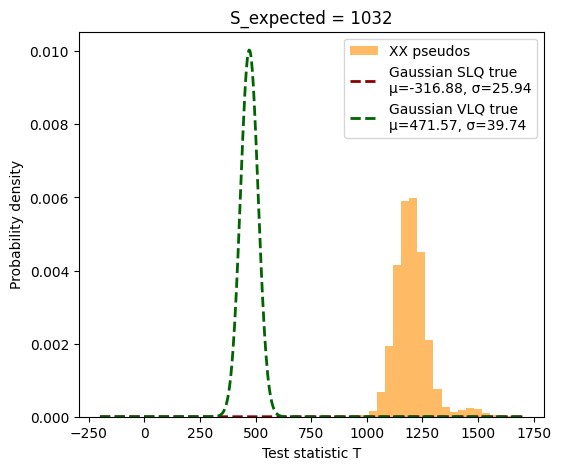

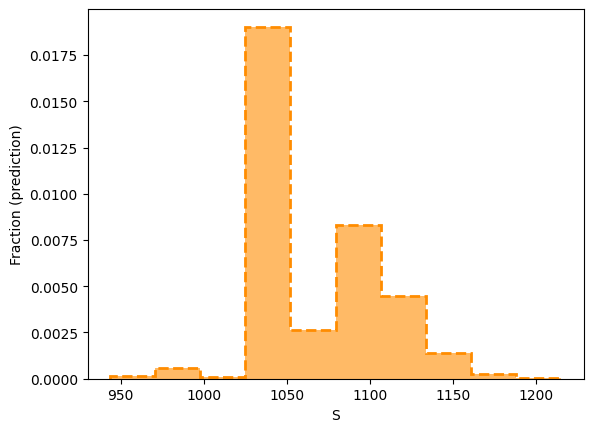

S mean SLQ:  1063.0760787306074
S std SLQ:  39.500536623095726



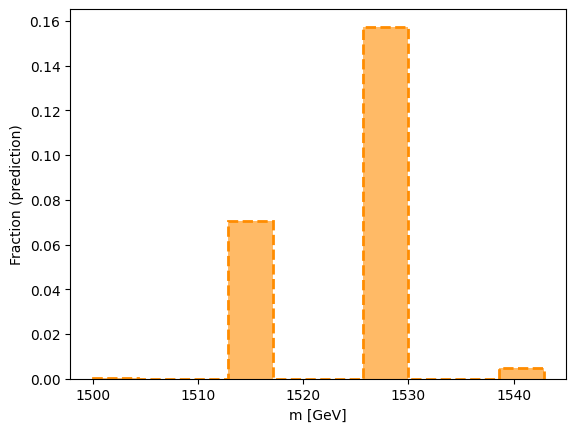

m mean SLQ:  1524.5
m std SLQ:  7.153920004345337

 DISCRETE MASSES (BPs) 
Classification fractions:
0 = SLQ only : 0.0
1 = VLQ only : 0.0
2 = both     : 0.0
3 = neither  : 1.0

 ----- 
 CONTINUOUS MASSES (interpolation) 
Classification fractions:
0 = SLQ only : 0.0
1 = VLQ only : 0.0
2 = both     : 0.0
3 = neither  : 1.0

S_expected = 656
mass_XX = 2000  GeV

 Asimov datasets:
Z_asimov_dis_XX =  34.480970104389556
Z_asimov_exc_XX =  26.78177534520094

 Binned Likelihood:
Z_dis_XX =  34.49185326515246  +-  1.2589419790046317
Z_exc_XX =  26.79010888862937  +-  0.7330423004797938

 Asimov observations:
Z_asimov_dis_obs_XX =  34.69458008483345  +-  1.2529084345760941
Z_asimov_exc_obs_XX =  3.9245712707799845  +-  0.7021822858512801


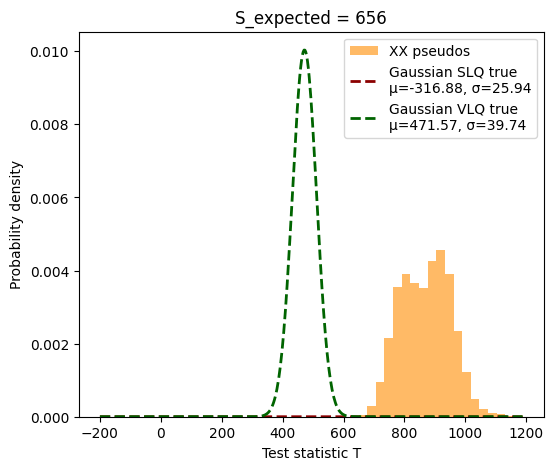

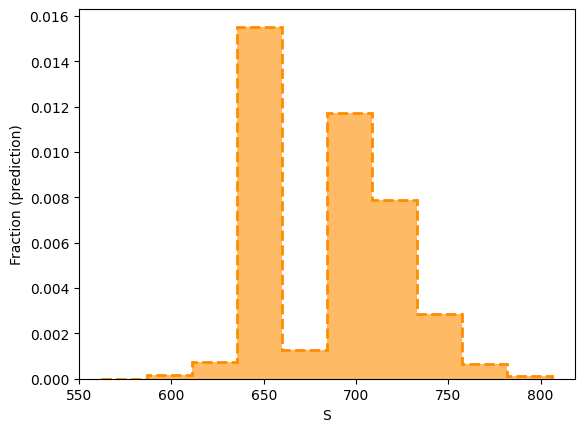

S mean SLQ:  687.8604368720539
S std SLQ:  32.66039781878431



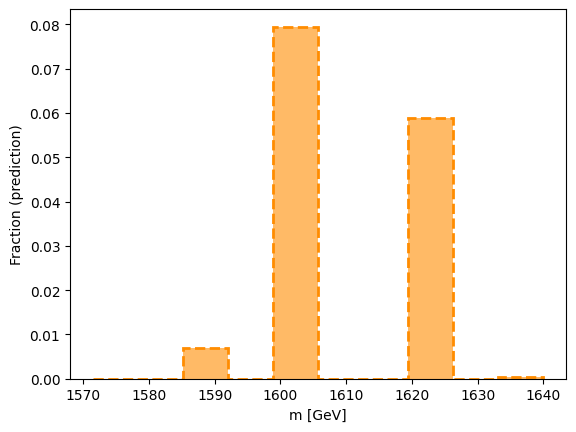

m mean SLQ:  1607.500857142857
m std SLQ:  10.97719339246194

 DISCRETE MASSES (BPs) 
Classification fractions:
0 = SLQ only : 0.0
1 = VLQ only : 0.0
2 = both     : 0.0
3 = neither  : 1.0

 ----- 
 CONTINUOUS MASSES (interpolation) 
Classification fractions:
0 = SLQ only : 0.0
1 = VLQ only : 0.0
2 = both     : 0.0
3 = neither  : 1.0


In [ ]:
# SET THE EXAMPLE YOU WANT TO TRY #
S_expected_XX = S_expected_VLQ_YM
m_XX = m_VLQ_YM
eventsA_XX = scoresA_VLQ_YM
df_XX_norm = df_VLQ_norm_YM



# -------------------------

Z_threshold_comp = 2
Z_threshold_incomp = 5

n_pseudo = 10000


N_bins = 16

# SM PDF
hist_SM, edges = np.histogram(scoresA_SM, bins=N_bins, range=(0,1))
B_template = hist_SM / (len(scoresA_SM) / B_expected)


Z_dis_XX = []
Z_dis_std_XX = []

Z_exc_XX = []
Z_exc_std_XX = []

Z_asimov_dis_XX = []
Z_asimov_exc_XX = []

Z_asimov_dis_obs_XX = []
Z_asimov_exc_obs_XX = []

Z_asimov_dis_obs_XX_std = []
Z_asimov_exc_obs_XX_std = []

classification_XX = []
classification_XX_inter = []

mu_TXX = []
std_TXX = []




for ii_S, S_exp in enumerate(S_expected_XX):

    print("\n==========================")
    print("S_expected =", S_exp)

    # dado un S, le asigna la masa correspondiente
    mass_XX = m_XX[ii_S]
    print("mass_XX =", mass_XX, " GeV")


    ###################
    # ASIMOV EXPECTED #
    ###################

    # XX PDF
    hist_XX, _ = np.histogram(eventsA_XX[mass_XX], bins=N_bins, range=(0,1))
    S_template_XX = hist_XX / (len(eventsA_XX[mass_XX]) / S_exp)



    Z_asimov_dis_XX_it = Z_asimov_dis(S_template_XX, B_template)
    Z_asimov_exc_XX_it = Z_asimov_exc(S_template_XX, B_template)


    Z_asimov_dis_XX.append(Z_asimov_dis_XX_it)
    Z_asimov_exc_XX.append(Z_asimov_exc_XX_it)



    print('\n Asimov datasets:')
    print('Z_asimov_dis_XX = ', Z_asimov_dis_XX_it)
    print('Z_asimov_exc_XX = ', Z_asimov_exc_XX_it)

    muS_fits = []
    muB_fits = []




    # computamos el T statistic para todos los pseudo
    T_XX = []

    # compute the number of events
    muS_fits_XX = []

    q_dis_XX = []
    q_exc_XX = []

    Z_asimov_dis_obs_XX_it = []
    Z_asimov_exc_obs_XX_it = []


    for i in range(n_pseudo):

        N_B = np.random.poisson(B_expected)

        # indices of the events
        idx_B = np.random.choice(len(events_SM[:,0]), N_B)

        scoresA_B = events_SM[:,0][idx_B]
        scoresB_B = events_SM[:,1][idx_B]



        #####################
        # FOR THE SIGNAL XX #
        #####################

        N_S = np.random.poisson(S_exp)

        # indices of the events
        idx_S = np.random.choice(len(eventsA_XX[mass_XX]), N_S)

        scoresA_S = eventsA_XX[mass_XX][idx_S]


        data_scores = np.concatenate([scoresA_B, scoresA_S])

        hist_data, _ = np.histogram(data_scores, bins=bins)

        # 2) Define likelihood for this pseudo (gotta do it for the minimizer)
        def neg_logL(params):
            mu_S, mu_B = params

            lambda_i = mu_S * pS + mu_B * pB
            lambda_i = np.clip(lambda_i, 1e-10, None)

            return -np.sum(hist_data * np.log(lambda_i) - lambda_i)

        # 3) Minimizar
        result = minimize(
            neg_logL,
            x0=[S_exp, B_expected],
            bounds=[(0, None), (0, None)]
        )

        muS_fit, muB_fit = result.x

        muS_fits_XX.append(muS_fit)


        # the pseudo exp
        X_pseudo_S = df_XX_norm[mass_XX].loc[idx_S].values
        # add the S fitted
        X_pseudo_S = np.column_stack([X_pseudo_S, np.full(len(X_pseudo_S), muS_fit)])

        scoresB_S = classifier_spin.predict_proba(X_pseudo_S)[:,1]


        scoresA = np.concatenate([scoresA_B, scoresA_S])
        scoresB = np.concatenate([scoresB_B, scoresB_S])

        T = compute_test_statistic(scoresA, scoresB, threshold_A)

        T_XX.append(T)


        #################
        # SIGNIFICANCES #
        #################

        # BIN LIKELIHOOD #
        # pseudo experiment (DISCOVERY: SM vs SM+LQ)
        scoresA_pseudo_XX = generate_pseudo_1output_dis( scoresA_SM, eventsA_XX[mass_XX], N_B, N_S )
        hist, _ = np.histogram(scoresA_pseudo_XX, bins=N_bins, range=(0,1))
        N_pseudo_XX = hist


        # pseudo experiment (EXCLUSION: SM ONLY)
        scoresA_pseudo_EXC = generate_pseudo_1output_exc( scoresA_SM, N_B )
        hist, _ = np.histogram(scoresA_pseudo_EXC, bins=N_bins, range=(0,1))
        N_pseudo_EXC = hist


        # DISCOVERY (mu_hat=1 idedally)
        mu_hat_dis_XX = fsolve(lambda x: f_mu_hat(x, N_pseudo_XX, S_template_XX, B_template),1)[0] # search around mu=1 for discovery

        q_dis_XX_it = q0(N_pseudo_XX, S_template_XX, B_template, mu_hat_dis_XX)
        q_dis_XX.append(q_dis_XX_it)



        # EXCLUSION (mu_hat=0 idedally)
        mu_hat_exc_XX = fsolve(lambda x: f_mu_hat(x, N_pseudo_EXC, S_template_XX, B_template),0)[0] # search around mu=0 for exclusion

        q_exc_XX_it = q1(N_pseudo_EXC, S_template_XX, B_template, mu_hat_exc_XX)
        q_exc_XX.append(q_exc_XX_it)


        # ASIMOV #
        Z_asimov_dis_obs_XX_it.append( Z_asimov_obs(N_pseudo_XX, B_template) )
        Z_asimov_exc_obs_XX_it.append( Z_asimov_obs(N_pseudo_XX, S_template_XX + B_template) )


    # BIN LIKELIHOOD #
    Z_dis_XX_it = np.sqrt(np.median(q_dis_XX))
    Z_dis_std_XX_it = np.std(q_dis_XX) / (2. * Z_dis_XX_it)

    Z_exc_XX_it = np.sqrt(np.median(q_exc_XX))
    Z_exc_std_XX_it = np.std(q_exc_XX) / (2. * Z_exc_XX_it)

    Z_dis_XX.append(Z_dis_XX_it)
    Z_dis_std_XX.append(Z_dis_std_XX_it)
    Z_exc_XX.append(Z_exc_XX_it)
    Z_exc_std_XX.append(Z_exc_std_XX_it)

    print('\n Binned Likelihood:')
    print('Z_dis_XX = ', Z_dis_XX_it, ' +- ', Z_dis_std_XX_it)
    print('Z_exc_XX = ', Z_exc_XX_it, ' +- ', Z_exc_std_XX_it)


    # ASIMOV #
    Z_asimov_dis_obs_XX = np.mean(Z_asimov_dis_obs_XX_it)
    Z_asimov_exc_obs_XX = np.mean(Z_asimov_exc_obs_XX_it)

    Z_asimov_dis_obs_XX_std = np.std(Z_asimov_dis_obs_XX_it)
    Z_asimov_exc_obs_XX_std = np.std(Z_asimov_exc_obs_XX_it)

    print('\n Asimov observations:')
    print('Z_asimov_dis_obs_XX = ', Z_asimov_dis_obs_XX, ' +- ', Z_asimov_dis_obs_XX_std)
    print('Z_asimov_exc_obs_XX = ', Z_asimov_exc_obs_XX, ' +- ', Z_asimov_exc_obs_XX_std)


    # Compute the characteristics of the psedo-experiment T distributions
    mu_TXX.append( np.mean(T_XX) )

    std_TXX.append( np.std(T_XX) )




    # rango común para plotear
    xmin = min(np.min(T_XX),-200)
    xmax = max(np.max(T_XX),200)
    x = np.linspace(xmin, xmax, 500)

    # gaussianas
    gauss_S = (1/(sigma_S[0]*np.sqrt(2*np.pi))) * np.exp(-(x - mu_S[0])**2 / (2*sigma_S[0]**2))
    gauss_V = (1/(sigma_V[0]*np.sqrt(2*np.pi))) * np.exp(-(x - mu_V[0])**2 / (2*sigma_V[0]**2))


    # plot
    plt.figure(figsize=(6,5))

    plt.hist(T_XX, bins=20, density=True, color='darkorange', alpha=0.6, label="XX pseudos")

    # # gaussianas
    plt.plot(x, gauss_S, color='darkred', linewidth=2, linestyle='--', label=f"Gaussian SLQ true\nμ={mu_S[0]:.2f}, σ={sigma_S[0]:.2f}")
    plt.plot(x, gauss_V, color='darkgreen', linewidth=2, linestyle='--', label=f"Gaussian VLQ true\nμ={mu_V[0]:.2f}, σ={sigma_V[0]:.2f}")

    plt.xlabel("Test statistic T")
    plt.ylabel("Probability density")
    plt.title(f"S_expected = {S_exp}")
    plt.legend()

    plt.show()


    # plot S predicted
    plt.hist(muS_fits_XX, bins=10, histtype='step', linestyle='--', edgecolor='darkorange', linewidth=2, density=True)
    plt.hist(muS_fits_XX, bins=10, color='darkorange', alpha=0.6, density=True)
    plt.xlabel("S")
    plt.ylabel("Fraction (prediction)")
    plt.show()

    print('S mean SLQ: ', np.mean(muS_fits_XX))
    print('S std SLQ: ', np.std(muS_fits_XX))
    print('')



    index_XX = [search_bench(imm, S_mean_fit_both_NEW, S_std_fit_both_NEW ) for imm in muS_fits_XX]
    masses_XX = [masses_NEW[imm]+400 for imm in index_XX]

    # plot mass predicted
    plt.hist(masses_XX, bins=10, histtype='step', linestyle='--', edgecolor='darkorange', linewidth=2, density=True)
    plt.hist(masses_XX, bins=10, color='darkorange', alpha=0.6, density=True)
    plt.xlabel("m [GeV]")
    plt.ylabel("Fraction (prediction)")
    plt.show()

    print('m mean SLQ: ', np.mean(masses_XX))
    print('m std SLQ: ', np.std(masses_XX))
    print('')


    # Vamos a clasificar cada pseudo  1st WAY, determining the BP by S_fit
    # 0: SLQ
    # 1: VLQ
    # 2: compatible con ambos
    # 3: incompatible con ambos
    pred_counts_XX = [0,0,0,0]

    Z_XX_BP_step = []

    for i in range(n_pseudo):

        # TRUE: XX
        index_pseudo = search_bench(muS_fits_XX[i], S_mean_fit_both, S_std_fit_both )

        T_obs = T_XX[i]

        Z_SLQ_val = abs(T_obs - f_mu_S(S_mean_fit_both[index_pseudo])) / f_sigma_S(S_mean_fit_both[index_pseudo])
        Z_VLQ_val = abs(T_obs - f_mu_V(S_mean_fit_both[index_pseudo])) / f_sigma_V(S_mean_fit_both[index_pseudo])

        Z_XX_BP_step.append([Z_SLQ_val, Z_VLQ_val])


        if Z_SLQ_val<Z_threshold_comp and Z_VLQ_val>Z_threshold_incomp:
            pred = 0
        elif Z_SLQ_val>Z_threshold_incomp and  Z_VLQ_val<Z_threshold_comp:
            pred = 1
        elif Z_SLQ_val<Z_threshold_comp and Z_VLQ_val<Z_threshold_comp:
            pred = 2
        else:
            pred = 3

        pred_counts_XX[pred] += 1



    # XX
    pred_counts_XX = np.array(pred_counts_XX) / n_pseudo

    print(" DISCRETE MASSES (BPs) ")

    print("Classification fractions:")
    print("0 = SLQ only :", pred_counts_XX[0])
    print("1 = VLQ only :", pred_counts_XX[1])
    print("2 = both     :", pred_counts_XX[2])
    print("3 = neither  :", pred_counts_XX[3])

    classification_XX.append(pred_counts_XX)



    # Vamos a clasificar cada pseudo 2nd WAY, interpolation of the pdfs
    # 0: SLQ
    # 1: VLQ
    # 2: compatible con ambos
    # 3: incompatible con ambos
    pred_counts_XX = [0,0,0,0]

    Z_XX_inter_step = []

    for i in range(n_pseudo):

        # TRUE: XX
        T_obs = T_XX[i]

        Z_SLQ_val = abs(T_obs - f_mu_S(muS_fits_XX[i])) / f_sigma_S(muS_fits_XX[i])
        Z_VLQ_val = abs(T_obs - f_mu_V(muS_fits_XX[i])) / f_sigma_V(muS_fits_XX[i])

        Z_XX_inter_step.append([Z_SLQ_val, Z_VLQ_val])

        SLQ_ok = Z_SLQ_val < Z_threshold
        VLQ_ok = Z_VLQ_val < Z_threshold


        if Z_SLQ_val<Z_threshold_comp and Z_VLQ_val>Z_threshold_incomp:
            pred = 0
        elif Z_SLQ_val>Z_threshold_incomp and  Z_VLQ_val<Z_threshold_comp:
            pred = 1
        elif Z_SLQ_val<Z_threshold_comp and Z_VLQ_val<Z_threshold_comp:
            pred = 2
        else:
            pred = 3

        pred_counts_XX[pred] += 1



    # XX
    pred_counts_XX = np.array(pred_counts_XX) / n_pseudo

    print("\n ----- ")
    print(" CONTINUOUS MASSES (interpolation) ")

    print("Classification fractions:")
    print("0 = SLQ only :", pred_counts_XX[0])
    print("1 = VLQ only :", pred_counts_XX[1])
    print("2 = both     :", pred_counts_XX[2])
    print("3 = neither  :", pred_counts_XX[3])

    classification_XX_inter.append(pred_counts_XX)

# ULTRA loop (vary WP)

In [94]:
B_expected = 45962

mass_list_SLQ = [1200,1300,1400,1500,1600,1700,1800,1900]
mass_list_VLQ = [1600,1700,1800,1900,2000,2100,2200,2300]

S_expected = [round(fid_xsec_SLQ_14TeV(mmm, 0.5) * Lum) for mmm in mass_list_SLQ]
S_expected_VLQ = [round(fid_xsec_VLQ_14TeV(mmm, 0.5) * Lum) for mmm in mass_list_VLQ]

print('B_expected: ', B_expected)
print('S_expected: ', S_expected)


n_pseudo = 100

B_expected:  45962
S_expected:  [742, 419, 237, 137, 80, 46, 27, 16]


In [95]:
threshold_list = [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.975, 0.99]


save_m5_BPOK_SLQ = []
save_m5_BPOK_SLQ_inf = []
save_m5_BPOK_SLQ_sup = []

save_m5_BPOK_VLQ = []
save_m5_BPOK_VLQ_inf = []
save_m5_BPOK_VLQ_sup = []


save_m5_inter_SLQ = []
save_m5_inter_SLQ_inf = []
save_m5_inter_SLQ_sup = []

save_m5_inter_VLQ = []
save_m5_inter_VLQ_inf = []
save_m5_inter_VLQ_sup = []


save_m5_prev_SLQ = []
save_m5_prev_SLQ_inf = []
save_m5_prev_SLQ_sup = []

save_m5_prev_VLQ = []
save_m5_prev_VLQ_inf = []
save_m5_prev_VLQ_sup = []


for th_it in threshold_list:
    print("\n**************************************************")
    threshold_A = th_it
    print("threshold_A =", threshold_A)


    # Compute the distributions, the PDFs
    mu_S = []
    mu_V = []

    sigma_S = []
    sigma_V = []

    for S_it in range(len(S_exp_SLQ)):

        print("\n==========================")
        print("S_expected SLQ =", S_exp_SLQ[S_it])
        # print("S_expected VLQ =", S_exp_VLQ[S_it]) # same number of events

        # dado un S, le asigna la masa (del SLQ o VLQ) correspondiente
        mass_SLQ = m_SLQ[S_it]
        mass_VLQ = m_VLQ[S_it]
        print("mass_SLQ =", mass_SLQ, " GeV")
        print("mass_VLQ =", mass_VLQ, " GeV")


        # computamos el T statistic para todos los pseudo
        T_SLQ = []
        T_VLQ = []

        for i in range(n_pseudo_TRUE):

            N_B = np.random.poisson(B_expected)
            N_S = np.random.poisson(S_exp_SLQ[S_it])

            scoresA, scoresB = generate_pseudo( events_SM, events_SLQ[mass_SLQ], N_B, N_S )

            T = compute_test_statistic(scoresA, scoresB, th_it)

            T_SLQ.append(T)


            N_S = np.random.poisson(S_exp_SLQ[S_it]) # same number of events

            scoresA, scoresB = generate_pseudo( events_SM, events_VLQ[mass_VLQ], N_B, N_S )

            T = compute_test_statistic(scoresA, scoresB, th_it)

            T_VLQ.append(T)

            # Compute the Z of the distributions
        mu_S.append( np.mean(T_SLQ) )
        mu_V.append( np.mean(T_VLQ) )

        sigma_S.append( np.std(T_SLQ) )
        sigma_V.append( np.std(T_VLQ) )


    # fit the PDFs
    f_mu_S = interp1d(S_exp_SLQ, mu_S, kind='linear', fill_value="extrapolate")
    f_mu_V = interp1d(S_exp_SLQ, mu_V, kind='linear', fill_value="extrapolate")

    f_sigma_S = interp1d(S_exp_SLQ, sigma_S, kind='linear', fill_value="extrapolate")
    f_sigma_V = interp1d(S_exp_SLQ, sigma_V, kind='linear', fill_value="extrapolate")





    # Compute the significance
    classification_SLQ_BPOK = []
    classification_VLQ_BPOK = []

    classification_SLQ_inter = []
    classification_VLQ_inter = []

    classification_SLQ_prev = []
    classification_VLQ_prev = []


    Z_SLQ_BPOK = []
    Z_VLQ_BPOK = []

    Z_SLQ_inter = []
    Z_VLQ_inter = []

    Z_SLQ_prev = []
    Z_VLQ_prev = []


    mu_TSLQ = []
    std_TSLQ = []
    mu_TVLQ = []
    std_TVLQ = []

    for ii_S, S_exp in enumerate(S_exp_SLQ):

        print("\n==========================")
        print("S_expected_SLQ =", S_exp_SLQ[ii_S])

        # dado un S, le asigna la masa (del SLQ o VLQ) correspondiente
        mass_SLQ = m_SLQ[ii_S]
        mass_VLQ = m_VLQ[ii_S]
        print("mass_SLQ =", mass_SLQ, " GeV")
        print("mass_VLQ =", mass_VLQ, " GeV")


        # computamos el T statistic para todos los pseudo
        T_SLQ = []
        T_VLQ = []

        # compute the number of events
        muS_fits_SLQ = []
        muS_fits_VLQ = []

        for i in range(n_pseudo):

            N_B = np.random.poisson(B_expected)

            # indices of the events
            idx_B = np.random.choice(len(events_SM[:,0]), N_B)

            scoresA_B = events_SM[:,0][idx_B]
            scoresB_B = events_SM[:,1][idx_B]



            ###########
            # FOR SLQ #
            ###########

            N_S = np.random.poisson(S_exp_SLQ[ii_S])

            # indices of the events
            idx_S = np.random.choice(len(events_SLQ[mass_SLQ][:,0]), N_S)

            scoresA_S = events_SLQ[mass_SLQ][:,0][idx_S]


            data_scores = np.concatenate([scoresA_B, scoresA_S])

            hist_data, _ = np.histogram(data_scores, bins=bins)

            # 2) Define likelihood for this pseudo (gotta do it for the minimizer)
            def neg_logL(params):
                mu_S, mu_B = params

                lambda_i = mu_S * pS + mu_B * pB
                lambda_i = np.clip(lambda_i, 1e-10, None)

                return -np.sum(hist_data * np.log(lambda_i) - lambda_i)

            # 3) Minimizar
            result = minimize(
                neg_logL,
                x0=[S_exp, B_expected],
                bounds=[(0, None), (0, None)]
            )

            muS_fit, muB_fit = result.x

            muS_fits_SLQ.append(muS_fit)


            # the pseudo exp
            X_pseudo_S = df_SLQ_norm[mass_SLQ].loc[idx_S].values
            # add the S fitted
            X_pseudo_S = np.column_stack([X_pseudo_S, np.full(len(X_pseudo_S), muS_fit)])

            scoresB_S = classifier_spin.predict_proba(X_pseudo_S)[:,1]


            scoresA = np.concatenate([scoresA_B, scoresA_S])
            scoresB = np.concatenate([scoresB_B, scoresB_S])

            T = compute_test_statistic(scoresA, scoresB, th_it)

            T_SLQ.append(T)




            ###########
            # FOR VLQ #
            ###########

            N_S = np.random.poisson(S_exp_SLQ[ii_S]) # same number of events

            # indices of the events
            idx_S = np.random.choice(len(events_VLQ[mass_VLQ][:,0]), N_S)

            scoresA_S = events_VLQ[mass_VLQ][:,0][idx_S]


            data_scores = np.concatenate([scoresA_B, scoresA_S])

            hist_data, _ = np.histogram(data_scores, bins=bins)

            # 2) Define likelihood for this pseudo (gotta do it for the minimizer)
            def neg_logL(params):
                mu_S, mu_B = params

                lambda_i = mu_S * pS + mu_B * pB
                lambda_i = np.clip(lambda_i, 1e-10, None)

                return -np.sum(hist_data * np.log(lambda_i) - lambda_i)

            # 3) Minimizar
            result = minimize(
                neg_logL,
                x0=[S_exp, B_expected],
                bounds=[(0, None), (0, None)]
            )

            muS_fit, muB_fit = result.x

            muS_fits_VLQ.append(muS_fit)


            # the pseudo exp
            X_pseudo_V = df_VLQ_norm[mass_VLQ].loc[idx_S].values
            # add the S fitted
            X_pseudo_V = np.column_stack([X_pseudo_V, np.full(len(X_pseudo_V), muS_fit)])

            scoresB_S = classifier_spin.predict_proba(X_pseudo_V)[:,1]


            scoresA = np.concatenate([scoresA_B, scoresA_S])
            scoresB = np.concatenate([scoresB_B, scoresB_S])

            T = compute_test_statistic(scoresA, scoresB, th_it)

            T_VLQ.append(T)

        # Compute the characteristics of the psedo-experiment T distributions
        mu_TSLQ.append( np.mean(T_SLQ) )
        mu_TVLQ.append( np.mean(T_VLQ) )

        std_TSLQ.append( np.std(T_SLQ) )
        std_TVLQ.append( np.std(T_VLQ) )



        # rango común para plotear
        xmin = min(np.min(T_SLQ), np.min(T_VLQ))
        xmax = max(np.max(T_SLQ), np.max(T_VLQ))
        x = np.linspace(xmin, xmax, 500)

        # gaussianas
        gauss_S = (1/(sigma_S[ii_S]*np.sqrt(2*np.pi))) * np.exp(-(x - mu_S[ii_S])**2 / (2*sigma_S[ii_S]**2))
        gauss_V = (1/(sigma_V[ii_S]*np.sqrt(2*np.pi))) * np.exp(-(x - mu_V[ii_S])**2 / (2*sigma_V[ii_S]**2))


        # plot
        plt.figure(figsize=(6,5))

        plt.hist(T_SLQ, bins=20, density=True, color='red', alpha=0.6, label="SLQ pseudos")
        plt.hist(T_VLQ, bins=20, density=True, color='green', alpha=0.6, label="VLQ pseudos")

        # gaussianas
        plt.plot(x, gauss_S, color='darkred', linewidth=2, linestyle='--', label=f"Gaussian SLQ true\nμ={mu_S[ii_S]:.2f}, σ={sigma_S[ii_S]:.2f}")
        plt.plot(x, gauss_V, color='darkgreen', linewidth=2, linestyle='--', label=f"Gaussian VLQ true\nμ={mu_V[ii_S]:.2f}, σ={sigma_V[ii_S]:.2f}")

        plt.xlabel("Test statistic T")
        plt.ylabel("Probability density")
        plt.title(f"S_expected = {S_exp}")
        plt.legend()

        plt.show()

        plt.hist(muS_fits_SLQ, bins=10, histtype='step', linestyle='--', edgecolor='red', linewidth=2, density=True)
        plt.hist(muS_fits_SLQ, bins=10, color='red', alpha=0.6, density=True)
        plt.hist(muS_fits_VLQ, bins=10, histtype='step', linestyle=':', edgecolor='green', linewidth=2, density=True)
        plt.hist(muS_fits_VLQ, bins=10, color='green', alpha=0.6, density=True)
        plt.xlabel("S")
        plt.ylabel("Fraction (prediction)")
        plt.show()

        print('S mean SLQ: ', np.mean(muS_fits_SLQ))
        print('S std SLQ: ', np.std(muS_fits_SLQ))
        print('S mean VLQ: ', np.mean(muS_fits_VLQ))
        print('S std VLQ: ', np.std(muS_fits_VLQ))
        print('')





        # COMPARING WITH DISCRETE MASS EXAMPLES (following S)

        # Vamos a clasificar cada pseudo
        # 0: SLQ
        # 1: VLQ
        # 2: compatible con ambos
        # 3: incompatible con ambos
        pred_counts_SLQ = [0,0,0,0]
        pred_counts_VLQ = [0,0,0,0]

        Z_SLQ_BPOK_step = []
        Z_VLQ_BPOK_step = []

        for i in range(n_pseudo):

            # TRUE: SLQ
            index_pseudo = search_bench(muS_fits_SLQ[i], S_mean_fit_both, S_std_fit_both )

            T_obs = T_SLQ[i]

            Z_SLQ_val = abs(T_obs - f_mu_S(S_mean_fit_both[index_pseudo])) / f_sigma_S(S_mean_fit_both[index_pseudo])
            Z_VLQ_val = abs(T_obs - f_mu_V(S_mean_fit_both[index_pseudo])) / f_sigma_V(S_mean_fit_both[index_pseudo])

            Z_SLQ_BPOK_step.append([Z_SLQ_val, Z_VLQ_val])

            SLQ_ok = Z_SLQ_val < Z_threshold
            VLQ_ok = Z_VLQ_val < Z_threshold


            if SLQ_ok and not VLQ_ok:
                pred = 0
            elif VLQ_ok and not SLQ_ok:
                pred = 1
            elif SLQ_ok and VLQ_ok:
                pred = 2
            else:
                pred = 3

            pred_counts_SLQ[pred] += 1


            # TRUE: VLQ
            index_pseudo = search_bench(muS_fits_VLQ[i], S_mean_fit_both, S_std_fit_both )

            T_obs = T_VLQ[i]

            Z_SLQ_val = abs(T_obs - f_mu_S(S_mean_fit_both[index_pseudo])) / f_sigma_S(S_mean_fit_both[index_pseudo])
            Z_VLQ_val = abs(T_obs - f_mu_V(S_mean_fit_both[index_pseudo])) / f_sigma_V(S_mean_fit_both[index_pseudo])

            Z_VLQ_BPOK_step.append([Z_SLQ_val, Z_VLQ_val])

            SLQ_ok = Z_SLQ_val < Z_threshold
            VLQ_ok = Z_VLQ_val < Z_threshold


            if SLQ_ok and not VLQ_ok:
                pred = 0
            elif VLQ_ok and not SLQ_ok:
                pred = 1
            elif SLQ_ok and VLQ_ok:
                pred = 2
            else:
                pred = 3

            pred_counts_VLQ[pred] += 1


        Z_SLQ_BPOK.append(np.array(Z_SLQ_BPOK_step))
        Z_VLQ_BPOK.append(np.array(Z_VLQ_BPOK_step))


        # SLQ
        pred_counts_SLQ = np.array(pred_counts_SLQ) / n_pseudo

        print("\n------")
        print(" COMPARING WITH DISCRETE MASS EXAMPLES (following S) ")

        print("TESTING SLQ")
        print("Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)")
        print("0 = SLQ only :", pred_counts_SLQ[0])
        print("1 = VLQ only :", pred_counts_SLQ[1])
        print("2 = both     :", pred_counts_SLQ[2])
        print("3 = neither  :", pred_counts_SLQ[3])

        classification_SLQ_BPOK.append(pred_counts_SLQ)


        print('')

        # VLQ
        pred_counts_VLQ = np.array(pred_counts_VLQ) / n_pseudo

        print("TESTING VLQ")
        print("Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)")
        print("0 = SLQ only :", pred_counts_VLQ[0])
        print("1 = VLQ only :", pred_counts_VLQ[1])
        print("2 = both     :", pred_counts_VLQ[2])
        print("3 = neither  :", pred_counts_VLQ[3])

        classification_VLQ_BPOK.append(pred_counts_VLQ)






        # COMPARING WITH CONTINUOUS MASSES (interpolation)

        # Vamos a clasificar cada pseudo
        # 0: SLQ
        # 1: VLQ
        # 2: compatible con ambos
        # 3: incompatible con ambos
        pred_counts_SLQ = [0,0,0,0]
        pred_counts_VLQ = [0,0,0,0]

        Z_SLQ_inter_step = []
        Z_VLQ_inter_step = []

        for i in range(n_pseudo):

            # TRUE: SLQ
            T_obs = T_SLQ[i]

            Z_SLQ_val = abs(T_obs - f_mu_S(muS_fits_SLQ[i])) / f_sigma_S(muS_fits_SLQ[i])
            Z_VLQ_val = abs(T_obs - f_mu_V(muS_fits_SLQ[i])) / f_sigma_V(muS_fits_SLQ[i])

            Z_SLQ_inter_step.append([Z_SLQ_val, Z_VLQ_val])

            SLQ_ok = Z_SLQ_val < Z_threshold
            VLQ_ok = Z_VLQ_val < Z_threshold


            if SLQ_ok and not VLQ_ok:
                pred = 0
            elif VLQ_ok and not SLQ_ok:
                pred = 1
            elif SLQ_ok and VLQ_ok:
                pred = 2
            else:
                pred = 3

            pred_counts_SLQ[pred] += 1


            # TRUE: VLQ
            T_obs = T_VLQ[i]

            Z_SLQ_val = abs(T_obs - f_mu_S(muS_fits_VLQ[i])) / f_sigma_S(muS_fits_VLQ[i])
            Z_VLQ_val = abs(T_obs - f_mu_V(muS_fits_VLQ[i])) / f_sigma_V(muS_fits_VLQ[i])

            Z_VLQ_inter_step.append([Z_SLQ_val, Z_VLQ_val])

            SLQ_ok = Z_SLQ_val < Z_threshold
            VLQ_ok = Z_VLQ_val < Z_threshold


            if SLQ_ok and not VLQ_ok:
                pred = 0
            elif VLQ_ok and not SLQ_ok:
                pred = 1
            elif SLQ_ok and VLQ_ok:
                pred = 2
            else:
                pred = 3

            pred_counts_VLQ[pred] += 1


        Z_SLQ_inter.append(np.array(Z_SLQ_inter_step))
        Z_VLQ_inter.append(np.array(Z_VLQ_inter_step))


        # SLQ
        pred_counts_SLQ = np.array(pred_counts_SLQ) / n_pseudo

        print("\n------")
        print(" COMPARING WITH CONTINUOUS MASSES (interpolation) ")

        print("TESTING SLQ")
        print("Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)")
        print("0 = SLQ only :", pred_counts_SLQ[0])
        print("1 = VLQ only :", pred_counts_SLQ[1])
        print("2 = both     :", pred_counts_SLQ[2])
        print("3 = neither  :", pred_counts_SLQ[3])

        classification_SLQ_inter.append(pred_counts_SLQ)


        print('')

        # VLQ
        pred_counts_VLQ = np.array(pred_counts_VLQ) / n_pseudo

        print("TESTING VLQ")
        print("Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)")
        print("0 = SLQ only :", pred_counts_VLQ[0])
        print("1 = VLQ only :", pred_counts_VLQ[1])
        print("2 = both     :", pred_counts_VLQ[2])
        print("3 = neither  :", pred_counts_VLQ[3])

        classification_VLQ_inter.append(pred_counts_VLQ)





        # COMPARING WITH THE PREVIOUSLY KNOWN PDF

        # Vamos a clasificar cada pseudo
        # 0: SLQ
        # 1: VLQ
        # 2: compatible con ambos
        # 3: incompatible con ambos
        pred_counts_SLQ = [0,0,0,0]
        pred_counts_VLQ = [0,0,0,0]

        Z_SLQ_prev_step = []
        Z_VLQ_prev_step = []

        for i in range(n_pseudo):

            # TRUE: SLQ
            T_obs = T_SLQ[i]

            Z_SLQ_val = abs(T_obs - mu_S[ii_S]) / sigma_S[ii_S]
            Z_VLQ_val = abs(T_obs - mu_V[ii_S]) / sigma_V[ii_S]

            Z_SLQ_prev_step.append([Z_SLQ_val, Z_VLQ_val])

            SLQ_ok = Z_SLQ_val < Z_threshold
            VLQ_ok = Z_VLQ_val < Z_threshold


            if SLQ_ok and not VLQ_ok:
                pred = 0
            elif VLQ_ok and not SLQ_ok:
                pred = 1
            elif SLQ_ok and VLQ_ok:
                pred = 2
            else:
                pred = 3

            pred_counts_SLQ[pred] += 1


            # TRUE: VLQ
            T_obs = T_VLQ[i]

            Z_SLQ_val = abs(T_obs - mu_S[ii_S]) / sigma_S[ii_S]
            Z_VLQ_val = abs(T_obs - mu_V[ii_S]) / sigma_V[ii_S]

            Z_VLQ_prev_step.append([Z_SLQ_val, Z_VLQ_val])

            SLQ_ok = Z_SLQ_val < Z_threshold
            VLQ_ok = Z_VLQ_val < Z_threshold


            if SLQ_ok and not VLQ_ok:
                pred = 0
            elif VLQ_ok and not SLQ_ok:
                pred = 1
            elif SLQ_ok and VLQ_ok:
                pred = 2
            else:
                pred = 3

            pred_counts_VLQ[pred] += 1


        Z_SLQ_prev.append(np.array(Z_SLQ_prev_step))
        Z_VLQ_prev.append(np.array(Z_VLQ_prev_step))


        # SLQ
        pred_counts_SLQ = np.array(pred_counts_SLQ) / n_pseudo

        print("\n------")
        print(" COMPARING WITH THE PREVIOUSLY KNOWN PDF ")

        print("TESTING SLQ")
        print("Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)")
        print("0 = SLQ only :", pred_counts_SLQ[0])
        print("1 = VLQ only :", pred_counts_SLQ[1])
        print("2 = both     :", pred_counts_SLQ[2])
        print("3 = neither  :", pred_counts_SLQ[3])

        classification_SLQ_prev.append(pred_counts_SLQ)


        print('')

        # VLQ
        pred_counts_VLQ = np.array(pred_counts_VLQ) / n_pseudo

        print("TESTING VLQ")
        print("Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)")
        print("0 = SLQ only :", pred_counts_VLQ[0])
        print("1 = VLQ only :", pred_counts_VLQ[1])
        print("2 = both     :", pred_counts_VLQ[2])
        print("3 = neither  :", pred_counts_VLQ[3])

        classification_VLQ_prev.append(pred_counts_VLQ)



    # get the Z exclusion
    z_BPOK_SLQ, err_BPOK_SLQ = Z_processor(Z_SLQ_BPOK, select=1)
    z_BPOK_VLQ, err_BPOK_VLQ = Z_processor(Z_VLQ_BPOK, select=0)

    z_inter_SLQ, err_inter_SLQ = Z_processor(Z_SLQ_inter, select=1)
    z_inter_VLQ, err_inter_VLQ = Z_processor(Z_VLQ_inter, select=0)

    z_prev_SLQ, err_prev_SLQ = Z_processor(Z_SLQ_prev, select=1)
    z_prev_VLQ, err_prev_VLQ = Z_processor(Z_VLQ_prev, select=0)

    # Interpolate to find Z=5
    m5_BPOK_SLQ, m5_BPOK_SLQ_inf, m5_BPOK_SLQ_sup = find_mass(np.array(m_SLQ), z_BPOK_SLQ, err_BPOK_SLQ)
    m5_BPOK_VLQ, m5_BPOK_VLQ_inf, m5_BPOK_VLQ_sup = find_mass(np.array(m_VLQ), z_BPOK_VLQ, err_BPOK_VLQ)
    m5_inter_SLQ, m5_inter_SLQ_inf, m5_inter_SLQ_sup = find_mass(np.array(m_SLQ), z_inter_SLQ, err_inter_SLQ)
    m5_inter_VLQ, m5_inter_VLQ_inf, m5_inter_VLQ_sup = find_mass(np.array(m_VLQ), z_inter_VLQ, err_inter_VLQ)
    m5_prev_SLQ, m5_prev_SLQ_inf, m5_prev_SLQ_sup = find_mass(np.array(m_SLQ), z_prev_SLQ, err_prev_SLQ)
    m5_prev_VLQ, m5_prev_VLQ_inf, m5_prev_VLQ_sup = find_mass(np.array(m_VLQ), z_prev_VLQ, err_prev_VLQ)

    # save
    save_m5_BPOK_SLQ.append(m5_BPOK_SLQ)
    save_m5_BPOK_SLQ_inf.append(m5_BPOK_SLQ_inf)
    save_m5_BPOK_SLQ_sup.append(m5_BPOK_SLQ_sup)

    save_m5_BPOK_VLQ.append(m5_BPOK_VLQ)
    save_m5_BPOK_VLQ_inf.append(m5_BPOK_VLQ_inf)
    save_m5_BPOK_VLQ_sup.append(m5_BPOK_VLQ_sup)


    save_m5_inter_SLQ.append(m5_inter_SLQ)
    save_m5_inter_SLQ_inf.append(m5_inter_SLQ_inf)
    save_m5_inter_SLQ_sup.append(m5_inter_SLQ_sup)

    save_m5_inter_VLQ.append(m5_inter_VLQ)
    save_m5_inter_VLQ_inf.append(m5_inter_VLQ_inf)
    save_m5_inter_VLQ_sup.append(m5_inter_VLQ_sup)


    save_m5_prev_SLQ.append(m5_prev_SLQ)
    save_m5_prev_SLQ_inf.append(m5_prev_SLQ_inf)
    save_m5_prev_SLQ_sup.append(m5_prev_SLQ_sup)

    save_m5_prev_VLQ.append(m5_prev_VLQ)
    save_m5_prev_VLQ_inf.append(m5_prev_VLQ_inf)
    save_m5_prev_VLQ_sup.append(m5_prev_VLQ_sup)



Output hidden; open in https://colab.research.google.com to view.

In [ ]:

# SAVE

file_path = mainfolder + 'saved-results/vs14TeV_thresholds.txt'

# Combine all data into a single array
data_to_save = np.column_stack([
    threshold_list,
    save_m5_BPOK_SLQ,
    save_m5_BPOK_SLQ_inf,
    save_m5_BPOK_SLQ_sup,
    save_m5_BPOK_VLQ,
    save_m5_BPOK_VLQ_inf,
    save_m5_BPOK_VLQ_sup,
    save_m5_inter_SLQ,
    save_m5_inter_SLQ_inf,
    save_m5_inter_SLQ_sup,
    save_m5_inter_VLQ,
    save_m5_inter_VLQ_inf,
    save_m5_inter_VLQ_sup,
    save_m5_prev_SLQ,
    save_m5_prev_SLQ_inf,
    save_m5_prev_SLQ_sup,
    save_m5_prev_VLQ,
    save_m5_prev_VLQ_inf,
    save_m5_prev_VLQ_sup
])


# Save data to a text file
np.savetxt(file_path, data_to_save, fmt='%.6f',
           header='# threshold_list next are sets of 3 (median inf sup) for SLQ and VLQ, for methods: BPOK, inter, prev ',
           comments='')

print(f"Data saved to: {file_path}")

In [90]:
# LOAD

file_path = mainfolder + 'saved-results/vs14TeV_thresholds.txt'

loaded_data = np.loadtxt(file_path)

threshold_list = loaded_data[:, 0]

save_m5_BPOK_SLQ = loaded_data[:, 1]
save_m5_BPOK_SLQ_inf = loaded_data[:, 2]
save_m5_BPOK_SLQ_sup = loaded_data[:, 3]
save_m5_BPOK_VLQ = loaded_data[:, 4]
save_m5_BPOK_VLQ_inf = loaded_data[:, 5]
save_m5_BPOK_VLQ_sup = loaded_data[:, 6]

save_m5_inter_SLQ = loaded_data[:, 7]
save_m5_inter_SLQ_inf = loaded_data[:, 8]
save_m5_inter_SLQ_sup = loaded_data[:, 9]
save_m5_inter_VLQ = loaded_data[:, 10]
save_m5_inter_VLQ_inf = loaded_data[:, 11]
save_m5_inter_VLQ_sup = loaded_data[:, 12]

save_m5_prev_SLQ = loaded_data[:, 13]
save_m5_prev_SLQ_inf = loaded_data[:, 14]
save_m5_prev_SLQ_sup = loaded_data[:, 15]
save_m5_prev_VLQ = loaded_data[:, 16]
save_m5_prev_VLQ_inf = loaded_data[:, 17]
save_m5_prev_VLQ_sup = loaded_data[:, 18]


/tmp/ipykernel_2784/2450064181.py:26: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


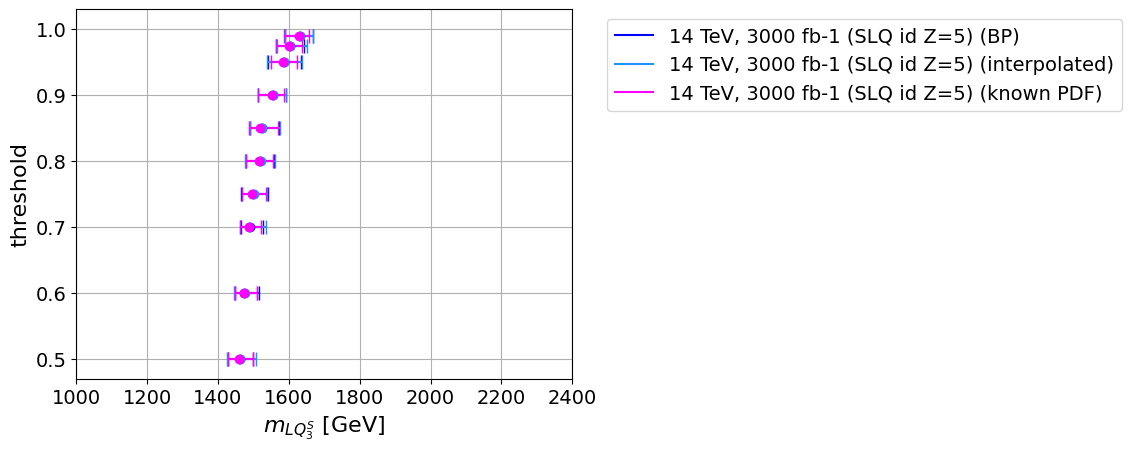

/tmp/ipykernel_2784/2450064181.py:57: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


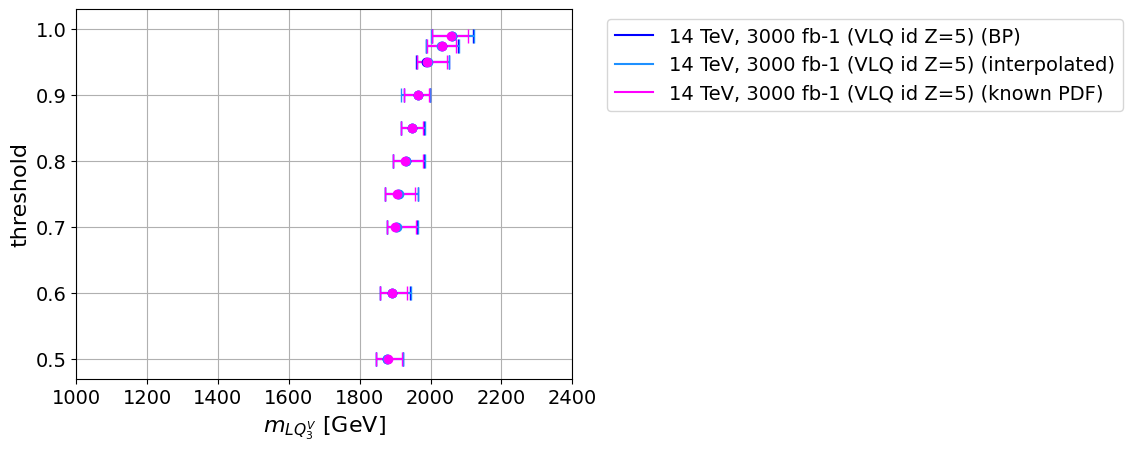

In [96]:
for ii_tt, th_it in enumerate(threshold_list):

    m5_BPOK_SLQ_err = [[save_m5_BPOK_SLQ[ii_tt] - save_m5_BPOK_SLQ_inf[ii_tt]], [save_m5_BPOK_SLQ_sup[ii_tt] - save_m5_BPOK_SLQ[ii_tt]]]
    plt.errorbar(save_m5_BPOK_SLQ[ii_tt], th_it, xerr=m5_BPOK_SLQ_err, fmt='o', capsize=5, color='blue')

    m5_inter_SLQ_err = [[save_m5_inter_SLQ[ii_tt] - save_m5_inter_SLQ_inf[ii_tt]], [save_m5_inter_SLQ_sup[ii_tt] - save_m5_inter_SLQ[ii_tt]]]
    plt.errorbar(save_m5_inter_SLQ[ii_tt], th_it, xerr=m5_inter_SLQ_err, fmt='o', capsize=5, color='dodgerblue')

    m5_prev_SLQ_err = [[save_m5_prev_SLQ[ii_tt] - save_m5_prev_SLQ_inf[ii_tt]], [save_m5_prev_SLQ_sup[ii_tt] - save_m5_prev_SLQ[ii_tt]]]
    plt.errorbar(save_m5_prev_SLQ[ii_tt], th_it, xerr=m5_prev_SLQ_err, fmt='o', capsize=5, color='magenta')

# dummy
plt.plot([],[], color='blue', label='14 TeV, 3000 fb-1 (SLQ id Z=5) (BP)')
plt.plot([],[], color='dodgerblue', label='14 TeV, 3000 fb-1 (SLQ id Z=5) (interpolated)')
plt.plot([],[], color='magenta', label='14 TeV, 3000 fb-1 (SLQ id Z=5) (known PDF)')

plt.ylim(0.47,1.03)
plt.xlim(1000,2400)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ_3^S}$ [GeV]",fontsize=16)
plt.ylabel(r"threshold",fontsize=16)
# plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()




for ii_tt, th_it in enumerate(threshold_list):

    m5_BPOK_VLQ_err = [[save_m5_BPOK_VLQ[ii_tt] - save_m5_BPOK_VLQ_inf[ii_tt]], [save_m5_BPOK_VLQ_sup[ii_tt] - save_m5_BPOK_VLQ[ii_tt]]]
    plt.errorbar(save_m5_BPOK_VLQ[ii_tt], th_it, xerr=m5_BPOK_VLQ_err, fmt='o', capsize=5, color='blue')

    m5_inter_VLQ_err = [[save_m5_inter_VLQ[ii_tt] - save_m5_inter_VLQ_inf[ii_tt]], [save_m5_inter_VLQ_sup[ii_tt] - save_m5_inter_VLQ[ii_tt]]]
    plt.errorbar(save_m5_inter_VLQ[ii_tt], th_it, xerr=m5_inter_VLQ_err, fmt='o', capsize=5, color='dodgerblue')

    m5_prev_VLQ_err = [[save_m5_prev_VLQ[ii_tt] - save_m5_prev_VLQ_inf[ii_tt]], [save_m5_prev_VLQ_sup[ii_tt] - save_m5_prev_VLQ[ii_tt]]]
    plt.errorbar(save_m5_prev_VLQ[ii_tt], th_it, xerr=m5_prev_VLQ_err, fmt='o', capsize=5, color='magenta')

# dummy
plt.plot([],[], color='blue', label='14 TeV, 3000 fb-1 (VLQ id Z=5) (BP)')
plt.plot([],[], color='dodgerblue', label='14 TeV, 3000 fb-1 (VLQ id Z=5) (interpolated)')
plt.plot([],[], color='magenta', label='14 TeV, 3000 fb-1 (VLQ id Z=5) (known PDF)')

plt.ylim(0.47,1.03)
plt.xlim(1000,2400)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ_3^V}$ [GeV]",fontsize=16)
plt.ylabel(r"threshold",fontsize=16)
# plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

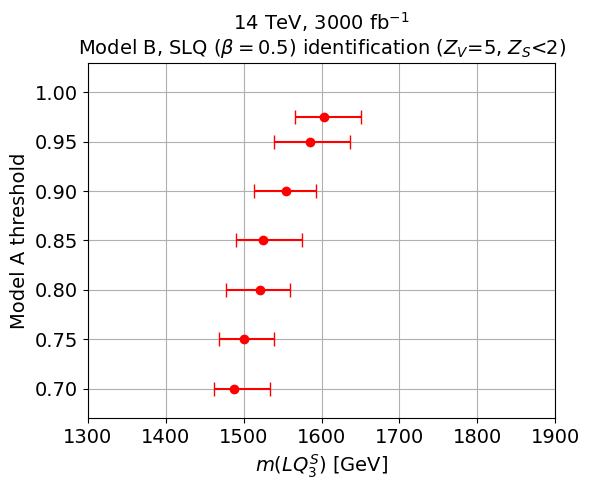

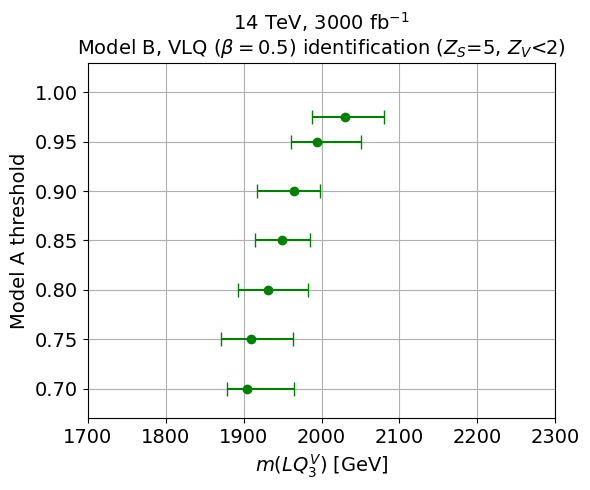

In [97]:
plt.figure(figsize=(6,5))

for ii_tt, th_it in enumerate(threshold_list):

    if th_it > 0.975:
        continue

    m5_inter_SLQ_err = [[save_m5_inter_SLQ[ii_tt] - save_m5_inter_SLQ_inf[ii_tt]], [save_m5_inter_SLQ_sup[ii_tt] - save_m5_inter_SLQ[ii_tt]]]
    plt.errorbar(save_m5_inter_SLQ[ii_tt], th_it, xerr=m5_inter_SLQ_err, fmt='o', capsize=5, color='red')

plt.ylim(0.67,1.03)
plt.xlim(1300,1900)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m(LQ_3^S)$ [GeV]",fontsize=14)
plt.ylabel(r"Model A threshold",fontsize=14)
plt.title(r'14 TeV, 3000 fb$^{-1}$' '\n' r'Model B, SLQ ($\beta=0.5$) identification ($Z_V$=5, $Z_S$<2)', fontsize=14)
plt.grid(True)
# plt.legend(fontsize=14, loc='upper left')
plt.tight_layout()
plt.savefig(mainfolder + 'saved-results/thresh_SLQ.pdf', bbox_inches='tight')
plt.show()



plt.figure(figsize=(6,5))

for ii_tt, th_it in enumerate(threshold_list):

    if th_it > 0.975:
        continue

    m5_inter_VLQ_err = [[save_m5_inter_VLQ[ii_tt] - save_m5_inter_VLQ_inf[ii_tt]], [save_m5_inter_VLQ_sup[ii_tt] - save_m5_inter_VLQ[ii_tt]]]
    plt.errorbar(save_m5_inter_VLQ[ii_tt], th_it, xerr=m5_inter_VLQ_err, fmt='o', capsize=5, color='green')


plt.ylim(0.67,1.03)
plt.xlim(1700,2300)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m(LQ_3^V)$ [GeV]",fontsize=14)
plt.ylabel(r"Model A threshold",fontsize=14)
plt.title(r'14 TeV, 3000 fb$^{-1}$' '\n' r'Model B, VLQ ($\beta=0.5$) identification ($Z_S$=5, $Z_V$<2)', fontsize=14)
plt.grid(True)
# plt.legend(fontsize=14, loc='upper left')
plt.tight_layout()
plt.savefig(mainfolder + 'saved-results/thresh_VLQ.pdf', bbox_inches='tight')
plt.show()

# FINAL JOINED PLOT

### Load exclusion and discovery limits

In [ ]:
# LOAD

file_path = mainfolder + 'saved-results/Z13TeV_err.txt'

loaded_data = np.loadtxt(file_path)

loaded_betas = loaded_data[:, 0]
m_asimov_exc_SLQ_13TeV = loaded_data[:, 1]
m_asimov_dis_SLQ_13TeV = loaded_data[:, 2]
m_asimov_exc_VLQ_13TeV = loaded_data[:, 3]
m_asimov_dis_VLQ_13TeV = loaded_data[:, 4]
m_BL_exc_SLQ_13TeV = loaded_data[:, 5]
m_BL_dis_SLQ_13TeV = loaded_data[:, 6]
m_BL_exc_VLQ_13TeV = loaded_data[:, 7]
m_BL_dis_VLQ_13TeV = loaded_data[:, 8]
m_BL_exc_SLQ_low_13TeV = loaded_data[:, 9]
m_BL_dis_SLQ_low_13TeV = loaded_data[:, 10]
m_BL_exc_VLQ_low_13TeV = loaded_data[:, 11]
m_BL_dis_VLQ_low_13TeV = loaded_data[:, 12]
m_BL_exc_SLQ_high_13TeV = loaded_data[:, 13]
m_BL_dis_SLQ_high_13TeV = loaded_data[:, 14]
m_BL_exc_VLQ_high_13TeV = loaded_data[:, 15]
m_BL_dis_VLQ_high_13TeV = loaded_data[:, 16]


# LOAD

file_path = mainfolder + 'saved-results/Z136TeV_err.txt'

loaded_data = np.loadtxt(file_path)

loaded_betas = loaded_data[:, 0]
m_asimov_exc_SLQ_136TeV = loaded_data[:, 1]
m_asimov_dis_SLQ_136TeV = loaded_data[:, 2]
m_asimov_exc_VLQ_136TeV = loaded_data[:, 3]
m_asimov_dis_VLQ_136TeV = loaded_data[:, 4]
m_BL_exc_SLQ_136TeV = loaded_data[:, 5]
m_BL_dis_SLQ_136TeV = loaded_data[:, 6]
m_BL_exc_VLQ_136TeV = loaded_data[:, 7]
m_BL_dis_VLQ_136TeV = loaded_data[:, 8]
m_BL_exc_SLQ_low_136TeV = loaded_data[:, 9]
m_BL_dis_SLQ_low_136TeV = loaded_data[:, 10]
m_BL_exc_VLQ_low_136TeV = loaded_data[:, 11]
m_BL_dis_VLQ_low_136TeV = loaded_data[:, 12]
m_BL_exc_SLQ_high_136TeV = loaded_data[:, 13]
m_BL_dis_SLQ_high_136TeV = loaded_data[:, 14]
m_BL_exc_VLQ_high_136TeV = loaded_data[:, 15]
m_BL_dis_VLQ_high_136TeV = loaded_data[:, 16]




# LOAD

file_path = mainfolder + 'saved-results/Z14TeV_err.txt'
# file_path = mainfolder + 'saved-results/Z14TeV_err_Z3.txt'

loaded_data = np.loadtxt(file_path)

loaded_betas = loaded_data[:, 0]
m_asimov_exc_SLQ_14TeV = loaded_data[:, 1]
m_asimov_dis_SLQ_14TeV = loaded_data[:, 2]
m_asimov_exc_VLQ_14TeV = loaded_data[:, 3]
m_asimov_dis_VLQ_14TeV = loaded_data[:, 4]
m_BL_exc_SLQ_14TeV = loaded_data[:, 5]
m_BL_dis_SLQ_14TeV = loaded_data[:, 6]
m_BL_exc_VLQ_14TeV = loaded_data[:, 7]
m_BL_dis_VLQ_14TeV = loaded_data[:, 8]
m_BL_exc_SLQ_low_14TeV = loaded_data[:, 9]
m_BL_dis_SLQ_low_14TeV = loaded_data[:, 10]
m_BL_exc_VLQ_low_14TeV = loaded_data[:, 11]
m_BL_dis_VLQ_low_14TeV = loaded_data[:, 12]
m_BL_exc_SLQ_high_14TeV = loaded_data[:, 13]
m_BL_dis_SLQ_high_14TeV = loaded_data[:, 14]
m_BL_exc_VLQ_high_14TeV = loaded_data[:, 15]
m_BL_dis_VLQ_high_14TeV = loaded_data[:, 16]


# this is to get the discovery evidence (Z=3)
file_path = mainfolder + 'saved-results/Z14TeV_err_Z3.txt'

loaded_data = np.loadtxt(file_path)

m_BL_dis_SLQ_14TeV_Z3 = loaded_data[:, 6]
m_BL_dis_VLQ_14TeV_Z3 = loaded_data[:, 8]

m_BL_dis_SLQ_low_14TeV_Z3 = loaded_data[:, 10]
m_BL_dis_VLQ_low_14TeV_Z3 = loaded_data[:, 12]

m_BL_dis_SLQ_high_14TeV_Z3 = loaded_data[:, 14]
m_BL_dis_VLQ_high_14TeV_Z3 = loaded_data[:, 16]


### Load the SLQ vs VLQ limits

In [ ]:
# Interpolate to find Z=5
def find_mass(mass_array, z_med, err_list, z_target=5.0):
    """Interpolate the mass and find the error, 1-sigma"""
    if np.max(z_med) < z_target and np.min(z_med) < z_target:
        return None, None, None # Z is not in this range

    # mass grid
    grid_masas = np.linspace(mass_array.min(), mass_array.max(), 5000)

    # curves
    z_sup_valores = z_med + err_list[1] # Median + err_sup (percentil 84)
    z_inf_valores = z_med - err_list[0] # Median - err_inf (percentil 16)

    f_med = interp1d(mass_array, z_med, kind='linear', bounds_error=False, fill_value="extrapolate")
    f_sup = interp1d(mass_array, z_sup_valores, kind='linear', bounds_error=False, fill_value="extrapolate")
    f_inf = interp1d(mass_array, z_inf_valores, kind='linear', bounds_error=False, fill_value="extrapolate")

    # search for Z = z_target
    m5_central = grid_masas[np.argmin(np.abs(f_med(grid_masas) - z_target))]
    m5_inf     = grid_masas[np.argmin(np.abs(f_inf(grid_masas) - z_target))]
    m5_sup     = grid_masas[np.argmin(np.abs(f_sup(grid_masas) - z_target))]

    return m5_central, m5_inf, m5_sup

In [ ]:
n_pseudo_TRUE = 1000
threshold_A = 0.95

print('n_pseudo_TRUE: ', n_pseudo_TRUE)
print('threshold_A: ', threshold_A)



beta_saved = ['_beta0', '_beta01', '_beta03', '_beta05', '_beta07', '_beta09', '_beta1']


m5_BPOK_SLQ_betas = []
m5_BPOK_SLQ_betas_low = []
m5_BPOK_SLQ_betas_high = []

m5_BPOK_VLQ_betas = []
m5_BPOK_VLQ_betas_low = []
m5_BPOK_VLQ_betas_high = []


m5_inter_SLQ_betas = []
m5_inter_SLQ_betas_low = []
m5_inter_SLQ_betas_high = []

m5_inter_VLQ_betas = []
m5_inter_VLQ_betas_low = []
m5_inter_VLQ_betas_high = []


m5_prev_SLQ_betas = []
m5_prev_SLQ_betas_low = []
m5_prev_SLQ_betas_high = []

m5_prev_VLQ_betas = []
m5_prev_VLQ_betas_low = []
m5_prev_VLQ_betas_high = []


print(' Z:       ', 5)

for im in range(len(beta_saved)):

    print('\n--------------------------')
    print('beta: ', beta_saved[im])

    # LOAD

    file_path = mainfolder + 'saved-results/vs14TeV_err' + beta_saved[im] + '.txt'

    loaded_data = np.loadtxt(file_path)

    S_expected = loaded_data[:, 0]
    mass_list_SLQ = loaded_data[:, 1]
    mass_list_VLQ = loaded_data[:, 2]
    mu_S = loaded_data[:, 3]
    sigma_S = loaded_data[:, 4]
    mu_V = loaded_data[:, 5]
    sigma_V = loaded_data[:, 6]
    mu_TSLQ = loaded_data[:, 7]
    std_TSLQ = loaded_data[:, 8]
    mu_TVLQ = loaded_data[:, 9]
    std_TVLQ = loaded_data[:, 10]
    classification_SLQ_BPOK = loaded_data[:, 11:15]
    classification_VLQ_BPOK = loaded_data[:, 15:19]
    classification_SLQ_inter = loaded_data[:, 19:23]
    classification_VLQ_inter = loaded_data[:, 23:27]
    classification_SLQ_prev = loaded_data[:, 27:31]
    classification_VLQ_prev = loaded_data[:, 31:35]
    z_BPOK_SLQ = loaded_data[:, 35]
    err_BPOK_SLQ = np.concatenate([loaded_data[:, 36], loaded_data[:, 37]])
    z_BPOK_VLQ = loaded_data[:, 38]
    err_BPOK_VLQ = np.concatenate([loaded_data[:, 39], loaded_data[:, 40]])
    z_inter_SLQ = loaded_data[:, 41]
    err_inter_SLQ = np.concatenate([loaded_data[:, 42], loaded_data[:, 43]])
    z_inter_VLQ = loaded_data[:, 44]
    err_inter_VLQ = np.concatenate([loaded_data[:, 45], loaded_data[:, 46]])
    z_prev_SLQ = loaded_data[:, 47]
    err_prev_SLQ = np.concatenate([loaded_data[:, 48], loaded_data[:, 49]])
    z_prev_VLQ = loaded_data[:, 50]
    err_prev_VLQ = np.concatenate([loaded_data[:, 51], loaded_data[:, 52]])



    # Compute the mass for which Z=5
    m5_BPOK_SLQ, m5_BPOK_SLQ_inf, m5_BPOK_SLQ_sup = find_mass(np.array(mass_list_SLQ), z_BPOK_SLQ, err_BPOK_SLQ)
    m5_BPOK_VLQ, m5_BPOK_VLQ_inf, m5_BPOK_VLQ_sup = find_mass(np.array(mass_list_VLQ), z_BPOK_VLQ, err_BPOK_VLQ)
    m5_inter_SLQ, m5_inter_SLQ_inf, m5_inter_SLQ_sup = find_mass(np.array(mass_list_SLQ), z_inter_SLQ, err_inter_SLQ)
    m5_inter_VLQ, m5_inter_VLQ_inf, m5_inter_VLQ_sup = find_mass(np.array(mass_list_VLQ), z_inter_VLQ, err_inter_VLQ)
    m5_prev_SLQ, m5_prev_SLQ_inf, m5_prev_SLQ_sup = find_mass(np.array(mass_list_SLQ), z_prev_SLQ, err_prev_SLQ)
    m5_prev_VLQ, m5_prev_VLQ_inf, m5_prev_VLQ_sup = find_mass(np.array(mass_list_VLQ), z_prev_VLQ, err_prev_VLQ)




    print('  Interpolated PDFs method ')
    print(' m_SLQ:   ', m5_inter_SLQ, '  (', m5_inter_SLQ_inf, '-', m5_inter_SLQ_sup, ')', ' [GeV]')
    print(' m_VLQ:   ', m5_inter_VLQ, '  (', m5_inter_VLQ_inf, '-', m5_inter_VLQ_sup, ')', ' [GeV]\n')



    m5_BPOK_SLQ_betas.append(m5_BPOK_SLQ)
    m5_BPOK_SLQ_betas_low.append(m5_BPOK_SLQ_inf)
    m5_BPOK_SLQ_betas_high.append(m5_BPOK_SLQ_sup)

    m5_BPOK_VLQ_betas.append(m5_BPOK_VLQ)
    m5_BPOK_VLQ_betas_low.append(m5_BPOK_VLQ_inf)
    m5_BPOK_VLQ_betas_high.append(m5_BPOK_VLQ_sup)


    m5_inter_SLQ_betas.append(m5_inter_SLQ)
    m5_inter_SLQ_betas_low.append(m5_inter_SLQ_inf)
    m5_inter_SLQ_betas_high.append(m5_inter_SLQ_sup)

    m5_inter_VLQ_betas.append(m5_inter_VLQ)
    m5_inter_VLQ_betas_low.append(m5_inter_VLQ_inf)
    m5_inter_VLQ_betas_high.append(m5_inter_VLQ_sup)


    m5_prev_SLQ_betas.append(m5_prev_SLQ)
    m5_prev_SLQ_betas_low.append(m5_prev_SLQ_inf)
    m5_prev_SLQ_betas_high.append(m5_prev_SLQ_sup)

    m5_prev_VLQ_betas.append(m5_prev_VLQ)
    m5_prev_VLQ_betas_low.append(m5_prev_VLQ_inf)
    m5_prev_VLQ_betas_high.append(m5_prev_VLQ_sup)



n_pseudo_TRUE:  1000
threshold_A:  0.95
 Z:        5

--------------------------
beta:  _beta0
  Interpolated PDFs method 
 m_SLQ:    1242.9885977195438   ( 1203.500700140028 - 1290.5981196239247 )  [GeV]
 m_VLQ:    1679.115823164633   ( 1629.6859371874375 - 1737.0874174834967 )  [GeV]


--------------------------
beta:  _beta01
  Interpolated PDFs method 
 m_SLQ:    1484.5369073814763   ( 1460.872174434887 - 1523.0446089217844 )  [GeV]
 m_VLQ:    1915.763152630526   ( 1857.371474294859 - 1989.5579115823166 )  [GeV]


--------------------------
beta:  _beta03
  Interpolated PDFs method 
 m_SLQ:    1559.3118623724745   ( 1530.1860372074416 - 1591.0982196439288 )  [GeV]
 m_VLQ:    1980.4560912182437   ( 1916.0432086417284 - 2049.2098419683934 )  [GeV]


--------------------------
beta:  _beta05
  Interpolated PDFs method 
 m_SLQ:    1577.5155031006202   ( 1548.9497899579915 - 1605.9411882376476 )  [GeV]
 m_VLQ:    1998.7997599519904   ( 1955.251050210042 - 2114.4628925785155 )  [GeV]


-

In [ ]:
# m5_BPOK_VLQ_betas_high[3] = np.float64(2084.602920584117)
# m5_inter_VLQ_betas_high[3] = np.float64(2084.4628925785155)
# m5_prev_VLQ_betas_high[3] = np.float64(2081.522304460892)


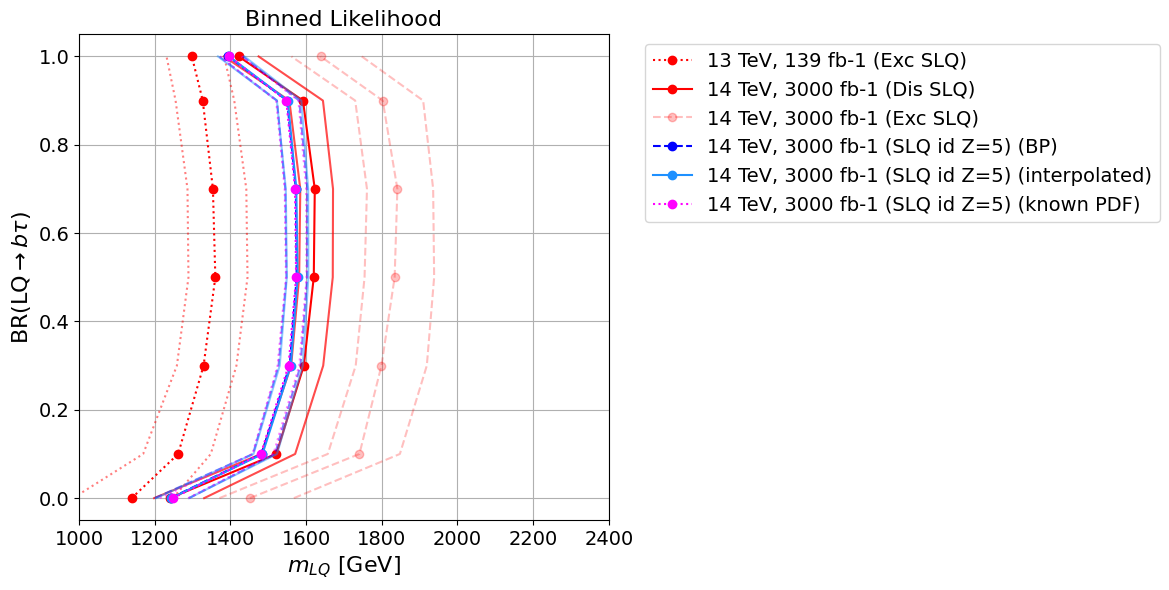

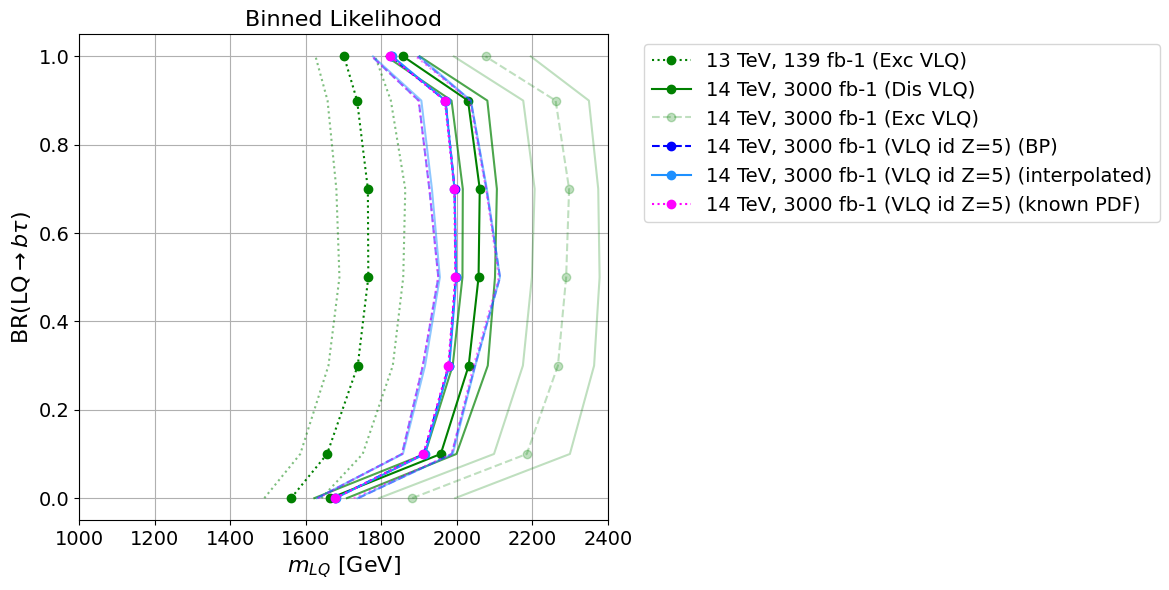

In [ ]:
betas = [0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]


# plot BINNED LIKEHOOD

plt.figure(figsize=(12, 6))

plt.plot(m_BL_exc_SLQ_13TeV, betas, 'o:', c='red', label='13 TeV, 139 fb-1 (Exc SLQ)')
plt.plot(m_BL_exc_SLQ_low_13TeV, betas, ':', c='red', alpha=0.5)
plt.plot(m_BL_exc_SLQ_high_13TeV, betas, ':', c='red', alpha=0.5)
plt.plot(m_BL_dis_SLQ_14TeV, betas, 'o-', c='red', label='14 TeV, 3000 fb-1 (Dis SLQ)')
plt.plot(m_BL_dis_SLQ_low_14TeV, betas, '-', c='red', alpha=0.7)
plt.plot(m_BL_dis_SLQ_high_14TeV, betas, '-', c='red', alpha=0.7)
plt.plot(m_BL_exc_SLQ_14TeV, betas, 'o--', c='red', alpha=0.25, label='14 TeV, 3000 fb-1 (Exc SLQ)')
plt.plot(m_BL_exc_SLQ_low_14TeV, betas, '--', c='red', alpha=0.25)
plt.plot(m_BL_exc_SLQ_high_14TeV, betas, '--', c='red', alpha=0.25)


# benchmarks
plt.plot(m5_BPOK_SLQ_betas, betas, 'o--', c='blue', label='14 TeV, 3000 fb-1 (SLQ id Z=5) (BP)')
plt.plot(m5_BPOK_SLQ_betas_low, betas, '--', c='blue', alpha=0.5)
plt.plot(m5_BPOK_SLQ_betas_high, betas, '--', c='blue', alpha=0.5)

# interpolated
plt.plot(m5_inter_SLQ_betas, betas, 'o-', c='dodgerblue', label='14 TeV, 3000 fb-1 (SLQ id Z=5) (interpolated)')
plt.plot(m5_inter_SLQ_betas_low, betas, '-', c='dodgerblue', alpha=0.5)
plt.plot(m5_inter_SLQ_betas_high, betas, '-', c='dodgerblue', alpha=0.5)

# known pdf
plt.plot(m5_prev_SLQ_betas, betas, 'o:', c='magenta', label='14 TeV, 3000 fb-1 (SLQ id Z=5) (known PDF)')
plt.plot(m5_prev_SLQ_betas_low, betas, ':', c='magenta', alpha=0.5)
plt.plot(m5_prev_SLQ_betas_high, betas, ':', c='magenta', alpha=0.5)


# plt.axhline(y=5, linestyle='--', color='black')
# plt.axhline(y=2, linestyle=':', color='black')
plt.xlim(1000,2400)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()





plt.figure(figsize=(12, 6))

plt.plot(m_BL_exc_VLQ_13TeV, betas, 'o:', c='green', label='13 TeV, 139 fb-1 (Exc VLQ)')
plt.plot(m_BL_exc_VLQ_low_13TeV, betas, ':', c='green', alpha=0.5)
plt.plot(m_BL_exc_VLQ_high_13TeV, betas, ':', c='green', alpha=0.5)
plt.plot(m_BL_dis_VLQ_14TeV, betas, 'o-', c='green', label='14 TeV, 3000 fb-1 (Dis VLQ)')
plt.plot(m_BL_dis_VLQ_low_14TeV, betas, '-', c='green', alpha=0.7)
plt.plot(m_BL_dis_VLQ_high_14TeV, betas, '-', c='green', alpha=0.7)
plt.plot(m_BL_exc_VLQ_14TeV, betas, 'o--', c='green', alpha=0.25, label='14 TeV, 3000 fb-1 (Exc VLQ)')
plt.plot(m_BL_exc_VLQ_low_14TeV, betas, '-', c='green', alpha=0.25)
plt.plot(m_BL_exc_VLQ_high_14TeV, betas, '-', c='green', alpha=0.25)


# benchmarks
plt.plot(m5_BPOK_VLQ_betas, betas, 'o--', c='blue', label='14 TeV, 3000 fb-1 (VLQ id Z=5) (BP)')
plt.plot(m5_BPOK_VLQ_betas_low, betas, '--', c='blue', alpha=0.5)
plt.plot(m5_BPOK_VLQ_betas_high, betas, '--', c='blue', alpha=0.5)

# interpolated
plt.plot(m5_inter_VLQ_betas, betas, 'o-', c='dodgerblue', label='14 TeV, 3000 fb-1 (VLQ id Z=5) (interpolated)')
plt.plot(m5_inter_VLQ_betas_low, betas, '-', c='dodgerblue', alpha=0.5)
plt.plot(m5_inter_VLQ_betas_high, betas, '-', c='dodgerblue', alpha=0.5)

# known pdf
plt.plot(m5_prev_VLQ_betas, betas, 'o:', c='magenta', label='14 TeV, 3000 fb-1 (VLQ id Z=5) (known PDF)')
plt.plot(m5_prev_VLQ_betas_low, betas, ':', c='magenta', alpha=0.5)
plt.plot(m5_prev_VLQ_betas_high, betas, ':', c='magenta', alpha=0.5)


# plt.axhline(y=5, linestyle='--', color='black')
# plt.axhline(y=2, linestyle=':', color='black')
plt.xlim(1000,2400)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
m5_inter_VLQ_betas_high[3] = np.float64(2084.4628925785155)

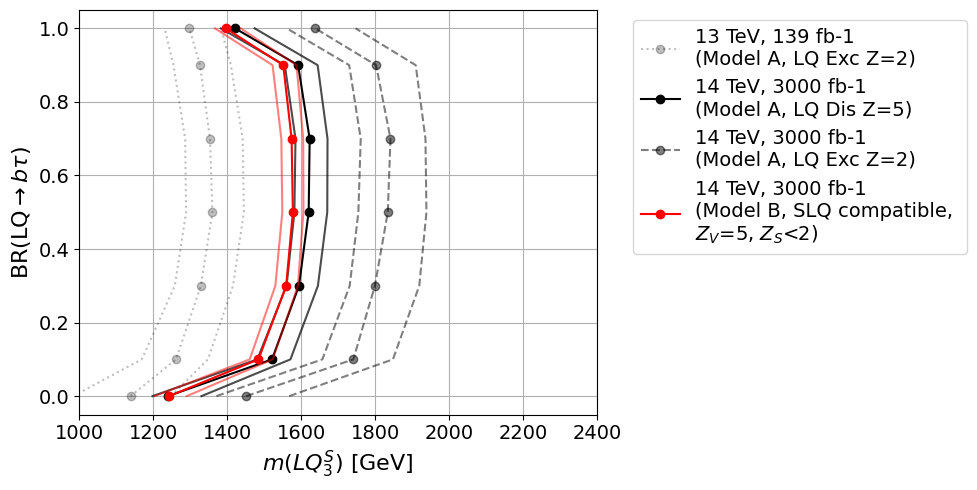

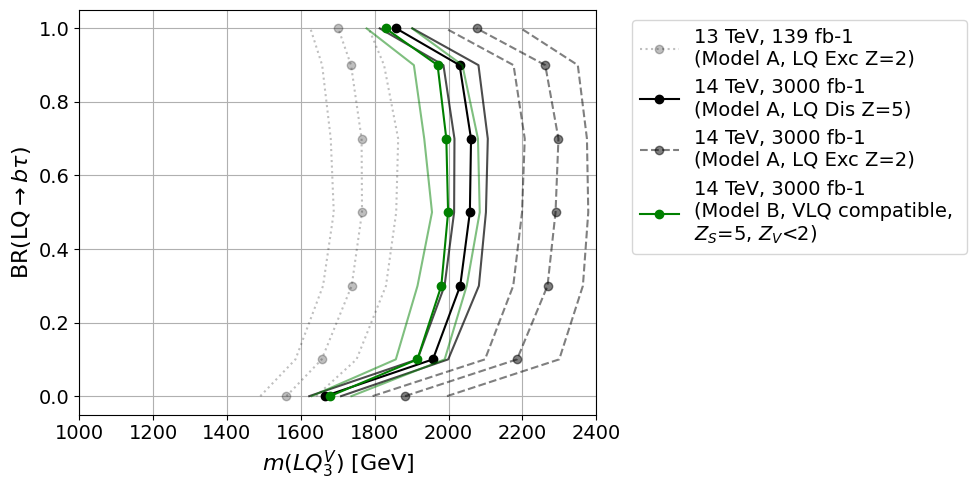

In [ ]:
betas = [0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]


# plot BINNED LIKEHOOD

plt.figure(figsize=(10, 5))

plt.plot(m_BL_exc_SLQ_13TeV, betas, 'o:', c='black', alpha=0.25, label='13 TeV, 139 fb-1 \n(Model A, LQ Exc Z=2)')
plt.plot(m_BL_exc_SLQ_low_13TeV, betas, ':', c='black', alpha=0.25)
plt.plot(m_BL_exc_SLQ_high_13TeV, betas, ':', c='black', alpha=0.25)
plt.plot(m_BL_dis_SLQ_14TeV, betas, 'o-', c='black', label='14 TeV, 3000 fb-1 \n(Model A, LQ Dis Z=5)')
plt.plot(m_BL_dis_SLQ_low_14TeV, betas, '-', c='black', alpha=0.7)
plt.plot(m_BL_dis_SLQ_high_14TeV, betas, '-', c='black', alpha=0.7)
plt.plot(m_BL_exc_SLQ_14TeV, betas, 'o--', c='black', alpha=0.5, label='14 TeV, 3000 fb-1 \n(Model A, LQ Exc Z=2)')
plt.plot(m_BL_exc_SLQ_low_14TeV, betas, '--', c='black', alpha=0.5)
plt.plot(m_BL_exc_SLQ_high_14TeV, betas, '--', c='black', alpha=0.5)


# # benchmarks
# plt.plot(m5_BPOK_SLQ_betas, betas, 'o--', c='blue', label='14 TeV, 3000 fb-1 (SLQ id Z=5) (BP)')
# plt.plot(m5_BPOK_SLQ_betas_low, betas, '--', c='blue', alpha=0.5)
# plt.plot(m5_BPOK_SLQ_betas_high, betas, '--', c='blue', alpha=0.5)

# interpolated
plt.plot(m5_inter_SLQ_betas, betas, 'o-', c='red', label='14 TeV, 3000 fb-1 \n(Model B, SLQ compatible, \n$Z_V$=5, $Z_S$<2)')
plt.plot(m5_inter_SLQ_betas_low, betas, '-', c='red', alpha=0.5)
plt.plot(m5_inter_SLQ_betas_high, betas, '-', c='red', alpha=0.5)

# # known pdf
# plt.plot(m5_prev_SLQ_betas, betas, 'o:', c='magenta', label='14 TeV, 3000 fb-1 (SLQ id Z=5) (known PDF)')
# plt.plot(m5_prev_SLQ_betas_low, betas, ':', c='magenta', alpha=0.5)
# plt.plot(m5_prev_SLQ_betas_high, betas, ':', c='magenta', alpha=0.5)


# plt.axhline(y=5, linestyle='--', color='black')
# plt.axhline(y=2, linestyle=':', color='black')
plt.xlim(1000,2400)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m(LQ_3^S)$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
# plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(mainfolder + 'saved-results/finalplot_SLQ.pdf', bbox_inches='tight')
plt.show()





plt.figure(figsize=(10, 5))

plt.plot(m_BL_exc_VLQ_13TeV, betas, 'o:', c='black', alpha=0.25, label='13 TeV, 139 fb-1 \n(Model A, LQ Exc Z=2)')
plt.plot(m_BL_exc_VLQ_low_13TeV, betas, ':', c='black', alpha=0.25)
plt.plot(m_BL_exc_VLQ_high_13TeV, betas, ':', c='black', alpha=0.25)
plt.plot(m_BL_dis_VLQ_14TeV, betas, 'o-', c='black', label='14 TeV, 3000 fb-1 \n(Model A, LQ Dis Z=5)')
plt.plot(m_BL_dis_VLQ_low_14TeV, betas, '-', c='black', alpha=0.7)
plt.plot(m_BL_dis_VLQ_high_14TeV, betas, '-', c='black', alpha=0.7)
plt.plot(m_BL_exc_VLQ_14TeV, betas, 'o--', c='black', alpha=0.5, label='14 TeV, 3000 fb-1 \n(Model A, LQ Exc Z=2)')
plt.plot(m_BL_exc_VLQ_low_14TeV, betas, '--', c='black', alpha=0.5)
plt.plot(m_BL_exc_VLQ_high_14TeV, betas, '--', c='black', alpha=0.5)


# # benchmarks
# plt.plot(m5_BPOK_VLQ_betas, betas, 'o--', c='blue', label='14 TeV, 3000 fb-1 (VLQ id Z=5) (BP)')
# plt.plot(m5_BPOK_VLQ_betas_low, betas, '--', c='blue', alpha=0.5)
# plt.plot(m5_BPOK_VLQ_betas_high, betas, '--', c='blue', alpha=0.5)

# interpolated
plt.plot(m5_inter_VLQ_betas, betas, 'o-', c='green', label='14 TeV, 3000 fb-1 \n(Model B, VLQ compatible, \n$Z_S$=5, $Z_V$<2)')
plt.plot(m5_inter_VLQ_betas_low, betas, '-', c='green', alpha=0.5)
plt.plot(m5_inter_VLQ_betas_high, betas, '-', c='green', alpha=0.5)

# # known pdf
# plt.plot(m5_prev_VLQ_betas, betas, 'o:', c='magenta', label='14 TeV, 3000 fb-1 (VLQ id Z=5) (known PDF)')
# plt.plot(m5_prev_VLQ_betas_low, betas, ':', c='magenta', alpha=0.5)
# plt.plot(m5_prev_VLQ_betas_high, betas, ':', c='magenta', alpha=0.5)


# plt.axhline(y=5, linestyle='--', color='black')
# plt.axhline(y=2, linestyle=':', color='black')
plt.xlim(1000,2400)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m(LQ_3^V)$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
# plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(mainfolder + 'saved-results/finalplot_VLQ.pdf', bbox_inches='tight')
plt.show()

In [ ]:
#######
# SLQ #
#######

# Expected ATLAS fig 9a https://www.hepdata.net/record/105998    https://arxiv.org/abs/2108.07665
beta_SLQ_05 = [0,0.0010521,0.0057888,0.010101,0.011322,0.017524,0.020202,0.024171,0.030303,0.030715,0.036537,0.040404,0.040997,0.044161,0.046326,0.048202,0.050505,0.050582,0.054423,0.060033,0.060606,0.067623,0.070707,0.076512,0.080808,0.086018,0.090909,0.095446,0.10101,0.10447,0.11111,0.11342,0.12121,0.12329,0.13131,0.13566,0.14141,0.15152,0.15223,0.16162,0.17172,0.17465,0.18182,0.19192,0.20202,0.20219,0.21212,0.22222,0.23232,0.23273,0.24242,0.25253,0.26263,0.26544,0.27273,0.28283,0.29293,0.30231,0.30303,0.31313,0.32323,0.33333,0.34343,0.34742,0.35354,0.36364,0.37374,0.38384,0.39394,0.40404,0.41214,0.41414,0.42424,0.43434,0.44444,0.45455,0.46465,0.47475,0.48485,0.49495,0.50505,0.51515,0.52525,0.53535,0.54545,0.55556,0.55654,0.56566,0.57576,0.58586,0.59596,0.60606,0.61616,0.62626,0.63636,0.64646,0.65657,0.66667,0.67677,0.68687,0.69697,0.70707,0.71717,0.72683,0.72727,0.73737,0.74747,0.75758,0.76768,0.77778,0.78788,0.79798,0.80808,0.81818,0.82828,0.83838,0.84848,0.85859,0.86424,0.86869,0.87879,0.88889,0.89899,0.90909,0.91919,0.92929,0.93939,0.9444,0.94949,0.9596,0.9697,0.9798,0.9899,1]
mass_SLQ_05 = [751.02,755.56,771.72,784.32,787.88,804.04,810.61,820.2,835.38,836.36,852.53,866.65,868.69,884.85,901.01,917.17,932.86,933.33,949.49,965.66,966.99,981.82,987.79,997.98,1005.7,1014.1,1023,1030.3,1040.7,1046.5,1058.9,1062.6,1075.8,1078.8,1089.8,1094.9,1101.1,1110.5,1111.1,1118.4,1125.4,1127.3,1131.9,1137.8,1143.3,1143.4,1149,1154.3,1159.4,1159.6,1164.6,1169.6,1174.5,1175.8,1179.1,1183.7,1188,1191.9,1192.2,1196.1,1199.8,1203.4,1206.8,1208.1,1210,1212.9,1215.6,1218.1,1220.5,1222.6,1224.2,1224.7,1226.6,1228.3,1229.9,1231.3,1232.7,1233.9,1235,1236,1236.9,1237.7,1238.5,1239.2,1239.8,1240.4,1240.4,1241,1241.5,1242,1242.4,1242.8,1243.1,1243.3,1243.4,1243.5,1243.5,1243.3,1243.1,1242.8,1242.3,1241.8,1241.1,1240.4,1240.4,1239.7,1238.9,1238,1237.1,1236.1,1235.1,1233.9,1232.7,1231.4,1230,1228.6,1227,1225.3,1224.2,1223.5,1221.8,1219.9,1217.9,1215.9,1213.8,1211.5,1209.2,1208.1,1206.8,1204.4,1201.8,1199.3,1196.7,1194.1]

beta_SLQ_05_plus = [0, 0.016415868673050615, 0.019151846785225718, 0.016415868673050615, 0.015047879616963064, 0.016415868673050615, 0.025991792065663474, 0.04377564979480164, 0.06566347469220246, 0.07934336525307797, 0.09302325581395349, 0.13816689466484267, 0.19151846785225718, 0.24350205198358413, 0.29958960328317374, 0.3652530779753762, 0.4377564979480164, 0.5116279069767442, 0.5882352941176471, 0.679890560875513, 0.7729138166894665, 0.8467852257181943, 0.9151846785225718, 0.9658002735978112, 1]
mass_SLQ_05_plus = [540.1840490797546, 583.1288343558282, 604.601226993865, 627.6073619631902, 667.4846625766871, 708.8957055214723, 757.9754601226994, 802.4539877300614, 853.0674846625767, 908.282208588957, 949.6932515337423, 1000.3067484662577, 1047.8527607361964, 1076.993865030675, 1106.1349693251534, 1127.6073619631902, 1146.0122699386502, 1156.7484662576687, 1161.3496932515336, 1164.4171779141104, 1159.8159509202455, 1149.079754601227, 1138.3435582822085, 1121.4723926380368, 1104.601226993865]

beta_SLQ_05_minus = [0, 0.016415868673050615, 0.025991792065663474, 0.027359781121751026, 0.03146374829001368, 0.0506155950752394, 0.06703146374829001, 0.08207934336525308, 0.11627906976744186, 0.15321477428180574, 0.2024623803009576, 0.25718194254445964, 0.30916552667578656, 0.36662106703146374, 0.41997264021887826, 0.4746922024623803, 0.533515731874145, 0.5950752393980848, 0.66484268125855, 0.7564979480164159, 0.8385772913816689, 0.9069767441860465, 0.945280437756498, 0.9712722298221614, 1]
mass_SLQ_05_minus = [805.5214723926381, 834.6625766871166, 869.9386503067485, 909.8159509202454, 952.760736196319, 1006.4417177914111, 1043.2515337423313, 1100, 1149.079754601227, 1188.9570552147238, 1221.1656441717791, 1245.7055214723928, 1265.644171779141, 1288.6503067484664, 1308.588957055215, 1317.7914110429447, 1325.4601226993864, 1330.0613496932515, 1334.6625766871166, 1333.128834355828, 1326.993865030675, 1314.723926380368, 1303.9877300613498, 1276.3803680981596, 1261.0429447852762]

f_SLQ_05_plus = interp1d(beta_SLQ_05_plus, mass_SLQ_05_plus, kind="linear")
f_SLQ_05_minus = interp1d(beta_SLQ_05_minus, mass_SLQ_05_minus, kind="linear")

# https://arxiv.org/pdf/2004.14060 fig 14, pag39
mass_SLQ_0 = [1234.1, 1228.3, 1224.2, 1222.2, 1215.9, 1209.5, 1208.1, 1202.9, 1196.1, 1191.9, 1188.9, 1181.4, 1175.8, 1173.6, 1165.3, 1159.6, 1156.5, 1147.1, 1143.4, 1137.3, 1127.3, 1127.0, 1116.3, 1111.1, 1104.5, 1094.9, 1092.3, 1078.8, 1078.2, 1064.5, 1062.6, 1051.9, 1046.5, 1042.3, 1032.1, 1030.3, 1021.8, 1014.1, 1009.4, 998.0, 991.2, 981.8, 965.7, 949.5, 949.3, 933.3, 930.1, 917.2, 913.0, 901.0, 891.9, 884.8, 868.7, 862.2, 852.5, 836.4, 829.0, 820.2, 804.0, 800.7, 787.9, 776.4, 771.7, 755.6, 753.9, 739.4, 733.1, 723.2, 714.3, 707.1, 697.2, 690.9, 682.3, 674.7, 667.1, 658.6, 650.7, 642.4, 632.6, 626.3, 611.8, 610.1, 593.9, 579.5, 577.8, 561.6, 545.5, 529.3, 517.2, 513.1, 497.0, 480.8, 473.2, 464.6, 448.5, 444.5, 432.3, 416.2, 413.9]
beta_SLQ_0_aux = [0.000000e+00,2.000000e+00,3.300000e+00,4.000000e+00,6.100000e+00,8.100000e+00,8.500000e+00,1.010000e+01,1.210000e+01,1.330000e+01,1.410000e+01,1.620000e+01,1.760000e+01,1.820000e+01,2.020000e+01,2.150000e+01,2.220000e+01,2.420000e+01,2.500000e+01,2.630000e+01,2.820000e+01,2.830000e+01,3.030000e+01,3.120000e+01,3.230000e+01,3.390000e+01,3.430000e+01,3.630000e+01,3.640000e+01,3.840000e+01,3.860000e+01,4.040000e+01,4.140000e+01,4.240000e+01,4.440000e+01,4.480000e+01,4.650000e+01,4.790000e+01,4.850000e+01,5.010000e+01,5.050000e+01,5.090000e+01,5.150000e+01,5.250000e+01,5.250000e+01,5.410000e+01,5.450000e+01,5.610000e+01,5.660000e+01,5.780000e+01,5.860000e+01,5.920000e+01,6.020000e+01,6.060000e+01,6.120000e+01,6.220000e+01,6.260000e+01,6.320000e+01,6.440000e+01,6.460000e+01,6.570000e+01,6.670000e+01,6.710000e+01,6.850000e+01,6.870000e+01,7.010000e+01,7.070000e+01,7.170000e+01,7.270000e+01,7.350000e+01,7.470000e+01,7.550000e+01,7.680000e+01,7.780000e+01,7.880000e+01,7.980000e+01,8.080000e+01,8.180000e+01,8.280000e+01,8.350000e+01,8.480000e+01,8.500000e+01,8.610000e+01,8.690000e+01,8.690000e+01,8.750000e+01,8.810000e+01,8.850000e+01,8.890000e+01,8.900000e+01,8.960000e+01,9.040000e+01,9.090000e+01,9.150000e+01,9.260000e+01,9.290000e+01,9.380000e+01,9.480000e+01, 9.490000e+01]
beta_SLQ_0 = [i/100 for i in beta_SLQ_0_aux]

mass_SLQ_0_minus_aux2 = [416.2, 416.2, 416.2, 416.2, 416.2, 416.2, 416.2, 416.2, 416.2, 416.2, 416.2, 416.2, 416.2, 416.2, 416.2, 416.2, 416.2, 432.3, 443.0, 448.5, 464.6, 480.8, 497.0, 497.7, 513.1, 529.3, 545.5, 547.2, 561.6, 577.8, 580.3, 593.9, 602.6, 610.1, 619.8, 626.3, 635.1, 642.4, 649.0, 658.6, 661.9, 674.2, 674.7, 686.2, 690.9, 698.1, 707.1, 711.4, 723.2, 725.4, 739.4, 740.8, 755.6, 757.5, 771.7, 775.7, 787.9, 796.3, 804.0, 820.2, 823.5, 836.4, 852.5, 859.1, 868.7, 884.8, 887.4, 901.0, 906.5, 917.2, 920.0, 932.4, 933.3, 946.5, 949.5, 965.7, 970.3, 981.8, 998.0, 1000.4, 1010.8, 1014.1, 1020.6, 1028.6, 1030.3, 1036.4, 1043.5, 1046.5, 1052.6, 1060.6, 1062.6, 1071.5, 1078.8, 1082.0, 1092.9, 1094.9, 1103.1, 1111.1, 1113.2, 1122.6, 1127.3, 1131.8, 1140.6, 1143.4, 1148.5, 1155.5]
beta_SLQ_0_minus_aux = [97, 97, 97, 97, 97, 97, 97, 97, 97, 97, 97, 97, 97, 97, 97, 97, 8.750000e+01, 8.720000e+01, 8.690000e+01, 8.670000e+01, 8.610000e+01, 8.550000e+01, 8.490000e+01, 8.480000e+01, 8.430000e+01, 8.360000e+01, 8.290000e+01, 8.280000e+01, 8.210000e+01, 8.100000e+01, 8.080000e+01, 7.970000e+01, 7.880000e+01, 7.800000e+01, 7.680000e+01, 7.590000e+01, 7.470000e+01, 7.370000e+01, 7.270000e+01, 7.120000e+01, 7.070000e+01, 6.870000e+01, 6.860000e+01, 6.670000e+01, 6.580000e+01, 6.460000e+01, 6.320000e+01, 6.260000e+01, 6.090000e+01, 6.060000e+01, 5.880000e+01, 5.860000e+01, 5.680000e+01, 5.660000e+01, 5.500000e+01, 5.450000e+01, 5.330000e+01, 5.250000e+01, 5.180000e+01, 5.070000e+01, 5.050000e+01, 4.980000e+01, 4.890000e+01, 4.850000e+01, 4.790000e+01, 4.670000e+01, 4.650000e+01, 4.520000e+01, 4.440000e+01, 4.290000e+01, 4.240000e+01, 4.040000e+01, 4.020000e+01, 3.840000e+01, 3.790000e+01, 3.660000e+01, 3.640000e+01, 3.580000e+01, 3.470000e+01, 3.430000e+01, 3.230000e+01, 3.180000e+01, 3.030000e+01, 2.830000e+01, 2.780000e+01, 2.630000e+01, 2.420000e+01, 2.350000e+01, 2.220000e+01, 2.020000e+01, 1.980000e+01, 1.820000e+01, 1.670000e+01, 1.620000e+01, 1.410000e+01, 1.370000e+01, 1.210000e+01,1.050000e+01,1.010000e+01,8.100000e+00,7.100000e+00,6.100000e+00,4.000000e+00,3.400000e+00,2.000000e+00,0.000000e+00]
beta_SLQ_0_minus_aux2 = [i/100 for i in beta_SLQ_0_minus_aux]
mass_SLQ_0_minus = mass_SLQ_0_minus_aux2[::-1]
beta_SLQ_0_minus = beta_SLQ_0_minus_aux2[::-1]


mass_SLQ_0_plus = [1311.7, 1305.9, 1305.1, 1299.8, 1293.1, 1288.9, 1286.1, 1278.8, 1272.7, 1271.3, 1263.8, 1256.6, 1256.1, 1248.9, 1241.0, 1240.4, 1233.6, 1225.7, 1224.2, 1217.7, 1209.3, 1208.1, 1200.5, 1191.9, 1191.1, 1181.2, 1175.8, 1170.8, 1159.8, 1159.6, 1148.4, 1143.4, 1136.8, 1127.3, 1124.8, 1112.1, 1111.1, 1097.8, 1094.9, 1081.3, 1078.8, 1063.9, 1062.6, 1047.7, 1046.5, 1036.0, 1030.3, 1022.9, 1014.1, 1007.7, 998.0, 981.8, 965.7, 964.1, 949.5, 933.3, 931.1, 917.2, 908.6, 901.0, 884.8, 879.0, 868.7, 852.5, 843.3, 836.4, 820.2, 813.8, 804.0, 787.9, 786.7, 771.7, 759.0, 755.6, 739.4, 732.8, 723.2, 708.9, 707.1, 690.9, 689.2, 674.7, 669.7, 658.6, 648.6, 642.4, 626.3, 624.5, 610.1, 593.9, 587.1, 577.8, 561.6, 545.5, 529.3, 513.1, 500.8, 497.0, 480.8, 467.2, 464.6, 448.5, 433.7, 432.3, 416.2, 404.7]
beta_SLQ_0_plus_aux = [0.000000e+00, 2.000000e+00, 2.300000e+00, 4.000000e+00, 6.100000e+00, 7.300000e+00, 8.100000e+00, 1.010000e+01, 1.170000e+01, 1.210000e+01, 1.410000e+01, 1.600000e+01, 1.620000e+01, 1.820000e+01, 2.020000e+01, 2.040000e+01, 2.220000e+01, 2.420000e+01, 2.460000e+01, 2.630000e+01, 2.830000e+01, 2.860000e+01, 3.030000e+01, 3.220000e+01, 3.230000e+01, 3.430000e+01, 3.540000e+01, 3.640000e+01, 3.840000e+01, 3.840000e+01, 4.040000e+01, 4.130000e+01, 4.240000e+01, 4.400000e+01, 4.440000e+01, 4.650000e+01, 4.660000e+01, 4.850000e+01, 4.890000e+01, 5.050000e+01, 5.080000e+01, 5.250000e+01, 5.270000e+01, 5.450000e+01, 5.470000e+01, 5.660000e+01, 5.750000e+01, 5.860000e+01, 5.990000e+01, 6.060000e+01, 6.160000e+01, 6.220000e+01, 6.260000e+01, 6.260000e+01, 6.320000e+01, 6.440000e+01, 6.460000e+01, 6.590000e+01, 6.670000e+01, 6.730000e+01, 6.840000e+01, 6.870000e+01, 6.930000e+01, 7.010000e+01, 7.070000e+01, 7.110000e+01, 7.230000e+01, 7.270000e+01, 7.350000e+01, 7.470000e+01, 7.470000e+01, 7.580000e+01, 7.680000e+01, 7.700000e+01, 7.820000e+01, 7.880000e+01, 7.950000e+01, 8.080000e+01, 8.100000e+01, 8.260000e+01, 8.280000e+01, 8.430000e+01, 8.480000e+01, 8.590000e+01, 8.690000e+01, 8.740000e+01, 8.880000e+01, 8.890000e+01, 8.990000e+01, 9.070000e+01, 9.090000e+01, 9.120000e+01, 9.150000e+01, 9.180000e+01, 9.210000e+01, 9.250000e+01, 9.290000e+01, 9.310000e+01, 9.400000e+01, 9.490000e+01, 9.510000e+01, 9.610000e+01, 9.700000e+01, 9.700000e+01, 9.750000e+01, 9.700000e+01]
beta_SLQ_0_plus = [i/100 for i in beta_SLQ_0_plus_aux]

f_SLQ_0_plus = interp1d(beta_SLQ_0_plus, mass_SLQ_0_plus, kind="linear")
f_SLQ_0_minus = interp1d(beta_SLQ_0_minus, mass_SLQ_0_minus, kind="linear")

# https://arxiv.org/pdf/2303.01294
mass_SLQ_1 = [814.6988092124291, 912.5301171484284, 976.6264868758564, 1097.2289167092142, 1185.7831295067142, 1252.4095809932119, 1301.3252671333557, 1345.1807254110713, 1408.4337345521428]
beta_SLQ_1 = [0.1, 0.17006369299073976, 0.20318469205750578, 0.3254776154267084, 0.46305731822474316, 0.58662420467284, 0.6757961775701453, 0.8121019172892858, 1]

mass_SLQ_1_minus = [702.530113931214, 807.1084352466429, 922.6505728732845, 1029.7590402920716, 1100.6023590546408, 1200.1204525076416, 1298.7951210299975, 1349.3975926871428]
beta_SLQ_1_minus = [0.1, 0.13949042570228765, 0.201910826168349, 0.31273876215566476, 0.39426753971802886, 0.5968152775707012, 0.810827978507826, 1]

mass_SLQ_1_plus = [878.795178939857, 929.3975862527141, 1033.975907568143, 1137.710803952927, 1205.1806803700697, 1309.7590016854986, 1404.2168672760713, 1461.5662879683582]
beta_SLQ_1_plus = [0.1, 0.13312099906676583, 0.19808913131114092, 0.30764329859903716, 0.4031846981318643, 0.5789809121481614, 0.8082802467295122, 1]

f_SLQ_1_plus = interp1d(beta_SLQ_1_plus, mass_SLQ_1_plus, kind="linear")
f_SLQ_1_minus = interp1d(beta_SLQ_1_minus, mass_SLQ_1_minus, kind="linear")

# Best limits, combination of different searches
# https://www.hepdata.net/record/ins2750164    https://arxiv.org/abs/2401.11928
beta_ATLAS_comb = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]

mass_Z95CL_ATLAS_comb = [1.236800e+03,1.228700e+03,1.224700e+03,1.228300e+03,1.237200e+03,1.248300e+03,1.259500e+03,1.271200e+03,1.283200e+03,1.296400e+03,1.310100e+03,1.324500e+03,1.337900e+03,1.350200e+03,1.362400e+03,1.375500e+03,1.387800e+03,1.399100e+03,1.409900e+03,1.421900e+03,1.434700e+03]
mass_Z95CL_ATLAS_minus1sig_comb = [1.313800e+03,1.303700e+03,1.299300e+03,1.303100e+03,1.312100e+03,1.323000e+03,1.334100e+03,1.345900e+03,1.357800e+03,1.370700e+03,1.384100e+03,1.397700e+03,1.410100e+03,1.422000e+03,1.433700e+03,1.446100e+03,1.457900e+03,1.469700e+03,1.481600e+03,1.494100e+03,1.507200e+03]
mass_Z95CL_ATLAS_plus1sig_comb = [1.164500e+03,1.144500e+03,1.141300e+03,1.145200e+03,1.154200e+03,1.166500e+03,1.178600e+03,1.190400e+03,1.202100e+03,1.215400e+03,1.228800e+03,1.243500e+03,1.257200e+03,1.270200e+03,1.282800e+03,1.296600e+03,1.309500e+03,1.321500e+03,1.333000e+03,1.345300e+03,1.358200e+03]




#######
# VLQ #
#######
# https://arxiv.org/abs/2108.07665
beta_VLQ_05 = [0.000000e+00,3.536700e-03,7.752700e-03,1.010100e-02,1.228100e-02,1.729200e-02,2.020200e-02,2.274100e-02,2.815300e-02,3.030300e-02,3.329600e-02,3.816700e-02,4.040400e-02,4.329900e-02,4.918200e-02,5.050500e-02,5.704400e-02,6.060600e-02,6.784400e-02,7.070700e-02,8.080800e-02,8.336300e-02,9.090900e-02,1.010100e-01,1.042200e-01,1.111100e-01,1.212100e-01,1.265100e-01,1.313100e-01,1.414100e-01,1.494100e-01,1.515200e-01,1.616200e-01,1.717200e-01,1.747600e-01,1.818200e-01,1.919200e-01,1.964900e-01,2.020200e-01,2.121200e-01,2.222200e-01,2.227000e-01,2.323200e-01,2.424200e-01,2.525300e-01,2.576100e-01,2.626300e-01,2.727300e-01,2.828300e-01,2.929300e-01,3.030300e-01,3.047700e-01,3.131300e-01,3.232300e-01,3.333300e-01,3.434300e-01,3.535400e-01,3.636400e-01,3.939400e-01,4.040400e-01,4.141400e-01,4.242400e-01,4.343400e-01,4.444400e-01,4.545500e-01,4.575600e-01,4.646500e-01,4.747500e-01,4.848500e-01,4.949500e-01,5.050500e-01,5.151500e-01,5.252500e-01,5.353500e-01,5.454500e-01,5.555600e-01,5.656600e-01,5.959600e-01,6.060600e-01,6.161600e-01,6.262600e-01,6.363600e-01,6.373400e-01,6.464600e-01,6.565700e-01,6.666700e-01,6.767700e-01,6.868700e-01,6.969700e-01,7.070700e-01,7.171700e-01,7.272700e-01,7.373700e-01,7.474700e-01,7.575800e-01,7.676800e-01,7.777800e-01,7.878800e-01,8.080800e-01,8.181800e-01,8.282800e-01,8.484800e-01,8.585900e-01,8.686900e-01,8.787900e-01,8.888900e-01,8.989900e-01,9.090900e-01,9.191900e-01,9.292900e-01,9.393900e-01,9.596000e-01,9.697000e-01,9.798000e-01,1.000000e+00 ]
mass_VLQ_05 = [1014.1, 1033.3, 1055.6, 1067.0, 1077.8, 1100.0, 1112.1, 1122.2, 1144.4, 1154.0, 1166.7, 1188.9, 1199.3, 1211.1, 1233.3, 1237.8, 1255.6, 1264.2, 1277.8, 1282.8, 1297.0, 1300.0, 1308.8, 1319.1, 1322.2, 1329.3, 1339.4, 1344.4, 1349.7, 1359.7, 1366.7, 1368.7, 1377.7, 1386.3, 1388.9, 1395.8, 1406.3, 1411.1, 1416.5, 1425.3, 1433.0, 1433.3, 1439.6, 1446.1, 1452.5, 1455.6, 1458.6, 1464.3, 1469.3, 1473.6, 1477.3, 1477.8, 1480.3, 1482.8, 1484.6, 1485.9, 1486.7, 1487.0, 1487.3, 1488.4, 1490.3, 1492.8, 1495.4, 1497.8, 1499.6, 1500.0, 1501.0, 1501.9, 1502.6, 1503.4, 1505.0, 1507.1, 1509.2, 1510.8, 1511.9, 1512.5, 1512.6, 1513.2, 1514.7, 1517.0, 1519.5, 1522.0, 1522.2, 1524.4, 1526.3, 1527.9, 1529.1, 1529.7, 1529.9, 1529.5, 1528.6, 1527.2, 1525.3, 1522.8, 1520.0, 1516.9, 1513.5, 1510.1, 1505.3, 1504.4, 1504.0, 1502.4, 1500.9, 1498.9, 1496.7, 1494.4, 1492.5, 1490.9, 1489.4, 1487.7, 1485.4, 1480.1, 1477.5, 1475.4, 1472.4]

mass_VLQ_05_minus = [953.2228284365883, 1112.3388641983497, 1213.9963252459424, 1287.6611358016505, 1346.5929842462167, 1390.7918705796415, 1412.8913137463537, 1417.3111349375479, 1430.5708233182913, 1432.0440970486893, 1440.8838518346583, 1451.1969927546056, 1436.464030643464, 1424.6776159931187, 1420.2577948019243, 1404.0514465568044, 1383.4253895240709]
beta_VLQ_05_minus = [0.0, 0.03977089154557309, 0.07643214011463248, 0.14058927516355357, 0.2230769346031383, 0.2911620962465534, 0.39459894782415383, 0.456137515019589, 0.5032733346841897, 0.5504092042957235, 0.6119476216503595, 0.686579377741755, 0.7677577782280631, 0.8450081770933439, 0.8895253789575257, 0.9445171893774488, 1]

mass_VLQ_05_plus = [1091.7126947620352, 1249.5763916511678, 1367.1270600239336, 1433.5173707790873, 1496.8691528184281, 1549.9077939378221, 1563.1674823185654, 1573.4805108349324, 1583.7936517548796, 1586.7401992156758, 1594.1066802712467, 1605.893094921592, 1600, 1582.3203780244817, 1570.5339633741362, 1557.2742749933927, 1542.541312882251]
beta_VLQ_05_plus = [0.0, 0.03977089154557309, 0.07643214011463248, 0.13797055746926873, 0.21653029020822526, 0.29378071404697226, 0.36972177903857706, 0.43911624958220175, 0.5019640257839802, 0.5595744664910552, 0.6158756482448539, 0.6957446898840197, 0.7468085111696482, 0.8410801504988497, 0.8986906661263241, 0.9523731551593043, 1]

f_VLQ_05_plus = interp1d(beta_VLQ_05_plus, mass_VLQ_05_plus, kind="linear")
f_VLQ_05_minus = interp1d(beta_VLQ_05_minus, mass_VLQ_05_minus, kind="linear")

# https://arxiv.org/pdf/2303.01294
mass_VLQ_1 = [1053.6035934445463, 1132.432416177941, 1195.4954743646565, 1267.2296910237214, 1341.3287964214362, 1398.8738610734617, 1452.4774244471987, 1493.4684483535352, 1530.518031123202, 1565.2026650126004, 1587.2747594345983]
beta_VLQ_1 = [0.1, 0.16399400682819215, 0.2021179965430534, 0.2933434691160599, 0.3900151517341909, 0.4744327059310949, 0.607866877692705, 0.6963691413633514, 0.8216338941774767, 0.9291981656905285, 1]

mass_VLQ_1_minus = [1012.6125996090193, 1085.9233987369144, 1143.4684633889399, 1221.5090099233241, 1301.126108855729, 1346.8467899561263, 1401.2386896704922, 1442.2297135768288, 1501.3513306268746, 1519.481923770584, 1532.8827995786137]
beta_VLQ_1_minus = [0.1, 0.16263245431691092, 0.2021179965430534, 0.294705021627341, 0.40090772764413685, 0.48260212487857956, 0.583358568910352, 0.704538612250735, 0.8692889592309017, 0.9468986469916021, 1]

mass_VLQ_1_plus = [1105.630604420263, 1164.7522214703088, 1242.0044918056828, 1302.7026612537493, 1398.0855247328327, 1450.9008720491784, 1502.1396068258848, 1540.7656818519529, 1588.8513118326186, 1614.0765110506572, 1635.3602691320264]
beta_VLQ_1_plus = [0.1, 0.1422088550083004, 0.2021179965430534, 0.2715583172961681, 0.37912247194444704, 0.48396372932975973, 0.5860817258728133, 0.6977307458145314, 0.8284417606136802, 0.9210287597280185, 1]

f_VLQ_1_plus = interp1d(beta_VLQ_1_plus, mass_VLQ_1_plus, kind="linear")
f_VLQ_1_minus = interp1d(beta_VLQ_1_minus, mass_VLQ_1_minus, kind="linear")


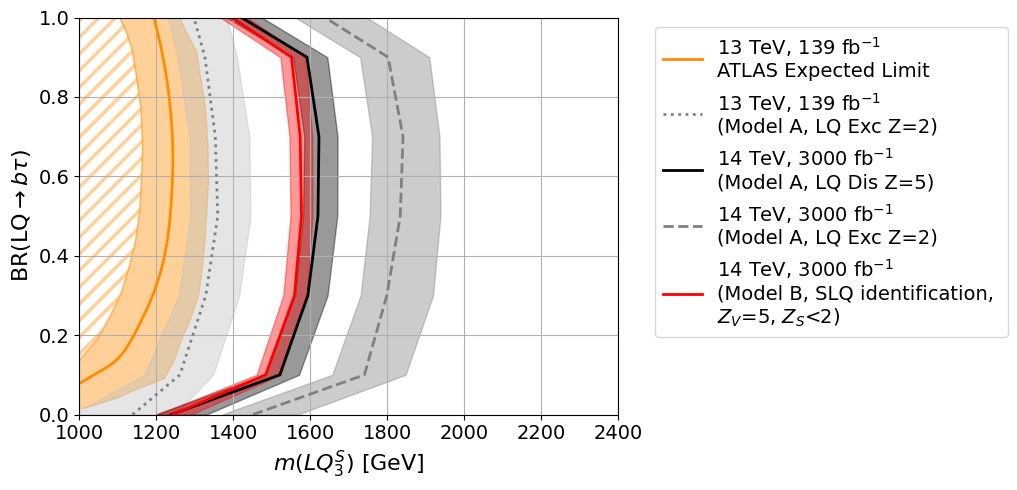

In [ ]:
lw = 2


data_Atlas_comb = pd.DataFrame({'ATLAS_beta': beta_ATLAS_comb,
                     'ATLAS_low':mass_Z95CL_ATLAS_plus1sig_comb,
                     'ATLAS_up':mass_Z95CL_ATLAS_minus1sig_comb})

data_Atlas_1 = pd.DataFrame({'ATLAS_beta_1_low': beta_SLQ_1_minus,
                           'ATLAS_beta_1_up': beta_SLQ_1_plus,
                     'ATLAS_low_1':mass_SLQ_1_minus,
                     'ATLAS_up_1':mass_SLQ_1_plus})

data_Atlas_05 = pd.DataFrame({'ATLAS_beta_05_low': beta_SLQ_05_minus,
                           'ATLAS_beta_05_up': beta_SLQ_05_plus,
                     'ATLAS_low_05':mass_SLQ_05_minus,
                     'ATLAS_up_05':mass_SLQ_05_plus})

data_Atlas_0 = pd.DataFrame({'ATLAS_beta_0_low': beta_SLQ_0_minus,
                           'ATLAS_low_0':mass_SLQ_0_minus})
data_Atlas_0B = pd.DataFrame({'ATLAS_beta_0_up': beta_SLQ_0_plus,
                     'ATLAS_up_0':mass_SLQ_0_plus})


data_LQ = pd.DataFrame({'BR': betas,
                      'SLQ_exc_13_low': m_BL_exc_SLQ_low_13TeV.tolist(),
                      'SLQ_exc_13_up': m_BL_exc_SLQ_high_13TeV.tolist(),
                      'SLQ_dis_14_low': m_BL_dis_SLQ_low_14TeV.tolist(),
                      'SLQ_dis_14_up': m_BL_dis_SLQ_high_14TeV.tolist(),
                      'SLQ_exc_14_low': m_BL_exc_SLQ_low_14TeV.tolist(),
                      'SLQ_exc_14_up': m_BL_exc_SLQ_high_14TeV.tolist(),
                      'SLQ_vs_14_low': m5_inter_SLQ_betas_low,
                      'SLQ_vs_14_up': m5_inter_SLQ_betas_high,
                    })

LQ_names = data_LQ.columns[1:]

fig = plt.figure(figsize=(15, 5))
gs = gridspec.GridSpec(nrows=1, ncols=2, wspace=0)

ax = fig.add_subplot(gs[0, 1])
for LQ_name in LQ_names[:-1]:
    ax.plot(data_LQ[LQ_name], data_LQ['BR'], linewidth=2, color='None')


plt.rcParams['hatch.linewidth'] = 2.5
# ax.fill_betweenx(data_Atlas_comb['ATLAS_beta'], 0, data_Atlas_comb['ATLAS_low'], facecolor='None', edgecolor='darkorange', alpha=0.4, hatch='//')
# ax.fill_betweenx(data_Atlas_comb['ATLAS_beta'], data_Atlas_comb['ATLAS_low'], data_Atlas_comb['ATLAS_up'], color='darkorange', alpha=0.4)

# ax.fill_betweenx(data_Atlas_1['ATLAS_beta_1_low'], 0, data_Atlas_1['ATLAS_low_1'], facecolor='None', edgecolor='darkorange', alpha=0.4, hatch='//')
# ax.fill_betweenx(data_Atlas_1['ATLAS_beta_1_up'], data_Atlas_1['ATLAS_low_1'], data_Atlas_1['ATLAS_up_1'], color='darkorange', alpha=0.4)

ax.fill_betweenx(data_Atlas_05['ATLAS_beta_05_up'], 0, data_Atlas_05['ATLAS_up_05'], facecolor='None', edgecolor='darkorange', alpha=0.4, hatch='//')
ax.fill_betweenx(data_Atlas_05['ATLAS_beta_05_up'], data_Atlas_05['ATLAS_low_05'], data_Atlas_05['ATLAS_up_05'], color='darkorange', alpha=0.4)

# ax.fill_betweenx(data_Atlas_0['ATLAS_beta_0_low'], 0, data_Atlas_0['ATLAS_low_0'], facecolor='None', edgecolor='darkorange', alpha=0.4, hatch='//')
# ax.fill_betweenx(data_Atlas_0B['ATLAS_beta_0_up'], data_Atlas_0['ATLAS_low_0'], data_Atlas_0B['ATLAS_up_0'], color='darkorange', alpha=0.4)

colors = [ "None", "silver", "None", "black", "None", "gray", "None", "red", "None"]
previous_curve = 0
previous_name = ''
for LQ_name, color in zip(LQ_names, colors):
    ax.fill_betweenx(data_LQ['BR'], previous_curve, data_LQ[LQ_name], color=color, alpha=0.4)
    previous_curve = data_LQ[LQ_name]
    previous_name = LQ_name




# plt.plot(mass_Z95CL_ATLAS_comb, beta_ATLAS_comb, '--', color='darkorange', lw=lw, label=r'ATLAS Expected Limit')
# plt.plot(mass_SLQ_1, beta_SLQ_1, '--', color='darkorange', lw=lw)
# plt.plot(mass_SLQ_1_minus, beta_SLQ_1_minus, '--', color='darkorange', lw=1)
# plt.plot(mass_SLQ_1_plus, beta_SLQ_1_plus, '--', color='darkorange', lw=1)
plt.plot(mass_SLQ_05, beta_SLQ_05, '-', color='darkorange', lw=lw, label='13 TeV, 139 fb$^{-1}$ \nATLAS Expected Limit')
# plt.plot(mass_SLQ_0, beta_SLQ_0, '--', color='darkorange', lw=lw)
# plt.plot(mass_SLQ_0_minus, beta_SLQ_0_minus, '--', color='darkorange', lw=1)
# plt.plot(mass_SLQ_0_plus, beta_SLQ_0_plus, '--', color='darkorange', lw=1)
plt.plot(m_BL_exc_SLQ_13TeV, betas, ':', color='gray', lw=lw, label='13 TeV, 139 fb$^{-1}$ \n(Model A, LQ Exc Z=2)')
plt.plot(m_BL_dis_SLQ_14TeV, betas, '-', color='black', lw=lw, label='14 TeV, 3000 fb$^{-1}$ \n(Model A, LQ Dis Z=5)')
plt.plot(m_BL_exc_SLQ_14TeV, betas, '--', color='gray', lw=lw, label='14 TeV, 3000 fb$^{-1}$ \n(Model A, LQ Exc Z=2)')
plt.plot(m5_inter_SLQ_betas, betas, '-', color='red', lw=lw, label='14 TeV, 3000 fb$^{-1}$ \n(Model B, SLQ identification, \n$Z_V$=5, $Z_S$<2)')


plt.xlim(1000,2400)
plt.ylim([0., 1])
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m(LQ_3^S)$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
# plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
# plt.savefig(mainfolder + 'saved-results/finalplot_SLQ_v2.pdf', bbox_inches='tight')
plt.show()

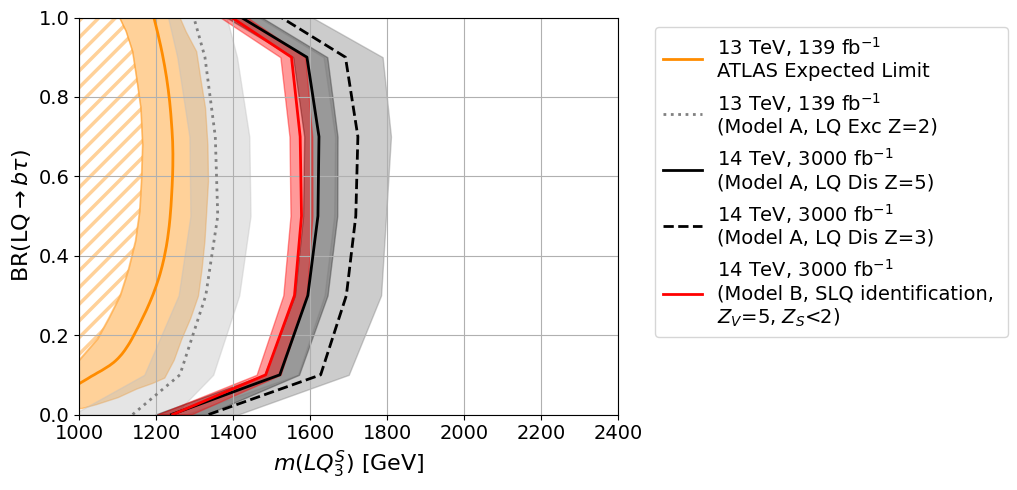

In [ ]:
lw = 2


data_Atlas_comb = pd.DataFrame({'ATLAS_beta': beta_ATLAS_comb,
                     'ATLAS_low':mass_Z95CL_ATLAS_plus1sig_comb,
                     'ATLAS_up':mass_Z95CL_ATLAS_minus1sig_comb})

data_Atlas_1 = pd.DataFrame({'ATLAS_beta_1_low': beta_SLQ_1_minus,
                           'ATLAS_beta_1_up': beta_SLQ_1_plus,
                     'ATLAS_low_1':mass_SLQ_1_minus,
                     'ATLAS_up_1':mass_SLQ_1_plus})

data_Atlas_05 = pd.DataFrame({'ATLAS_beta_05_low': beta_SLQ_05_minus,
                           'ATLAS_beta_05_up': beta_SLQ_05_plus,
                     'ATLAS_low_05':mass_SLQ_05_minus,
                     'ATLAS_up_05':mass_SLQ_05_plus})

data_Atlas_0 = pd.DataFrame({'ATLAS_beta_0_low': beta_SLQ_0_minus,
                           'ATLAS_low_0':mass_SLQ_0_minus})
data_Atlas_0B = pd.DataFrame({'ATLAS_beta_0_up': beta_SLQ_0_plus,
                     'ATLAS_up_0':mass_SLQ_0_plus})


data_LQ = pd.DataFrame({'BR': betas,
                      'SLQ_exc_13_low': m_BL_exc_SLQ_low_13TeV.tolist(),
                      'SLQ_exc_13_up': m_BL_exc_SLQ_high_13TeV.tolist(),
                      'SLQ_dis_14_low': m_BL_dis_SLQ_low_14TeV.tolist(),
                      'SLQ_dis_14_up': m_BL_dis_SLQ_high_14TeV.tolist(),
                      'SLQ_dis_14_low_Z3': m_BL_dis_SLQ_low_14TeV_Z3.tolist(),
                      'SLQ_dis_14_up_Z3': m_BL_dis_SLQ_high_14TeV_Z3.tolist(),
                      'SLQ_vs_14_low': m5_inter_SLQ_betas_low,
                      'SLQ_vs_14_up': m5_inter_SLQ_betas_high,
                    })

LQ_names = data_LQ.columns[1:]

fig = plt.figure(figsize=(15, 5))
gs = gridspec.GridSpec(nrows=1, ncols=2, wspace=0)

ax = fig.add_subplot(gs[0, 1])
for LQ_name in LQ_names[:-1]:
    ax.plot(data_LQ[LQ_name], data_LQ['BR'], linewidth=2, color='None')


plt.rcParams['hatch.linewidth'] = 2.5
# ax.fill_betweenx(data_Atlas_comb['ATLAS_beta'], 0, data_Atlas_comb['ATLAS_low'], facecolor='None', edgecolor='darkorange', alpha=0.4, hatch='//')
# ax.fill_betweenx(data_Atlas_comb['ATLAS_beta'], data_Atlas_comb['ATLAS_low'], data_Atlas_comb['ATLAS_up'], color='darkorange', alpha=0.4)

# ax.fill_betweenx(data_Atlas_1['ATLAS_beta_1_low'], 0, data_Atlas_1['ATLAS_low_1'], facecolor='None', edgecolor='darkorange', alpha=0.4, hatch='//')
# ax.fill_betweenx(data_Atlas_1['ATLAS_beta_1_up'], data_Atlas_1['ATLAS_low_1'], data_Atlas_1['ATLAS_up_1'], color='darkorange', alpha=0.4)

ax.fill_betweenx(data_Atlas_05['ATLAS_beta_05_up'], 0, data_Atlas_05['ATLAS_up_05'], facecolor='None', edgecolor='darkorange', alpha=0.4, hatch='//')
ax.fill_betweenx(data_Atlas_05['ATLAS_beta_05_up'], data_Atlas_05['ATLAS_low_05'], data_Atlas_05['ATLAS_up_05'], color='darkorange', alpha=0.4)

# ax.fill_betweenx(data_Atlas_0['ATLAS_beta_0_low'], 0, data_Atlas_0['ATLAS_low_0'], facecolor='None', edgecolor='darkorange', alpha=0.4, hatch='//')
# ax.fill_betweenx(data_Atlas_0B['ATLAS_beta_0_up'], data_Atlas_0['ATLAS_low_0'], data_Atlas_0B['ATLAS_up_0'], color='darkorange', alpha=0.4)

colors = [ "None", "silver", "None", "black", "None", "grey", "None", "red", "None"]
previous_curve = 0
previous_name = ''
for LQ_name, color in zip(LQ_names, colors):
    ax.fill_betweenx(data_LQ['BR'], previous_curve, data_LQ[LQ_name], color=color, alpha=0.4)
    previous_curve = data_LQ[LQ_name]
    previous_name = LQ_name




# plt.plot(mass_Z95CL_ATLAS_comb, beta_ATLAS_comb, '--', color='darkorange', lw=lw, label=r'ATLAS Expected Limit')
# plt.plot(mass_SLQ_1, beta_SLQ_1, '--', color='darkorange', lw=lw)
# plt.plot(mass_SLQ_1_minus, beta_SLQ_1_minus, '--', color='darkorange', lw=1)
# plt.plot(mass_SLQ_1_plus, beta_SLQ_1_plus, '--', color='darkorange', lw=1)
plt.plot(mass_SLQ_05, beta_SLQ_05, '-', color='darkorange', lw=lw, label='13 TeV, 139 fb$^{-1}$ \nATLAS Expected Limit')
# plt.plot(mass_SLQ_0, beta_SLQ_0, '--', color='darkorange', lw=lw)
# plt.plot(mass_SLQ_0_minus, beta_SLQ_0_minus, '--', color='darkorange', lw=1)
# plt.plot(mass_SLQ_0_plus, beta_SLQ_0_plus, '--', color='darkorange', lw=1)
plt.plot(m_BL_exc_SLQ_13TeV, betas, ':', color='gray', lw=lw, label='13 TeV, 139 fb$^{-1}$ \n(Model A, LQ Exc Z=2)')
plt.plot(m_BL_dis_SLQ_14TeV, betas, '-', color='black', lw=lw, label='14 TeV, 3000 fb$^{-1}$ \n(Model A, LQ Dis Z=5)')
plt.plot(m_BL_dis_SLQ_14TeV_Z3, betas, '--', color='black', lw=lw, label='14 TeV, 3000 fb$^{-1}$ \n(Model A, LQ Dis Z=3)')
plt.plot(m5_inter_SLQ_betas, betas, '-', color='red', lw=lw, label='14 TeV, 3000 fb$^{-1}$ \n(Model B, SLQ identification, \n$Z_V$=5, $Z_S$<2)')


plt.xlim(1000,2400)
plt.ylim([0., 1])
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m(LQ_3^S)$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
# plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(mainfolder + 'saved-results/finalplot_SLQ_v3.pdf', bbox_inches='tight')
plt.show()

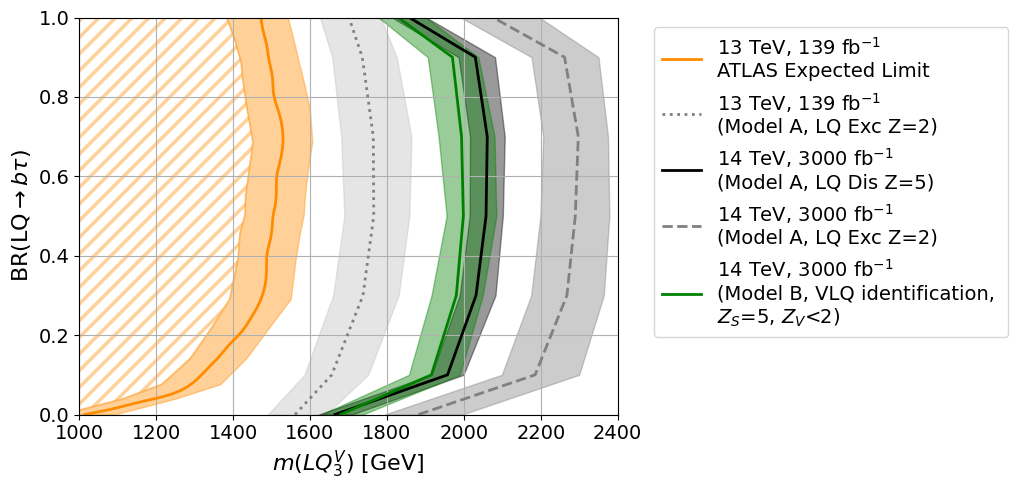

In [ ]:
lw = 2


data_Atlas_05 = pd.DataFrame({'ATLAS_beta_05_low': beta_VLQ_05_minus,
                           'ATLAS_beta_05_up': beta_VLQ_05_plus,
                     'ATLAS_low_05':mass_VLQ_05_minus,
                     'ATLAS_up_05':mass_VLQ_05_plus})

data_Atlas_1 = pd.DataFrame({'ATLAS_beta_1_low': beta_VLQ_1_minus,
                           'ATLAS_beta_1_up': beta_VLQ_1_plus,
                     'ATLAS_low_1':mass_VLQ_1_minus,
                     'ATLAS_up_1':mass_VLQ_1_plus})


data_LQ = pd.DataFrame({'BR': betas,
                      'VLQ_exc_13_low': m_BL_exc_VLQ_low_13TeV.tolist(),
                      'VLQ_exc_13_up': m_BL_exc_VLQ_high_13TeV.tolist(),
                      'VLQ_dis_14_low': m_BL_dis_VLQ_low_14TeV.tolist(),
                      'VLQ_dis_14_up': m_BL_dis_VLQ_high_14TeV.tolist(),
                      'VLQ_exc_14_low': m_BL_exc_VLQ_low_14TeV.tolist(),
                      'VLQ_exc_14_up': m_BL_exc_VLQ_high_14TeV.tolist(),
                      'VLQ_vs_14_low': m5_inter_VLQ_betas_low,
                      'VLQ_vs_14_up': m5_inter_VLQ_betas_high,
                    })

LQ_names = data_LQ.columns[1:]

fig = plt.figure(figsize=(15, 5))
gs = gridspec.GridSpec(nrows=1, ncols=2, wspace=0)

ax = fig.add_subplot(gs[0, 1])
for LQ_name in LQ_names[:-1]:
    ax.plot(data_LQ[LQ_name], data_LQ['BR'], linewidth=2, color='None')


plt.rcParams['hatch.linewidth'] = 2.5
ax.fill_betweenx(data_Atlas_05['ATLAS_beta_05_low'], 0, data_Atlas_05['ATLAS_low_05'], facecolor='None', edgecolor='darkorange', alpha=0.4, hatch='//')
ax.fill_betweenx(data_Atlas_05['ATLAS_beta_05_low'], data_Atlas_05['ATLAS_low_05'], data_Atlas_05['ATLAS_up_05'], color='darkorange', alpha=0.4)

# ax.fill_betweenx(data_Atlas_1['ATLAS_beta_1_low'], 0, data_Atlas_1['ATLAS_low_1'], facecolor='None', edgecolor='darkorange', alpha=0.4, hatch='//')
# ax.fill_betweenx(data_Atlas_1['ATLAS_beta_1_up'], data_Atlas_1['ATLAS_low_1'], data_Atlas_1['ATLAS_up_1'], color='darkorange', alpha=0.4)

colors = [ "None", "silver", "None", "black", "None", "gray", "None", "green", "None"]
previous_curve = 0
previous_name = ''
for LQ_name, color in zip(LQ_names, colors):
    ax.fill_betweenx(data_LQ['BR'], previous_curve, data_LQ[LQ_name], color=color, alpha=0.4)
    previous_curve = data_LQ[LQ_name]
    previous_name = LQ_name




plt.plot(mass_VLQ_05, beta_VLQ_05, '-', color='darkorange', lw=lw, label='13 TeV, 139 fb$^{-1}$ \nATLAS Expected Limit')
# plt.plot(mass_VLQ_1, beta_VLQ_1, '--', color='darkorange', lw=lw)
# plt.plot(mass_VLQ_1_minus, beta_VLQ_1_minus, '--', color='darkorange', lw=1)
# plt.plot(mass_VLQ_1_plus, beta_VLQ_1_plus, '--', color='darkorange', lw=1)
plt.plot(m_BL_exc_VLQ_13TeV, betas, ':', color='gray', lw=lw, label='13 TeV, 139 fb$^{-1}$ \n(Model A, LQ Exc Z=2)')
plt.plot(m_BL_dis_VLQ_14TeV, betas, '-', color='black', lw=lw, label='14 TeV, 3000 fb$^{-1}$ \n(Model A, LQ Dis Z=5)')
plt.plot(m_BL_exc_VLQ_14TeV, betas, '--', color='gray', lw=lw, label='14 TeV, 3000 fb$^{-1}$ \n(Model A, LQ Exc Z=2)')
plt.plot(m5_inter_VLQ_betas, betas, '-', color='green', lw=lw, label='14 TeV, 3000 fb$^{-1}$ \n(Model B, VLQ identification, \n$Z_S$=5, $Z_V$<2)')



plt.xlim(1000,2400)
plt.ylim([0., 1])
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m(LQ_3^V)$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
# plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(mainfolder + 'saved-results/finalplot_VLQ_v2.pdf', bbox_inches='tight')
plt.show()

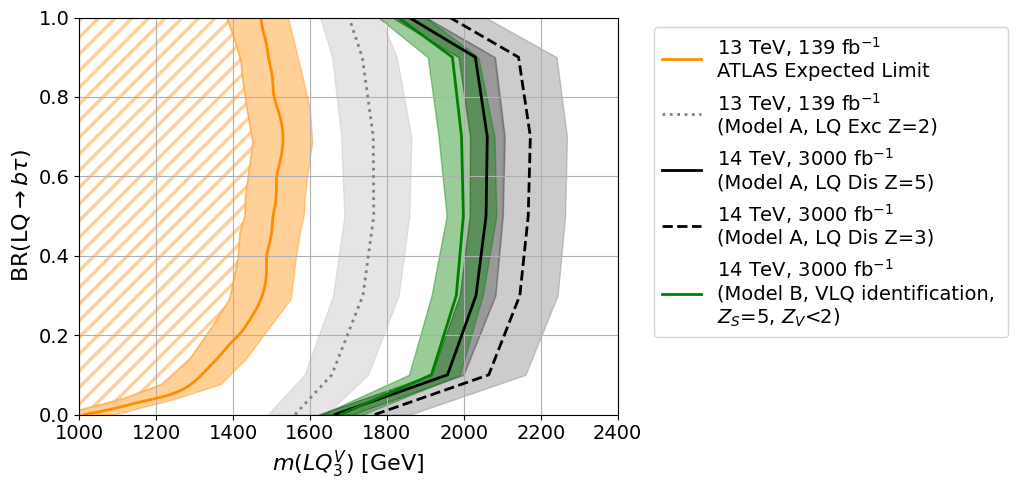

In [ ]:
lw = 2


data_Atlas_05 = pd.DataFrame({'ATLAS_beta_05_low': beta_VLQ_05_minus,
                           'ATLAS_beta_05_up': beta_VLQ_05_plus,
                     'ATLAS_low_05':mass_VLQ_05_minus,
                     'ATLAS_up_05':mass_VLQ_05_plus})

data_Atlas_1 = pd.DataFrame({'ATLAS_beta_1_low': beta_VLQ_1_minus,
                           'ATLAS_beta_1_up': beta_VLQ_1_plus,
                     'ATLAS_low_1':mass_VLQ_1_minus,
                     'ATLAS_up_1':mass_VLQ_1_plus})


data_LQ = pd.DataFrame({'BR': betas,
                      'VLQ_exc_13_low': m_BL_exc_VLQ_low_13TeV.tolist(),
                      'VLQ_exc_13_up': m_BL_exc_VLQ_high_13TeV.tolist(),
                      'VLQ_dis_14_low': m_BL_dis_VLQ_low_14TeV.tolist(),
                      'VLQ_dis_14_up': m_BL_dis_VLQ_high_14TeV.tolist(),
                      'VLQ_dis_14_low_Z3': m_BL_dis_VLQ_low_14TeV_Z3.tolist(),
                      'VLQ_dis_14_up_Z3': m_BL_dis_VLQ_high_14TeV_Z3.tolist(),
                      'VLQ_vs_14_low': m5_inter_VLQ_betas_low,
                      'VLQ_vs_14_up': m5_inter_VLQ_betas_high,
                    })

LQ_names = data_LQ.columns[1:]

fig = plt.figure(figsize=(15, 5))
gs = gridspec.GridSpec(nrows=1, ncols=2, wspace=0)

ax = fig.add_subplot(gs[0, 1])
for LQ_name in LQ_names[:-1]:
    ax.plot(data_LQ[LQ_name], data_LQ['BR'], linewidth=2, color='None')


plt.rcParams['hatch.linewidth'] = 2.5
ax.fill_betweenx(data_Atlas_05['ATLAS_beta_05_low'], 0, data_Atlas_05['ATLAS_low_05'], facecolor='None', edgecolor='darkorange', alpha=0.4, hatch='//')
ax.fill_betweenx(data_Atlas_05['ATLAS_beta_05_low'], data_Atlas_05['ATLAS_low_05'], data_Atlas_05['ATLAS_up_05'], color='darkorange', alpha=0.4)

# ax.fill_betweenx(data_Atlas_1['ATLAS_beta_1_low'], 0, data_Atlas_1['ATLAS_low_1'], facecolor='None', edgecolor='darkorange', alpha=0.4, hatch='//')
# ax.fill_betweenx(data_Atlas_1['ATLAS_beta_1_up'], data_Atlas_1['ATLAS_low_1'], data_Atlas_1['ATLAS_up_1'], color='darkorange', alpha=0.4)

colors = [ "None", "silver", "None", "black", "None", "gray", "None", "green", "None"]
previous_curve = 0
previous_name = ''
for LQ_name, color in zip(LQ_names, colors):
    ax.fill_betweenx(data_LQ['BR'], previous_curve, data_LQ[LQ_name], color=color, alpha=0.4)
    previous_curve = data_LQ[LQ_name]
    previous_name = LQ_name




plt.plot(mass_VLQ_05, beta_VLQ_05, '-', color='darkorange', lw=lw, label='13 TeV, 139 fb$^{-1}$ \nATLAS Expected Limit')
# plt.plot(mass_VLQ_1, beta_VLQ_1, '--', color='darkorange', lw=lw)
# plt.plot(mass_VLQ_1_minus, beta_VLQ_1_minus, '--', color='darkorange', lw=1)
# plt.plot(mass_VLQ_1_plus, beta_VLQ_1_plus, '--', color='darkorange', lw=1)
plt.plot(m_BL_exc_VLQ_13TeV, betas, ':', color='gray', lw=lw, label='13 TeV, 139 fb$^{-1}$ \n(Model A, LQ Exc Z=2)')
plt.plot(m_BL_dis_VLQ_14TeV, betas, '-', color='black', lw=lw, label='14 TeV, 3000 fb$^{-1}$ \n(Model A, LQ Dis Z=5)')
plt.plot(m_BL_dis_VLQ_14TeV_Z3, betas, '--', color='black', lw=lw, label='14 TeV, 3000 fb$^{-1}$ \n(Model A, LQ Dis Z=3)')
plt.plot(m5_inter_VLQ_betas, betas, '-', color='green', lw=lw, label='14 TeV, 3000 fb$^{-1}$ \n(Model B, VLQ identification, \n$Z_S$=5, $Z_V$<2)')



plt.xlim(1000,2400)
plt.ylim([0., 1])
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m(LQ_3^V)$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
# plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(mainfolder + 'saved-results/finalplot_VLQ_v3.pdf', bbox_inches='tight')
plt.show()

## Exclusions only

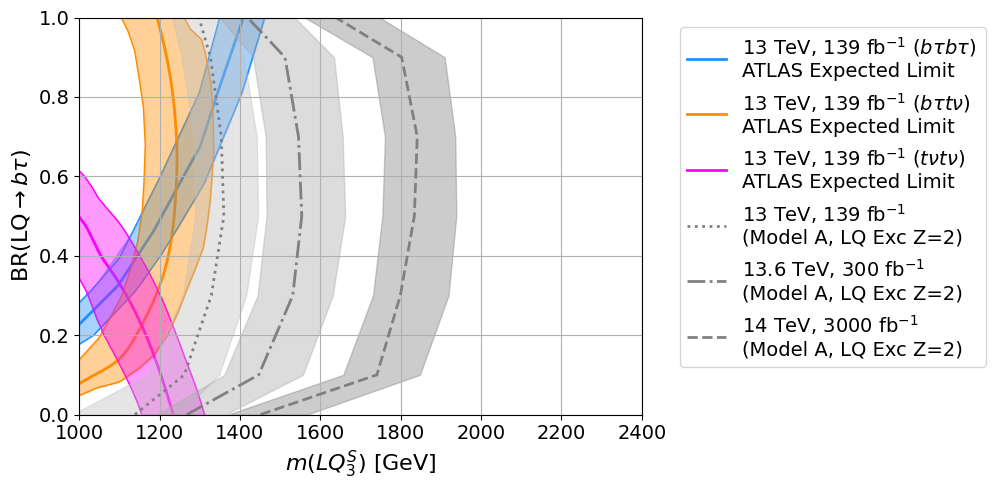

In [ ]:
lw = 2


data_Atlas_comb = pd.DataFrame({'ATLAS_beta': beta_ATLAS_comb,
                     'ATLAS_low':mass_Z95CL_ATLAS_plus1sig_comb,
                     'ATLAS_up':mass_Z95CL_ATLAS_minus1sig_comb})

data_Atlas_1 = pd.DataFrame({'ATLAS_beta_1_low': beta_SLQ_1_minus,
                           'ATLAS_beta_1_up': beta_SLQ_1_plus,
                     'ATLAS_low_1':mass_SLQ_1_minus,
                     'ATLAS_up_1':mass_SLQ_1_plus})

data_Atlas_05 = pd.DataFrame({'ATLAS_beta_05_low': beta_SLQ_05_minus,
                           'ATLAS_beta_05_up': beta_SLQ_05_plus,
                     'ATLAS_low_05':mass_SLQ_05_minus,
                     'ATLAS_up_05':mass_SLQ_05_plus})

data_Atlas_0 = pd.DataFrame({'ATLAS_beta_0_low': beta_SLQ_0_minus,
                           'ATLAS_low_0':mass_SLQ_0_minus})
data_Atlas_0B = pd.DataFrame({'ATLAS_beta_0_up': beta_SLQ_0_plus,
                     'ATLAS_up_0':mass_SLQ_0_plus})


data_LQ = pd.DataFrame({'BR': betas,
                      'SLQ_exc_13_low': m_BL_exc_SLQ_low_13TeV.tolist(),
                      'SLQ_exc_13_up': m_BL_exc_SLQ_high_13TeV.tolist(),
                      'SLQ_exc_136_low': m_BL_exc_SLQ_low_136TeV.tolist(),
                      'SLQ_exc_136_up': m_BL_exc_SLQ_high_136TeV.tolist(),
                      'SLQ_exc_14_low': m_BL_exc_SLQ_low_14TeV.tolist(),
                      'SLQ_exc_14_up': m_BL_exc_SLQ_high_14TeV.tolist(),
                    })

LQ_names = data_LQ.columns[1:]

fig = plt.figure(figsize=(15, 5))
gs = gridspec.GridSpec(nrows=1, ncols=2, wspace=0)

ax = fig.add_subplot(gs[0, 1])
for LQ_name in LQ_names[:-1]:
    ax.plot(data_LQ[LQ_name], data_LQ['BR'], linewidth=2, color='None')


# plt.rcParams['hatch.linewidth'] = 2.5
# ax.fill_betweenx(data_Atlas_comb['ATLAS_beta'], 0, data_Atlas_comb['ATLAS_low'], facecolor='None', edgecolor='darkorange', alpha=0.4, hatch='//')
# ax.fill_betweenx(data_Atlas_comb['ATLAS_beta'], data_Atlas_comb['ATLAS_low'], data_Atlas_comb['ATLAS_up'], color='darkorange', alpha=0.4)

# ax.fill_betweenx(data_Atlas_1['ATLAS_beta_1_low'], 0, data_Atlas_1['ATLAS_low_1'], facecolor='None', edgecolor='darkorange', alpha=0.4, hatch='//')
ax.fill_betweenx(y=beta_SLQ_1,  # Variable sobre el eje Y
    x1=f_SLQ_1_minus(beta_SLQ_1),  # Límite izquierdo en el eje X
    x2=f_SLQ_1_plus(beta_SLQ_1),  # Límite derecho en el eje X
    color="dodgerblue", alpha=0.4)

# ax.fill_betweenx(data_Atlas_05['ATLAS_beta_05_up'], 0, data_Atlas_05['ATLAS_up_05'], facecolor='None', edgecolor='darkorange', alpha=0.4, hatch='//')
ax.fill_betweenx(y=beta_SLQ_05,  # Variable sobre el eje Y
    x1=f_SLQ_05_minus(beta_SLQ_05),  # Límite izquierdo en el eje X
    x2=f_SLQ_05_plus(beta_SLQ_05),  # Límite derecho en el eje X
    color="darkorange", alpha=0.4)

# ax.fill_betweenx(data_Atlas_0['ATLAS_beta_0_low'], 0, data_Atlas_0['ATLAS_low_0'], facecolor='None', edgecolor='darkorange', alpha=0.4, hatch='//')
ax.fill_betweenx(y=beta_SLQ_0,  # Variable sobre el eje Y
    x1=f_SLQ_0_minus(beta_SLQ_0),  # Límite izquierdo en el eje X
    x2=f_SLQ_0_plus(beta_SLQ_0),  # Límite derecho en el eje X
    color="magenta", alpha=0.4)

colors = [ "None", "silver", "None", "darkgray", "None", "gray", "None", "red", "None"]
previous_curve = 0
previous_name = ''
for LQ_name, color in zip(LQ_names, colors):
    ax.fill_betweenx(data_LQ['BR'], previous_curve, data_LQ[LQ_name], color=color, alpha=0.4)
    previous_curve = data_LQ[LQ_name]
    previous_name = LQ_name




# plt.plot(mass_Z95CL_ATLAS_comb, beta_ATLAS_comb, '-', color='purple', lw=lw, label='13 TeV, 139 fb-1 \nATLAS Expected Limit')
# plt.plot(mass_Z95CL_ATLAS_minus1sig_comb, beta_ATLAS_comb, '-', color='purple', lw=1, zorder=0)
# plt.plot(mass_Z95CL_ATLAS_plus1sig_comb, beta_ATLAS_comb, '-', color='purple', lw=1, zorder=0)
plt.plot(mass_SLQ_1, beta_SLQ_1, '-', color='dodgerblue', lw=lw, zorder=0, label='13 TeV, 139 fb$^{-1}$ ($b\\tau b\\tau$) \nATLAS Expected Limit')
plt.plot(mass_SLQ_1_minus, beta_SLQ_1_minus, '-', color='dodgerblue', lw=1, zorder=0)
plt.plot(mass_SLQ_1_plus, beta_SLQ_1_plus, '-', color='dodgerblue', lw=1, zorder=0)
plt.plot(mass_SLQ_05, beta_SLQ_05, '-', color='darkorange', lw=lw, zorder=0, label='13 TeV, 139 fb$^{-1}$ ($b\\tau t\\nu$) \nATLAS Expected Limit')
plt.plot(mass_SLQ_05_minus, beta_SLQ_05_minus, '-', color='darkorange', lw=1, zorder=0)
plt.plot(mass_SLQ_05_plus, beta_SLQ_05_plus, '-', color='darkorange', lw=1, zorder=0)
plt.plot(mass_SLQ_0, beta_SLQ_0, '-', color='magenta', lw=lw, zorder=0, label='13 TeV, 139 fb$^{-1}$ ($t\\nu t\\nu$) \nATLAS Expected Limit')
plt.plot(mass_SLQ_0_minus, beta_SLQ_0_minus, '-', color='magenta', lw=1, zorder=0)
plt.plot(mass_SLQ_0_plus, beta_SLQ_0_plus, '-', color='magenta', lw=1, zorder=0)
plt.plot(m_BL_exc_SLQ_13TeV, betas, ':', color='gray', lw=lw, label='13 TeV, 139 fb$^{-1}$ \n(Model A, LQ Exc Z=2)')
plt.plot(m_BL_exc_SLQ_136TeV, betas, '-.', color='gray', lw=lw, label='13.6 TeV, 300 fb$^{-1}$ \n(Model A, LQ Exc Z=2)')
# plt.plot(m_BL_dis_SLQ_14TeV, betas, '-', color='black', lw=lw, label='14 TeV, 3000 fb$^{-1}$ \n(Model A, LQ Dis Z=5)')
plt.plot(m_BL_exc_SLQ_14TeV, betas, '--', color='gray', lw=lw, label='14 TeV, 3000 fb$^{-1}$ \n(Model A, LQ Exc Z=2)')
# plt.plot(m5_inter_SLQ_betas, betas, '-', color='red', lw=lw, label='14 TeV, 3000 fb$^{-1}$ \n(Model B, SLQ compatible, \n$Z_V$=5, $Z_S$<2)')


plt.xlim(1000,2400)
plt.ylim([0., 1])
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m(LQ_3^S)$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
# plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(mainfolder + 'saved-results/finalplot_SLQ_exc_v2.pdf', bbox_inches='tight')
plt.show()

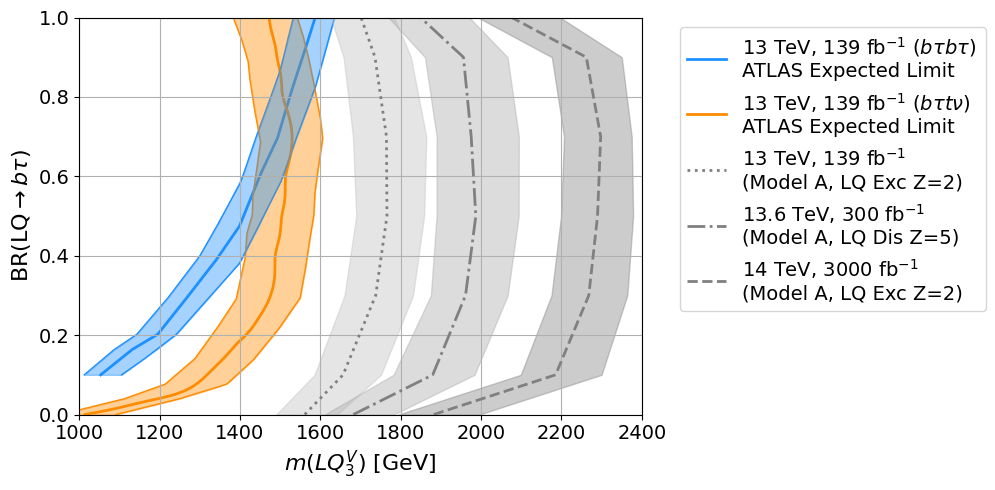

In [ ]:
lw = 2


data_Atlas_05 = pd.DataFrame({'ATLAS_beta_05_low': beta_VLQ_05_minus,
                           'ATLAS_beta_05_up': beta_VLQ_05_plus,
                     'ATLAS_low_05':mass_VLQ_05_minus,
                     'ATLAS_up_05':mass_VLQ_05_plus})

data_Atlas_1 = pd.DataFrame({'ATLAS_beta_1_low': beta_VLQ_1_minus,
                           'ATLAS_beta_1_up': beta_VLQ_1_plus,
                     'ATLAS_low_1':mass_VLQ_1_minus,
                     'ATLAS_up_1':mass_VLQ_1_plus})


data_LQ = pd.DataFrame({'BR': betas,
                      'VLQ_exc_13_low': m_BL_exc_VLQ_low_13TeV.tolist(),
                      'VLQ_exc_13_up': m_BL_exc_VLQ_high_13TeV.tolist(),
                      'VLQ_exc_136_low': m_BL_exc_VLQ_low_136TeV.tolist(),
                      'VLQ_exc_136_up': m_BL_exc_VLQ_high_136TeV.tolist(),
                      'VLQ_exc_14_low': m_BL_exc_VLQ_low_14TeV.tolist(),
                      'VLQ_exc_14_up': m_BL_exc_VLQ_high_14TeV.tolist(),
                    })

LQ_names = data_LQ.columns[1:]

fig = plt.figure(figsize=(15, 5))
gs = gridspec.GridSpec(nrows=1, ncols=2, wspace=0)

ax = fig.add_subplot(gs[0, 1])
for LQ_name in LQ_names[:-1]:
    ax.plot(data_LQ[LQ_name], data_LQ['BR'], linewidth=2, color='None')


plt.rcParams['hatch.linewidth'] = 2.5
# ax.fill_betweenx(data_Atlas_05['ATLAS_beta_05_low'], 0, data_Atlas_05['ATLAS_low_05'], facecolor='None', edgecolor='darkorange', alpha=0.4, hatch='//')
ax.fill_betweenx(y=beta_VLQ_05,  # Variable sobre el eje Y
    x1=f_VLQ_05_minus(beta_VLQ_05),  # Límite izquierdo en el eje X
    x2=f_VLQ_05_plus(beta_VLQ_05),  # Límite derecho en el eje X
    color="darkorange", alpha=0.4)

# ax.fill_betweenx(data_Atlas_1['ATLAS_beta_1_low'], 0, data_Atlas_1['ATLAS_low_1'], facecolor='None', edgecolor='darkorange', alpha=0.4, hatch='//')
ax.fill_betweenx(y=beta_VLQ_1,  # Variable sobre el eje Y
    x1=f_VLQ_1_minus(beta_VLQ_1),  # Límite izquierdo en el eje X
    x2=f_VLQ_1_plus(beta_VLQ_1),  # Límite derecho en el eje X
    color="dodgerblue", alpha=0.4)

colors = [ "None", "silver", "None", "darkgray", "None", "gray", "None", "green", "None"]
previous_curve = 0
previous_name = ''
for LQ_name, color in zip(LQ_names, colors):
    ax.fill_betweenx(data_LQ['BR'], previous_curve, data_LQ[LQ_name], color=color, alpha=0.4)
    previous_curve = data_LQ[LQ_name]
    previous_name = LQ_name




plt.plot(mass_VLQ_1, beta_VLQ_1, '-', color='dodgerblue', lw=lw, zorder=0, label='13 TeV, 139 fb$^{-1}$ ($b\\tau b\\tau$) \nATLAS Expected Limit')
plt.plot(mass_VLQ_1_minus, beta_VLQ_1_minus, '-', color='dodgerblue', lw=1, zorder=0)
plt.plot(mass_VLQ_1_plus, beta_VLQ_1_plus, '-', color='dodgerblue', lw=1, zorder=0)
plt.plot(mass_VLQ_05, beta_VLQ_05, '-', color='darkorange', lw=lw, zorder=0, label='13 TeV, 139 fb$^{-1}$ ($b\\tau t\\nu$) \nATLAS Expected Limit')
plt.plot(mass_VLQ_05_minus, beta_VLQ_05_minus, '-', color='darkorange', lw=1, zorder=0)
plt.plot(mass_VLQ_05_plus, beta_VLQ_05_plus, '-', color='darkorange', lw=1, zorder=0)
plt.plot(m_BL_exc_VLQ_13TeV, betas, ':', color='gray', lw=lw, label='13 TeV, 139 fb$^{-1}$ \n(Model A, LQ Exc Z=2)')
# plt.plot(m_BL_dis_VLQ_14TeV, betas, '-', color='black', lw=lw, label='14 TeV, 3000 fb$^{-1}$ \n(Model A, LQ Dis Z=5)')
plt.plot(m_BL_exc_VLQ_136TeV, betas, '-.', color='gray', lw=lw, label='13.6 TeV, 300 fb$^{-1}$ \n(Model A, LQ Dis Z=5)')
plt.plot(m_BL_exc_VLQ_14TeV, betas, '--', color='gray', lw=lw, label='14 TeV, 3000 fb$^{-1}$ \n(Model A, LQ Exc Z=2)')
# plt.plot(m5_inter_VLQ_betas, betas, '-', color='green', lw=lw, label='14 TeV, 3000 fb$^{-1}$ \n(Model B, VLQ compatible, \n$Z_S$=5, $Z_V$<2)')



plt.xlim(1000,2400)
plt.ylim([0., 1])
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m(LQ_3^V)$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
# plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(mainfolder + 'saved-results/finalplot_VLQ_exc_v2.pdf', bbox_inches='tight')
plt.show()

### With sistematics

In [ ]:

# LOAD

file_path = mainfolder + 'saved-results/Z14TeV_err_up.txt'

loaded_data = np.loadtxt(file_path)

loaded_betas = loaded_data[:, 0]
m_asimov_exc_SLQ_14TeV = loaded_data[:, 1]
m_asimov_dis_SLQ_14TeV = loaded_data[:, 2]
m_asimov_exc_VLQ_14TeV = loaded_data[:, 3]
m_asimov_dis_VLQ_14TeV = loaded_data[:, 4]
m_BL_exc_SLQ_14TeV_up = loaded_data[:, 5]
m_BL_dis_SLQ_14TeV_up = loaded_data[:, 6]
m_BL_exc_VLQ_14TeV_up = loaded_data[:, 7]
m_BL_dis_VLQ_14TeV_up = loaded_data[:, 8]
m_BL_exc_SLQ_low_14TeV_up = loaded_data[:, 9]
m_BL_dis_SLQ_low_14TeV_up = loaded_data[:, 10]
m_BL_exc_VLQ_low_14TeV_up = loaded_data[:, 11]
m_BL_dis_VLQ_low_14TeV_up = loaded_data[:, 12]
m_BL_exc_SLQ_high_14TeV_up = loaded_data[:, 13]
m_BL_dis_SLQ_high_14TeV_up = loaded_data[:, 14]
m_BL_exc_VLQ_high_14TeV_up = loaded_data[:, 15]
m_BL_dis_VLQ_high_14TeV_up = loaded_data[:, 16]




# LOAD

file_path = mainfolder + 'saved-results/Z14TeV_err_down.txt'

loaded_data = np.loadtxt(file_path)

loaded_betas = loaded_data[:, 0]
m_asimov_exc_SLQ_14TeV = loaded_data[:, 1]
m_asimov_dis_SLQ_14TeV = loaded_data[:, 2]
m_asimov_exc_VLQ_14TeV = loaded_data[:, 3]
m_asimov_dis_VLQ_14TeV = loaded_data[:, 4]
m_BL_exc_SLQ_14TeV_down = loaded_data[:, 5]
m_BL_dis_SLQ_14TeV_down = loaded_data[:, 6]
m_BL_exc_VLQ_14TeV_down = loaded_data[:, 7]
m_BL_dis_VLQ_14TeV_down = loaded_data[:, 8]
m_BL_exc_SLQ_low_14TeV_down = loaded_data[:, 9]
m_BL_dis_SLQ_low_14TeV_down = loaded_data[:, 10]
m_BL_exc_VLQ_low_14TeV_down = loaded_data[:, 11]
m_BL_dis_VLQ_low_14TeV_down = loaded_data[:, 12]
m_BL_exc_SLQ_high_14TeV_down = loaded_data[:, 13]
m_BL_dis_SLQ_high_14TeV_down = loaded_data[:, 14]
m_BL_exc_VLQ_high_14TeV_down = loaded_data[:, 15]
m_BL_dis_VLQ_high_14TeV_down = loaded_data[:, 16]


# for the evidence (Z=3)
file_path = mainfolder + 'saved-results/Z14TeV_err_down_Z3.txt'

loaded_data = np.loadtxt(file_path)

m_BL_dis_SLQ_14TeV_down_Z3 = loaded_data[:, 6]
m_BL_dis_VLQ_14TeV_down_Z3 = loaded_data[:, 8]

m_BL_dis_SLQ_low_14TeV_down_Z3 = loaded_data[:, 10]
m_BL_dis_VLQ_low_14TeV_down_Z3 = loaded_data[:, 12]

m_BL_dis_SLQ_high_14TeV_down_Z3 = loaded_data[:, 14]
m_BL_dis_VLQ_high_14TeV_down_Z3 = loaded_data[:, 16]



In [ ]:

# LOAD

file_path = mainfolder + 'saved-results/Z13TeV_err_up.txt'

loaded_data = np.loadtxt(file_path)

loaded_betas = loaded_data[:, 0]
m_asimov_exc_SLQ_13TeV = loaded_data[:, 1]
m_asimov_dis_SLQ_13TeV = loaded_data[:, 2]
m_asimov_exc_VLQ_13TeV = loaded_data[:, 3]
m_asimov_dis_VLQ_13TeV = loaded_data[:, 4]
m_BL_exc_SLQ_13TeV_up = loaded_data[:, 5]
m_BL_dis_SLQ_13TeV_up = loaded_data[:, 6]
m_BL_exc_VLQ_13TeV_up = loaded_data[:, 7]
m_BL_dis_VLQ_13TeV_up = loaded_data[:, 8]
m_BL_exc_SLQ_low_13TeV_up = loaded_data[:, 9]
m_BL_dis_SLQ_low_13TeV_up = loaded_data[:, 10]
m_BL_exc_VLQ_low_13TeV_up = loaded_data[:, 11]
m_BL_dis_VLQ_low_13TeV_up = loaded_data[:, 12]
m_BL_exc_SLQ_high_13TeV_up = loaded_data[:, 13]
m_BL_dis_SLQ_high_13TeV_up = loaded_data[:, 14]
m_BL_exc_VLQ_high_13TeV_up = loaded_data[:, 15]
m_BL_dis_VLQ_high_13TeV_up = loaded_data[:, 16]



# LOAD

file_path = mainfolder + 'saved-results/Z13TeV_err_down.txt'

loaded_data = np.loadtxt(file_path)

loaded_betas = loaded_data[:, 0]
m_asimov_exc_SLQ_13TeV = loaded_data[:, 1]
m_asimov_dis_SLQ_13TeV = loaded_data[:, 2]
m_asimov_exc_VLQ_13TeV = loaded_data[:, 3]
m_asimov_dis_VLQ_13TeV = loaded_data[:, 4]
m_BL_exc_SLQ_13TeV_down = loaded_data[:, 5]
m_BL_dis_SLQ_13TeV_down = loaded_data[:, 6]
m_BL_exc_VLQ_13TeV_down = loaded_data[:, 7]
m_BL_dis_VLQ_13TeV_down = loaded_data[:, 8]
m_BL_exc_SLQ_low_13TeV_down = loaded_data[:, 9]
m_BL_dis_SLQ_low_13TeV_down = loaded_data[:, 10]
m_BL_exc_VLQ_low_13TeV_down = loaded_data[:, 11]
m_BL_dis_VLQ_low_13TeV_down = loaded_data[:, 12]
m_BL_exc_SLQ_high_13TeV_down = loaded_data[:, 13]
m_BL_dis_SLQ_high_13TeV_down = loaded_data[:, 14]
m_BL_exc_VLQ_high_13TeV_down = loaded_data[:, 15]
m_BL_dis_VLQ_high_13TeV_down = loaded_data[:, 16]

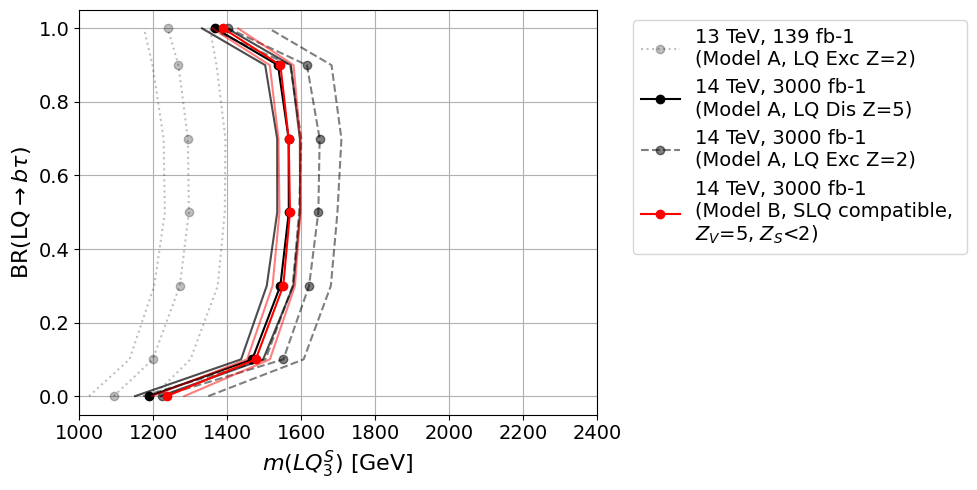

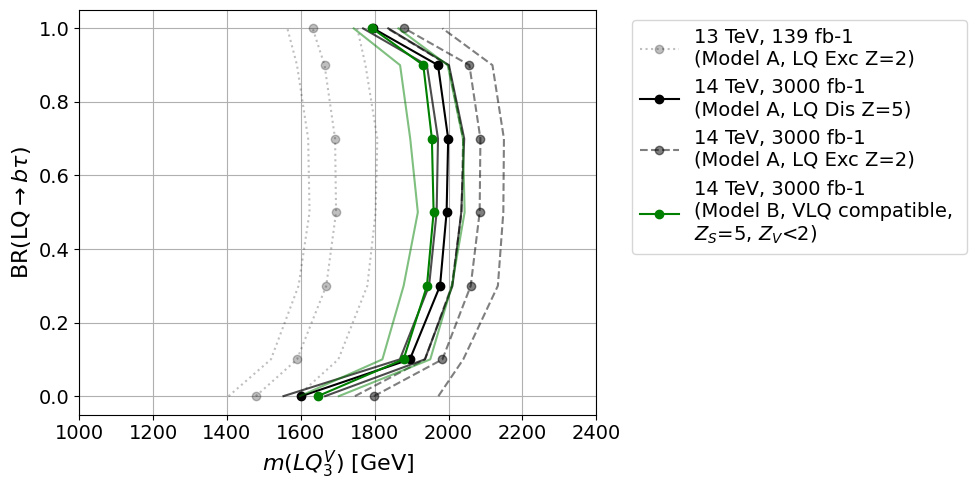

In [ ]:
betas = [0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]


# plot BINNED LIKEHOOD

plt.figure(figsize=(10, 5))

plt.plot(m_BL_exc_SLQ_13TeV_up, betas, 'o:', c='black', alpha=0.25, label='13 TeV, 139 fb-1 \n(Model A, LQ Exc Z=2)')
plt.plot(m_BL_exc_SLQ_low_13TeV_up, betas, ':', c='black', alpha=0.25)
plt.plot(m_BL_exc_SLQ_high_13TeV_up, betas, ':', c='black', alpha=0.25)
plt.plot(m_BL_dis_SLQ_14TeV_down, betas, 'o-', c='black', label='14 TeV, 3000 fb-1 \n(Model A, LQ Dis Z=5)')
plt.plot(m_BL_dis_SLQ_low_14TeV_down, betas, '-', c='black', alpha=0.7)
plt.plot(m_BL_dis_SLQ_high_14TeV_down, betas, '-', c='black', alpha=0.7)
plt.plot(m_BL_exc_SLQ_14TeV_up, betas, 'o--', c='black', alpha=0.5, label='14 TeV, 3000 fb-1 \n(Model A, LQ Exc Z=2)')
plt.plot(m_BL_exc_SLQ_low_14TeV_up, betas, '--', c='black', alpha=0.5)
plt.plot(m_BL_exc_SLQ_high_14TeV_up, betas, '--', c='black', alpha=0.5)


# # benchmarks
# plt.plot(m5_BPOK_SLQ_betas, betas, 'o--', c='blue', label='14 TeV, 3000 fb-1 (SLQ id Z=5) (BP)')
# plt.plot(m5_BPOK_SLQ_betas_low, betas, '--', c='blue', alpha=0.5)
# plt.plot(m5_BPOK_SLQ_betas_high, betas, '--', c='blue', alpha=0.5)

# interpolated
m5_inter_SLQ_betas_aux = [i/1.005 for i in m5_inter_SLQ_betas]
m5_inter_SLQ_betas_low_aux = [i/1.005 for i in m5_inter_SLQ_betas_low]
m5_inter_SLQ_betas_high_aux = [i/1.005 for i in m5_inter_SLQ_betas_high]
plt.plot(m5_inter_SLQ_betas_aux, betas, 'o-', c='red', label='14 TeV, 3000 fb-1 \n(Model B, SLQ compatible, \n$Z_V$=5, $Z_S$<2)')
plt.plot(m5_inter_SLQ_betas_low_aux, betas, '-', c='red', alpha=0.5)
plt.plot(m5_inter_SLQ_betas_high_aux, betas, '-', c='red', alpha=0.5)

# # known pdf
# plt.plot(m5_prev_SLQ_betas, betas, 'o:', c='magenta', label='14 TeV, 3000 fb-1 (SLQ id Z=5) (known PDF)')
# plt.plot(m5_prev_SLQ_betas_low, betas, ':', c='magenta', alpha=0.5)
# plt.plot(m5_prev_SLQ_betas_high, betas, ':', c='magenta', alpha=0.5)


# plt.axhline(y=5, linestyle='--', color='black')
# plt.axhline(y=2, linestyle=':', color='black')
plt.xlim(1000,2400)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m(LQ_3^S)$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
# plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(mainfolder + 'saved-results/finalplot_SLQ_sistematics.pdf', bbox_inches='tight')
plt.show()





plt.figure(figsize=(10, 5))

plt.plot(m_BL_exc_VLQ_13TeV_up, betas, 'o:', c='black', alpha=0.25, label='13 TeV, 139 fb-1 \n(Model A, LQ Exc Z=2)')
plt.plot(m_BL_exc_VLQ_low_13TeV_up, betas, ':', c='black', alpha=0.25)
plt.plot(m_BL_exc_VLQ_high_13TeV_up, betas, ':', c='black', alpha=0.25)
plt.plot(m_BL_dis_VLQ_14TeV_down, betas, 'o-', c='black', label='14 TeV, 3000 fb-1 \n(Model A, LQ Dis Z=5)')
plt.plot(m_BL_dis_VLQ_low_14TeV_down, betas, '-', c='black', alpha=0.7)
plt.plot(m_BL_dis_VLQ_high_14TeV_down, betas, '-', c='black', alpha=0.7)
plt.plot(m_BL_exc_VLQ_14TeV_up, betas, 'o--', c='black', alpha=0.5, label='14 TeV, 3000 fb-1 \n(Model A, LQ Exc Z=2)')
plt.plot(m_BL_exc_VLQ_low_14TeV_up, betas, '--', c='black', alpha=0.5)
plt.plot(m_BL_exc_VLQ_high_14TeV_up, betas, '--', c='black', alpha=0.5)


# # benchmarks
# plt.plot(m5_BPOK_VLQ_betas, betas, 'o--', c='blue', label='14 TeV, 3000 fb-1 (VLQ id Z=5) (BP)')
# plt.plot(m5_BPOK_VLQ_betas_low, betas, '--', c='blue', alpha=0.5)
# plt.plot(m5_BPOK_VLQ_betas_high, betas, '--', c='blue', alpha=0.5)

# interpolated
m5_inter_VLQ_betas_aux = [i/1.02 for i in m5_inter_VLQ_betas]
m5_inter_VLQ_betas_low_aux = [i/1.02 for i in m5_inter_VLQ_betas_low]
m5_inter_VLQ_betas_high_aux = [i/1.02 for i in m5_inter_VLQ_betas_high]
plt.plot(m5_inter_VLQ_betas_aux, betas, 'o-', c='green', label='14 TeV, 3000 fb-1 \n(Model B, VLQ compatible, \n$Z_S$=5, $Z_V$<2)')
plt.plot(m5_inter_VLQ_betas_low_aux, betas, '-', c='green', alpha=0.5)
plt.plot(m5_inter_VLQ_betas_high_aux, betas, '-', c='green', alpha=0.5)

# # known pdf
# plt.plot(m5_prev_VLQ_betas, betas, 'o:', c='magenta', label='14 TeV, 3000 fb-1 (VLQ id Z=5) (known PDF)')
# plt.plot(m5_prev_VLQ_betas_low, betas, ':', c='magenta', alpha=0.5)
# plt.plot(m5_prev_VLQ_betas_high, betas, ':', c='magenta', alpha=0.5)


# plt.axhline(y=5, linestyle='--', color='black')
# plt.axhline(y=2, linestyle=':', color='black')
plt.xlim(1000,2400)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m(LQ_3^V)$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
# plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(mainfolder + 'saved-results/finalplot_VLQ_sistematics.pdf', bbox_inches='tight')
plt.show()

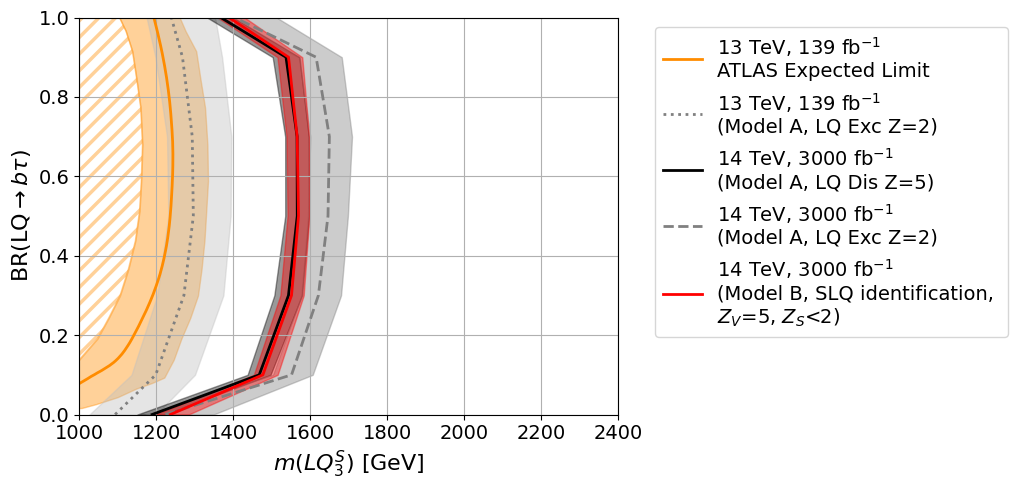

In [ ]:
lw = 2


data_Atlas_comb = pd.DataFrame({'ATLAS_beta': beta_ATLAS_comb,
                     'ATLAS_low':mass_Z95CL_ATLAS_plus1sig_comb,
                     'ATLAS_up':mass_Z95CL_ATLAS_minus1sig_comb})

data_Atlas_1 = pd.DataFrame({'ATLAS_beta_1_low': beta_SLQ_1_minus,
                           'ATLAS_beta_1_up': beta_SLQ_1_plus,
                     'ATLAS_low_1':mass_SLQ_1_minus,
                     'ATLAS_up_1':mass_SLQ_1_plus})

data_Atlas_05 = pd.DataFrame({'ATLAS_beta_05_low': beta_SLQ_05_minus,
                           'ATLAS_beta_05_up': beta_SLQ_05_plus,
                     'ATLAS_low_05':mass_SLQ_05_minus,
                     'ATLAS_up_05':mass_SLQ_05_plus})

data_Atlas_0 = pd.DataFrame({'ATLAS_beta_0_low': beta_SLQ_0_minus,
                           'ATLAS_low_0':mass_SLQ_0_minus})
data_Atlas_0B = pd.DataFrame({'ATLAS_beta_0_up': beta_SLQ_0_plus,
                     'ATLAS_up_0':mass_SLQ_0_plus})


data_LQ = pd.DataFrame({'BR': betas,
                      'SLQ_exc_13_low': m_BL_exc_SLQ_low_13TeV_up.tolist(),
                      'SLQ_exc_13_up': m_BL_exc_SLQ_high_13TeV_up.tolist(),
                      'SLQ_dis_14_low': m_BL_dis_SLQ_low_14TeV_down.tolist(),
                      'SLQ_dis_14_up': m_BL_dis_SLQ_high_14TeV_down.tolist(),
                      'SLQ_exc_14_low': m_BL_exc_SLQ_low_14TeV_up.tolist(),
                      'SLQ_exc_14_up': m_BL_exc_SLQ_high_14TeV_up.tolist(),
                      'SLQ_vs_14_low': m5_inter_SLQ_betas_low_aux,
                      'SLQ_vs_14_up': m5_inter_SLQ_betas_high_aux,
                    })

LQ_names = data_LQ.columns[1:]

fig = plt.figure(figsize=(15, 5))
gs = gridspec.GridSpec(nrows=1, ncols=2, wspace=0)

ax = fig.add_subplot(gs[0, 1])
for LQ_name in LQ_names[:-1]:
    ax.plot(data_LQ[LQ_name], data_LQ['BR'], linewidth=2, color='None')


plt.rcParams['hatch.linewidth'] = 2.5
# ax.fill_betweenx(data_Atlas_comb['ATLAS_beta'], 0, data_Atlas_comb['ATLAS_low'], facecolor='None', edgecolor='darkorange', alpha=0.4, hatch='//')
# ax.fill_betweenx(data_Atlas_comb['ATLAS_beta'], data_Atlas_comb['ATLAS_low'], data_Atlas_comb['ATLAS_up'], color='darkorange', alpha=0.4)

# ax.fill_betweenx(data_Atlas_1['ATLAS_beta_1_low'], 0, data_Atlas_1['ATLAS_low_1'], facecolor='None', edgecolor='darkorange', alpha=0.4, hatch='//')
# ax.fill_betweenx(data_Atlas_1['ATLAS_beta_1_up'], data_Atlas_1['ATLAS_low_1'], data_Atlas_1['ATLAS_up_1'], color='darkorange', alpha=0.4)

ax.fill_betweenx(data_Atlas_05['ATLAS_beta_05_up'], 0, data_Atlas_05['ATLAS_up_05'], facecolor='None', edgecolor='darkorange', alpha=0.4, hatch='//')
ax.fill_betweenx(data_Atlas_05['ATLAS_beta_05_up'], data_Atlas_05['ATLAS_low_05'], data_Atlas_05['ATLAS_up_05'], color='darkorange', alpha=0.4)

# ax.fill_betweenx(data_Atlas_0['ATLAS_beta_0_low'], 0, data_Atlas_0['ATLAS_low_0'], facecolor='None', edgecolor='darkorange', alpha=0.4, hatch='//')
# ax.fill_betweenx(data_Atlas_0B['ATLAS_beta_0_up'], data_Atlas_0['ATLAS_low_0'], data_Atlas_0B['ATLAS_up_0'], color='darkorange', alpha=0.4)

colors = [ "None", "silver", "None", "black", "None", "gray", "None", "red", "None"]
previous_curve = 0
previous_name = ''
for LQ_name, color in zip(LQ_names, colors):
    ax.fill_betweenx(data_LQ['BR'], previous_curve, data_LQ[LQ_name], color=color, alpha=0.4)
    previous_curve = data_LQ[LQ_name]
    previous_name = LQ_name




# plt.plot(mass_Z95CL_ATLAS_comb, beta_ATLAS_comb, '--', color='darkorange', lw=lw, label=r'ATLAS Expected Limit')
# plt.plot(mass_SLQ_1, beta_SLQ_1, '--', color='darkorange', lw=lw)
# plt.plot(mass_SLQ_1_minus, beta_SLQ_1_minus, '--', color='darkorange', lw=1)
# plt.plot(mass_SLQ_1_plus, beta_SLQ_1_plus, '--', color='darkorange', lw=1)
plt.plot(mass_SLQ_05, beta_SLQ_05, '-', color='darkorange', lw=lw, label='13 TeV, 139 fb$^{-1}$ \nATLAS Expected Limit')
# plt.plot(mass_SLQ_0, beta_SLQ_0, '--', color='darkorange', lw=lw)
# plt.plot(mass_SLQ_0_minus, beta_SLQ_0_minus, '--', color='darkorange', lw=1)
# plt.plot(mass_SLQ_0_plus, beta_SLQ_0_plus, '--', color='darkorange', lw=1)
plt.plot(m_BL_exc_SLQ_13TeV_up, betas, ':', color='gray', lw=lw, label='13 TeV, 139 fb$^{-1}$ \n(Model A, LQ Exc Z=2)')
plt.plot(m_BL_dis_SLQ_14TeV_down, betas, '-', color='black', lw=lw, label='14 TeV, 3000 fb$^{-1}$ \n(Model A, LQ Dis Z=5)')
plt.plot(m_BL_exc_SLQ_14TeV_up, betas, '--', color='gray', lw=lw, label='14 TeV, 3000 fb$^{-1}$ \n(Model A, LQ Exc Z=2)')
plt.plot(m5_inter_SLQ_betas_aux, betas, '-', color='red', lw=lw, label='14 TeV, 3000 fb$^{-1}$ \n(Model B, SLQ identification, \n$Z_V$=5, $Z_S$<2)')


plt.xlim(1000,2400)
plt.ylim([0., 1])
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m(LQ_3^S)$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
# plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(mainfolder + 'saved-results/finalplot_SLQ_sistematics_v2.pdf', bbox_inches='tight')
plt.show()

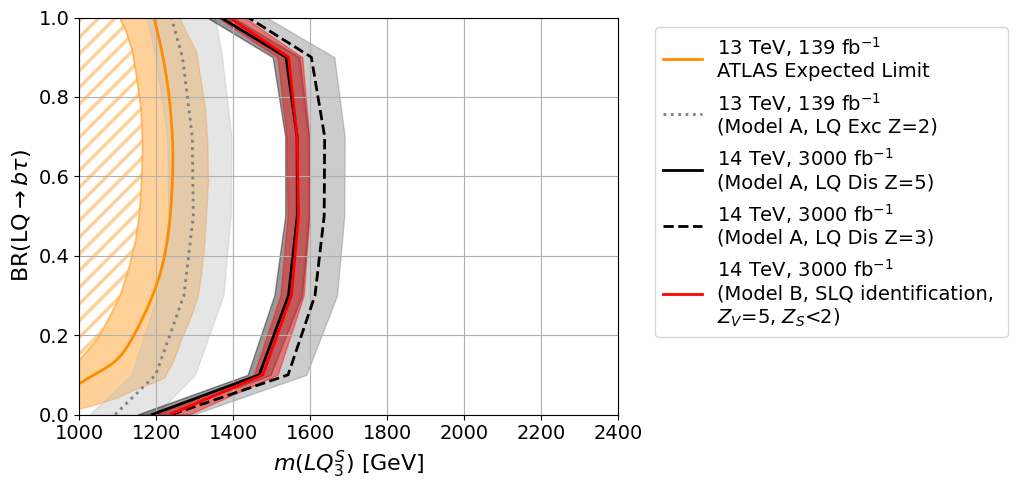

In [ ]:
lw = 2


data_Atlas_comb = pd.DataFrame({'ATLAS_beta': beta_ATLAS_comb,
                     'ATLAS_low':mass_Z95CL_ATLAS_plus1sig_comb,
                     'ATLAS_up':mass_Z95CL_ATLAS_minus1sig_comb})

data_Atlas_1 = pd.DataFrame({'ATLAS_beta_1_low': beta_SLQ_1_minus,
                           'ATLAS_beta_1_up': beta_SLQ_1_plus,
                     'ATLAS_low_1':mass_SLQ_1_minus,
                     'ATLAS_up_1':mass_SLQ_1_plus})

data_Atlas_05 = pd.DataFrame({'ATLAS_beta_05_low': beta_SLQ_05_minus,
                           'ATLAS_beta_05_up': beta_SLQ_05_plus,
                     'ATLAS_low_05':mass_SLQ_05_minus,
                     'ATLAS_up_05':mass_SLQ_05_plus})

data_Atlas_0 = pd.DataFrame({'ATLAS_beta_0_low': beta_SLQ_0_minus,
                           'ATLAS_low_0':mass_SLQ_0_minus})
data_Atlas_0B = pd.DataFrame({'ATLAS_beta_0_up': beta_SLQ_0_plus,
                     'ATLAS_up_0':mass_SLQ_0_plus})


data_LQ = pd.DataFrame({'BR': betas,
                      'SLQ_exc_13_low': m_BL_exc_SLQ_low_13TeV_up.tolist(),
                      'SLQ_exc_13_up': m_BL_exc_SLQ_high_13TeV_up.tolist(),
                      'SLQ_dis_14_low': m_BL_dis_SLQ_low_14TeV_down.tolist(),
                      'SLQ_dis_14_up': m_BL_dis_SLQ_high_14TeV_down.tolist(),
                      'SLQ_dis_14_low_Z3': m_BL_dis_SLQ_low_14TeV_down_Z3.tolist(),
                      'SLQ_dis_14_up_Z3': m_BL_dis_SLQ_high_14TeV_down_Z3.tolist(),
                      'SLQ_vs_14_low': m5_inter_SLQ_betas_low_aux,
                      'SLQ_vs_14_up': m5_inter_SLQ_betas_high_aux,
                    })

LQ_names = data_LQ.columns[1:]

fig = plt.figure(figsize=(15, 5))
gs = gridspec.GridSpec(nrows=1, ncols=2, wspace=0)

ax = fig.add_subplot(gs[0, 1])
for LQ_name in LQ_names[:-1]:
    ax.plot(data_LQ[LQ_name], data_LQ['BR'], linewidth=2, color='None')


plt.rcParams['hatch.linewidth'] = 2.5
# ax.fill_betweenx(data_Atlas_comb['ATLAS_beta'], 0, data_Atlas_comb['ATLAS_low'], facecolor='None', edgecolor='darkorange', alpha=0.4, hatch='//')
# ax.fill_betweenx(data_Atlas_comb['ATLAS_beta'], data_Atlas_comb['ATLAS_low'], data_Atlas_comb['ATLAS_up'], color='darkorange', alpha=0.4)

# ax.fill_betweenx(data_Atlas_1['ATLAS_beta_1_low'], 0, data_Atlas_1['ATLAS_low_1'], facecolor='None', edgecolor='darkorange', alpha=0.4, hatch='//')
# ax.fill_betweenx(data_Atlas_1['ATLAS_beta_1_up'], data_Atlas_1['ATLAS_low_1'], data_Atlas_1['ATLAS_up_1'], color='darkorange', alpha=0.4)

ax.fill_betweenx(data_Atlas_05['ATLAS_beta_05_up'], 0, data_Atlas_05['ATLAS_up_05'], facecolor='None', edgecolor='darkorange', alpha=0.4, hatch='//')
ax.fill_betweenx(data_Atlas_05['ATLAS_beta_05_up'], data_Atlas_05['ATLAS_low_05'], data_Atlas_05['ATLAS_up_05'], color='darkorange', alpha=0.4)

# ax.fill_betweenx(data_Atlas_0['ATLAS_beta_0_low'], 0, data_Atlas_0['ATLAS_low_0'], facecolor='None', edgecolor='darkorange', alpha=0.4, hatch='//')
# ax.fill_betweenx(data_Atlas_0B['ATLAS_beta_0_up'], data_Atlas_0['ATLAS_low_0'], data_Atlas_0B['ATLAS_up_0'], color='darkorange', alpha=0.4)

colors = [ "None", "silver", "None", "black", "None", "gray", "None", "red", "None"]
previous_curve = 0
previous_name = ''
for LQ_name, color in zip(LQ_names, colors):
    ax.fill_betweenx(data_LQ['BR'], previous_curve, data_LQ[LQ_name], color=color, alpha=0.4)
    previous_curve = data_LQ[LQ_name]
    previous_name = LQ_name




# plt.plot(mass_Z95CL_ATLAS_comb, beta_ATLAS_comb, '--', color='darkorange', lw=lw, label=r'ATLAS Expected Limit')
# plt.plot(mass_SLQ_1, beta_SLQ_1, '--', color='darkorange', lw=lw)
# plt.plot(mass_SLQ_1_minus, beta_SLQ_1_minus, '--', color='darkorange', lw=1)
# plt.plot(mass_SLQ_1_plus, beta_SLQ_1_plus, '--', color='darkorange', lw=1)
plt.plot(mass_SLQ_05, beta_SLQ_05, '-', color='darkorange', lw=lw, label='13 TeV, 139 fb$^{-1}$ \nATLAS Expected Limit')
# plt.plot(mass_SLQ_0, beta_SLQ_0, '--', color='darkorange', lw=lw)
# plt.plot(mass_SLQ_0_minus, beta_SLQ_0_minus, '--', color='darkorange', lw=1)
# plt.plot(mass_SLQ_0_plus, beta_SLQ_0_plus, '--', color='darkorange', lw=1)
plt.plot(m_BL_exc_SLQ_13TeV_up, betas, ':', color='gray', lw=lw, label='13 TeV, 139 fb$^{-1}$ \n(Model A, LQ Exc Z=2)')
plt.plot(m_BL_dis_SLQ_14TeV_down, betas, '-', color='black', lw=lw, label='14 TeV, 3000 fb$^{-1}$ \n(Model A, LQ Dis Z=5)')
plt.plot(m_BL_dis_SLQ_14TeV_down_Z3, betas, '--', color='black', lw=lw, label='14 TeV, 3000 fb$^{-1}$ \n(Model A, LQ Dis Z=3)')
plt.plot(m5_inter_SLQ_betas_aux, betas, '-', color='red', lw=lw, label='14 TeV, 3000 fb$^{-1}$ \n(Model B, SLQ identification, \n$Z_V$=5, $Z_S$<2)')


plt.xlim(1000,2400)
plt.ylim([0., 1])
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m(LQ_3^S)$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
# plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(mainfolder + 'saved-results/finalplot_SLQ_sistematics_v3.pdf', bbox_inches='tight')
plt.show()

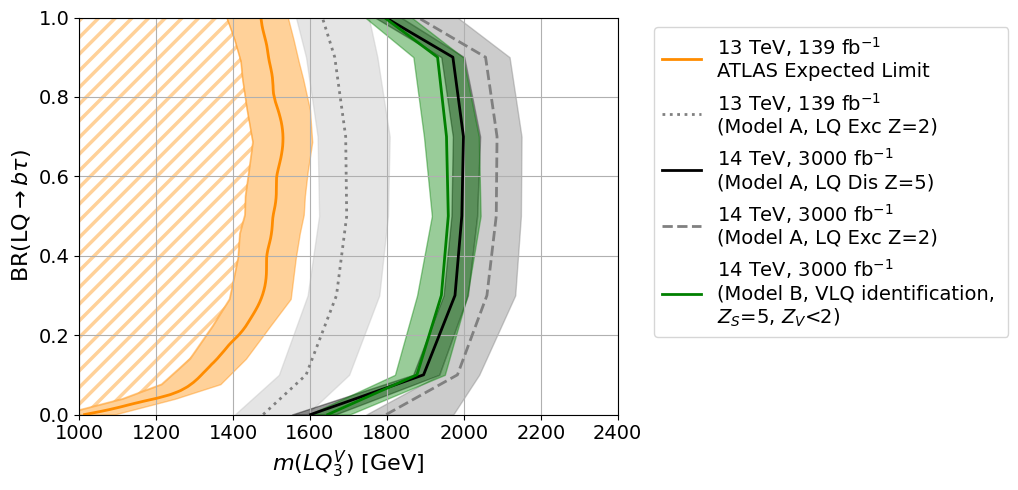

In [ ]:
lw = 2


data_Atlas_05 = pd.DataFrame({'ATLAS_beta_05_low': beta_VLQ_05_minus,
                           'ATLAS_beta_05_up': beta_VLQ_05_plus,
                     'ATLAS_low_05':mass_VLQ_05_minus,
                     'ATLAS_up_05':mass_VLQ_05_plus})

data_Atlas_1 = pd.DataFrame({'ATLAS_beta_1_low': beta_VLQ_1_minus,
                           'ATLAS_beta_1_up': beta_VLQ_1_plus,
                     'ATLAS_low_1':mass_VLQ_1_minus,
                     'ATLAS_up_1':mass_VLQ_1_plus})


data_LQ = pd.DataFrame({'BR': betas,
                      'VLQ_exc_13_low': m_BL_exc_VLQ_low_13TeV_up.tolist(),
                      'VLQ_exc_13_up': m_BL_exc_VLQ_high_13TeV_up.tolist(),
                      'VLQ_dis_14_low': m_BL_dis_VLQ_low_14TeV_down.tolist(),
                      'VLQ_dis_14_up': m_BL_dis_VLQ_high_14TeV_down.tolist(),
                      'VLQ_exc_14_low': m_BL_exc_VLQ_low_14TeV_up.tolist(),
                      'VLQ_exc_14_up': m_BL_exc_VLQ_high_14TeV_up.tolist(),
                      'VLQ_vs_14_low': m5_inter_VLQ_betas_low_aux,
                      'VLQ_vs_14_up': m5_inter_VLQ_betas_high_aux,
                    })

LQ_names = data_LQ.columns[1:]

fig = plt.figure(figsize=(15, 5))
gs = gridspec.GridSpec(nrows=1, ncols=2, wspace=0)

ax = fig.add_subplot(gs[0, 1])
for LQ_name in LQ_names[:-1]:
    ax.plot(data_LQ[LQ_name], data_LQ['BR'], linewidth=2, color='None')


plt.rcParams['hatch.linewidth'] = 2.5
ax.fill_betweenx(data_Atlas_05['ATLAS_beta_05_low'], 0, data_Atlas_05['ATLAS_low_05'], facecolor='None', edgecolor='darkorange', alpha=0.4, hatch='//')
ax.fill_betweenx(data_Atlas_05['ATLAS_beta_05_low'], data_Atlas_05['ATLAS_low_05'], data_Atlas_05['ATLAS_up_05'], color='darkorange', alpha=0.4)

# ax.fill_betweenx(data_Atlas_1['ATLAS_beta_1_low'], 0, data_Atlas_1['ATLAS_low_1'], facecolor='None', edgecolor='darkorange', alpha=0.4, hatch='//')
# ax.fill_betweenx(data_Atlas_1['ATLAS_beta_1_up'], data_Atlas_1['ATLAS_low_1'], data_Atlas_1['ATLAS_up_1'], color='darkorange', alpha=0.4)

colors = [ "None", "silver", "None", "black", "None", "gray", "None", "green", "None"]
previous_curve = 0
previous_name = ''
for LQ_name, color in zip(LQ_names, colors):
    ax.fill_betweenx(data_LQ['BR'], previous_curve, data_LQ[LQ_name], color=color, alpha=0.4)
    previous_curve = data_LQ[LQ_name]
    previous_name = LQ_name




plt.plot(mass_VLQ_05, beta_VLQ_05, '-', color='darkorange', lw=lw, label='13 TeV, 139 fb$^{-1}$ \nATLAS Expected Limit')
# plt.plot(mass_VLQ_1, beta_VLQ_1, '--', color='darkorange', lw=lw)
# plt.plot(mass_VLQ_1_minus, beta_VLQ_1_minus, '--', color='darkorange', lw=1)
# plt.plot(mass_VLQ_1_plus, beta_VLQ_1_plus, '--', color='darkorange', lw=1)
plt.plot(m_BL_exc_VLQ_13TeV_up, betas, ':', color='gray', lw=lw, label='13 TeV, 139 fb$^{-1}$ \n(Model A, LQ Exc Z=2)')
plt.plot(m_BL_dis_VLQ_14TeV_down, betas, '-', color='black', lw=lw, label='14 TeV, 3000 fb$^{-1}$ \n(Model A, LQ Dis Z=5)')
plt.plot(m_BL_exc_VLQ_14TeV_up, betas, '--', color='gray', lw=lw, label='14 TeV, 3000 fb$^{-1}$ \n(Model A, LQ Exc Z=2)')
plt.plot(m5_inter_VLQ_betas_aux, betas, '-', color='green', lw=lw, label='14 TeV, 3000 fb$^{-1}$ \n(Model B, VLQ identification, \n$Z_S$=5, $Z_V$<2)')



plt.xlim(1000,2400)
plt.ylim([0., 1])
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m(LQ_3^V)$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
# plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(mainfolder + 'saved-results/finalplot_VLQ_sistematics_v2.pdf', bbox_inches='tight')
plt.show()

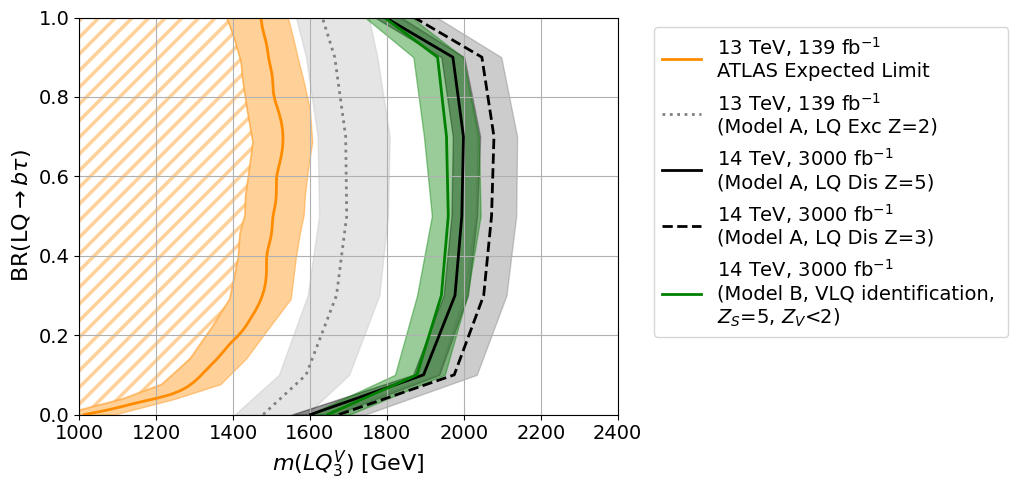

In [ ]:
lw = 2


data_Atlas_05 = pd.DataFrame({'ATLAS_beta_05_low': beta_VLQ_05_minus,
                           'ATLAS_beta_05_up': beta_VLQ_05_plus,
                     'ATLAS_low_05':mass_VLQ_05_minus,
                     'ATLAS_up_05':mass_VLQ_05_plus})

data_Atlas_1 = pd.DataFrame({'ATLAS_beta_1_low': beta_VLQ_1_minus,
                           'ATLAS_beta_1_up': beta_VLQ_1_plus,
                     'ATLAS_low_1':mass_VLQ_1_minus,
                     'ATLAS_up_1':mass_VLQ_1_plus})


data_LQ = pd.DataFrame({'BR': betas,
                      'VLQ_exc_13_low': m_BL_exc_VLQ_low_13TeV_up.tolist(),
                      'VLQ_exc_13_up': m_BL_exc_VLQ_high_13TeV_up.tolist(),
                      'VLQ_dis_14_low': m_BL_dis_VLQ_low_14TeV_down.tolist(),
                      'VLQ_dis_14_up': m_BL_dis_VLQ_high_14TeV_down.tolist(),
                      'VLQ_dis_14_low_Z3': m_BL_dis_VLQ_low_14TeV_down_Z3.tolist(),
                      'VLQ_dis_14_up_Z3': m_BL_dis_VLQ_high_14TeV_down_Z3.tolist(),
                      'VLQ_vs_14_low': m5_inter_VLQ_betas_low_aux,
                      'VLQ_vs_14_up': m5_inter_VLQ_betas_high_aux,
                    })

LQ_names = data_LQ.columns[1:]

fig = plt.figure(figsize=(15, 5))
gs = gridspec.GridSpec(nrows=1, ncols=2, wspace=0)

ax = fig.add_subplot(gs[0, 1])
for LQ_name in LQ_names[:-1]:
    ax.plot(data_LQ[LQ_name], data_LQ['BR'], linewidth=2, color='None')


plt.rcParams['hatch.linewidth'] = 2.5
ax.fill_betweenx(data_Atlas_05['ATLAS_beta_05_low'], 0, data_Atlas_05['ATLAS_low_05'], facecolor='None', edgecolor='darkorange', alpha=0.4, hatch='//')
ax.fill_betweenx(data_Atlas_05['ATLAS_beta_05_low'], data_Atlas_05['ATLAS_low_05'], data_Atlas_05['ATLAS_up_05'], color='darkorange', alpha=0.4)

# ax.fill_betweenx(data_Atlas_1['ATLAS_beta_1_low'], 0, data_Atlas_1['ATLAS_low_1'], facecolor='None', edgecolor='darkorange', alpha=0.4, hatch='//')
# ax.fill_betweenx(data_Atlas_1['ATLAS_beta_1_up'], data_Atlas_1['ATLAS_low_1'], data_Atlas_1['ATLAS_up_1'], color='darkorange', alpha=0.4)

colors = [ "None", "silver", "None", "black", "None", "gray", "None", "green", "None"]
previous_curve = 0
previous_name = ''
for LQ_name, color in zip(LQ_names, colors):
    ax.fill_betweenx(data_LQ['BR'], previous_curve, data_LQ[LQ_name], color=color, alpha=0.4)
    previous_curve = data_LQ[LQ_name]
    previous_name = LQ_name




plt.plot(mass_VLQ_05, beta_VLQ_05, '-', color='darkorange', lw=lw, label='13 TeV, 139 fb$^{-1}$ \nATLAS Expected Limit')
# plt.plot(mass_VLQ_1, beta_VLQ_1, '--', color='darkorange', lw=lw)
# plt.plot(mass_VLQ_1_minus, beta_VLQ_1_minus, '--', color='darkorange', lw=1)
# plt.plot(mass_VLQ_1_plus, beta_VLQ_1_plus, '--', color='darkorange', lw=1)
plt.plot(m_BL_exc_VLQ_13TeV_up, betas, ':', color='gray', lw=lw, label='13 TeV, 139 fb$^{-1}$ \n(Model A, LQ Exc Z=2)')
plt.plot(m_BL_dis_VLQ_14TeV_down, betas, '-', color='black', lw=lw, label='14 TeV, 3000 fb$^{-1}$ \n(Model A, LQ Dis Z=5)')
plt.plot(m_BL_dis_VLQ_14TeV_down_Z3, betas, '--', color='black', lw=lw, label='14 TeV, 3000 fb$^{-1}$ \n(Model A, LQ Dis Z=3)')
plt.plot(m5_inter_VLQ_betas_aux, betas, '-', color='green', lw=lw, label='14 TeV, 3000 fb$^{-1}$ \n(Model B, VLQ identification, \n$Z_S$=5, $Z_V$<2)')



plt.xlim(1000,2400)
plt.ylim([0., 1])
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m(LQ_3^V)$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
# plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(mainfolder + 'saved-results/finalplot_VLQ_sistematics_v3.pdf', bbox_inches='tight')
plt.show()